Using CCM folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260915_153756
rho_csv_path: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_network_20260915_153756/ccm_rho.csv
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Segment (s): (814.571, 921.515) | fs: 1000
Output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260915_164332

Selected bidirectional pairs: [('C4', 'CP6'), ('C4', 'FC6')]
Selected directed edges: (4, 4)
  target source       rho
0     C4    CP6  0.994868
1    CP6     C4  0.991451
2    FC6     C4  0.990764
3     C4    FC6  0.989639

Loaded segment: N=106944 samples | channels=32 | seg=(814.571, 921.515) s | fs=1000
Windowing: win=20.0s overlap=0.50 => step=10.0s | windows=9
Embedding: m=10, tau=8 => drop=72 samples inside each window
Surrogates: n_surr=36 (min p=0.0270) | BH-FDR alpha=0.05

Window 1/9  samples [0,20000)  time [0.00,20.00] s
  C4<-CP6: surrogates 25/36
  CP6<-C4: surrog

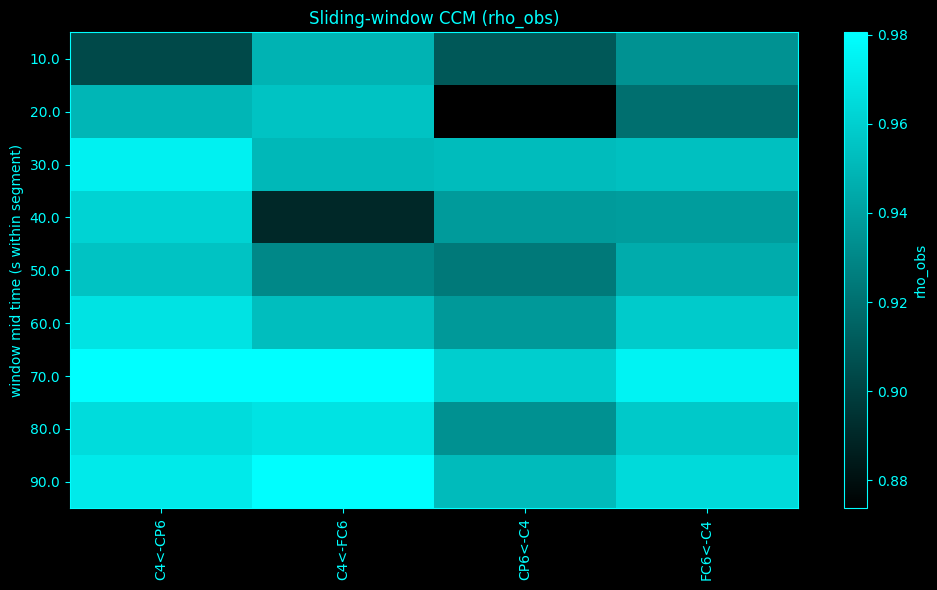

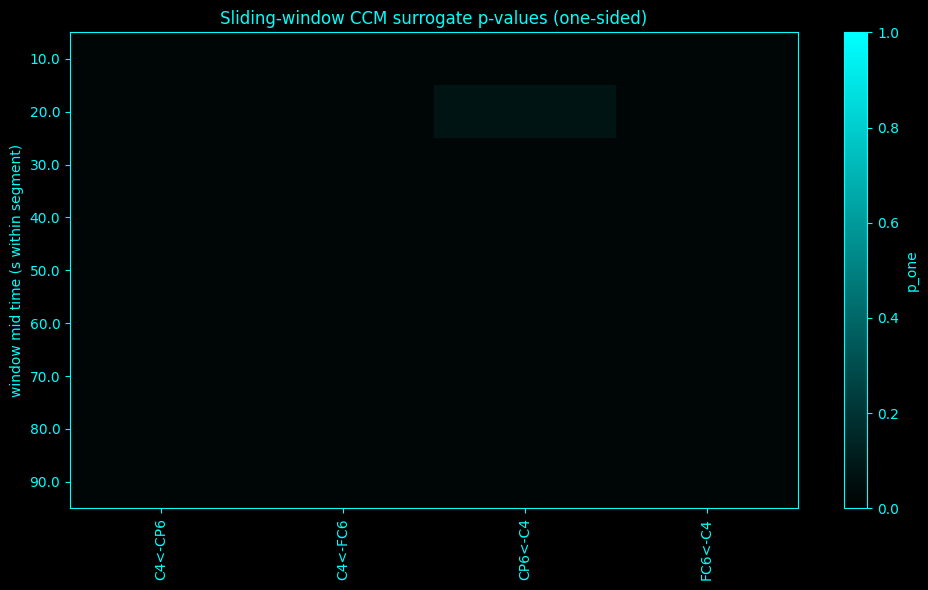

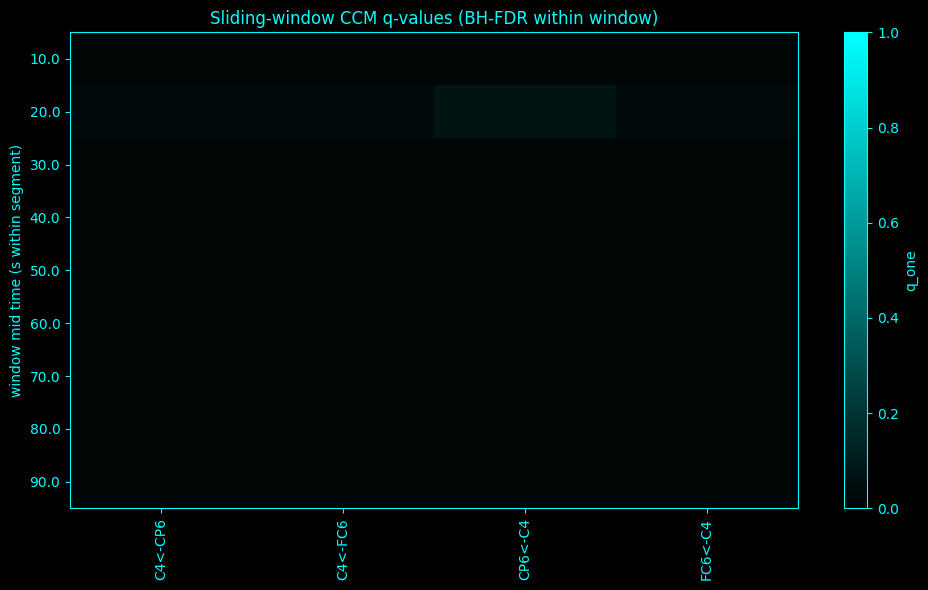

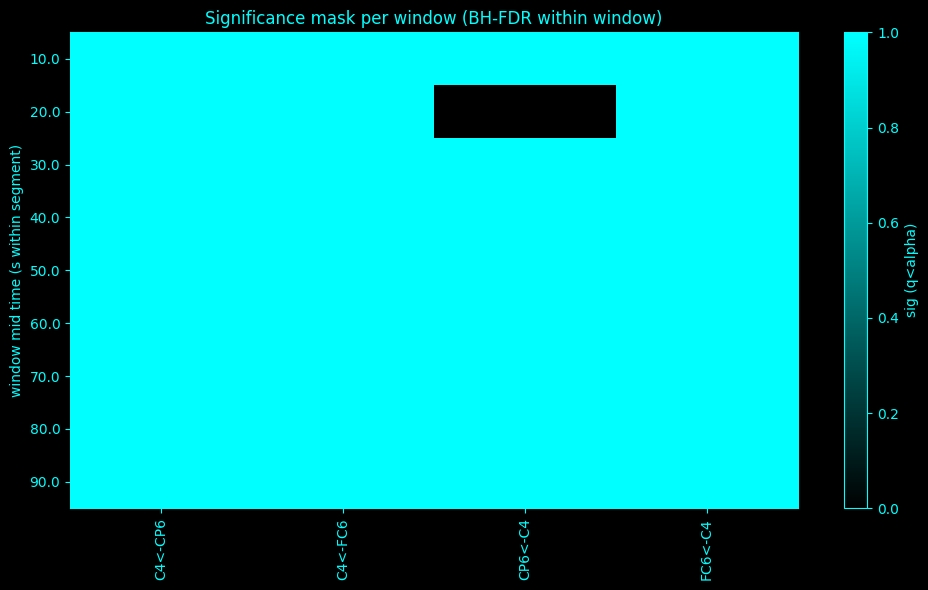

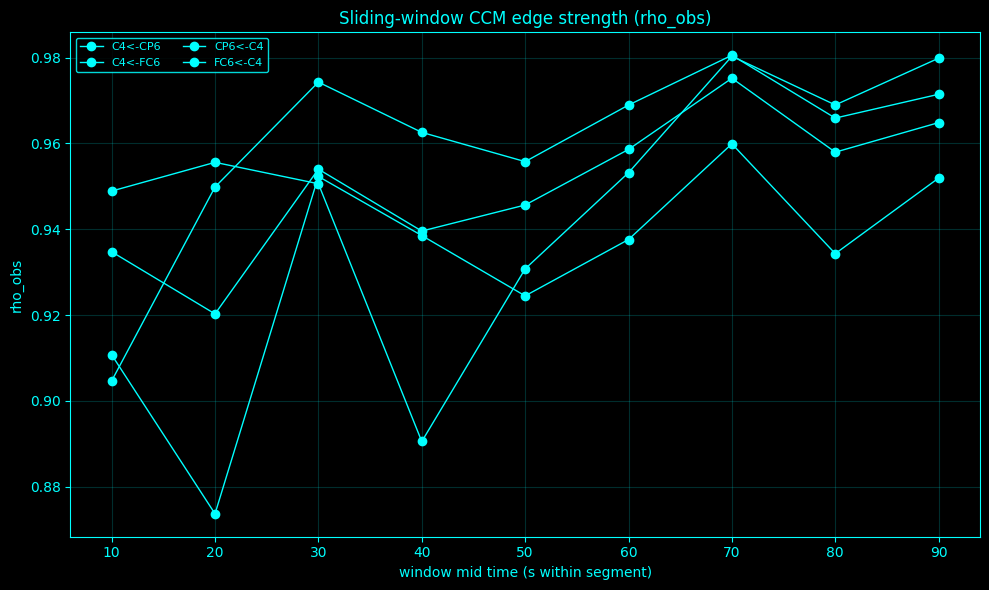

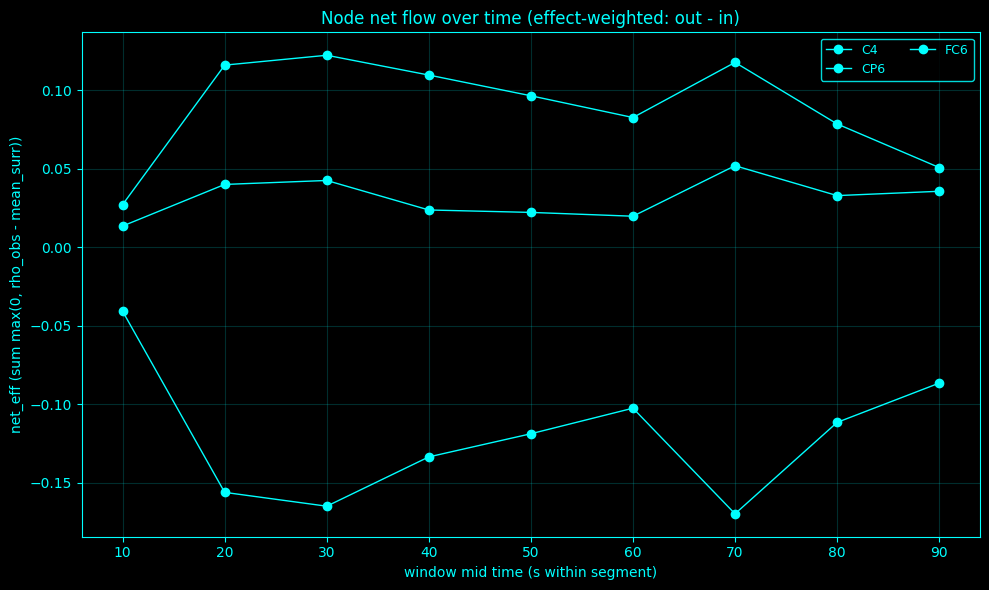


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260915_164332
  - top_edges_used.csv
  - ccm_time_results_with_q.csv
  - rho_obs_pivot.csv / p_one_pivot.csv / q_one_pivot.csv / sig_pivot.csv
  - rho_obs_heatmap.png / p_one_heatmap.png / q_one_heatmap.png / sig_mask.png
  - rho_obs_timeseries.png
  - directionality_pairs.csv
  - node_strength_by_window.csv / node_net_flow_timeseries.png
  - edge_summary.csv / stable_edges.csv
DONE.


In [17]:
# (No notebook-memory dependencies: loads rho CSV + EEG .npy from disk each run)

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# =========================
# CONFIG — ROBUST INPUT DISCOVERY
# =========================
# Robust file discovery: no fixed timestamped run folder.
_project_roots = [
    os.environ.get("NEURAL_SIGNAL_PROJECT_DIR"),
    "/home/a/projects/Complete-Neural-Signal-Analysis",
    "/home/a/projects/Explore-Neural-Signals1",
    os.getcwd(),
]
_project_roots = [
    os.path.abspath(os.path.expanduser(p))
    for p in _project_roots
    if p
]
_project_roots = list(dict.fromkeys(_project_roots))

_eeg_candidates = [
    os.path.join(root, "eeg_data_with_channels.npy")
    for root in _project_roots
]
eeg_path = next((p for p in _eeg_candidates if os.path.isfile(p)), None)
if eeg_path is None:
    raise FileNotFoundError(
        "Could not find eeg_data_with_channels.npy. Checked:\n  - "
        + "\n  - ".join(_eeg_candidates)
        + "\nSet NEURAL_SIGNAL_PROJECT_DIR if the data live elsewhere."
    )
base_dir = os.path.dirname(eeg_path)

_ccm_runs = []
for _root in _project_roots:
    for _folder in glob.glob(os.path.join(_root, "ccm_network_*")):
        _rho = os.path.join(_folder, "ccm_rho.csv")
        if os.path.isdir(_folder) and os.path.isfile(_rho):
            _ccm_runs.append((os.path.getmtime(_rho), _folder, _rho))

if not _ccm_runs:
    raise FileNotFoundError(
        "No valid ccm_network_* folder containing ccm_rho.csv was found. "
        "Run the preceding CCM-network cell first. Searched:\n  - "
        + "\n  - ".join(_project_roots)
    )

_ccm_runs.sort(key=lambda item: item[0])
_, ccm_folder, rho_csv_path = _ccm_runs[-1]
channel_names = [
    'Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6',
    'M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
    'P7','P3','Pz','P4','P8','POz','O1','Oz','O2'
]

fs = 1000
segment = (814.571, 921.515)

# embedding (same as CCM)
m = 10
tau = 8

# CCM neighbor params (same as CCM)
THEILER  = 16
K_use    = 11
K_search = 66

# windows
win_sec  = 20.0
overlap  = 0.50
step_sec = win_sec * (1.0 - overlap)

# edge selection
top_k_edges_for_pool = _speed_count(24, 8)   # build a pool, then pick bidirectional pairs
top_pairs            = _speed_count(4, 2)    # 4 pairs => 8 directed edges tested/window (helps BH-FDR)

# refs per window
n_ref = _speed_count(2000, 500)
seed  = 0

# surrogates (increase so p isn't stuck at 0.05)
n_surr     = _speed_count(199, 19)      # min p = 1/(199+1)=0.005
iaaft_iters = _speed_count(100, 35)

alpha_q = 0.05        # BH-FDR threshold within each window

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(base_dir, f"ccm_time_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Using CCM folder:", ccm_folder)
print("rho_csv_path:", rho_csv_path)
print("EEG path:", eeg_path)
print("Segment (s):", segment, "| fs:", fs)
print("Output folder:", out_dir)

# =========================
# Helpers
# =========================
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    x = x / (x.std() + 1e-12)
    return x

def delay_embed_1d(x, m, tau):
    x = np.asarray(x, dtype=float)
    N = len(x)
    M = N - (m - 1) * tau
    if M <= 10:
        return None
    return np.column_stack([x[i*tau : i*tau + M] for i in range(m)])  # (M, m)

def iaaft_surrogate(x, n_iter=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_sorted = np.sort(x)
    target_mag = np.abs(np.fft.rfft(x))
    y = rng.permutation(x)
    for _ in range(n_iter):
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2
    return y

def pick_refs(M, n_ref, rng):
    n_eff = min(n_ref, M)
    return rng.choice(np.arange(M), size=n_eff, replace=False)

def ccm_rho(source_manifold, target_series, refs, theiler, K_use, K_search):
    Xs = source_manifold
    y  = target_series
    M  = len(Xs)
    if M != len(y):
        raise ValueError(f"length mismatch: len(Xs)={len(Xs)} len(y)={len(y)}")

    kq = min(K_search + 1, M)
    nn = NearestNeighbors(n_neighbors=kq, algorithm="auto").fit(Xs)
    dists, idxs = nn.kneighbors(Xs[refs], return_distance=True)

    yhat = np.empty(len(refs), dtype=float)
    ok = np.zeros(len(refs), dtype=bool)

    for rr, i in enumerate(refs):
        cand = idxs[rr, 1:]
        dist = dists[rr, 1:]

        if theiler > 0:
            mask = np.abs(cand - i) > theiler
            cand = cand[mask]
            dist = dist[mask]

        if len(cand) < K_use:
            yhat[rr] = np.nan
            continue

        cand = cand[:K_use]
        dist = dist[:K_use]

        d0 = dist[0] + 1e-12
        w = np.exp(-dist / d0)
        w = w / (w.sum() + 1e-12)

        yhat[rr] = np.dot(w, y[cand])
        ok[rr] = True

    if ok.sum() < 20:
        return np.nan, int(ok.sum())

    yt = y[refs][ok]
    yp = yhat[ok]
    yt = yt - yt.mean()
    yp = yp - yp.mean()
    denom = (np.linalg.norm(yt) * np.linalg.norm(yp)) + 1e-12
    rho = float(np.dot(yt, yp) / denom)
    return rho, int(ok.sum())

def bh_fdr(pvals):
    """Benjamini–Hochberg adjusted q-values for a 1D array. NaNs preserved."""
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    ok = np.isfinite(p)
    if ok.sum() == 0:
        return q
    pv = p[ok]
    m = len(pv)
    order = np.argsort(pv)
    ranks = np.arange(1, m + 1, dtype=float)
    q_sorted = pv[order] * m / ranks
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0.0, 1.0)
    q_ok = np.empty_like(pv, dtype=float)
    q_ok[order] = q_sorted
    q[ok] = q_ok
    return q

# =========================
# Load and select edges (bidirectional pairs)
# =========================
rho_long = pd.read_csv(rho_csv_path)
need_cols = {"target","source","rho"}
if not need_cols.issubset(set(rho_long.columns)):
    raise ValueError(f"rho CSV missing columns. Need {need_cols}, got {set(rho_long.columns)}")

rho_long["rho"] = pd.to_numeric(rho_long["rho"], errors="coerce")
rho_long = rho_long.dropna(subset=["rho"]).copy()
rho_long = rho_long[rho_long["target"] != rho_long["source"]].copy()

pool = rho_long.sort_values("rho", ascending=False).head(top_k_edges_for_pool).copy()
pool["pair"] = pool.apply(lambda r: tuple(sorted([r["target"], r["source"]])), axis=1)
pair_counts = pool.groupby("pair").size().reset_index(name="n")

# keep only pairs where BOTH directions exist in the pool
bi_pairs = pair_counts[pair_counts["n"] >= 2]["pair"].tolist()
if len(bi_pairs) == 0:
    raise ValueError("No bidirectional pairs found in the top edge pool. Increase top_k_edges_for_pool.")

# score each pair by max rho in the pool
pair_score = (
    pool[pool["pair"].isin(bi_pairs)]
    .groupby("pair")["rho"].max()
    .sort_values(ascending=False)
)
chosen_pairs = list(pair_score.head(top_pairs).index)

edges_df = pool[pool["pair"].isin(chosen_pairs)].copy()
# ensure we include both directions per chosen pair if present in the full rho_long
full = rho_long.copy()
full["pair"] = full.apply(lambda r: tuple(sorted([r["target"], r["source"]])), axis=1)
edges_df = full[full["pair"].isin(chosen_pairs)].copy()

# keep exactly the two directions per pair
edges_df = (
    edges_df.sort_values("rho", ascending=False)
    .groupby(["pair","target","source"], as_index=False)
    .head(1)
)

# sanity: ensure both directions exist
def has_both(df_pair):
    chans = set(df_pair["target"].tolist()), set(df_pair["source"].tolist())
    return len(df_pair) >= 2

bad = []
for pkey, g in edges_df.groupby("pair"):
    if len(g) < 2:
        bad.append(pkey)
if bad:
    raise ValueError(f"Some chosen pairs do not have both directions in rho CSV: {bad}")

edges_df = edges_df.sort_values(["pair","rho"], ascending=[True, False]).reset_index(drop=True)
edges_df.to_csv(os.path.join(out_dir, "top_edges_used.csv"), index=False)

print("\nSelected bidirectional pairs:", chosen_pairs)
print("Selected directed edges:", edges_df.shape)
print(edges_df[["target","source","rho"]])

used_channels = sorted(set(edges_df["source"]).union(set(edges_df["target"])))
for ch in used_channels:
    if ch not in channel_names:
        raise ValueError(f"Edge uses channel '{ch}' not in channel_names list.")

# =========================
# Load EEG segment
# =========================
EEG = np.load(eeg_path, allow_pickle=True)
start_idx = int(segment[0] * fs)
end_idx   = int(segment[1] * fs)
seg_data = EEG[start_idx:end_idx, :]  # (Nseg, 32)
Nseg = seg_data.shape[0]
print(f"\nLoaded segment: N={Nseg} samples | channels={seg_data.shape[1]} | seg={segment} s | fs={fs}")

ch_to_idx = {c:i for i,c in enumerate(channel_names)}

# Standardize full segment per used channel
xseg_by_ch = {ch: standardize_1d(seg_data[:, ch_to_idx[ch]].astype(float)) for ch in used_channels}

# windows
win_samp  = int(round(win_sec * fs))
step_samp = int(round(step_sec * fs))
if win_samp <= (m-1)*tau + 10:
    raise ValueError("Window too short for embedding. Increase win_sec.")

starts  = list(range(0, Nseg - win_samp + 1, step_samp))
windows = [(s, s + win_samp) for s in starts]
print(f"Windowing: win={win_sec}s overlap={overlap:.2f} => step={step_sec}s | windows={len(windows)}")
print(f"Embedding: m={m}, tau={tau} => drop={(m-1)*tau} samples inside each window")
print(f"Surrogates: n_surr={n_surr} (min p={1.0/(n_surr+1):.4f}) | BH-FDR alpha={alpha_q}")

# =========================
# Sliding-window CCM
# =========================
rng = np.random.default_rng(seed)
rows = []

for w_i, (a, b) in enumerate(windows, start=1):
    t0 = a / fs
    t1 = b / fs
    tmid = 0.5*(t0+t1)

    print("\n" + "="*60)
    print(f"Window {w_i}/{len(windows)}  samples [{a},{b})  time [{t0:.2f},{t1:.2f}] s")

    # raw window series (length win_samp)
    xw_by_ch = {ch: xseg_by_ch[ch][a:b] for ch in used_channels}

    # embed each channel window; align scalar series to embedding length
    X_by_ch = {}
    y_by_ch = {}
    for ch in used_channels:
        Xw = delay_embed_1d(xw_by_ch[ch], m=m, tau=tau)
        if Xw is None:
            raise ValueError(f"Embedding failed for channel {ch} in window {w_i}")
        X_by_ch[ch] = Xw
        y_by_ch[ch] = xw_by_ch[ch][:len(Xw)]  # aligned scalar

    Mwin = len(next(iter(X_by_ch.values())))
    refs = pick_refs(Mwin, n_ref=n_ref, rng=rng)

    for e_i, r in edges_df.iterrows():
        target  = r["target"]
        source  = r["source"]
        rho_net = float(r["rho"])
        edge    = f"{target}<-{source}"

        rho_obs, n_ok = ccm_rho(
            source_manifold=X_by_ch[source],
            target_series=y_by_ch[target],
            refs=refs,
            theiler=THEILER,
            K_use=K_use,
            K_search=K_search
        )

        rho_s_mu = np.nan
        rho_s_sd = np.nan
        p_one    = np.nan
        n_s_valid = 0

        if n_surr > 0 and np.isfinite(rho_obs):
            rhos = []
            exceed = 0
            for s_i in range(n_surr):
                xs_raw = iaaft_surrogate(xw_by_ch[source], n_iter=iaaft_iters, rng=rng)
                Xs = delay_embed_1d(xs_raw, m=m, tau=tau)
                if Xs is None:
                    continue

                ys_target = xw_by_ch[target][:len(Xs)]
                refs_s = refs[refs < len(Xs)]

                rrho, _ = ccm_rho(
                    source_manifold=Xs,
                    target_series=ys_target,
                    refs=refs_s,
                    theiler=THEILER,
                    K_use=K_use,
                    K_search=K_search
                )
                if np.isfinite(rrho):
                    rhos.append(rrho)
                    if rrho >= rho_obs:
                        exceed += 1

                if (s_i + 1) % 25 == 0:
                    print(f"  {edge}: surrogates {s_i+1}/{n_surr}")

            if len(rhos) > 0:
                rhos = np.array(rhos, dtype=float)
                rho_s_mu = float(np.mean(rhos))
                rho_s_sd = float(np.std(rhos, ddof=1)) if len(rhos) > 1 else 0.0
                n_s_valid = int(len(rhos))
                # +1 smoothing
                p_one = float((exceed + 1) / (len(rhos) + 1))

        rows.append({
            "window_idx": w_i,
            "t_mid_s": tmid,
            "t_start_s": t0,
            "t_end_s": t1,
            "pair": tuple(sorted([target, source])),
            "target": target,
            "source": source,
            "edge": edge,
            "rho_network": rho_net,
            "rho_obs": rho_obs,
            "n_refs_used": n_ok,
            "rho_surr_mean": rho_s_mu,
            "rho_surr_std": rho_s_sd,
            "p_one": p_one,
            "n_surr_valid": n_s_valid,
            "effect": (rho_obs - rho_s_mu) if (np.isfinite(rho_obs) and np.isfinite(rho_s_mu)) else np.nan
        })

df = pd.DataFrame(rows)

# =========================
# BH-FDR within each window
# =========================
df["q_one"] = df.groupby("window_idx")["p_one"].transform(bh_fdr)
df["sig"]   = (df["q_one"] < alpha_q).astype(int)

# save main table
csv_path = os.path.join(out_dir, "ccm_time_results_with_q.csv")
df.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)

# =========================
# Pivots + plots
# =========================
rho_pivot = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
p_pivot   = df.pivot_table(index="window_idx", columns="edge", values="p_one")
q_pivot   = df.pivot_table(index="window_idx", columns="edge", values="q_one")
sig_pivot = df.pivot_table(index="window_idx", columns="edge", values="sig")

rho_pivot.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))
p_pivot.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))
q_pivot.to_csv(os.path.join(out_dir, "q_one_pivot.csv"))
sig_pivot.to_csv(os.path.join(out_dir, "sig_pivot.csv"))

t_mid = df.groupby("window_idx")["t_mid_s"].mean().values

def save_heatmap(mat, title, cbar_label, fname, vmin=None, vmax=None):
    plt.figure(figsize=(max(10, 0.65*mat.shape[1]), 6))
    plt.imshow(mat.values, aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(label=cbar_label)
    plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
    plt.xticks(np.arange(mat.shape[1]), mat.columns, rotation=90)
    plt.title(title)
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, fname), dpi=170)
    plt.show()
    plt.close()

save_heatmap(rho_pivot, "Sliding-window CCM (rho_obs)", "rho_obs", "rho_obs_heatmap.png")
save_heatmap(p_pivot,   "Sliding-window CCM surrogate p-values (one-sided)", "p_one", "p_one_heatmap.png", vmin=0, vmax=1)
save_heatmap(q_pivot,   "Sliding-window CCM q-values (BH-FDR within window)", "q_one", "q_one_heatmap.png", vmin=0, vmax=1)
save_heatmap(sig_pivot, "Significance mask per window (BH-FDR within window)", "sig (q<alpha)", "sig_mask.png", vmin=0, vmax=1)

# Edge time series (rho_obs)
plt.figure(figsize=(10, 6))
for col in rho_pivot.columns:
    plt.plot(t_mid, rho_pivot[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.show()
plt.close()

# =========================
# Pairwise directionality (requires both directions per pair)
# D(pair) = rho(a<-b) - rho(b<-a)
# Positive => stronger reconstruction of a from b than b from a (b->a)
# =========================
pairs = sorted(set(df["pair"].tolist()))
dir_rows = []

for w_i in sorted(df["window_idx"].unique()):
    subw = df[df["window_idx"] == w_i]
    for (u, v) in pairs:
        e_uv = f"{u}<-{v}"
        e_vu = f"{v}<-{u}"
        r_uv = subw[subw["edge"] == e_uv]["rho_obs"]
        r_vu = subw[subw["edge"] == e_vu]["rho_obs"]
        if len(r_uv) == 0 or len(r_vu) == 0:
            continue
        D = float(r_uv.values[0] - r_vu.values[0])
        dir_rows.append({
            "window_idx": w_i,
            "t_mid_s": float(subw["t_mid_s"].iloc[0]),
            "u": u, "v": v,
            "D_u_from_v_minus_v_from_u": D
        })

dir_df = pd.DataFrame(dir_rows)
dir_df.to_csv(os.path.join(out_dir, "directionality_pairs.csv"), index=False)

# =========================
# Node strengths + net flow
# Two versions:
#  - using only significant edges (q<alpha)
#  - using all edges weighted by "effect" (rho_obs - mean_surr)
# =========================
nodes = sorted(set(df["target"]).union(set(df["source"])))

node_rows = []
for w_i in sorted(df["window_idx"].unique()):
    subw = df[df["window_idx"] == w_i].copy()
    tmid = float(subw["t_mid_s"].iloc[0])

    # significant-only weights: use rho_obs on sig edges
    sub_sig = subw[subw["sig"] == 1].copy()
    out_sig = {n: 0.0 for n in nodes}
    in_sig  = {n: 0.0 for n in nodes}
    for _, r in sub_sig.iterrows():
        src = r["source"]; tgt = r["target"]
        w   = float(r["rho_obs"]) if np.isfinite(r["rho_obs"]) else 0.0
        out_sig[src] += w
        in_sig[tgt]  += w

    # effect-weighted (all edges): use effect (rho_obs - mean_surr), floor at 0
    out_eff = {n: 0.0 for n in nodes}
    in_eff  = {n: 0.0 for n in nodes}
    for _, r in subw.iterrows():
        src = r["source"]; tgt = r["target"]
        eff = float(r["effect"]) if np.isfinite(r["effect"]) else 0.0
        eff = max(0.0, eff)
        out_eff[src] += eff
        in_eff[tgt]  += eff

    for n in nodes:
        node_rows.append({
            "window_idx": w_i,
            "t_mid_s": tmid,
            "node": n,
            "out_sig": out_sig[n],
            "in_sig": in_sig[n],
            "net_sig": out_sig[n] - in_sig[n],
            "out_eff": out_eff[n],
            "in_eff": in_eff[n],
            "net_eff": out_eff[n] - in_eff[n],
        })

node_df = pd.DataFrame(node_rows)
node_df.to_csv(os.path.join(out_dir, "node_strength_by_window.csv"), index=False)

# Plot node net flow over time (effect-weighted)
plt.figure(figsize=(10, 6))
for n in nodes:
    s = node_df[node_df["node"] == n]
    plt.plot(s["t_mid_s"].values, s["net_eff"].values, marker="o", linewidth=1, label=n)
plt.title("Node net flow over time (effect-weighted: out - in)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("net_eff (sum max(0, rho_obs - mean_surr))")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "node_net_flow_timeseries.png"), dpi=170)
plt.show()
plt.close()

# =========================
# Edge summaries + "stable edges"
# =========================
edge_summary = (
    df.groupby("edge")[["rho_obs","p_one","q_one","effect","sig"]]
    .agg(["mean","std","min","max","sum"])
)
edge_summary.to_csv(os.path.join(out_dir, "edge_summary.csv"))

stable = (
    df.groupby(["edge","target","source"])
    .agg(
        sig_windows=("sig","sum"),
        n_windows=("sig","count"),
        rho_mean=("rho_obs","mean"),
        effect_mean=("effect","mean"),
        q_min=("q_one","min"),
        p_min=("p_one","min"),
    )
    .reset_index()
)
stable["sig_frac"] = stable["sig_windows"] / stable["n_windows"]
stable = stable.sort_values(["sig_frac","effect_mean","rho_mean"], ascending=False)
stable.to_csv(os.path.join(out_dir, "stable_edges.csv"), index=False)

print("\nSaved outputs to:", out_dir)
print("  - top_edges_used.csv")
print("  - ccm_time_results_with_q.csv")
print("  - rho_obs_pivot.csv / p_one_pivot.csv / q_one_pivot.csv / sig_pivot.csv")
print("  - rho_obs_heatmap.png / p_one_heatmap.png / q_one_heatmap.png / sig_mask.png")
print("  - rho_obs_timeseries.png")
print("  - directionality_pairs.csv")
print("  - node_strength_by_window.csv / node_net_flow_timeseries.png")
print("  - edge_summary.csv / stable_edges.csv")
print("DONE.")

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — post-processing saved sliding-window CCM results</h3><p>This cell does not recompute CCM. It reads saved window-by-edge results, performs BH-FDR correction where needed, and constructs effect-weighted directed summaries and heatmaps.</p><p>All mathematical interpretation therefore belongs to the saved $\rho$, p-values, q-values, and directed effect definitions; plotting does not create a new estimator.</p><p><b>Cell role.</b> The cell is intentionally CSV-only so it can be rerun independently.</p></div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Convergent cross mapping tests whether the reconstructed state of one signal contains information that can be used to estimate another signal. The key idea is stronger than ordinary correlation: if two variables belong to the same coupled dynamical system, the history of one may encode information about the other. In a proper convergence test, cross-map skill should improve as the library of available states becomes larger. In finite, noisy EEG data, common drivers, autocorrelation, filtering, and nonstationarity can also produce apparent cross-map skill, which is why surrogate tests and robustness checks are important.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Run folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260915_164332
Results CSV: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260915_164332/ccm_time_results_with_q.csv
Segment (s): (814.571, 921.515) | fs: 1000
Postprocess output folder: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_post_20260915_164627
Saved: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_post_20260915_164627/ccm_time_results_postprocessed.csv


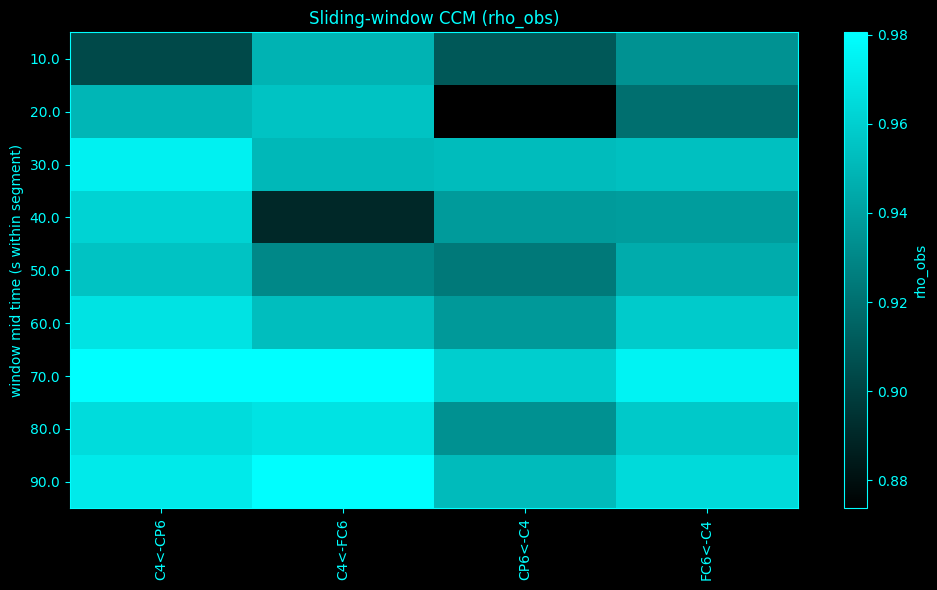

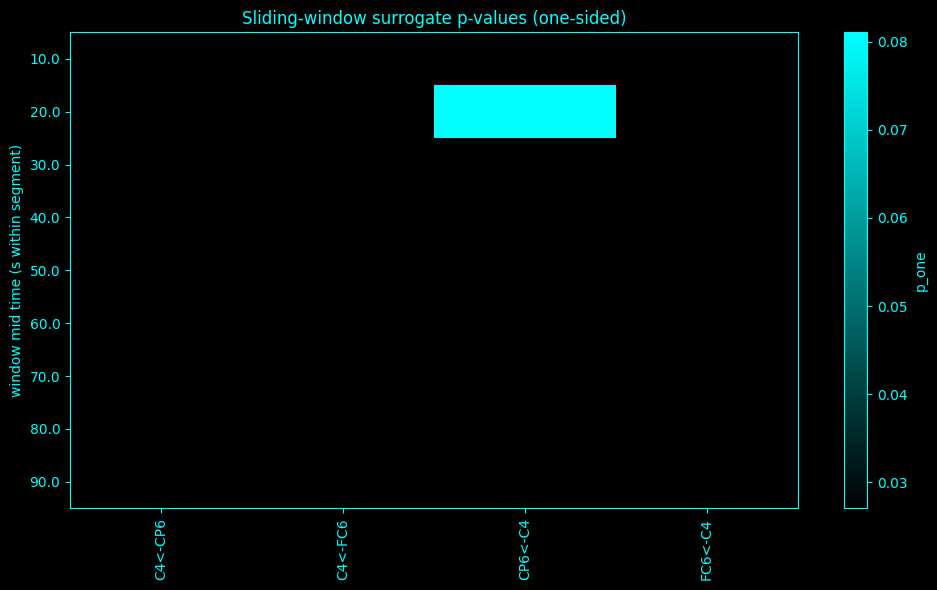

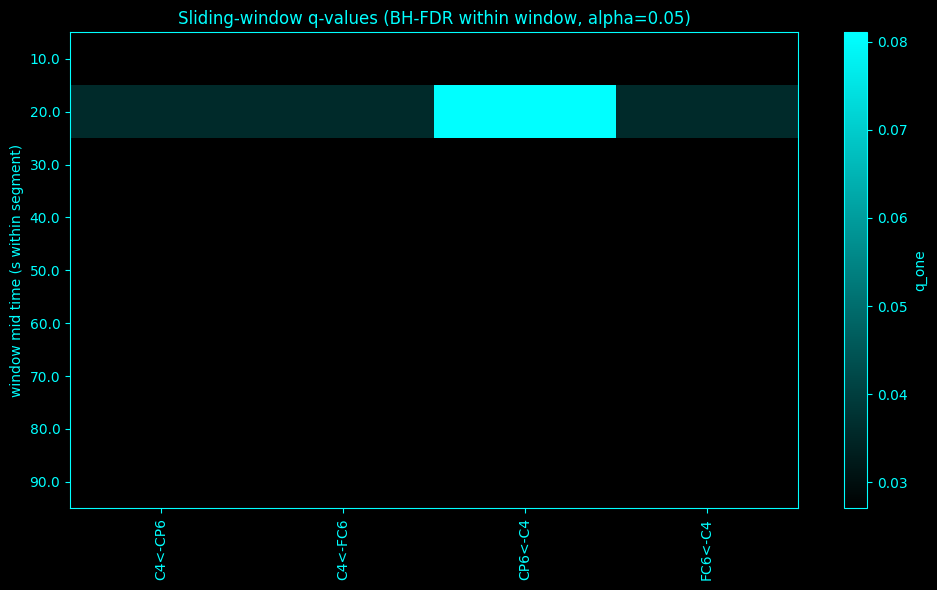

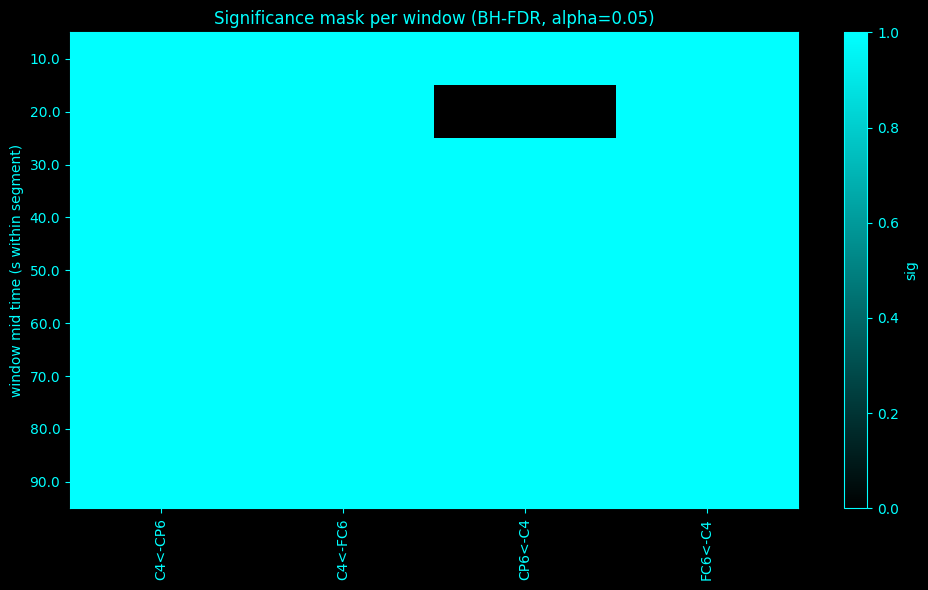

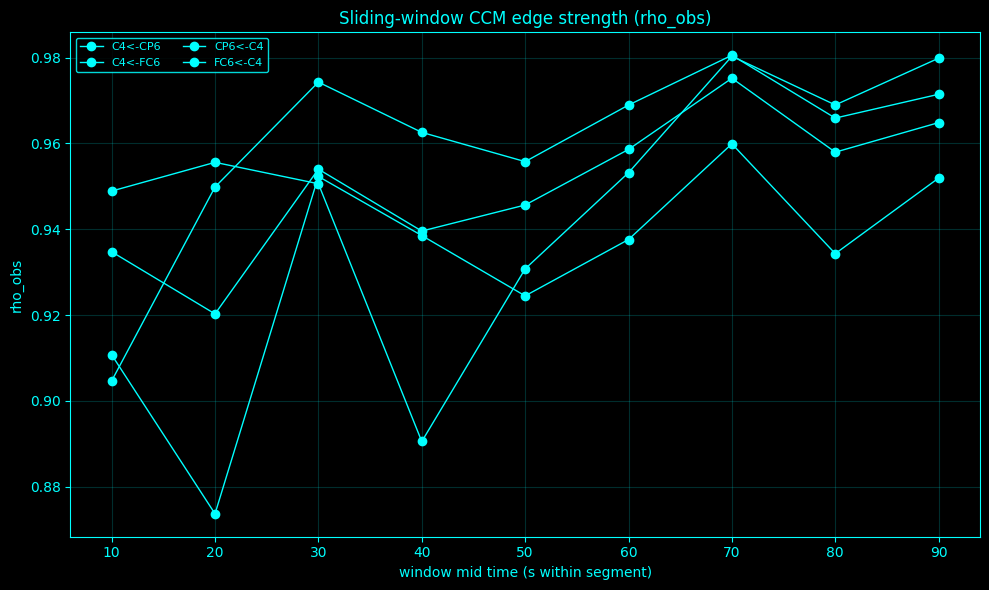

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_post_20260915_164627/node_strength_by_window.csv


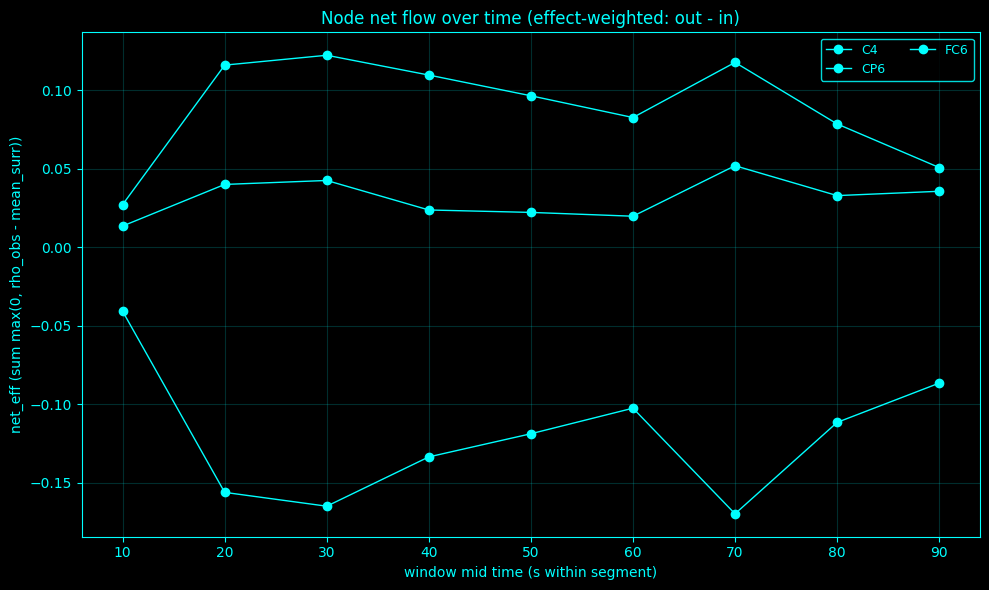

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_post_20260915_164627/directionality_pairs.csv


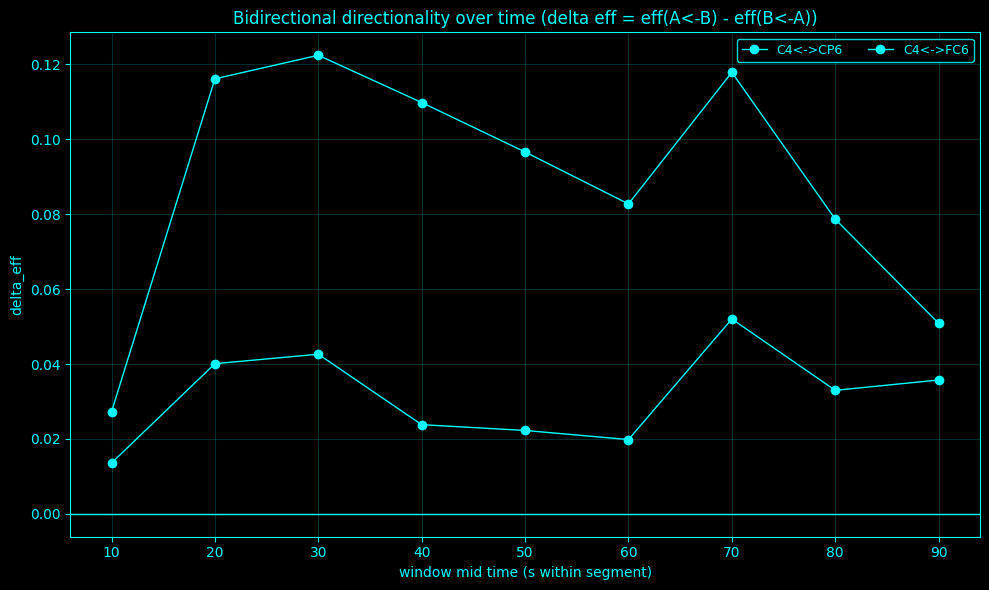


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_post_20260915_164627
  - ccm_time_results_postprocessed.csv
  - rho_obs_pivot.csv / p_one_pivot.csv / q_one_pivot.csv / sig_pivot.csv
  - rho_obs_heatmap.png / p_one_heatmap.png / q_one_heatmap.png / sig_mask.png
  - rho_obs_timeseries.png
  - node_strength_by_window.csv / node_net_flow_timeseries.png
  - directionality_pairs.csv / directionality_delta_eff_timeseries.png
  - edge_summary.csv / stable_edges.csv
DONE.


In [18]:
# Postprocess sliding-window CCM outputs (BH-FDR, effect-weighted flow, directionality)
# Reads ONLY saved CSV outputs from disk (no in-memory EEG arrays).

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG — ROBUST SAVED-RUN DISCOVERY
# =========================
_project_roots = [
    os.environ.get("NEURAL_SIGNAL_PROJECT_DIR"),
    "/home/a/projects/Complete-Neural-Signal-Analysis",
    "/home/a/projects/Explore-Neural-Signals1",
    os.getcwd(),
]
_project_roots = [
    os.path.abspath(os.path.expanduser(p))
    for p in _project_roots
    if p
]
_project_roots = list(dict.fromkeys(_project_roots))

# For labeling only (doesn't reload EEG)
fs = 1000
segment = (814.571, 921.515)

alpha = 0.05
sig_inclusive = False  # True => q <= alpha, False => q < alpha

# Set to a real run folder only if you explicitly want one.
# None auto-picks the newest completed ccm_time* run.
run_folder = None
base_dir = None

def ts():
    return time.strftime("%Y%m%d_%H%M%S")

# =========================
# Helpers
# =========================
def bh_qvals(pvals):
    """Benjamini–Hochberg q-values (FDR) for a 1D array of p-values."""
    p = np.asarray(pvals, dtype=float)
    m = p.size
    q = np.full(m, np.nan, dtype=float)

    ok = np.isfinite(p)
    if ok.sum() == 0:
        return q

    p_ok = p[ok]
    order = np.argsort(p_ok)
    ranks = np.arange(1, len(p_ok) + 1, dtype=float)

    q_sorted = p_ok[order] * (len(p_ok) / ranks)
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]  # enforce monotonicity
    q_sorted = np.clip(q_sorted, 0.0, 1.0)

    q_ok = np.empty_like(p_ok)
    q_ok[order] = q_sorted
    q[ok] = q_ok
    return q

def pick_latest_ccm_time_folder(search_roots):
    """Pick newest ccm_time* folder that actually contains a results CSV."""
    if isinstance(search_roots, (str, os.PathLike)):
        search_roots = [os.fspath(search_roots)]

    valid = []
    for root in search_roots:
        for folder in glob.glob(os.path.join(root, "ccm_time*")):
            if not os.path.isdir(folder):
                continue
            for name in ("ccm_time_results_with_q.csv", "ccm_time_results.csv"):
                p = os.path.join(folder, name)
                if os.path.isfile(p):
                    valid.append((os.path.getmtime(p), folder))
                    break

    if not valid:
        raise FileNotFoundError(
            "No completed ccm_time* run containing ccm_time_results*.csv "
            "was found. Searched:\n  - " + "\n  - ".join(search_roots)
        )

    valid.sort(key=lambda item: item[0])
    return valid[-1][1]

def load_results_csv(folder):
    # prefer the q-augmented file if present
    cand = [
        os.path.join(folder, "ccm_time_results_with_q.csv"),
        os.path.join(folder, "ccm_time_results.csv"),
    ]
    for p in cand:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find ccm_time_results*.csv in: {folder}")

# =========================
# Locate inputs / outputs
# =========================
if run_folder is None:
    run_folder = pick_latest_ccm_time_folder(_project_roots)

results_csv = load_results_csv(run_folder)
base_dir = os.path.dirname(os.path.abspath(run_folder))

out_dir = os.path.join(base_dir, f"ccm_post_{ts()}")
os.makedirs(out_dir, exist_ok=True)

print("Run folder:", run_folder)
print("Results CSV:", results_csv)
print("Segment (s):", segment, "| fs:", fs)
print("Postprocess output folder:", out_dir)

# =========================
# Load results
# =========================
df = pd.read_csv(results_csv)

required = {"window_idx", "target", "source", "rho_obs", "p_one"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found: {set(df.columns)}")

# Ensure numerics
for c in ["rho_obs", "p_one"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

if "rho_surr_mean" in df.columns:
    df["rho_surr_mean"] = pd.to_numeric(df["rho_surr_mean"], errors="coerce")
else:
    df["rho_surr_mean"] = 0.0  # fallback

# Build an edge label
df["edge"] = df["target"].astype(str) + "<-" + df["source"].astype(str)

# If no time columns, reconstruct approximate window mid-times if possible
if {"t_start_s", "t_end_s"}.issubset(df.columns):
    df["t_start_s"] = pd.to_numeric(df["t_start_s"], errors="coerce")
    df["t_end_s"]   = pd.to_numeric(df["t_end_s"], errors="coerce")
    times = df.groupby("window_idx")[["t_start_s", "t_end_s"]].mean()
    t_mid = 0.5 * (times["t_start_s"].values + times["t_end_s"].values)
    win_order = times.index.values
else:
    # If you didn't save times, use window_idx as x-axis
    win_order = np.sort(df["window_idx"].unique())
    t_mid = win_order.astype(float)

# =========================
# BH-FDR within each window
# =========================
if "q_one" not in df.columns or df["q_one"].isna().all():
    df["q_one"] = np.nan

for w in df["window_idx"].unique():
    mask = df["window_idx"] == w
    df.loc[mask, "q_one"] = bh_qvals(df.loc[mask, "p_one"].values)

if sig_inclusive:
    df["sig"] = (df["q_one"] <= alpha)
else:
    df["sig"] = (df["q_one"] < alpha)

# =========================
# Effect-weighted edge strength
# =========================
# eff = max(0, rho_obs - mean_surr)  (works even if nothing is significant)
df["eff"] = (df["rho_obs"] - df["rho_surr_mean"]).clip(lower=0.0)
df["eff_sig"] = df["eff"] * df["sig"].astype(float)

# Save augmented table
aug_csv = os.path.join(out_dir, "ccm_time_results_postprocessed.csv")
df.to_csv(aug_csv, index=False)
print("Saved:", aug_csv)

# =========================
# Pivot tables + heatmaps
# =========================
rho_piv = df.pivot_table(index="window_idx", columns="edge", values="rho_obs", aggfunc="mean")
p_piv   = df.pivot_table(index="window_idx", columns="edge", values="p_one",   aggfunc="mean")
q_piv   = df.pivot_table(index="window_idx", columns="edge", values="q_one",   aggfunc="mean")
sig_piv = df.pivot_table(index="window_idx", columns="edge", values="sig",     aggfunc="mean")

rho_piv.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))
p_piv.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))
q_piv.to_csv(os.path.join(out_dir, "q_one_pivot.csv"))
sig_piv.to_csv(os.path.join(out_dir, "sig_pivot.csv"))

def heatmap(mat, title, cbar_label, fname, xticks, yticks):
    plt.figure(figsize=(max(10, 0.55 * mat.shape[1]), 6))
    plt.imshow(mat.values, aspect="auto")
    plt.colorbar(label=cbar_label)
    plt.xticks(np.arange(mat.shape[1]), xticks, rotation=90)
    plt.yticks(np.arange(mat.shape[0]), yticks)
    plt.title(title)
    plt.ylabel("window mid time (s within segment)" if ("t_start_s" in df.columns) else "window_idx")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, fname), dpi=170)
    plt.show()
    plt.close()

xt = list(rho_piv.columns)
yt = [f"{x:.1f}" for x in t_mid] if ("t_start_s" in df.columns) else list(rho_piv.index.astype(str))

heatmap(rho_piv, "Sliding-window CCM (rho_obs)", "rho_obs", "rho_obs_heatmap.png", xt, yt)
heatmap(p_piv,   "Sliding-window surrogate p-values (one-sided)", "p_one", "p_one_heatmap.png", xt, yt)
heatmap(q_piv,   f"Sliding-window q-values (BH-FDR within window, alpha={alpha})", "q_one", "q_one_heatmap.png", xt, yt)
heatmap(sig_piv, f"Significance mask per window (BH-FDR, alpha={alpha})", "sig", "sig_mask.png", xt, yt)

# =========================
# Edge time series (rho_obs)
# =========================
plt.figure(figsize=(10, 6))
for col in rho_piv.columns:
    plt.plot(t_mid, rho_piv[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)" if ("t_start_s" in df.columns) else "window_idx")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.show()
plt.close()

# =========================
# Node flow over time (effect-weighted)
# =========================
nodes = sorted(set(df["source"]).union(set(df["target"])))

node_rows = []
for w in win_order:
    wdf = df[df["window_idx"] == w].copy()

    # raw effect flow (no significance gating)
    out_sum = wdf.groupby("source")["eff"].sum().to_dict()
    in_sum  = wdf.groupby("target")["eff"].sum().to_dict()

    # sig-gated effect flow
    wdf_sig = wdf[wdf["sig"]].copy()
    out_sig = wdf_sig.groupby("source")["eff"].sum().to_dict()
    in_sig  = wdf_sig.groupby("target")["eff"].sum().to_dict()

    for n in nodes:
        node_rows.append({
            "window_idx": w,
            "node": n,
            "out_eff": out_sum.get(n, 0.0),
            "in_eff":  in_sum.get(n, 0.0),
            "net_eff_out_minus_in": out_sum.get(n, 0.0) - in_sum.get(n, 0.0),
            "out_eff_sig": out_sig.get(n, 0.0),
            "in_eff_sig":  in_sig.get(n, 0.0),
            "net_eff_sig_out_minus_in": out_sig.get(n, 0.0) - in_sig.get(n, 0.0),
        })

node_df = pd.DataFrame(node_rows)
node_csv = os.path.join(out_dir, "node_strength_by_window.csv")
node_df.to_csv(node_csv, index=False)
print("Saved:", node_csv)

# Plot net flow (effect-weighted), keep only nodes that show any nonzero net (raw eff)
net_piv = node_df.pivot_table(index="window_idx", columns="node", values="net_eff_out_minus_in", aggfunc="mean")
nonzero_nodes = [c for c in net_piv.columns if np.nanmax(np.abs(net_piv[c].values)) > 1e-12]

plt.figure(figsize=(10, 6))
for n in nonzero_nodes:
    plt.plot(t_mid, net_piv[n].values, marker="o", linewidth=1, label=n)
plt.title("Node net flow over time (effect-weighted: out - in)")
plt.xlabel("window mid time (s within segment)" if ("t_start_s" in df.columns) else "window_idx")
plt.ylabel("net_eff (sum max(0, rho_obs - mean_surr))")
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "node_net_flow_timeseries.png"), dpi=170)
plt.show()
plt.close()

# =========================
# Bidirectional pair directionality over time (delta-eff)
# =========================
# Find pairs where both A<-B and B<-A exist
edges_set = set(df["edge"].unique())
pairs = []
for a in nodes:
    for b in nodes:
        if a >= b:
            continue
        if (f"{a}<-{b}" in edges_set) and (f"{b}<-{a}" in edges_set):
            pairs.append((a, b))

pair_rows = []
for (a, b) in pairs:
    for w in win_order:
        wdf = df[df["window_idx"] == w]
        rab = wdf[(wdf["target"] == a) & (wdf["source"] == b)]
        rba = wdf[(wdf["target"] == b) & (wdf["source"] == a)]
        if len(rab) == 0 or len(rba) == 0:
            continue

        # use mean in case duplicates exist
        eff_ab = float(rab["eff"].mean())
        eff_ba = float(rba["eff"].mean())
        rho_ab = float(rab["rho_obs"].mean())
        rho_ba = float(rba["rho_obs"].mean())
        q_ab   = float(rab["q_one"].mean())
        q_ba   = float(rba["q_one"].mean())

        pair_rows.append({
            "window_idx": w,
            "pair": f"{a}<->{b}",
            "A": a, "B": b,
            "eff_A_from_B": eff_ab,  # a <- b
            "eff_B_from_A": eff_ba,  # b <- a
            "delta_eff_AminusB": eff_ab - eff_ba,
            "rho_A_from_B": rho_ab,
            "rho_B_from_A": rho_ba,
            "delta_rho_AminusB": rho_ab - rho_ba,
            "q_A_from_B": q_ab,
            "q_B_from_A": q_ba,
        })

pair_df = pd.DataFrame(pair_rows)
pair_csv = os.path.join(out_dir, "directionality_pairs.csv")
pair_df.to_csv(pair_csv, index=False)
print("Saved:", pair_csv)

# Plot delta-eff per pair (positive => B drives A stronger than A drives B if you interpret A<-B)
if not pair_df.empty:
    plt.figure(figsize=(10, 6))
    for p in sorted(pair_df["pair"].unique()):
        sub = pair_df[pair_df["pair"] == p].sort_values("window_idx")
        plt.plot(t_mid, sub["delta_eff_AminusB"].values, marker="o", linewidth=1, label=p)
    plt.axhline(0.0, linewidth=1)
    plt.title("Bidirectional directionality over time (delta eff = eff(A<-B) - eff(B<-A))")
    plt.xlabel("window mid time (s within segment)" if ("t_start_s" in df.columns) else "window_idx")
    plt.ylabel("delta_eff")
    plt.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "directionality_delta_eff_timeseries.png"), dpi=170)
    plt.show()
    plt.close()

# =========================
# Edge summary + stable edges
# =========================
edge_summ = df.groupby(["edge", "target", "source"]).agg(
    rho_mean=("rho_obs", "mean"),
    rho_std=("rho_obs", "std"),
    p_min=("p_one", "min"),
    q_min=("q_one", "min"),
    sig_frac=("sig", "mean"),
    eff_mean=("eff", "mean"),
    eff_std=("eff", "std"),
).reset_index()

edge_summ.to_csv(os.path.join(out_dir, "edge_summary.csv"), index=False)

stable = edge_summ[edge_summ["sig_frac"] >= 0.5].copy()  # tweak threshold as you like
stable.to_csv(os.path.join(out_dir, "stable_edges.csv"), index=False)

print("\nSaved outputs to:", out_dir)
print("  - ccm_time_results_postprocessed.csv")
print("  - rho_obs_pivot.csv / p_one_pivot.csv / q_one_pivot.csv / sig_pivot.csv")
print("  - rho_obs_heatmap.png / p_one_heatmap.png / q_one_heatmap.png / sig_mask.png")
print("  - rho_obs_timeseries.png")
print("  - node_strength_by_window.csv / node_net_flow_timeseries.png")
print("  - directionality_pairs.csv / directionality_delta_eff_timeseries.png")
print("  - edge_summary.csv / stable_edges.csv")
print("DONE.")

### Sliding-window CCM postprocessing (BH-FDR within window, directionality, node net flow)

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — robust discovery and summary of CCM result tables</h3><p>This post-processing block searches for a compatible saved CCM table, verifies required columns, computes BH q-values, and visualizes edge strength, bidirectional asymmetry, and node summaries.</p><p>The BH step controls expected false-discovery proportion under its standard dependence assumptions; it does not convert CCM association into guaranteed causation.</p><p><b>Cell role.</b> The robust file-discovery logic is operational rather than a new mathematical method.</p></div>

$$q\text{-values are obtained from the monotone BH adjustment of the ordered }p\text{-values}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> When many hypotheses are tested, some small p-values occur by chance. Benjamini-Hochberg false-discovery-rate control ranks the p-values and chooses a threshold designed to limit the expected fraction of false discoveries among the results called significant. FDR control is less strict than controlling the probability of any false positive, which gives it more power in large exploratory analyses. The correction should be applied to a clearly defined family of related tests.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Search roots:
   /home/a/projects/Complete-Neural-Signal-Analysis
   /home/a/projects/Explore-Neural-Signals1
   /home/a/projects/Explore-Neural-Signals/Dynamical_Systems/split_notebooks
Segment (s): (814.571, 921.515) | fs: 1000
Requested run folder: None

No explicit valid run folder requested; auto-finding a completed run.

No valid results CSV found in requested folder. Searching under base_dir...

Found valid runs under base_dir (newest 10):
  mtime=2026-09-15 16:46:24  core=5 full=7  /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260915_164332/ccm_time_results_with_q.csv
  mtime=2026-09-15 15:58:20  core=5 full=7  /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260915_155754/ccm_time_results.csv
  mtime=2026-09-15 15:57:53  core=5 full=7  /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_optionA_20260915_155726/ccm_time_results.csv
  mtime=2026-09-15 15:57:25  core=5 full=7  /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_optionA_2026091

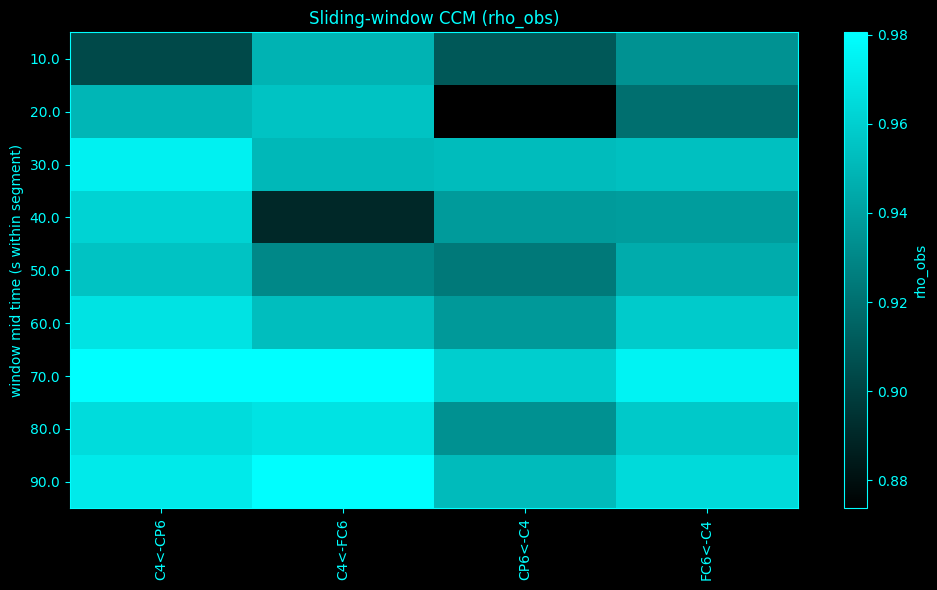

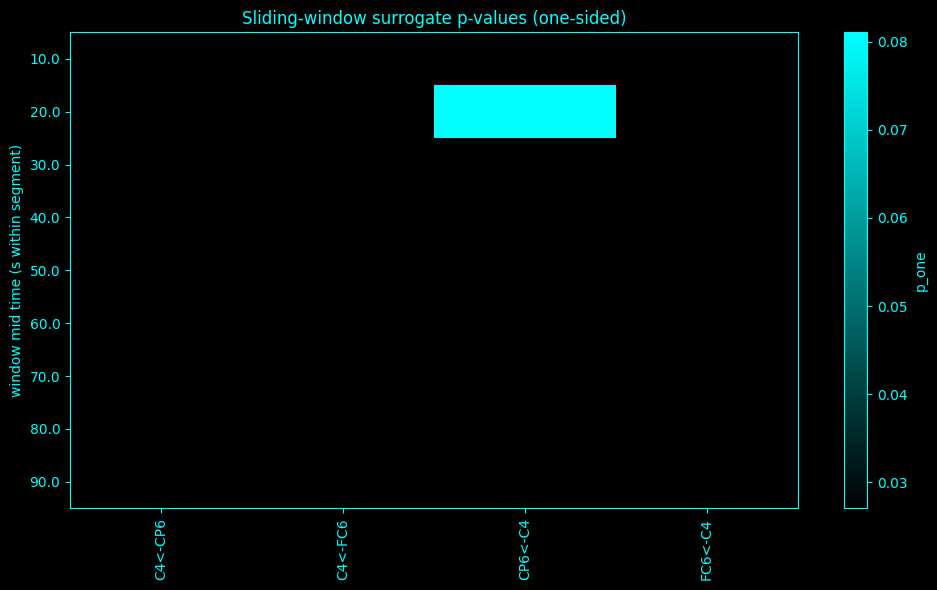

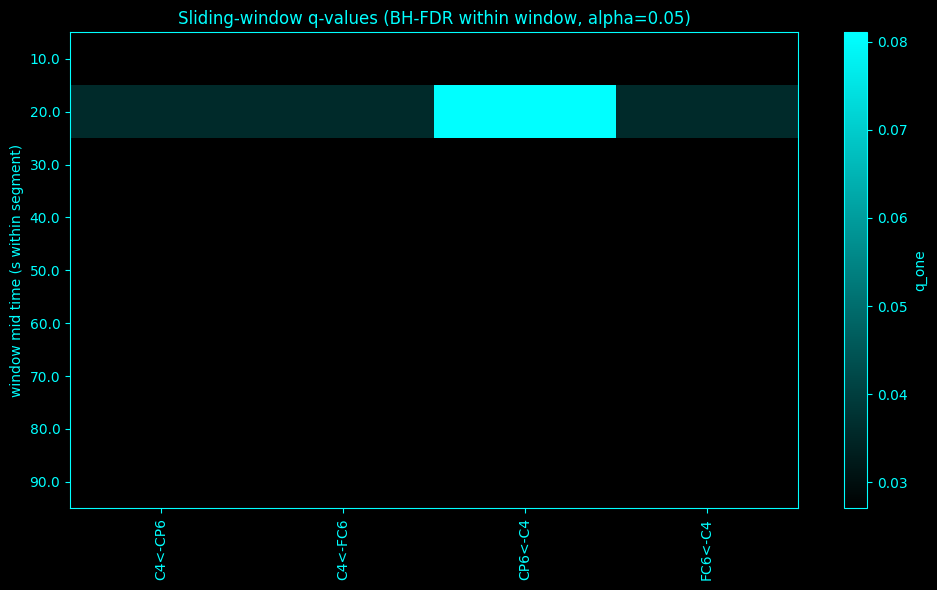

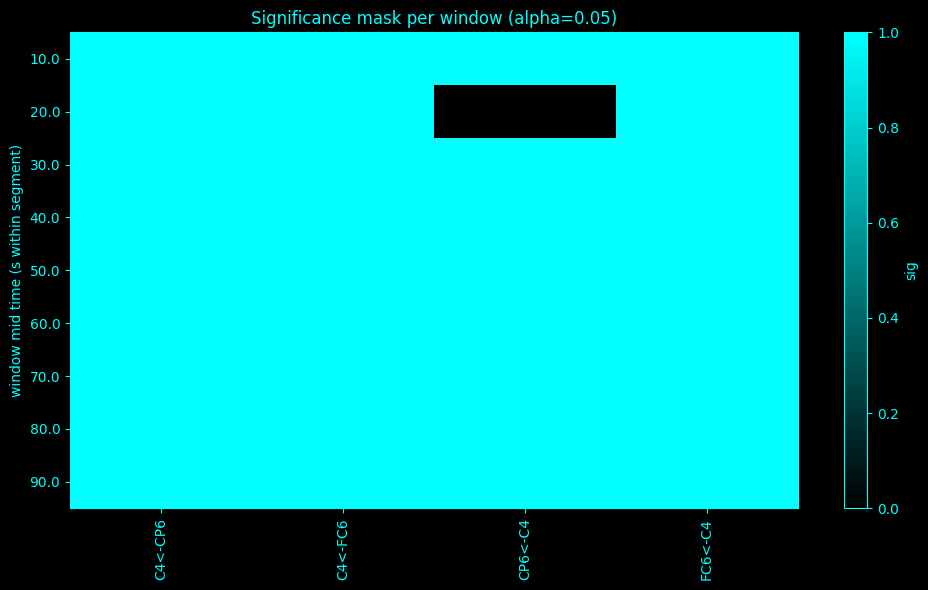

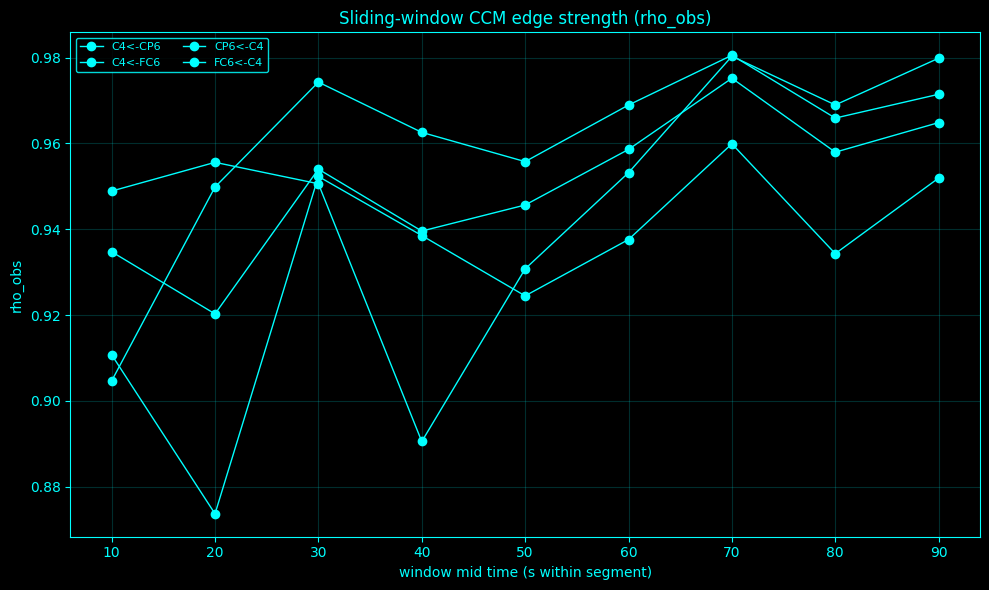

Saved directionality_pairs.csv


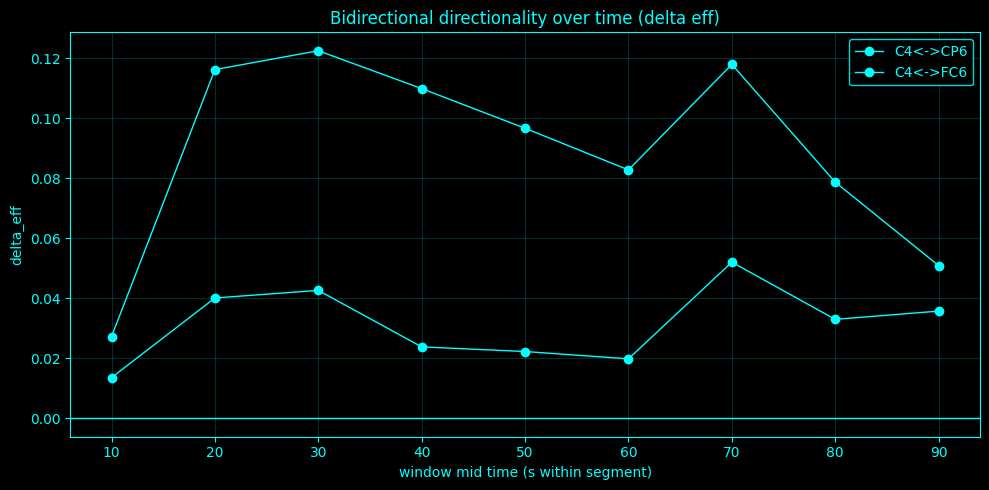

Saved node_strength_by_window.csv


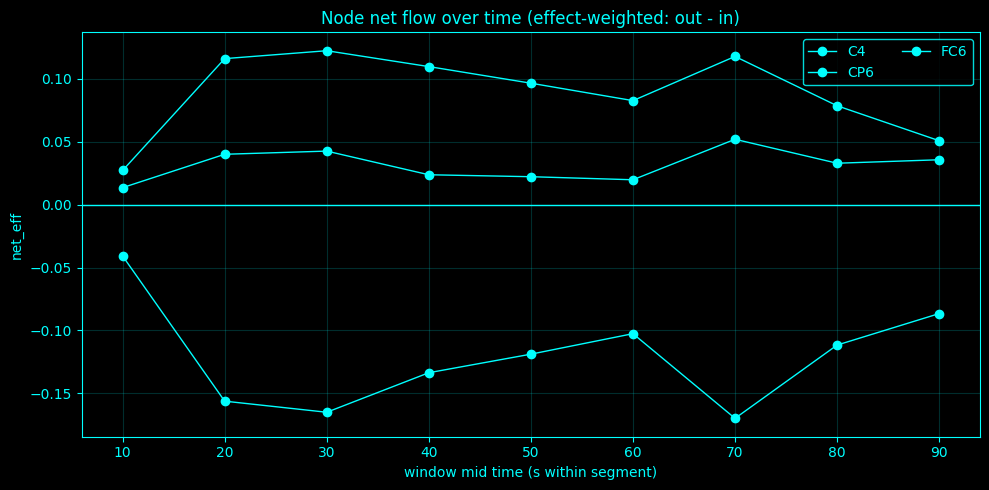

Saved edge_summary.csv and stable_edges.csv
Stable edges (sig_frac >= 0.8): 4 / 4

DONE. Outputs written to: /home/a/projects/Complete-Neural-Signal-Analysis/ccm_time_20260915_164332


In [19]:
# Sliding-window CCM postprocessing (robust run discovery; CSV-only)

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG — ROBUST SAVED-RUN DISCOVERY
# =========================
_project_roots = [
    os.environ.get("NEURAL_SIGNAL_PROJECT_DIR"),
    "/home/a/projects/Complete-Neural-Signal-Analysis",
    "/home/a/projects/Explore-Neural-Signals1",
    os.getcwd(),
]
_project_roots = [
    os.path.abspath(os.path.expanduser(p))
    for p in _project_roots
    if p
]
_project_roots = list(dict.fromkeys(_project_roots))

# Optional explicit run folder. Leave None to auto-find the newest valid run.
run_dir = None
base_dir = None

# labeling only
fs = 1000
segment = (814.571, 921.515)

alpha = 0.05
stable_sig_frac = 0.80

print("Search roots:")
for _root in _project_roots:
    print("  ", _root)
print("Segment (s):", segment, "| fs:", fs)
print("Requested run folder:", run_dir)

# =========================
# Helpers
# =========================
REQ_CORE = {"window_idx","target","source","rho_obs","p_one"}  # minimal required to postprocess
REQ_FULL = REQ_CORE | {"t_start_s","t_end_s"}                 # preferred but optional

def _safe_read_head(path, nrows=50):
    try:
        return pd.read_csv(path, nrows=nrows)
    except Exception:
        return None

def _score_results_csv(path):
    head = _safe_read_head(path, nrows=50)
    if head is None:
        return None
    cols = set(head.columns)
    hit_core = len(cols & REQ_CORE)
    hit_full = len(cols & REQ_FULL)
    # Prefer core hits, then full hits, then "bigger looking" tables
    # Use file mtime for tie-break later.
    return {
        "path": path,
        "hit_core": hit_core,
        "hit_full": hit_full,
        "ncols": len(cols),
        "has_edge": ("edge" in cols),
        "cols": cols,
        "mtime": os.path.getmtime(path)
    }

def find_best_results_csv(search_dir, recursive=True):
    pattern = os.path.join(search_dir, "**", "*.csv") if recursive else os.path.join(search_dir, "*.csv")
    paths = sorted(glob.glob(pattern, recursive=recursive))

    scored = []
    for p in paths:
        base = os.path.basename(p).lower()
        # Skip obvious non-results helper files if you want (not required)
        if base in {"top_edges_used.csv", "rho_obs_pivot.csv", "p_one_pivot.csv", "q_one_pivot.csv", "sig_pivot.csv"}:
            continue
        s = _score_results_csv(p)
        if s is None:
            continue
        # must contain at least the core columns
        if s["hit_core"] >= len(REQ_CORE):
            scored.append(s)

    if not scored:
        return None, []

    # sort: core match desc, full match desc, most recent desc
    scored.sort(key=lambda d: (d["hit_core"], d["hit_full"], d["mtime"]), reverse=True)
    return scored[0], scored

def fmt_time(ts):
    return time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(ts))

# =========================
# 1) Try requested run_dir
# =========================
best, scored = (None, [])
if run_dir and os.path.isdir(run_dir):
    best, scored = find_best_results_csv(run_dir, recursive=True)

    print("\nCandidates inside requested run folder (top 10):")
    # show also partial matches for debugging
    all_csv = sorted(glob.glob(os.path.join(run_dir, "**", "*.csv"), recursive=True))
    partial = []
    for p in all_csv:
        h = _safe_read_head(p, nrows=10)
        if h is None:
            continue
        cols = set(h.columns)
        hit = len(cols & REQ_CORE)
        partial.append((hit, os.path.getmtime(p), p, cols))
    partial.sort(key=lambda x: (x[0], x[1]), reverse=True)
    for hit, mt, p, _ in partial[:10]:
        print(f"  core_match={hit:2d}  mtime={fmt_time(mt)}  {os.path.relpath(p, run_dir)}")
else:
    print("\nNo explicit valid run folder requested; auto-finding a completed run.")

# =========================
# 2) If not found, auto-find newest valid run under base_dir
# =========================
if best is None:
    print("\nNo valid results CSV found in requested folder. Searching under base_dir...")

    # Look across all known project roots for completed ccm_time* runs.
    global_scored = []
    for _root in _project_roots:
        run_candidates = sorted(glob.glob(os.path.join(_root, "ccm_time*")))
        for rd in run_candidates:
            if not os.path.isdir(rd):
                continue
            b, sc = find_best_results_csv(rd, recursive=True)
            if b is not None:
                global_scored.append(b)

    if not global_scored:
        raise FileNotFoundError(
            "Could not find ANY completed sliding-window CCM results CSV.\n"
            f"Expected columns at least: {sorted(list(REQ_CORE))}\n"
            "Searched roots:\n  - " + "\n  - ".join(_project_roots) +
            "\nSet run_dir to a real run folder or set NEURAL_SIGNAL_PROJECT_DIR."
        )

    global_scored.sort(key=lambda d: d["mtime"], reverse=True)
    best = global_scored[0]

    print("\nFound valid runs under base_dir (newest 10):")
    for d in global_scored[:10]:
        print(f"  mtime={fmt_time(d['mtime'])}  core={d['hit_core']} full={d['hit_full']}  {d['path']}")

# =========================
# Load selected results
# =========================
results_path = best["path"]
out_dir = os.path.dirname(results_path)
base_dir = os.path.dirname(out_dir)

print("\nSelected results CSV:", results_path)
print("Output folder (same as results):", out_dir)

df = pd.read_csv(results_path)

# Build edge label if missing
if "edge" not in df.columns:
    df["edge"] = df["target"].astype(str) + "<-" + df["source"].astype(str)

# Ensure times exist; if missing, create placeholder based on window ordering
if ("t_start_s" not in df.columns) or ("t_end_s" not in df.columns):
    print("NOTE: t_start_s/t_end_s missing; creating placeholders from window order (labels only).")
    w_sorted = np.sort(df["window_idx"].unique())
    w_to_i = {w:i for i,w in enumerate(w_sorted)}
    wi = df["window_idx"].map(w_to_i).astype(int)
    df["t_start_s"] = wi.astype(float)
    df["t_end_s"] = wi.astype(float) + 1.0

# Numeric casts
df["p_one"] = pd.to_numeric(df["p_one"], errors="coerce")
df["rho_obs"] = pd.to_numeric(df["rho_obs"], errors="coerce")

# =========================
# BH-FDR
# =========================
def bh_qvalues(pvals):
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * m / (np.arange(1, m+1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty(m, dtype=float)
    out[order] = q
    return out

df["q_one"] = np.nan
df["sig"] = False

for w, g in df.groupby("window_idx", sort=True):
    idx = g.index.values
    p = g["p_one"].values.astype(float)
    ok = np.isfinite(p)
    if ok.sum() == 0:
        continue
    q = np.full(len(p), np.nan, dtype=float)
    q[ok] = bh_qvalues(p[ok])
    df.loc[idx, "q_one"] = q
    df.loc[idx, "sig"] = (q <= alpha)

# =========================
# Effect size
# eff = max(0, rho_obs - rho_surr_mean)
# =========================
if "rho_surr_mean" in df.columns:
    df["rho_surr_mean"] = pd.to_numeric(df["rho_surr_mean"], errors="coerce")
    df["eff"] = (df["rho_obs"] - df["rho_surr_mean"]).clip(lower=0.0)
else:
    print("WARNING: rho_surr_mean missing; eff will be NaN.")
    df["eff"] = np.nan

# Save postprocessed table
post_path = os.path.join(out_dir, "ccm_time_results_postprocessed.csv")
df.to_csv(post_path, index=False)
print("\nSaved:", post_path)

# =========================
# Pivots
# =========================
rho_piv = df.pivot_table(index="window_idx", columns="edge", values="rho_obs")
p_piv   = df.pivot_table(index="window_idx", columns="edge", values="p_one")
q_piv   = df.pivot_table(index="window_idx", columns="edge", values="q_one")
sig_piv = df.pivot_table(index="window_idx", columns="edge", values="sig").astype(float)
eff_piv = df.pivot_table(index="window_idx", columns="edge", values="eff")

rho_piv.to_csv(os.path.join(out_dir, "rho_obs_pivot.csv"))
p_piv.to_csv(os.path.join(out_dir, "p_one_pivot.csv"))
q_piv.to_csv(os.path.join(out_dir, "q_one_pivot.csv"))
sig_piv.to_csv(os.path.join(out_dir, "sig_pivot.csv"))
eff_piv.to_csv(os.path.join(out_dir, "eff_pivot.csv"))

times = df.groupby("window_idx")[["t_start_s","t_end_s"]].mean().sort_index()
t_mid = 0.5*(times["t_start_s"].values + times["t_end_s"].values)

# =========================
# Plot helper
# =========================
def heatmap(mat, title, cbar_label, out_png):
    plt.figure(figsize=(max(10, 0.55*mat.shape[1]), 6))
    plt.imshow(mat.values, aspect="auto")
    plt.colorbar(label=cbar_label)
    plt.yticks(np.arange(len(t_mid)), [f"{x:.1f}" for x in t_mid])
    plt.xticks(np.arange(mat.shape[1]), mat.columns, rotation=90)
    plt.title(title)
    plt.ylabel("window mid time (s within segment)")
    plt.tight_layout()
    plt.savefig(out_png, dpi=170)
    plt.show()
    plt.close()

heatmap(rho_piv, "Sliding-window CCM (rho_obs)", "rho_obs",
        os.path.join(out_dir, "rho_obs_heatmap.png"))
heatmap(p_piv, "Sliding-window surrogate p-values (one-sided)", "p_one",
        os.path.join(out_dir, "p_one_heatmap.png"))
heatmap(q_piv, f"Sliding-window q-values (BH-FDR within window, alpha={alpha})", "q_one",
        os.path.join(out_dir, "q_one_heatmap.png"))
heatmap(sig_piv, f"Significance mask per window (alpha={alpha})", "sig",
        os.path.join(out_dir, "sig_mask.png"))

# Edge time series
plt.figure(figsize=(10, 6))
for col in rho_piv.columns:
    plt.plot(t_mid, rho_piv[col].values, marker="o", linewidth=1, label=col)
plt.title("Sliding-window CCM edge strength (rho_obs)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("rho_obs")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "rho_obs_timeseries.png"), dpi=170)
plt.show()
plt.close()

# =========================
# Directionality for bidirectional pairs (effect-weighted)
# =========================
edges = set(df["edge"].unique())
pairs = []
for e in edges:
    tgt, src = e.split("<-")
    rev = f"{src}<-{tgt}"
    if rev in edges:
        pairs.append(tuple(sorted([tgt, src])))
pairs = sorted(set(pairs))

pair_rows = []
delta_cols = {}

for a, b in pairs:
    e_ab = f"{a}<-{b}"
    e_ba = f"{b}<-{a}"
    if e_ab not in eff_piv.columns or e_ba not in eff_piv.columns:
        continue
    delta = eff_piv[e_ab] - eff_piv[e_ba]
    delta_cols[f"{a}<->{b}"] = delta
    pair_rows.append({
        "pair": f"{a}<->{b}",
        "edge_pos": e_ab,
        "edge_neg": e_ba,
        "delta_eff_mean": float(delta.mean()),
        "delta_eff_std": float(delta.std(ddof=1)),
        "wins_pos": int((delta > 0).sum()),
        "wins_neg": int((delta < 0).sum())
    })

if pair_rows:
    pairs_df = pd.DataFrame(pair_rows)
    pairs_df.to_csv(os.path.join(out_dir, "directionality_pairs.csv"), index=False)
    print("Saved directionality_pairs.csv")

    delta_df = pd.DataFrame(delta_cols)
    plt.figure(figsize=(10, 5))
    for col in delta_df.columns:
        plt.plot(t_mid, delta_df[col].values, marker="o", linewidth=1, label=col)
    plt.axhline(0, linewidth=1)
    plt.title("Bidirectional directionality over time (delta eff)")
    plt.xlabel("window mid time (s within segment)")
    plt.ylabel("delta_eff")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "directionality_delta_eff_timeseries.png"), dpi=170)
    plt.show()
    plt.close()
else:
    print("No bidirectional pairs found; skipping directionality plots.")

# =========================
# Node net flow (effect-weighted out - in)
# =========================
nodes = sorted(set(df["source"]).union(set(df["target"])))
node_rows = []

for w in sorted(df["window_idx"].unique()):
    gw = df[df["window_idx"] == w]
    for n in nodes:
        out_sum = float(np.nansum(gw.loc[gw["source"] == n, "eff"].values))
        in_sum  = float(np.nansum(gw.loc[gw["target"] == n, "eff"].values))
        node_rows.append({
            "window_idx": w,
            "node": n,
            "out_eff_sum": out_sum,
            "in_eff_sum": in_sum,
            "net_eff_out_minus_in": out_sum - in_sum
        })

node_df = pd.DataFrame(node_rows)
node_df.to_csv(os.path.join(out_dir, "node_strength_by_window.csv"), index=False)
print("Saved node_strength_by_window.csv")

net_piv = node_df.pivot_table(index="window_idx", columns="node", values="net_eff_out_minus_in").reindex(rho_piv.index)

plt.figure(figsize=(10, 5))
for col in net_piv.columns:
    plt.plot(t_mid, net_piv[col].values, marker="o", linewidth=1, label=col)
plt.axhline(0, linewidth=1)
plt.title("Node net flow over time (effect-weighted: out - in)")
plt.xlabel("window mid time (s within segment)")
plt.ylabel("net_eff")
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "node_net_flow_timeseries.png"), dpi=170)
plt.show()
plt.close()

# =========================
# Edge summary + stable edges
# =========================
edge_summary = df.groupby(["edge","target","source"]).agg(
    rho_obs_mean=("rho_obs","mean"),
    rho_obs_std=("rho_obs","std"),
    eff_mean=("eff","mean"),
    eff_std=("eff","std"),
    p_one_min=("p_one","min"),
    q_one_min=("q_one","min"),
    sig_frac=("sig","mean"),
).reset_index().sort_values(["sig_frac","eff_mean"], ascending=[False, False])

edge_summary.to_csv(os.path.join(out_dir, "edge_summary.csv"), index=False)
stable = edge_summary[edge_summary["sig_frac"] >= stable_sig_frac].copy()
stable.to_csv(os.path.join(out_dir, "stable_edges.csv"), index=False)

print("Saved edge_summary.csv and stable_edges.csv")
print(f"Stable edges (sig_frac >= {stable_sig_frac}): {len(stable)} / {len(edge_summary)}")

# =========================
# Summary text
# =========================
with open(os.path.join(out_dir, "summary.txt"), "w") as f:
    f.write(f"Segment (s): {segment} | fs={fs}\n")
    f.write(f"Results CSV: {results_path}\n")
    f.write(f"Output folder: {out_dir}\n")
    f.write(f"Edges: {df['edge'].nunique()} | Windows: {df['window_idx'].nunique()}\n")
    f.write(f"BH-FDR alpha={alpha}\n")
    f.write(f"Significant fraction overall: {df['sig'].mean():.4f}\n")
    if "n_surr_valid" in df.columns:
        f.write(f"n_surr_valid min/max: {df['n_surr_valid'].min()} / {df['n_surr_valid'].max()}\n")

print("\nDONE. Outputs written to:", out_dir)

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — recurrence quantification analysis of reconstructed EEG states</h3><p>A recurrence matrix records when two reconstructed states fall within radius $\varepsilon$. This cell chooses $\varepsilon$ to target a recurrence density and computes standard RQA statistics while excluding a Theiler band around the main diagonal.</p><p>Diagonal line structures reflect repeated trajectory evolution; vertical line structures reflect laminar residence. DET and LAM are fractions of recurrence points participating in those structures, not probabilities of determinism or laminarity in a theorem-level sense.</p><p><b>Cell role.</b> Speed modes reduce sampled states used for radius estimation and plots.</p></div>

$$R_{ij}=\mathbf1\{\|X_i-X_j\|\le\varepsilon,\ |i-j|>W\},\qquad RR=\frac{\sum R_{ij}}{\#\text{ admissible pairs}}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Recurrence analysis compares pairs of reconstructed states and marks them as recurrent when their distance is below a chosen threshold. The recurrence rate is simply the fraction of state pairs that satisfy this condition. Diagonal line structures indicate that similar state sequences evolve in similar ways for several steps, which motivates determinism-related measures. Vertical line structures indicate that the trajectory stays near a region of state space for several samples, which motivates laminarity-related measures. These quantities depend on embedding choices, distance scaling, and the recurrence threshold, so those settings should be held consistent when channels are compared.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Using 2-D embedding archive: /home/a/projects/Complete-Neural-Signal-Analysis/2d_embedded_data.zip
[LOAD OK] Fp1: (106940, 2)
[LOAD OK] Fpz: (106940, 2)
[LOAD OK] Fp2: (106940, 2)
[LOAD OK] F7: (106940, 2)
[LOAD OK] F3: (106940, 2)
[LOAD OK] Fz: (106941, 2)
[LOAD OK] F4: (106941, 2)
[LOAD OK] F8: (106940, 2)
[LOAD OK] FC5: (106942, 2)
[LOAD OK] FC1: (106940, 2)
[LOAD OK] FC2: (106941, 2)
[LOAD OK] FC6: (106940, 2)
[LOAD OK] M1: (106940, 2)
[LOAD OK] T7: (106942, 2)
[LOAD OK] C3: (106940, 2)
[LOAD OK] Cz: (106942, 2)
[LOAD OK] C4: (106941, 2)
[LOAD OK] T8: (106940, 2)
[LOAD OK] M2: (106940, 2)
[LOAD OK] CP5: (106941, 2)
[LOAD OK] CP1: (106940, 2)
[LOAD OK] CP2: (106942, 2)
[LOAD OK] CP6: (106940, 2)
[LOAD OK] P7: (106942, 2)
[LOAD OK] P3: (106940, 2)
[LOAD OK] Pz: (106941, 2)
[LOAD OK] P4: (106942, 2)
[LOAD OK] P8: (106940, 2)
[LOAD OK] POz: (106940, 2)
[LOAD OK] O1: (106940, 2)
[LOAD OK] Oz: (106942, 2)
[LOAD OK] O2: (106940, 2)


2 warnings generated.


[RQA OK] Fp1
[RQA OK] Fpz
[RQA OK] Fp2
[RQA OK] F7
[RQA OK] F3
[RQA OK] Fz
[RQA OK] F4
[RQA OK] F8
[RQA OK] FC5
[RQA OK] FC1
[RQA OK] FC2
[RQA OK] FC6
[RQA OK] M1
[RQA OK] T7
[RQA OK] C3
[RQA OK] Cz
[RQA OK] C4
[RQA OK] T8
[RQA OK] M2
[RQA OK] CP5
[RQA OK] CP1
[RQA OK] CP2
[RQA OK] CP6
[RQA OK] P7
[RQA OK] P3
[RQA OK] Pz
[RQA OK] P4
[RQA OK] P8
[RQA OK] POz
[RQA OK] O1
[RQA OK] Oz
[RQA OK] O2

Saved: /home/a/projects/Complete-Neural-Signal-Analysis/rqa_results_fixed/rqa_results.csv


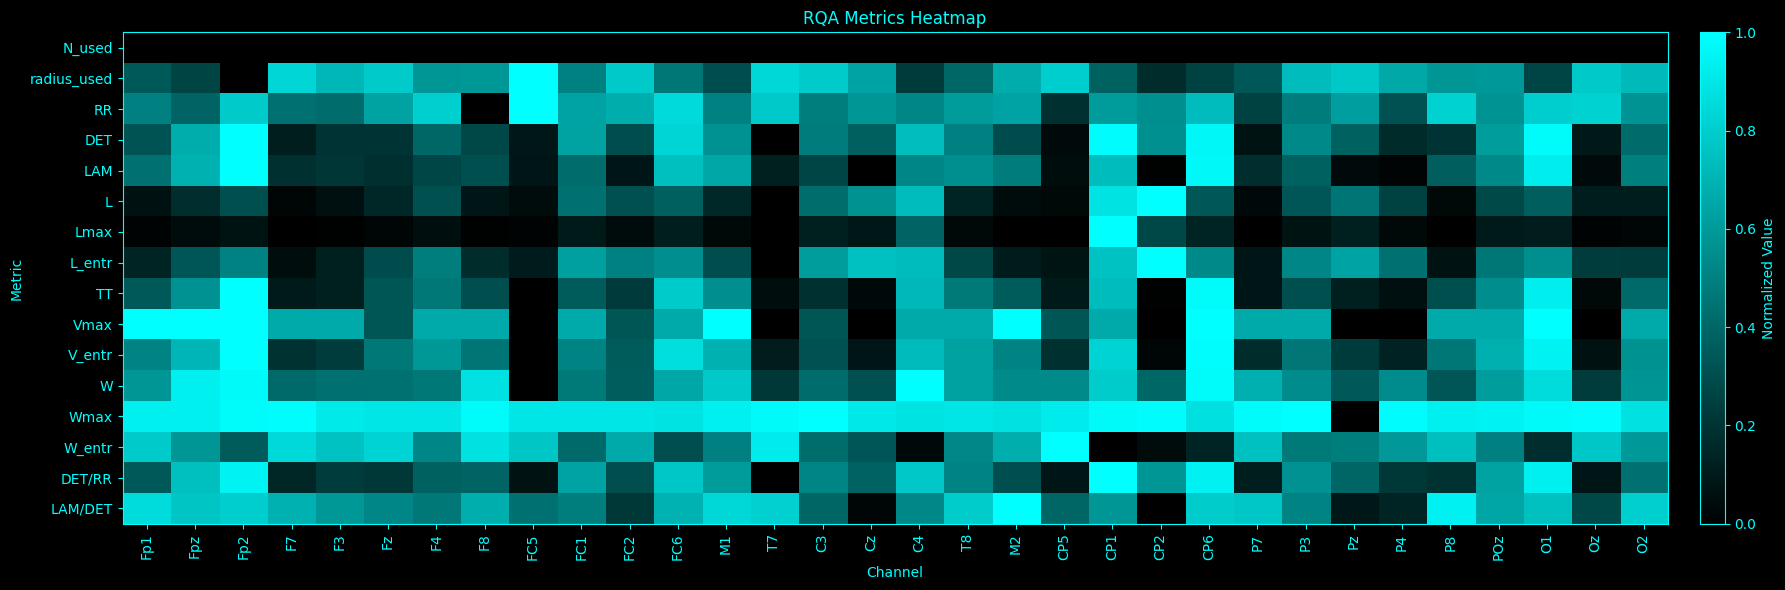

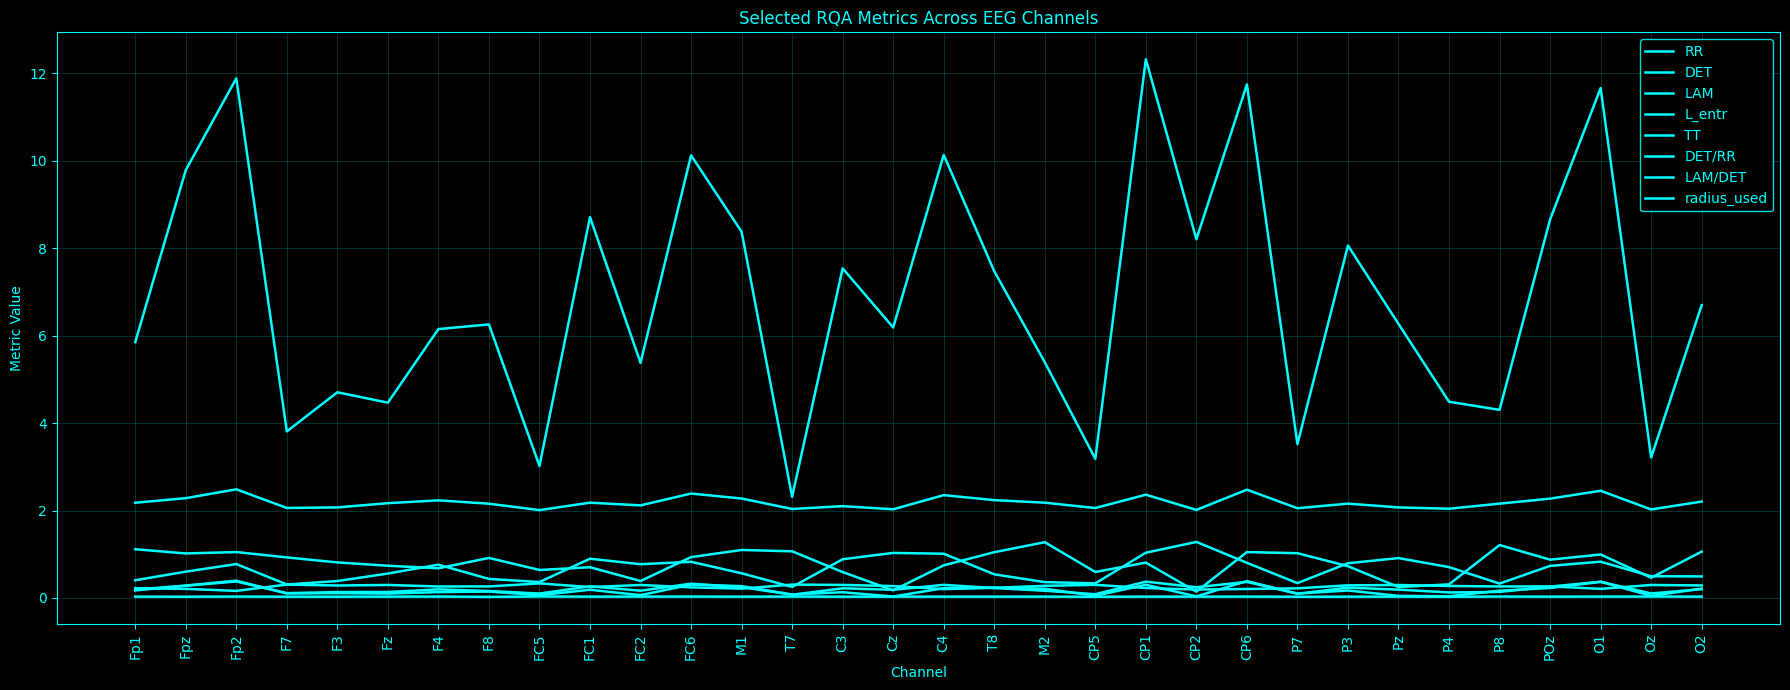

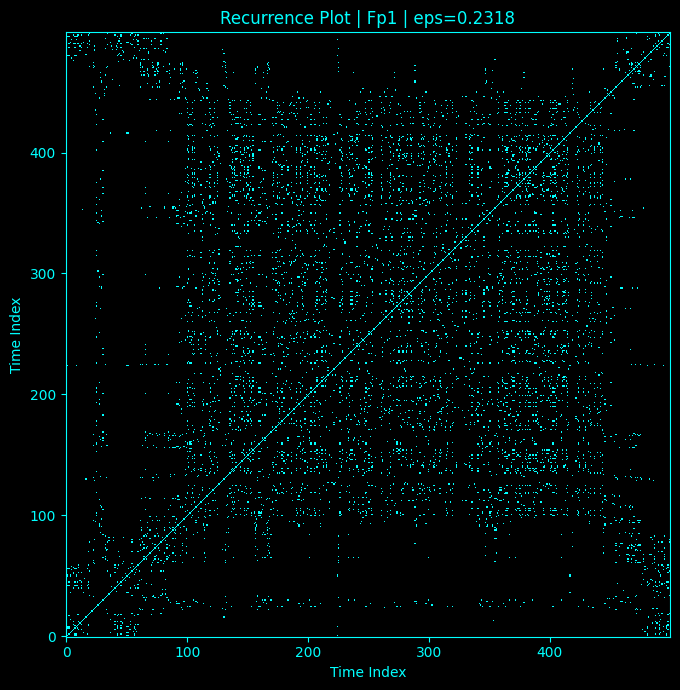

[RP OK] Fp1


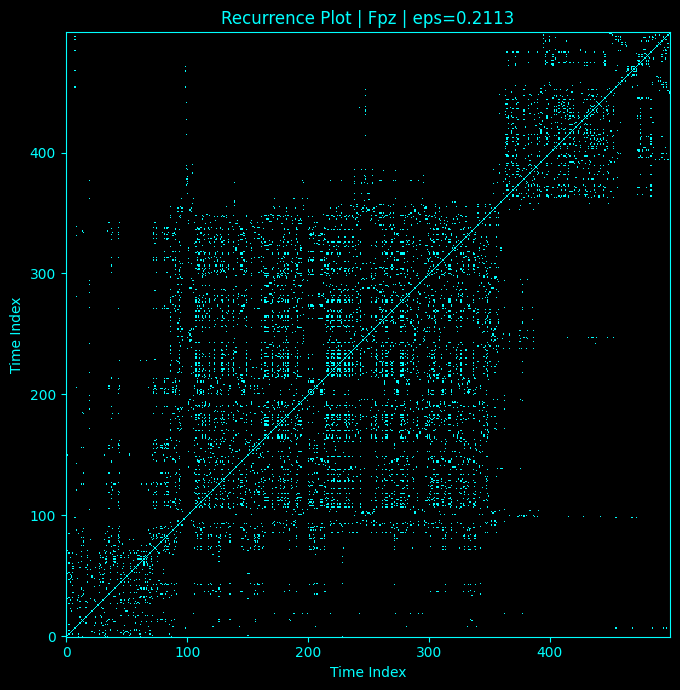

[RP OK] Fpz


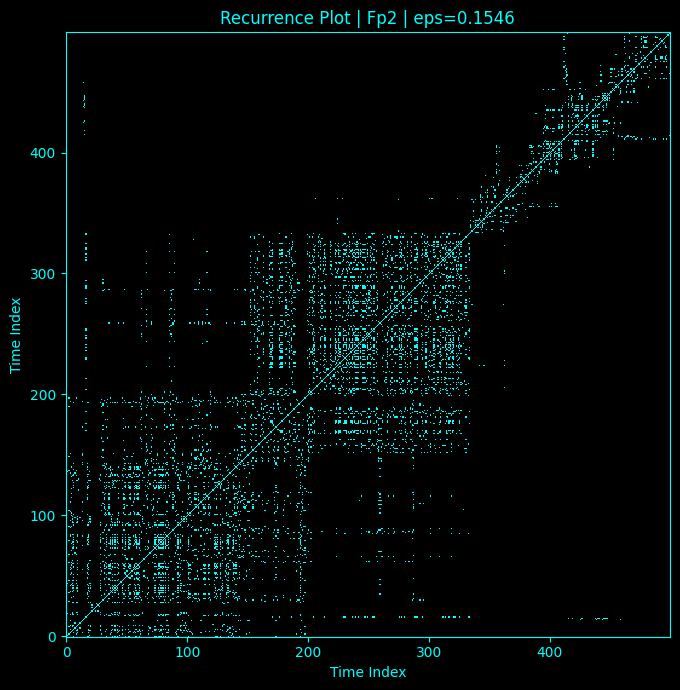

[RP OK] Fp2


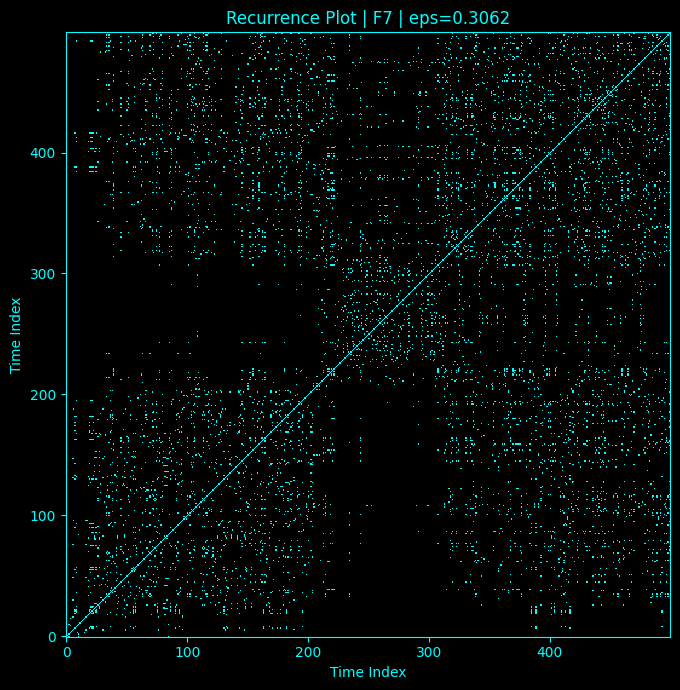

[RP OK] F7


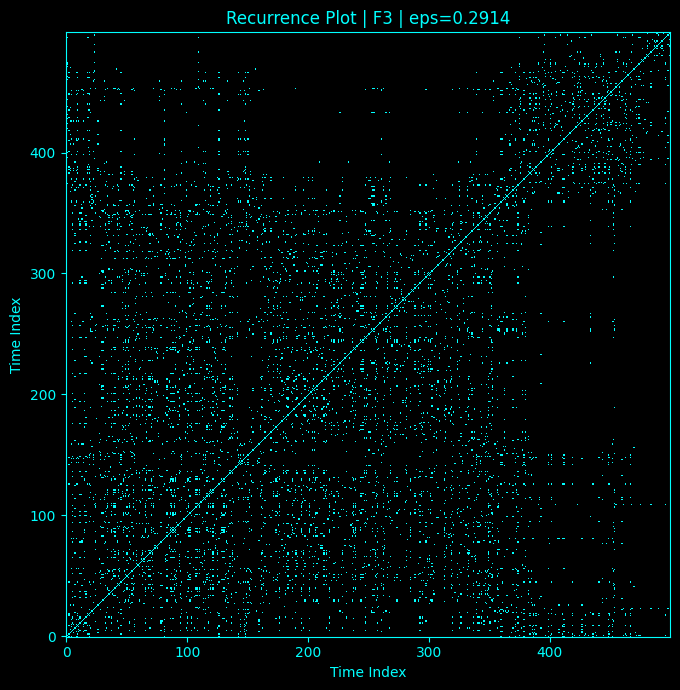

[RP OK] F3


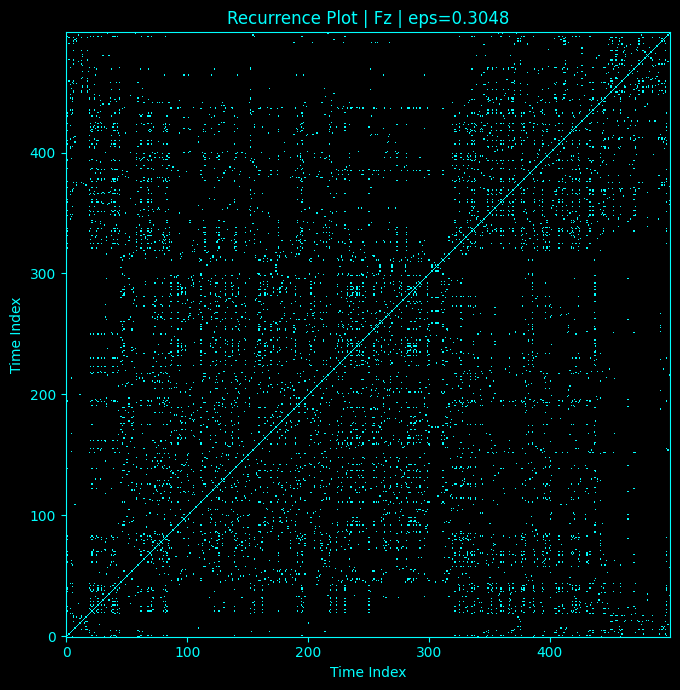

[RP OK] Fz


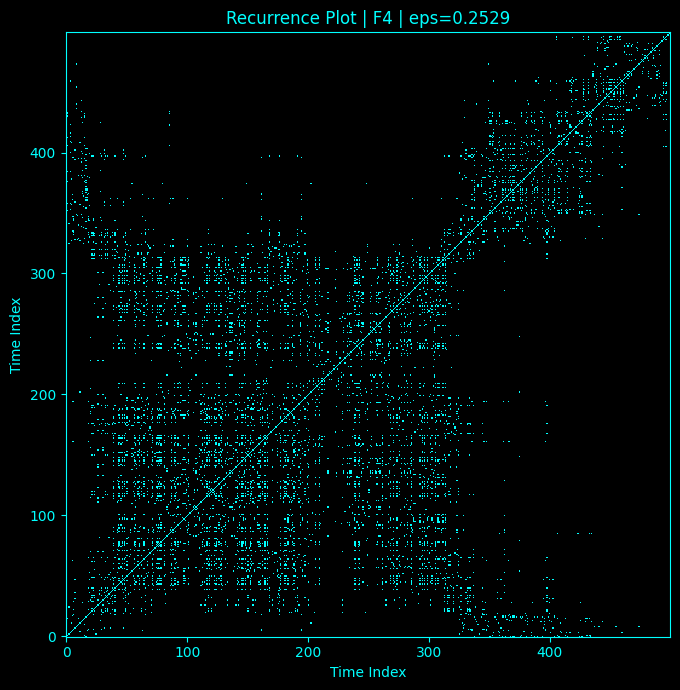

[RP OK] F4


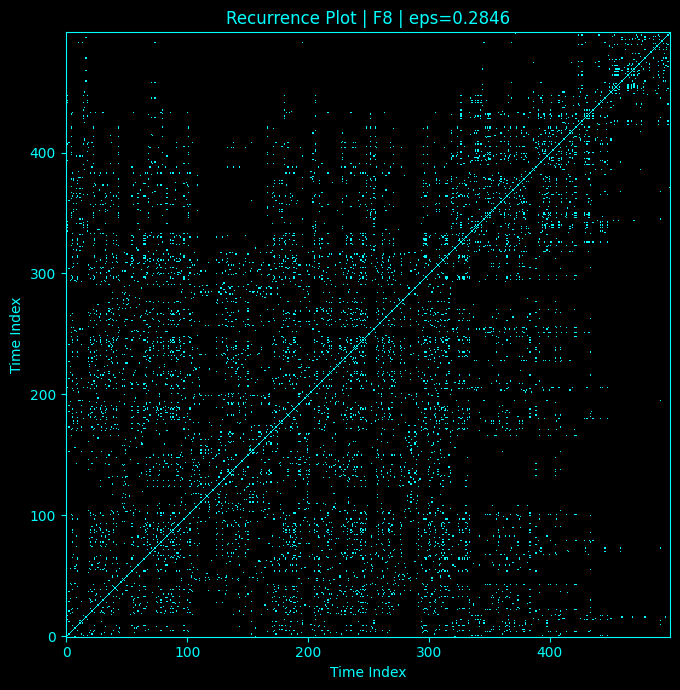

[RP OK] F8


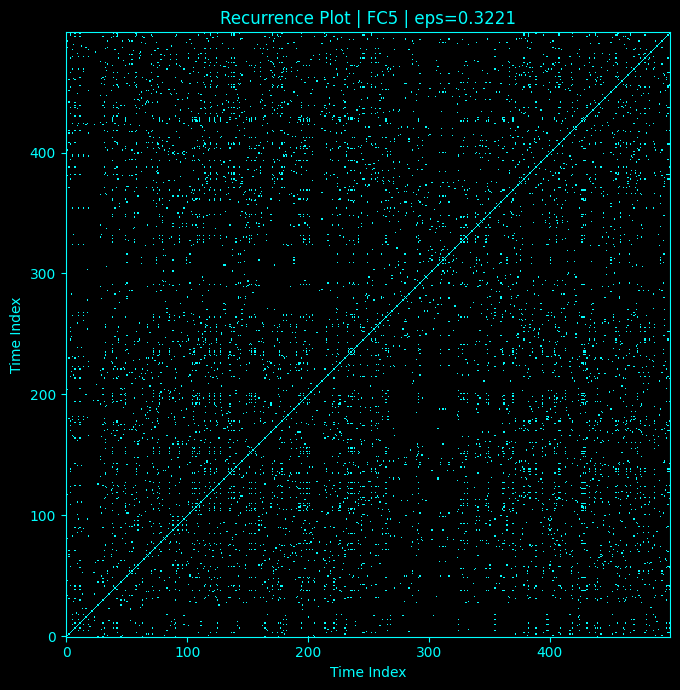

[RP OK] FC5


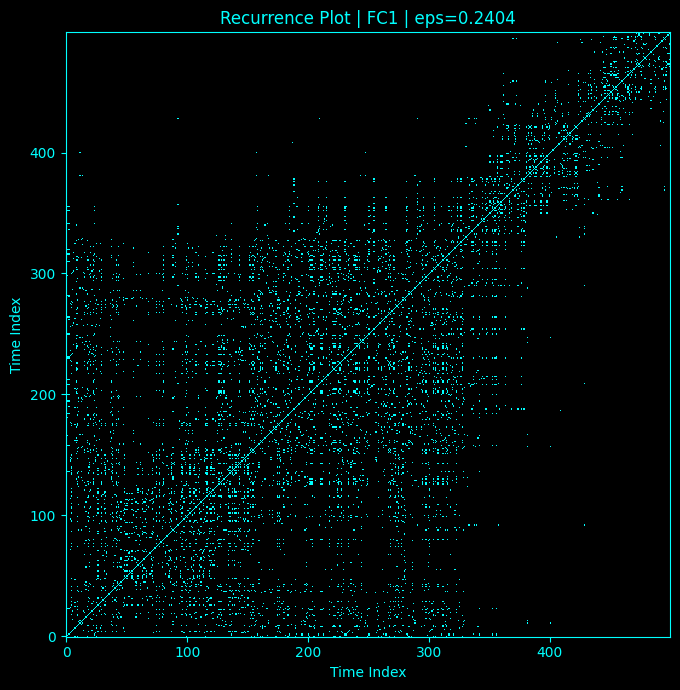

[RP OK] FC1


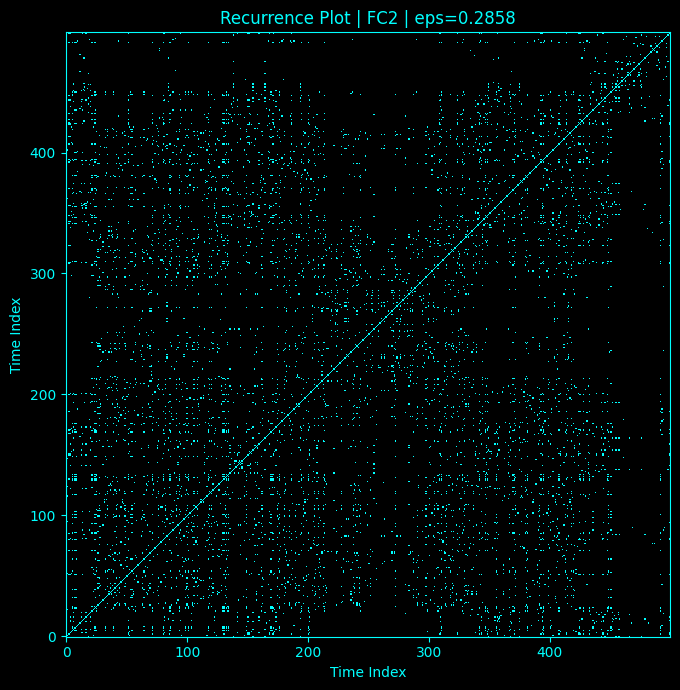

[RP OK] FC2


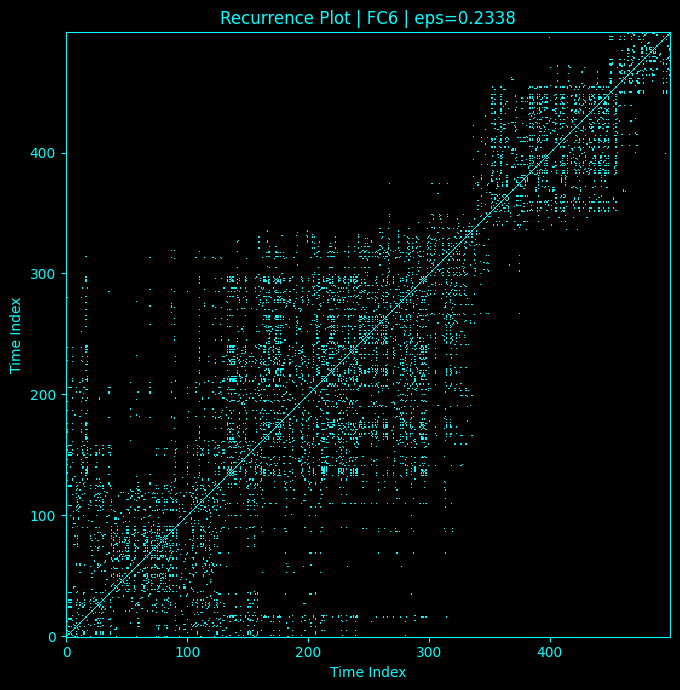

[RP OK] FC6


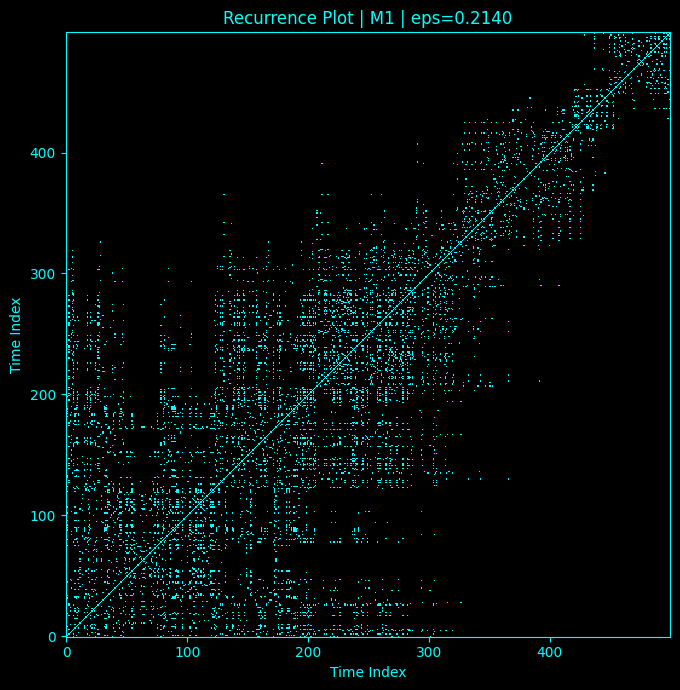

[RP OK] M1


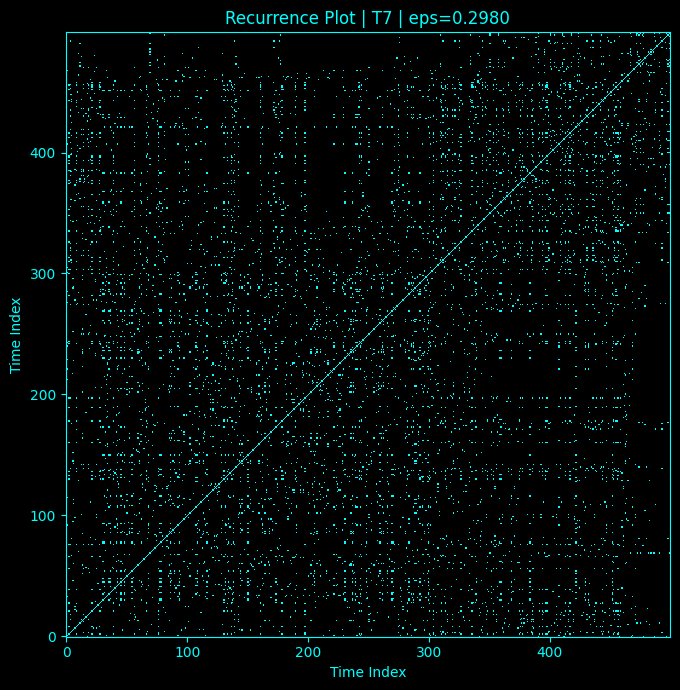

[RP OK] T7


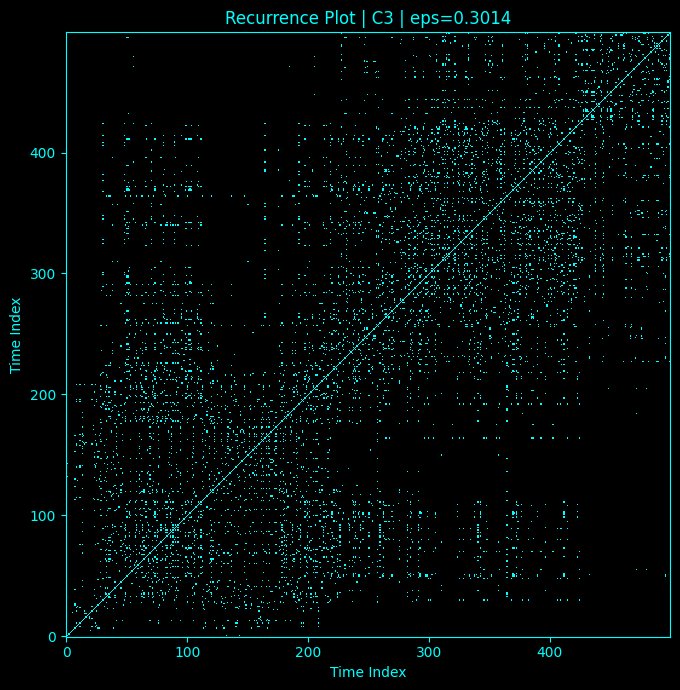

[RP OK] C3


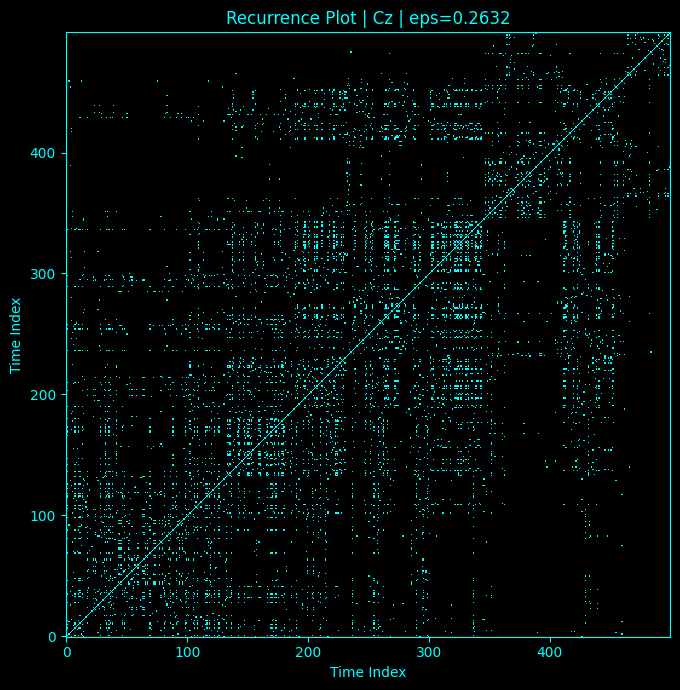

[RP OK] Cz


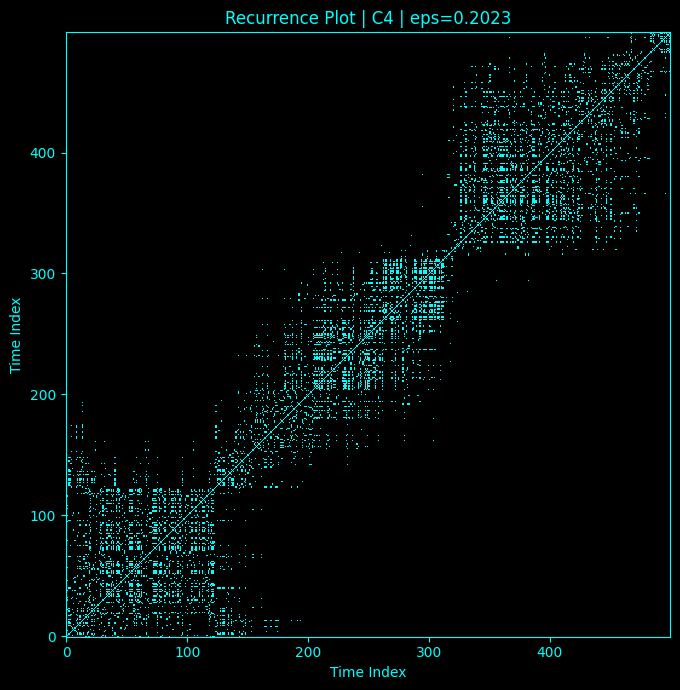

[RP OK] C4


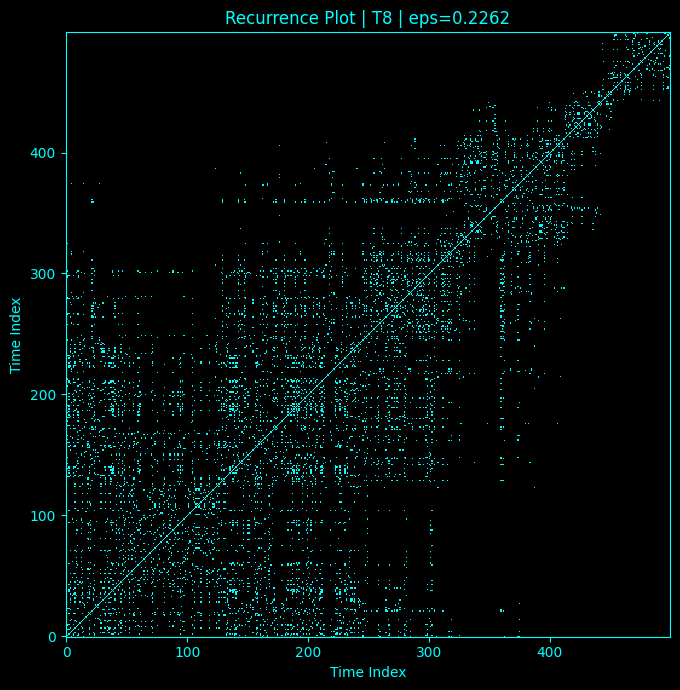

[RP OK] T8


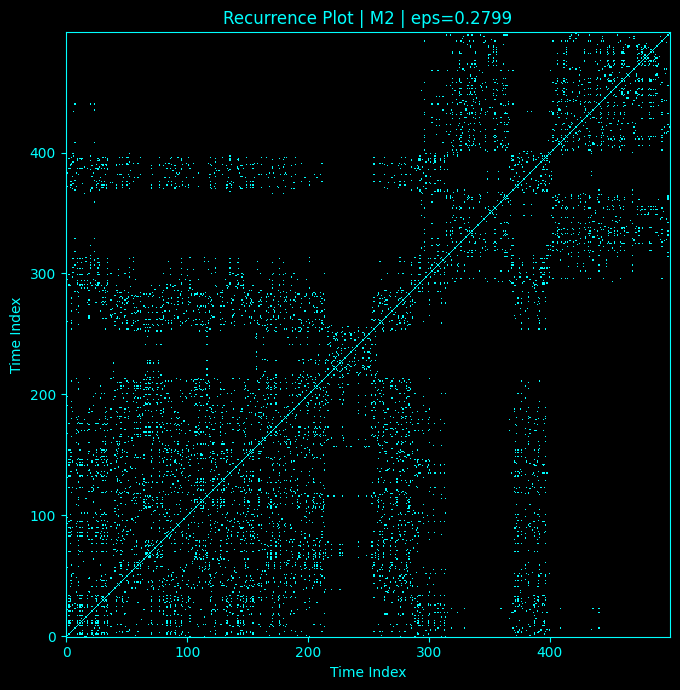

[RP OK] M2


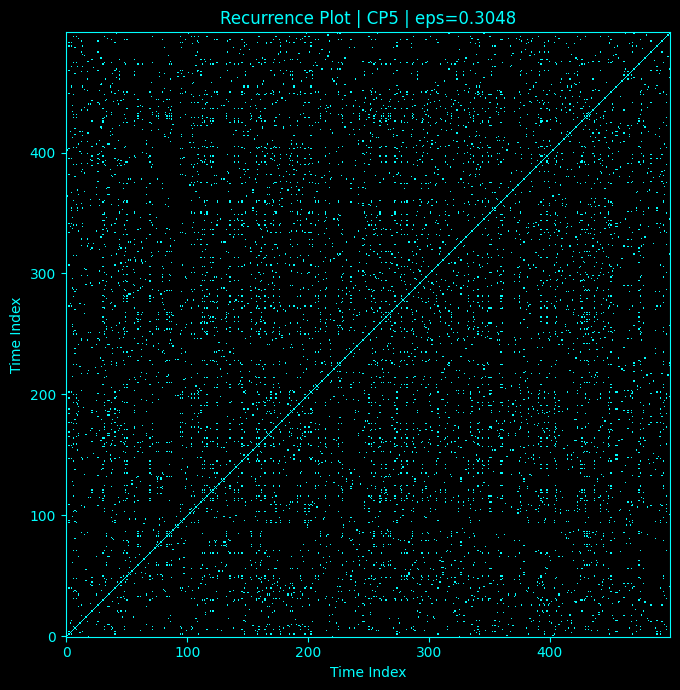

[RP OK] CP5


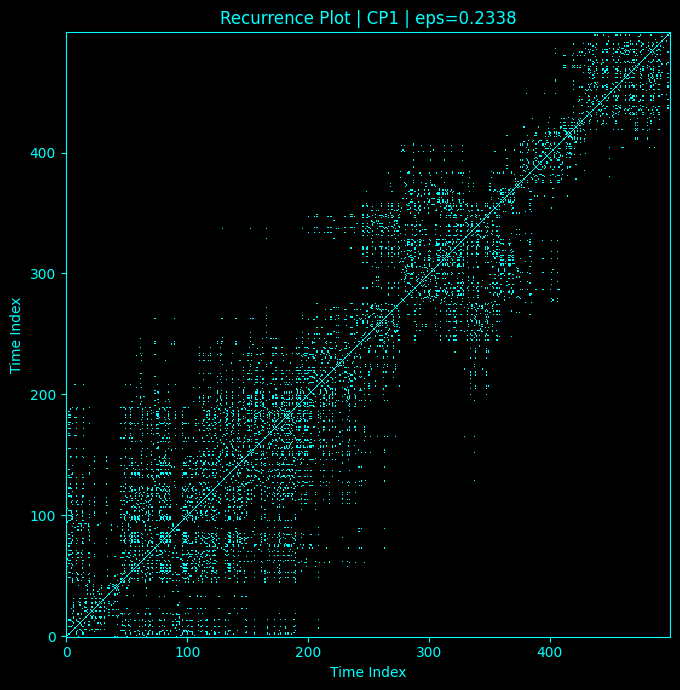

[RP OK] CP1


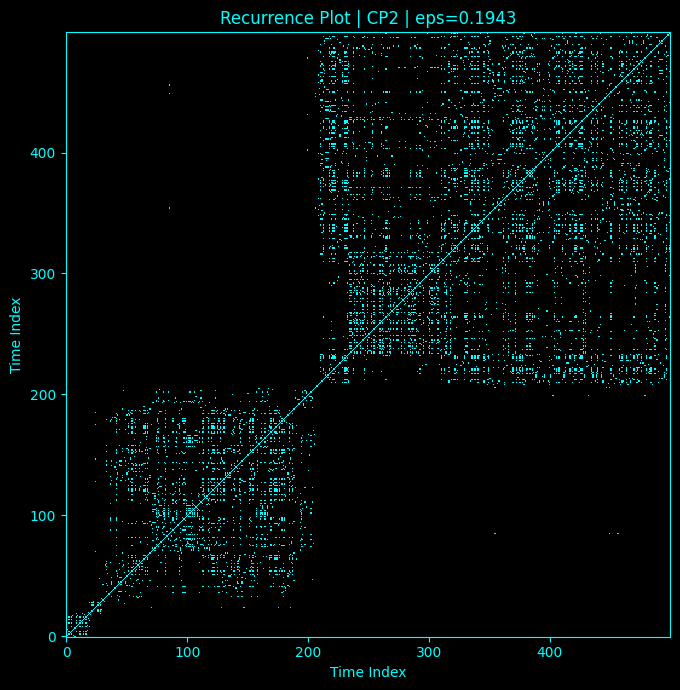

[RP OK] CP2


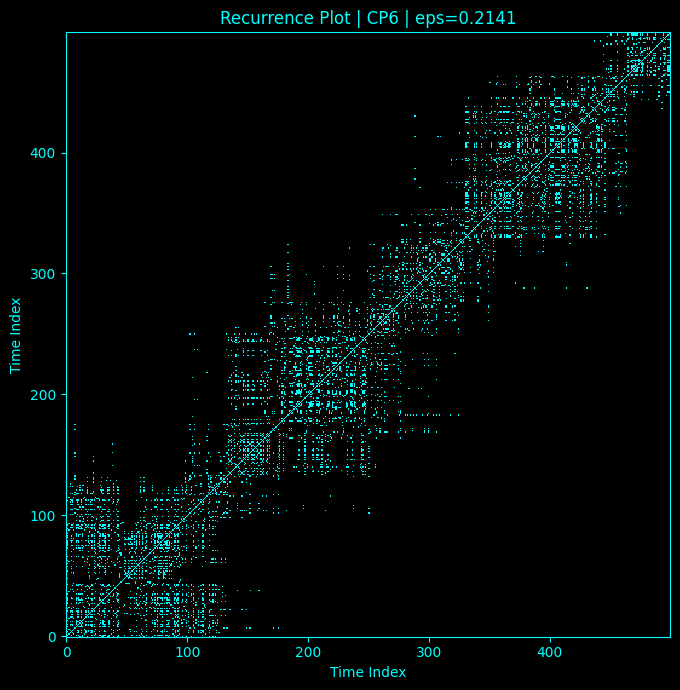

[RP OK] CP6


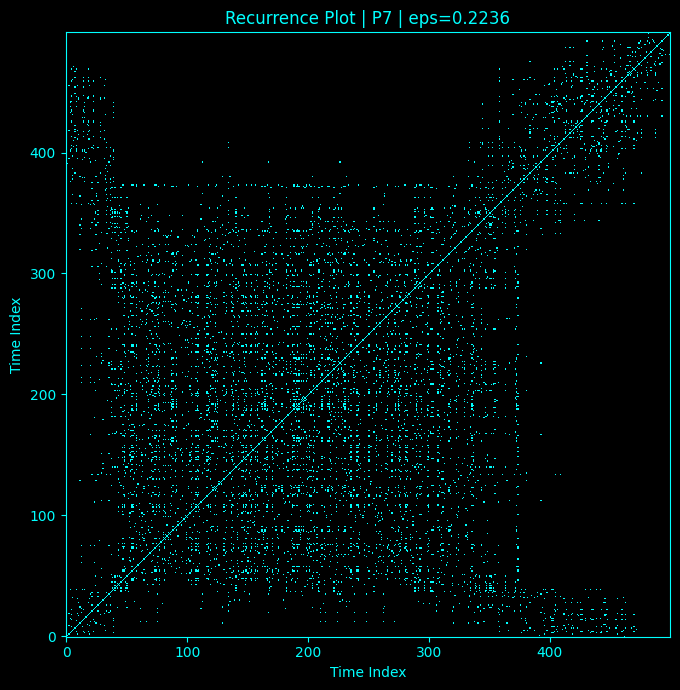

[RP OK] P7


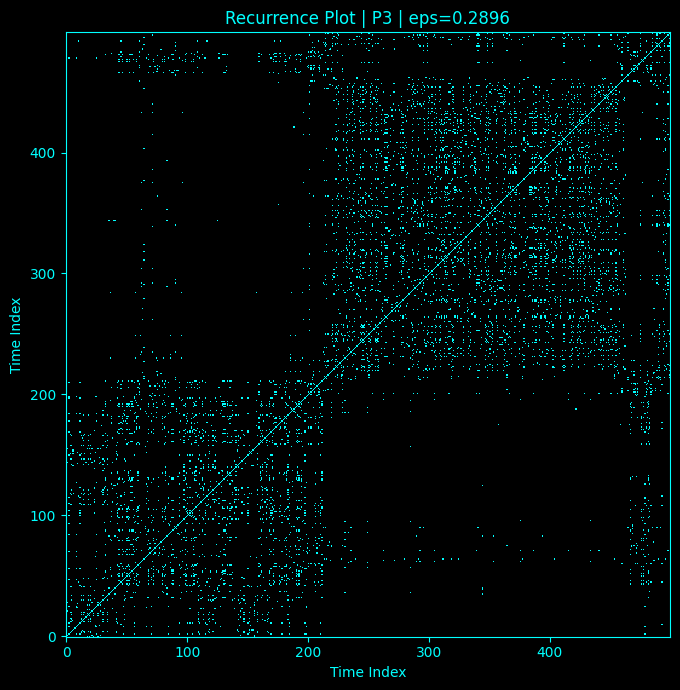

[RP OK] P3


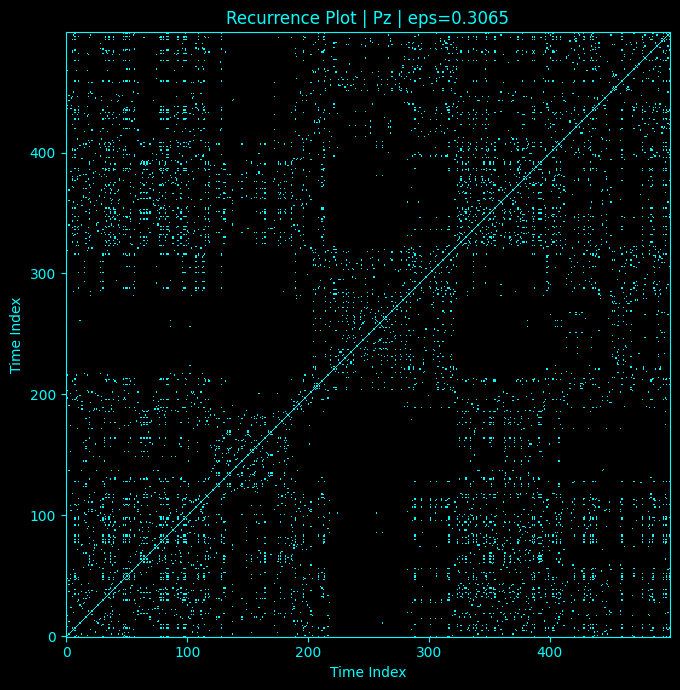

[RP OK] Pz


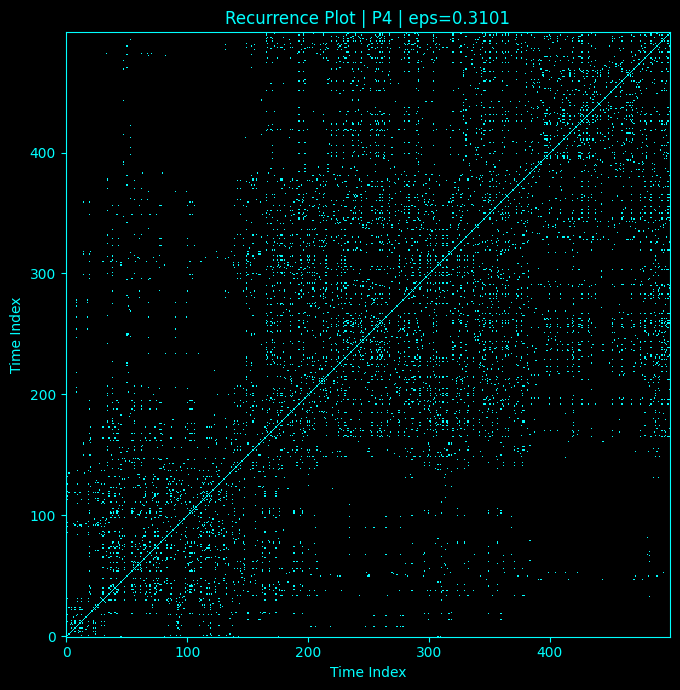

[RP OK] P4


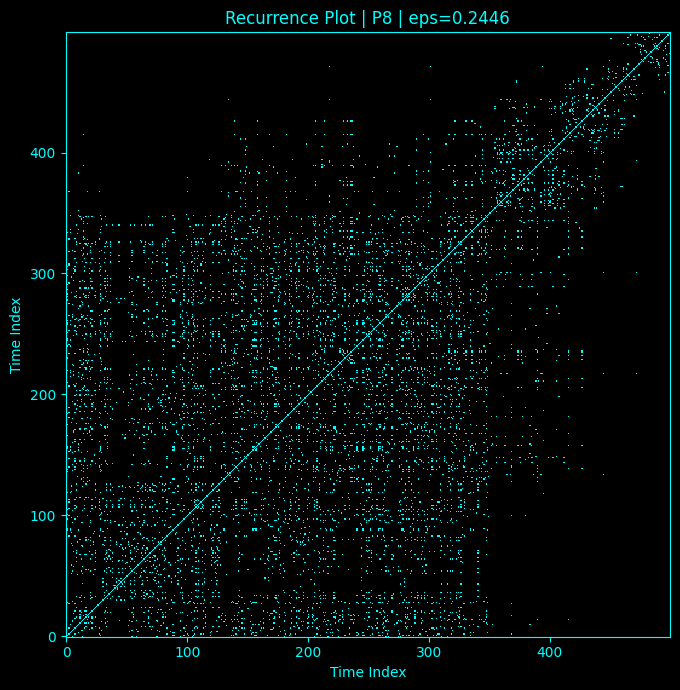

[RP OK] P8


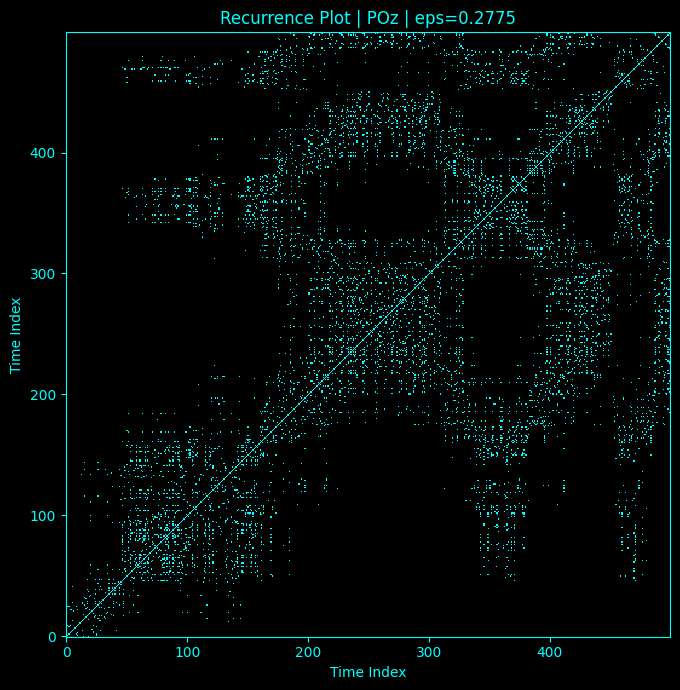

[RP OK] POz


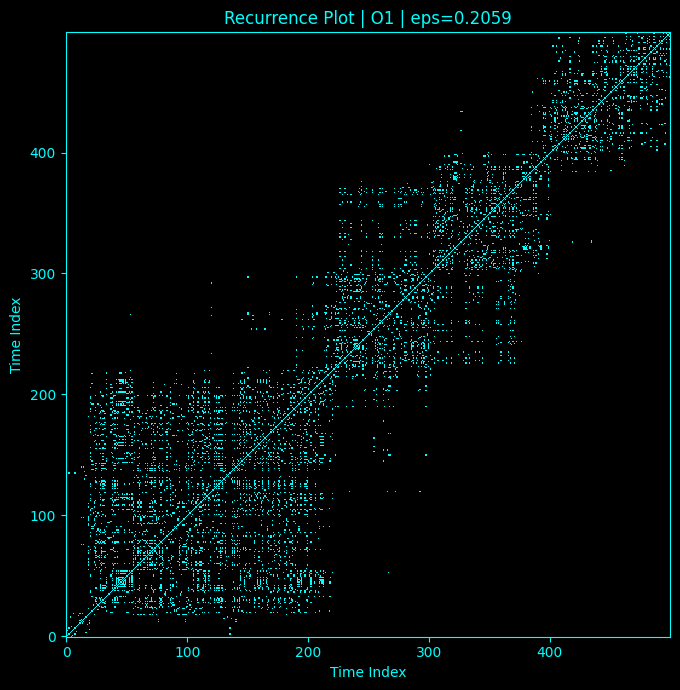

[RP OK] O1


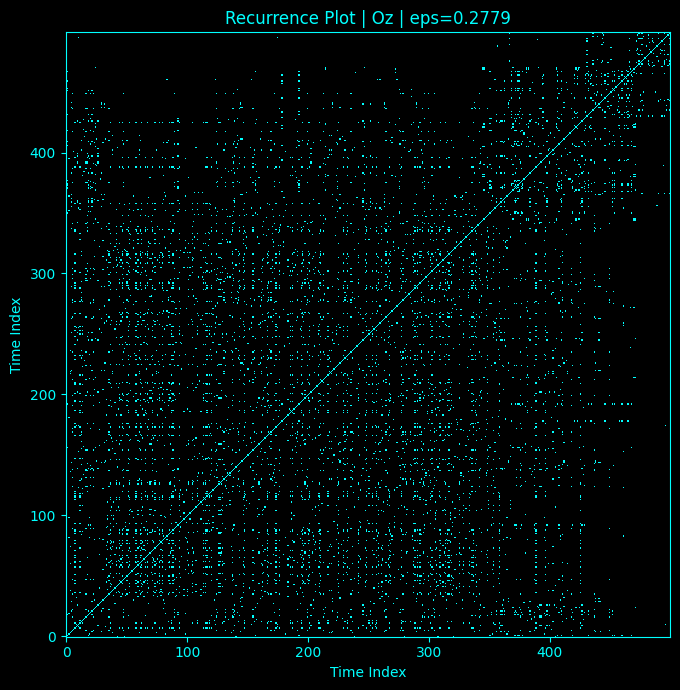

[RP OK] Oz


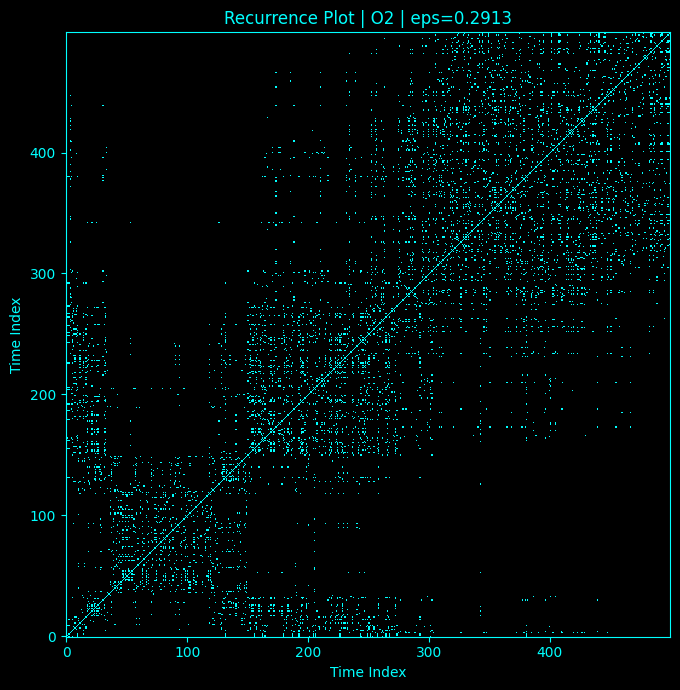

[RP OK] O2
Done.


In [20]:
import os
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

from pyrqa.settings import Settings
from pyrqa.neighbourhood import FixedRadius
from pyrqa.computation import RQAComputation
from pyrqa.time_series import EmbeddedSeries
from pyrqa.metric import EuclideanMetric
from pyrqa.analysis_type import Classic

warnings.filterwarnings(
    "ignore",
    message="Non-empty compiler output encountered.*"
)

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# -------------------------------------------------------
# CONFIG — ROBUST FILE DISCOVERY
# -------------------------------------------------------
_project_roots = [
    os.environ.get("NEURAL_SIGNAL_PROJECT_DIR"),
    "/home/a/projects/Complete-Neural-Signal-Analysis",
    "/home/a/projects/Explore-Neural-Signals1",
    os.getcwd(),
]
_project_roots = [
    Path(p).expanduser().resolve()
    for p in _project_roots
    if p
]
_project_roots = list(dict.fromkeys(_project_roots))

_zip_candidates = [root / "2d_embedded_data.zip" for root in _project_roots]
zipped_file_path = next((p for p in _zip_candidates if p.is_file()), None)

if zipped_file_path is None:
    _zip_hits = []
    for _root in _project_roots:
        if _root.is_dir():
            _zip_hits.extend(p for p in _root.rglob("2d_embedded_data.zip") if p.is_file())
    if _zip_hits:
        _zip_hits.sort(key=lambda p: p.stat().st_mtime, reverse=True)
        zipped_file_path = _zip_hits[0]

if zipped_file_path is None:
    raise FileNotFoundError(
        "Could not find 2d_embedded_data.zip. Checked project roots:\n  - "
        + "\n  - ".join(str(p) for p in _project_roots)
        + "\nCreate/export the 2-D embedding archive first, or set "
          "NEURAL_SIGNAL_PROJECT_DIR to the folder containing it."
    )

base_dir = zipped_file_path.parent
output_directory = base_dir / "rqa_results_fixed"
plots_directory = output_directory / "plots"
rp_directory = plots_directory / "recurrence_plots"

output_directory.mkdir(parents=True, exist_ok=True)
plots_directory.mkdir(parents=True, exist_ok=True)
rp_directory.mkdir(parents=True, exist_ok=True)

print("Using 2-D embedding archive:", zipped_file_path)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

THEILER = 1

# target recurrence density for choosing epsilon
TARGET_RR_FOR_RQA = 0.03
TARGET_RR_FOR_PLOT = 0.03

# performance controls
RADIUS_ESTIMATION_POINTS = _speed_count(2500, 700)   # used only to estimate epsilon
RP_MAX_POINTS = _speed_count(1500, 500)              # used only for recurrence-plot images
RQA_STRIDE = {"full": 5, "balanced": 6, "fast": 8, "ultra": 12}[FAST_OPTION]                   # set to 2 or 5 if PyRQA runtime is too heavy

MAKE_RECURRENCE_PLOTS = True
HIDE_MAIN_DIAGONAL_IN_PLOT = False

BG = "black"
ACCENT = "cyan"

rng = np.random.default_rng(0)

# -------------------------------------------------------
# GLOBAL STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

CYAN_BLACK_CMAP = LinearSegmentedColormap.from_list("black_cyan", [BG, ACCENT])
RP_CMAP = ListedColormap([BG, ACCENT])

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(False)

def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)

# -------------------------------------------------------
# UTILS
# -------------------------------------------------------
def safe_float_attr(obj, attr_name, default=np.nan):
    value = getattr(obj, attr_name, default)
    try:
        return float(value)
    except Exception:
        return default

def zscore_columns(X):
    X = np.asarray(X, dtype=np.float64)
    return (X - np.mean(X, axis=0, keepdims=True)) / (
        np.std(X, axis=0, keepdims=True) + 1e-12
    )

def random_subsample_rows(X, max_points, rng):
    X = np.asarray(X)
    n = len(X)
    if n <= max_points:
        return X
    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx]

def estimate_radius_from_sample(X, target_rr=0.03, theiler=1, sample_points=2500, rng=None):
    """
    Estimate epsilon from a manageable random sample instead of the full NxN matrix.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    Xs = random_subsample_rows(X, sample_points, rng).astype(np.float32, copy=False)
    n = len(Xs)

    if n < 2:
        return 0.1

    diffs = Xs[:, None, :] - Xs[None, :, :]
    D = np.sqrt(np.sum(diffs * diffs, axis=2, dtype=np.float32), dtype=np.float32)

    # use only upper triangle, excluding Theiler band
    mask = np.triu(np.ones((n, n), dtype=bool), k=max(1, theiler + 1))
    vals = D[mask]
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return 0.1

    q = float(np.clip(target_rr, 1e-4, 0.5))
    return float(np.quantile(vals, q))

# -------------------------------------------------------
# ZIP LOADER
# -------------------------------------------------------
def load_embedded_channel(zipf, channel_name):
    candidates = [
        f"2dembedded_{channel_name}.npy",
        f"2dembedded_{channel_name}_data.npy",
    ]

    for file_name in candidates:
        try:
            with zipf.open(file_name) as f:
                arr = np.load(f)
            arr = np.asarray(arr, dtype=np.float64)

            if arr.ndim != 2 or arr.shape[1] != 2:
                raise ValueError(f"{file_name} must have shape (N, 2), got {arr.shape}")

            return arr
        except KeyError:
            continue

    raise FileNotFoundError(f"No embedded file found for {channel_name}")

# -------------------------------------------------------
# RQA
# -------------------------------------------------------
def compute_rqa_for_channel(embedded_points, channel_name, theiler=THEILER, target_rr=TARGET_RR_FOR_RQA):
    X = zscore_columns(embedded_points)

    if RQA_STRIDE > 1:
        X = X[::RQA_STRIDE]

    radius = estimate_radius_from_sample(
        X,
        target_rr=target_rr,
        theiler=theiler,
        sample_points=RADIUS_ESTIMATION_POINTS,
        rng=rng
    )

    embedded_series = EmbeddedSeries(X.tolist())

    settings = Settings(
        embedded_series,
        analysis_type=Classic,
        neighbourhood=FixedRadius(radius),
        similarity_measure=EuclideanMetric(),
        theiler_corrector=theiler
    )

    result = RQAComputation.create(settings).run()

    rr = safe_float_attr(result, "recurrence_rate")
    det = safe_float_attr(result, "determinism")
    lam = safe_float_attr(result, "laminarity")

    metrics = {
        "N_used": len(X),
        "radius_used": radius,
        "RR": rr,
        "DET": det,
        "LAM": lam,
        "L": safe_float_attr(result, "average_diagonal_line"),
        "Lmax": safe_float_attr(result, "longest_diagonal_line"),
        "L_entr": safe_float_attr(result, "entropy_diagonal_lines"),
        "TT": safe_float_attr(result, "trapping_time"),
        "Vmax": safe_float_attr(result, "longest_vertical_line"),
        "V_entr": safe_float_attr(result, "entropy_vertical_lines"),
        "W": safe_float_attr(result, "average_white_vertical_line"),
        "Wmax": safe_float_attr(result, "longest_white_vertical_line"),
        "W_entr": safe_float_attr(result, "entropy_white_vertical_lines"),
        "DET/RR": det / rr if np.isfinite(rr) and rr != 0 else np.nan,
        "LAM/DET": lam / det if np.isfinite(det) and det != 0 else np.nan,
    }

    return channel_name, metrics

# -------------------------------------------------------
# DISPLAY CONTROL
# -------------------------------------------------------
SHOW_PLOTS = True

# -------------------------------------------------------
# RECURRENCE PLOT
# -------------------------------------------------------
def build_recurrence_matrix_for_plot(X, theiler=THEILER, target_rr=TARGET_RR_FOR_PLOT, hide_main_diagonal=False):
    X = zscore_columns(X)
    X = random_subsample_rows(X, RP_MAX_POINTS, rng).astype(np.float32, copy=False)

    radius = estimate_radius_from_sample(
        X,
        target_rr=target_rr,
        theiler=theiler,
        sample_points=min(RADIUS_ESTIMATION_POINTS, len(X)),
        rng=rng
    )

    diffs = X[:, None, :] - X[None, :, :]
    D = np.sqrt(np.sum(diffs * diffs, axis=2, dtype=np.float32), dtype=np.float32)
    R = (D <= radius).astype(np.uint8)

    n = R.shape[0]

    if theiler > 0:
        for k in range(-theiler, theiler + 1):
            i = np.arange(n)
            j = i + k
            good = (j >= 0) & (j < n)
            R[i[good], j[good]] = 0

    if not hide_main_diagonal:
        np.fill_diagonal(R, 1)

    return R, radius

def save_recurrence_plot(channel_name, embedded_points, out_dir):
    rp, radius = build_recurrence_matrix_for_plot(
        embedded_points,
        theiler=THEILER,
        target_rr=TARGET_RR_FOR_PLOT,
        hide_main_diagonal=HIDE_MAIN_DIAGONAL_IN_PLOT
    )

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
    style_ax(ax)

    ax.imshow(
        rp,
        cmap=RP_CMAP,
        origin="lower",
        interpolation="nearest",
        aspect="equal"
    )
    ax.set_title(f"Recurrence Plot | {channel_name} | eps={radius:.4f}")
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Time Index")

    out_path = out_dir / f"RP_{channel_name}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")

    if SHOW_PLOTS:
        plt.show()

    plt.close(fig)

# -------------------------------------------------------
# SUMMARY PLOTS
# -------------------------------------------------------
def valid_metric_columns(df):
    cols = []
    for c in df.columns:
        if c == "Channel":
            continue
        vals = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
        if np.isfinite(vals).any():
            cols.append(c)
    return cols

def save_metric_heatmap(df, out_path):
    metric_cols = valid_metric_columns(df)
    if not metric_cols:
        print("[PLOT WARNING] No valid metric columns for heatmap.")
        return

    values = df[metric_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    mins = np.nanmin(values, axis=0)
    maxs = np.nanmax(values, axis=0)
    norm = (values - mins) / (maxs - mins + 1e-12)

    fig, ax = plt.subplots(figsize=(18, 6), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(norm.T, aspect="auto", cmap=CYAN_BLACK_CMAP, interpolation="nearest")
    ax.set_title("RQA Metrics Heatmap")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Metric")
    ax.set_xticks(np.arange(len(df)))
    ax.set_xticklabels(df["Channel"], rotation=90)
    ax.set_yticks(np.arange(len(metric_cols)))
    ax.set_yticklabels(metric_cols)

    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Normalized Value", color=ACCENT)
    style_colorbar(cbar)

    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")

    if SHOW_PLOTS:
        plt.show()

    plt.close(fig)

def save_selected_metric_lines(df, out_path):
    preferred_cols = ["RR", "DET", "LAM", "L_entr", "TT", "DET/RR", "LAM/DET", "radius_used"]
    metric_cols = [c for c in preferred_cols if c in df.columns and np.isfinite(pd.to_numeric(df[c], errors="coerce")).any()]

    if not metric_cols:
        print("[PLOT WARNING] No valid metric columns for line plot.")
        return

    fig, ax = plt.subplots(figsize=(18, 7), facecolor=BG)
    style_ax(ax)

    x = np.arange(len(df))
    for metric in metric_cols:
        y = pd.to_numeric(df[metric], errors="coerce").to_numpy(dtype=float)
        ax.plot(x, y, linewidth=1.8, label=metric)

    ax.set_title("Selected RQA Metrics Across EEG Channels")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Metric Value")
    ax.set_xticks(x)
    ax.set_xticklabels(df["Channel"], rotation=90)

    legend = ax.legend(facecolor=BG, edgecolor=ACCENT, labelcolor=ACCENT)
    for text in legend.get_texts():
        text.set_color(ACCENT)

    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")

    if SHOW_PLOTS:
        plt.show()

    plt.close(fig)

# -------------------------------------------------------
# MAIN
# -------------------------------------------------------
embedded_data = {}
results = []
errors = []

with zipfile.ZipFile(zipped_file_path, "r") as zipf:
    for channel in eeg_channels:
        try:
            embedded_data[channel] = load_embedded_channel(zipf, channel)
            print(f"[LOAD OK] {channel}: {embedded_data[channel].shape}")
        except Exception as e:
            errors.append(("load", channel, str(e)))
            print(f"[LOAD ERROR] {channel}: {e}")

for channel in eeg_channels:
    if channel not in embedded_data:
        continue

    try:
        results.append(compute_rqa_for_channel(embedded_data[channel], channel))
        print(f"[RQA OK] {channel}")
    except Exception as e:
        errors.append(("rqa", channel, str(e)))
        print(f"[RQA ERROR] {channel}: {e}")

if not results:
    raise RuntimeError(
        "No RQA results were computed. "
        "If PyRQA still struggles, set RQA_STRIDE = 2 or 5 and rerun."
    )

flattened_results = [(channel, *metrics.values()) for channel, metrics in results]
df_columns = [
    "Channel",
    "N_used",
    "radius_used",
    "RR", "DET", "LAM", "L", "Lmax", "L_entr", "TT",
    "Vmax", "V_entr", "W", "Wmax", "W_entr",
    "DET/RR", "LAM/DET"
]
df = pd.DataFrame(flattened_results, columns=df_columns)

df["Channel"] = pd.Categorical(df["Channel"], categories=eeg_channels, ordered=True)
df = df.sort_values("Channel").reset_index(drop=True)

csv_path = output_directory / "rqa_results.csv"
df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

if errors:
    err_df = pd.DataFrame(errors, columns=["stage", "channel", "error"])
    err_df.to_csv(output_directory / "rqa_errors.csv", index=False)
    print(f"Saved errors: {output_directory / 'rqa_errors.csv'}")

save_metric_heatmap(df, plots_directory / "rqa_metrics_heatmap.png")
save_selected_metric_lines(df, plots_directory / "rqa_selected_metrics.png")

if MAKE_RECURRENCE_PLOTS:
    for channel in df["Channel"]:
        try:
            save_recurrence_plot(channel, embedded_data[channel], rp_directory)
            print(f"[RP OK] {channel}")
        except Exception as e:
            print(f"[RP ERROR] {channel}: {e}")

print("Done.")

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — 3-D recurrence quantification analysis</h3><p>This block applies the same recurrence/RQA definitions specifically to stored three-dimensional delay embeddings. Standardizing coordinates before distance calculation prevents one embedding coordinate from dominating solely by scale.</p><p>Using a common target recurrence density facilitates channel comparison, while DET, LAM, line-length entropy, and related metrics still depend on the chosen line-length thresholds.</p><p><b>Cell role.</b> The distinction from the previous cell is the fixed 3-D embedding source.</p></div>

$$R_{ij}=\mathbf1\{\|Z_i-Z_j\|_2\le\varepsilon\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Recurrence analysis compares pairs of reconstructed states and marks them as recurrent when their distance is below a chosen threshold. The recurrence rate is simply the fraction of state pairs that satisfy this condition. Diagonal line structures indicate that similar state sequences evolve in similar ways for several steps, which motivates determinism-related measures. Vertical line structures indicate that the trajectory stays near a region of state space for several samples, which motivates laminarity-related measures. These quantities depend on embedding choices, distance scaling, and the recurrence threshold, so those settings should be held consistent when channels are compared.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


Using 3-D embedding directory: /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/3dembedding_data
[3D RQA OK] Fp1: shape=(106938, 3)
[3D RQA OK] Fpz: shape=(106938, 3)
[3D RQA OK] Fp2: shape=(106938, 3)
[3D RQA OK] F7: shape=(106938, 3)
[3D RQA OK] F3: shape=(106938, 3)
[3D RQA OK] Fz: shape=(106938, 3)
[3D RQA OK] F4: shape=(106938, 3)
[3D RQA OK] F8: shape=(106938, 3)
[3D RQA OK] FC5: shape=(106938, 3)
[3D RQA OK] FC1: shape=(106938, 3)
[3D RQA OK] FC2: shape=(106938, 3)
[3D RQA OK] FC6: shape=(106938, 3)
[3D RQA OK] M1: shape=(106938, 3)
[3D RQA OK] T7: shape=(106938, 3)
[3D RQA OK] C3: shape=(106938, 3)
[3D RQA OK] Cz: shape=(106938, 3)
[3D RQA OK] C4: shape=(106938, 3)
[3D RQA OK] T8: shape=(106938, 3)
[3D RQA OK] M2: shape=(106938, 3)
[3D RQA OK] CP5: shape=(106938, 3)
[3D RQA OK] CP1: shape=(106938, 3)
[3D RQA OK] CP2: shape=(106938, 3)
[3D RQA OK] CP6: shape=(106938, 3)
[3D RQA OK] P7: shape=(106938, 3)
[3D RQA OK] P3: shape=(106938, 3)
[3D RQA OK] Pz: shape=(1069

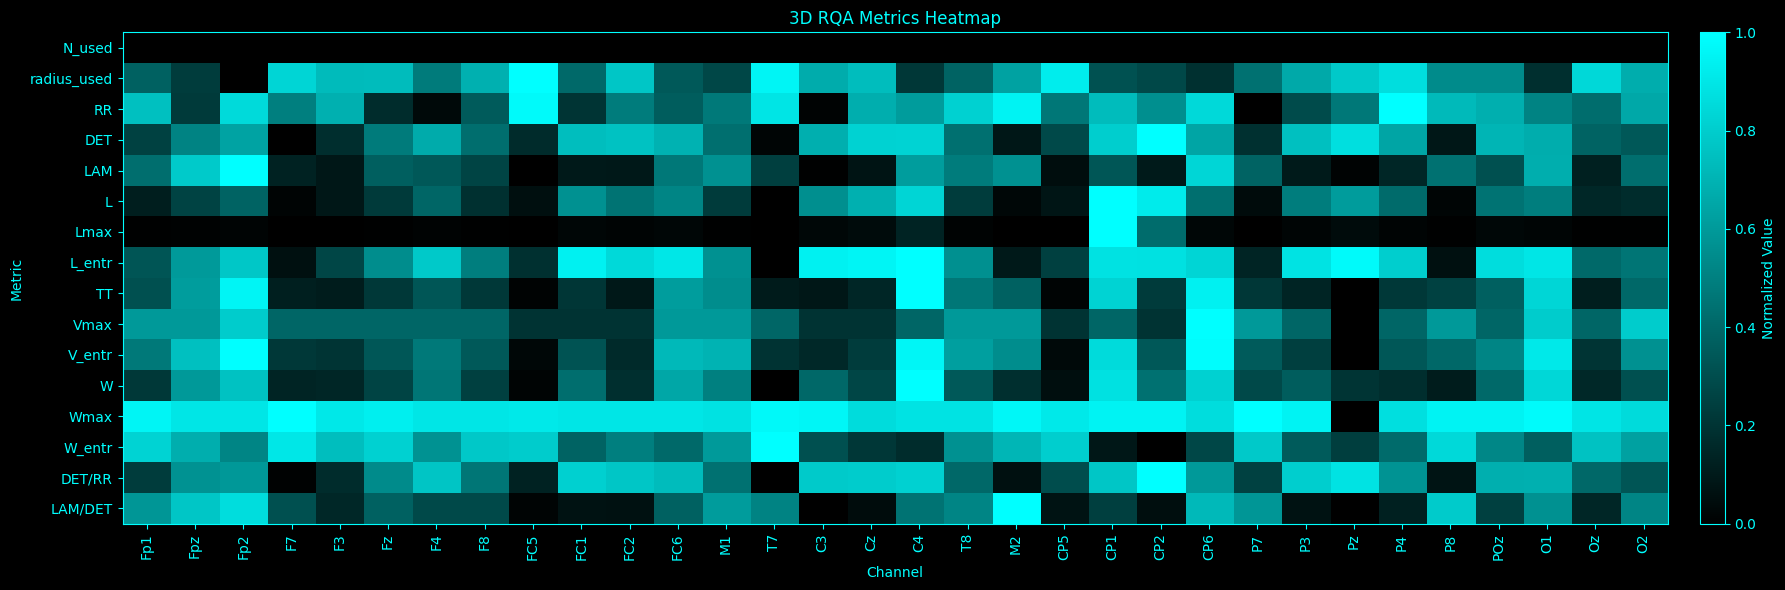

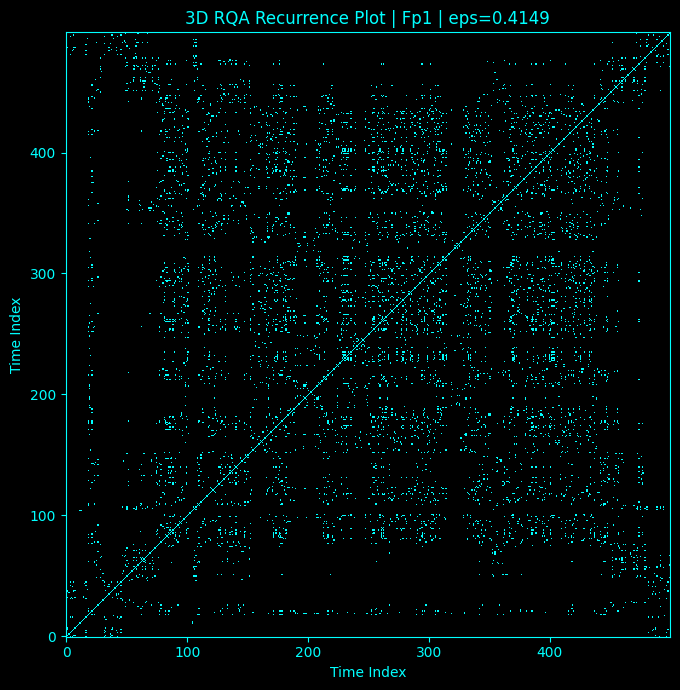

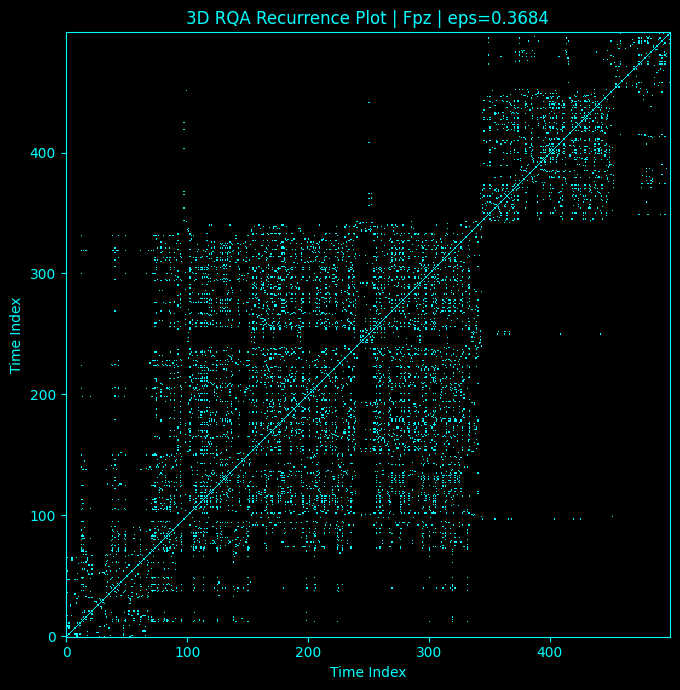

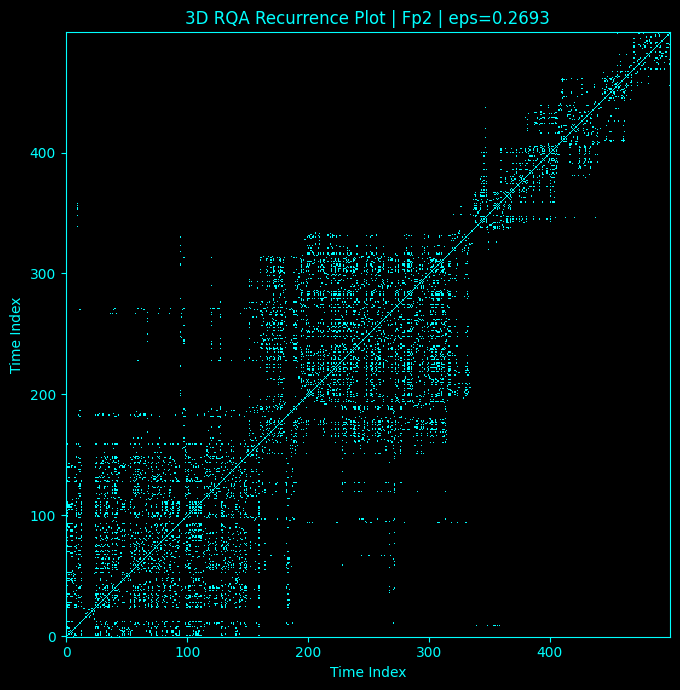

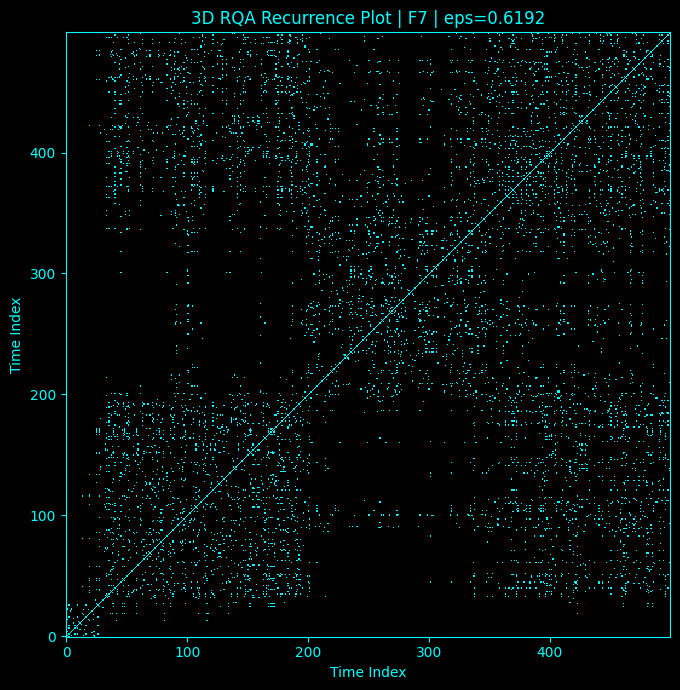

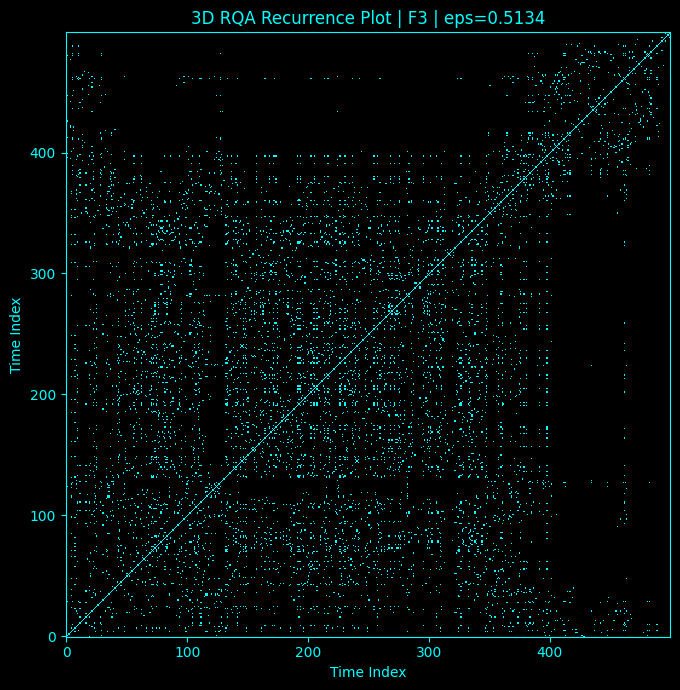

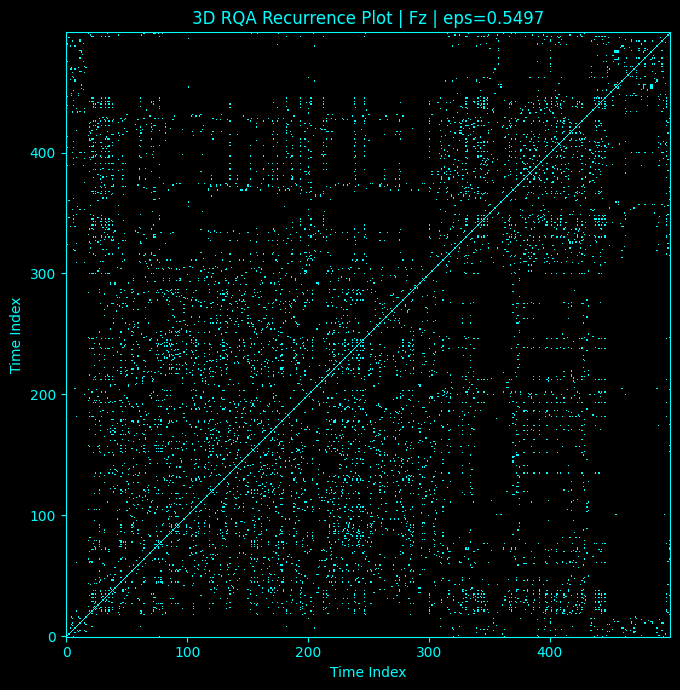

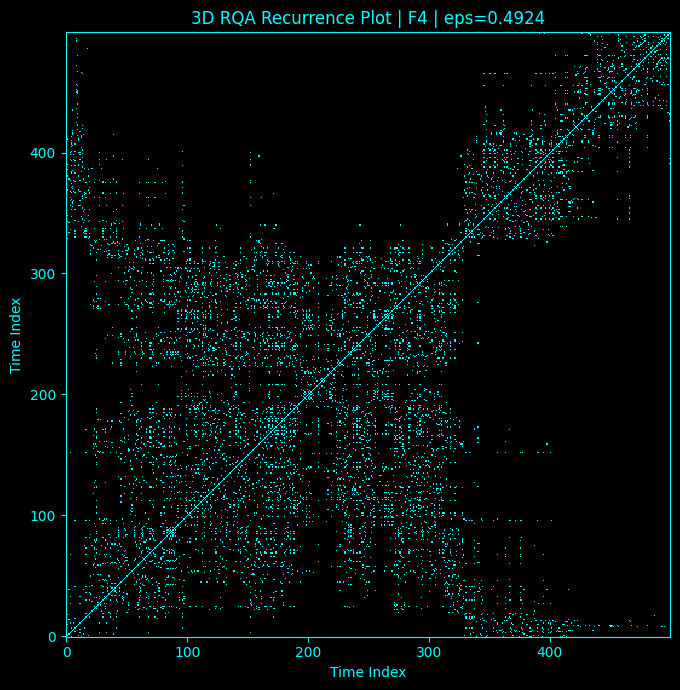

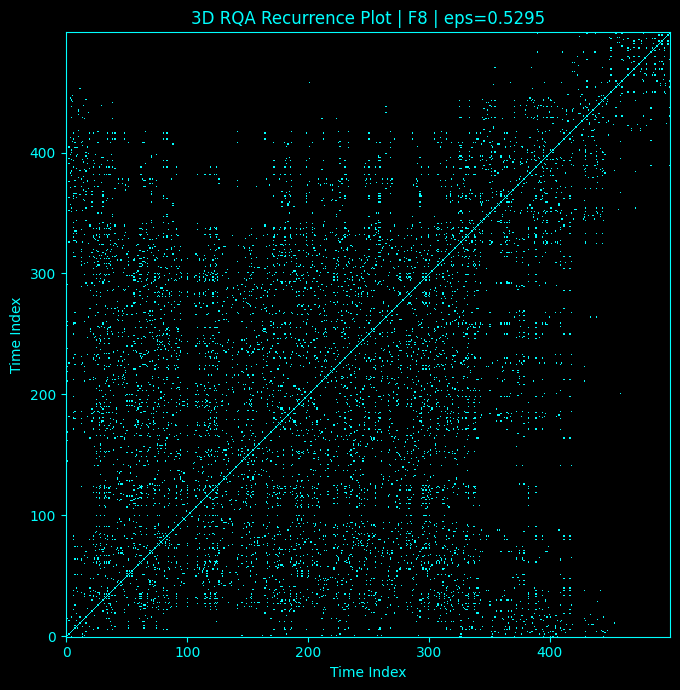

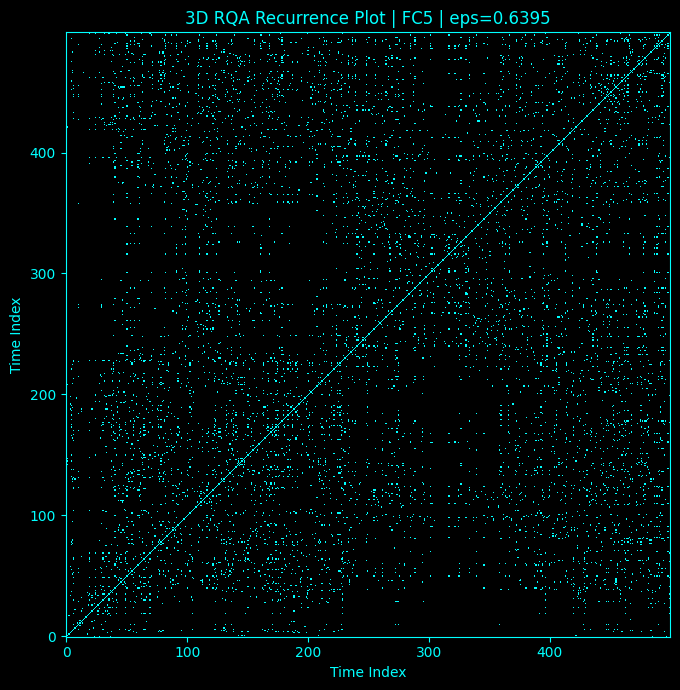

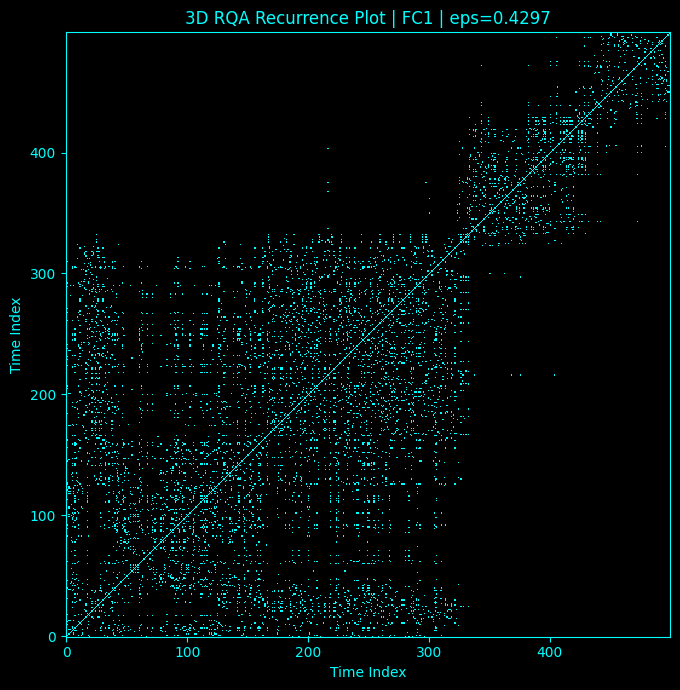

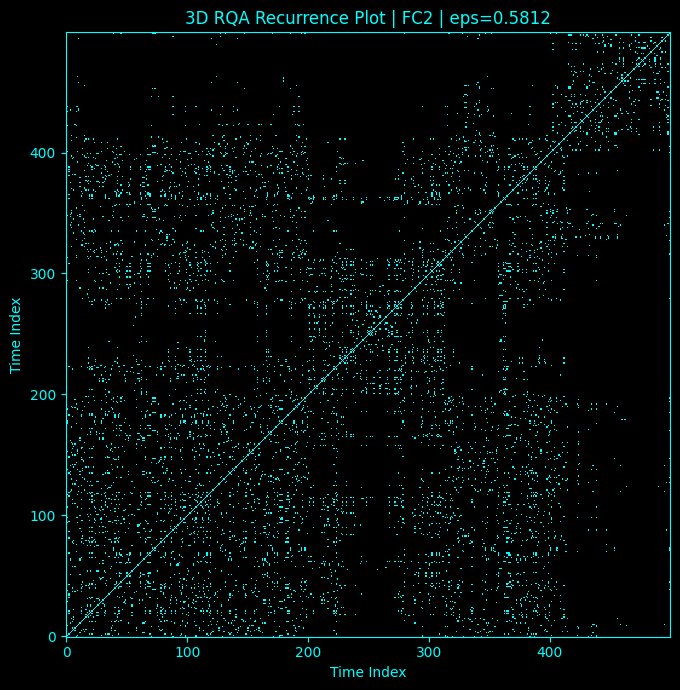

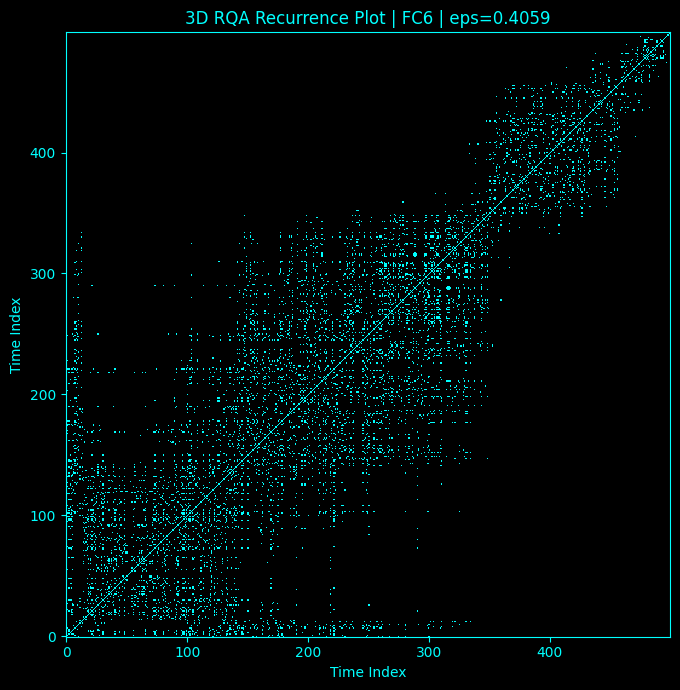

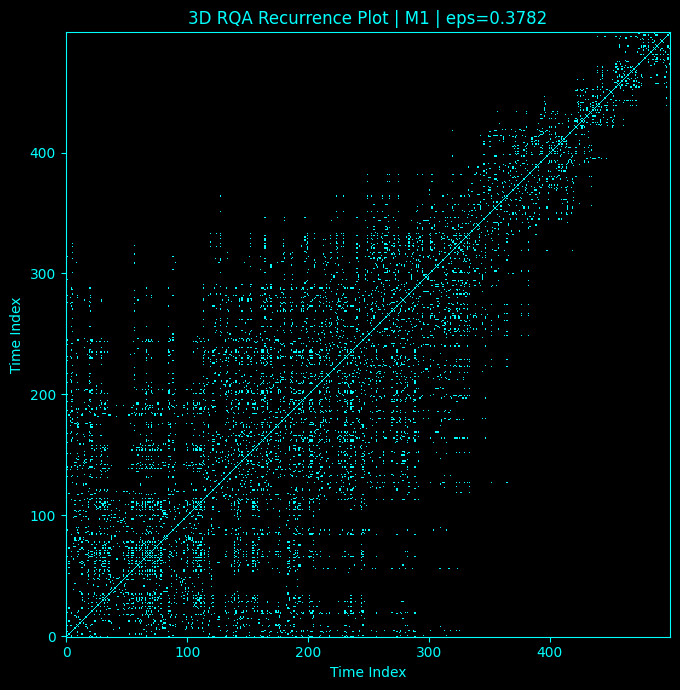

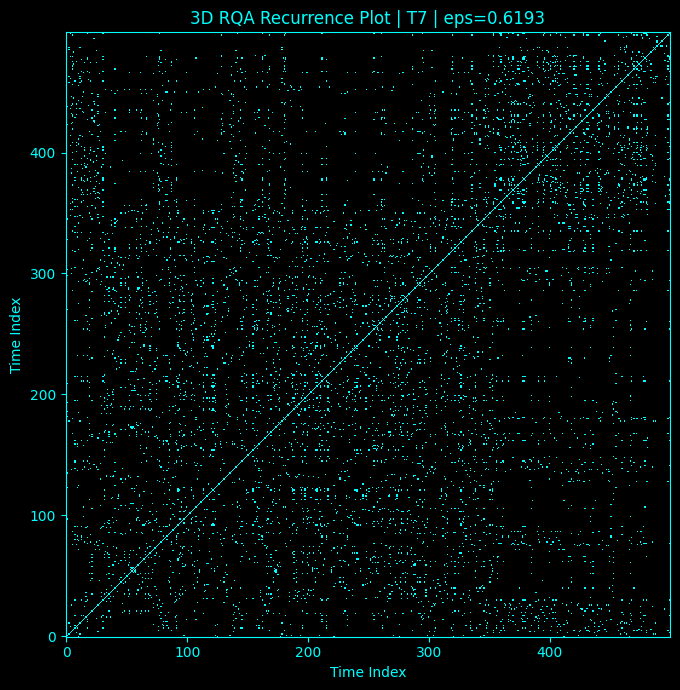

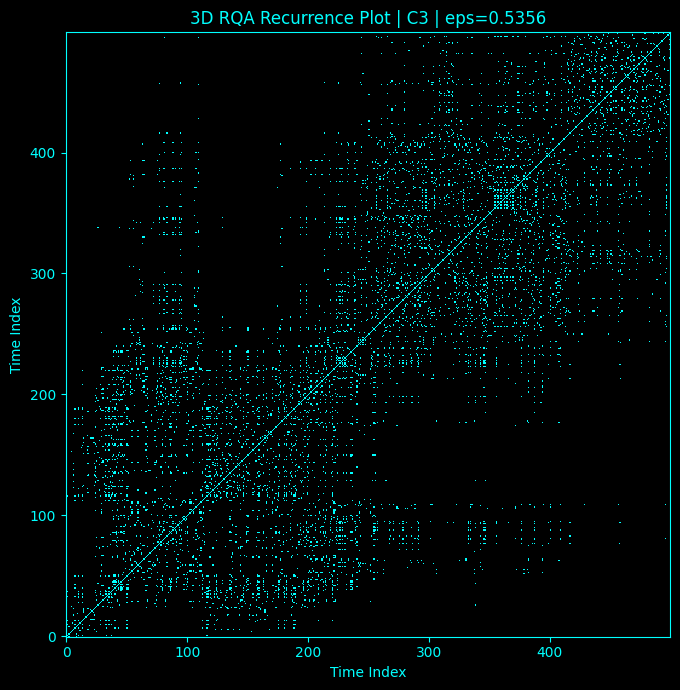

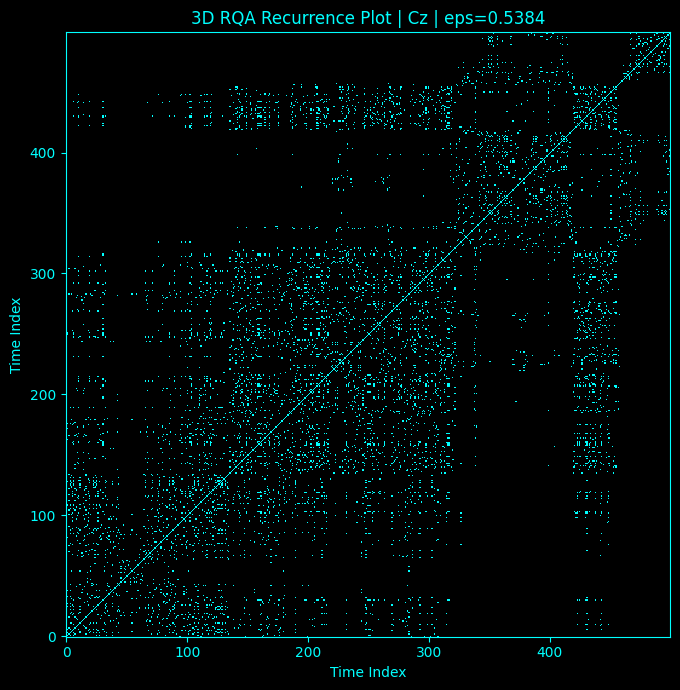

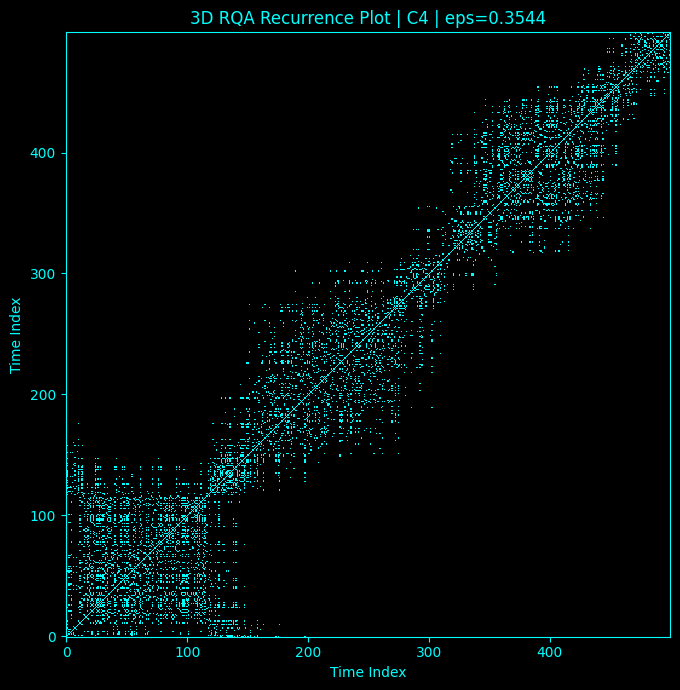

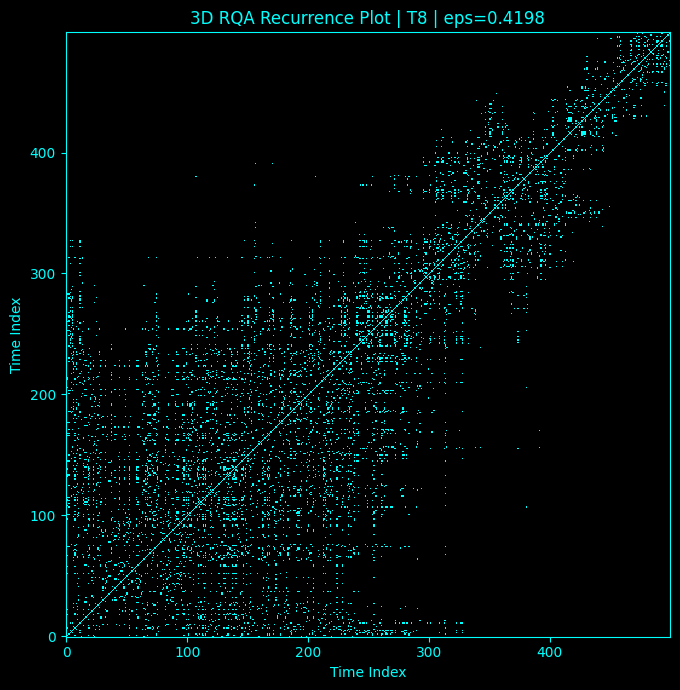

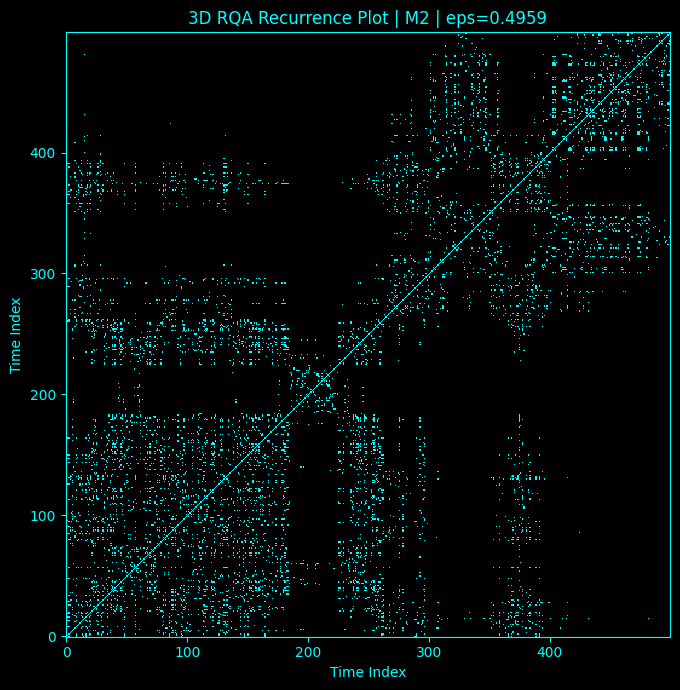

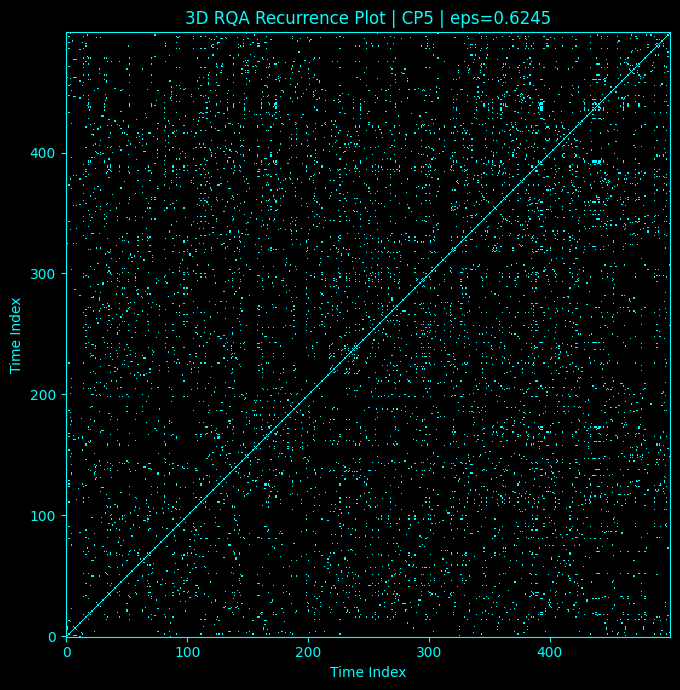

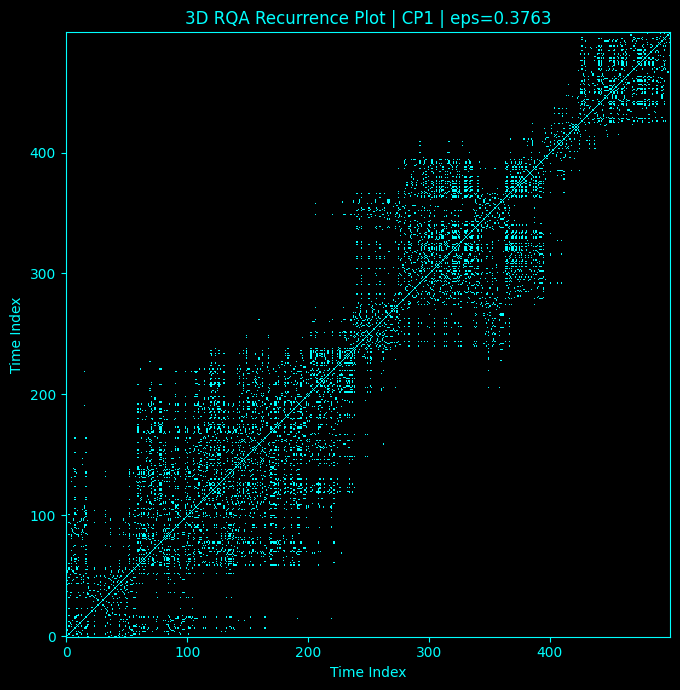

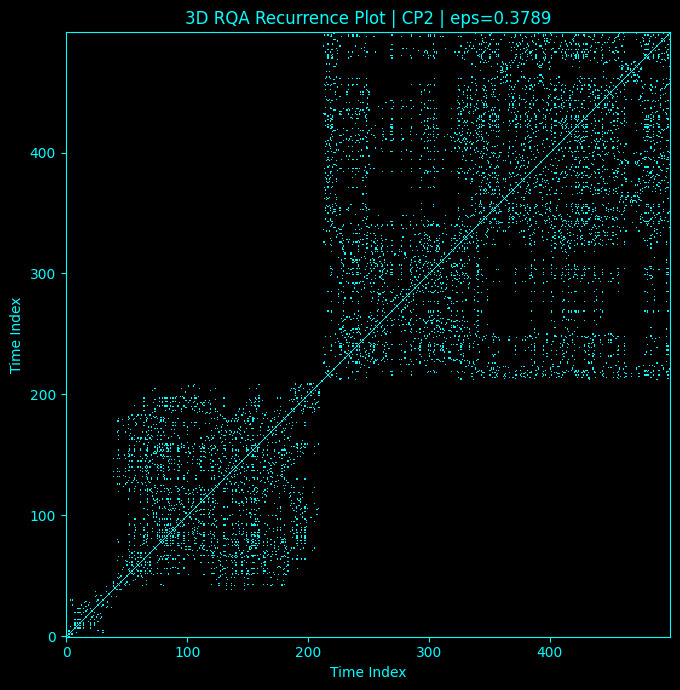

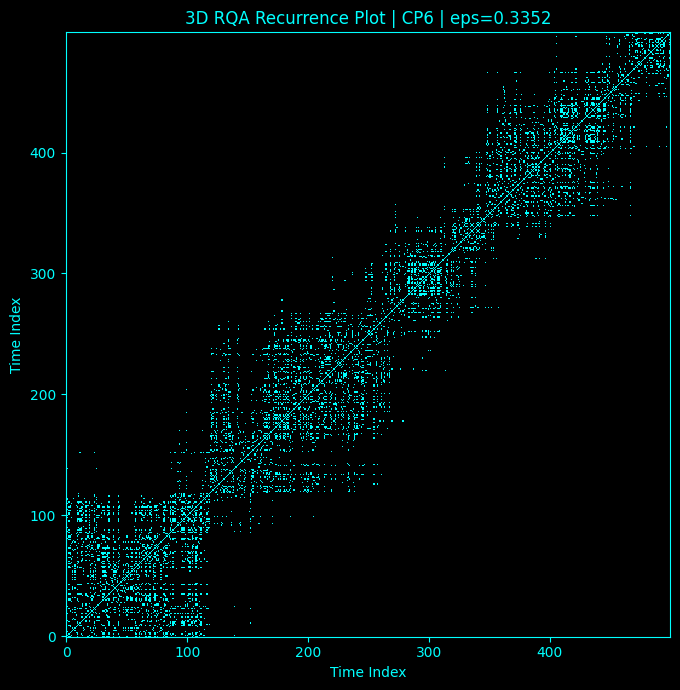

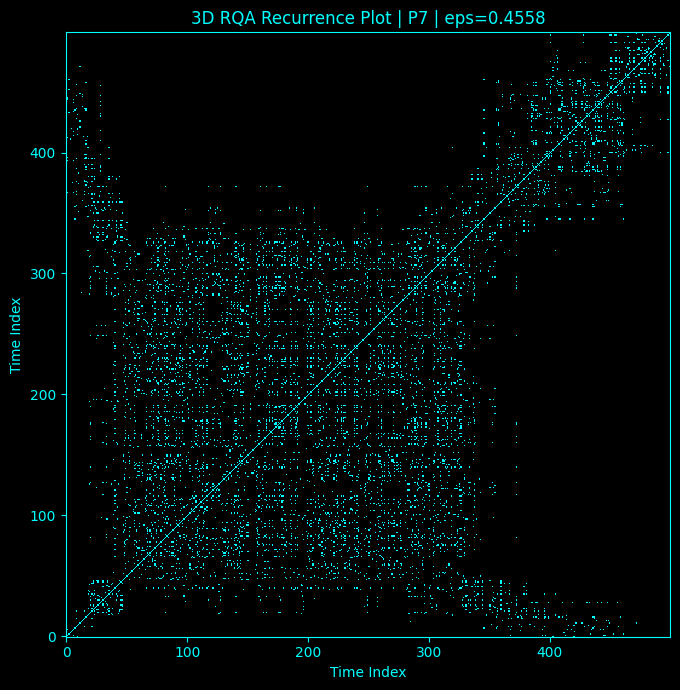

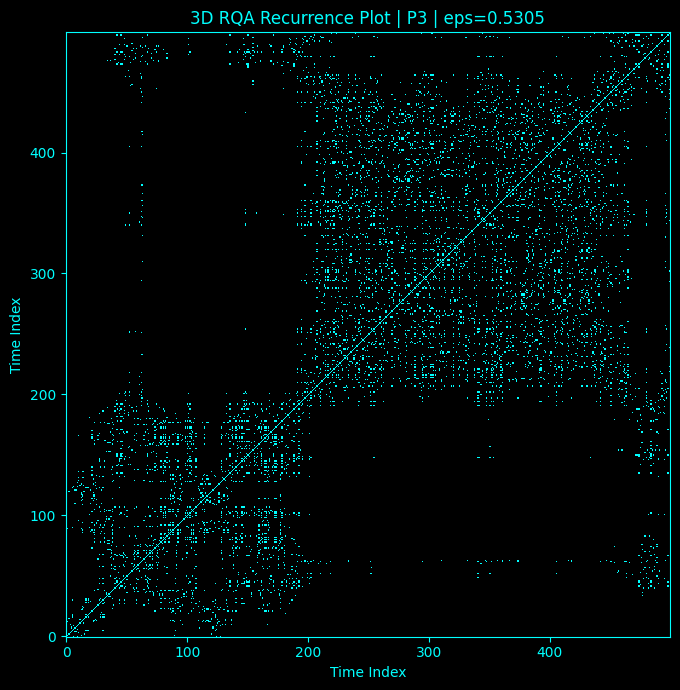

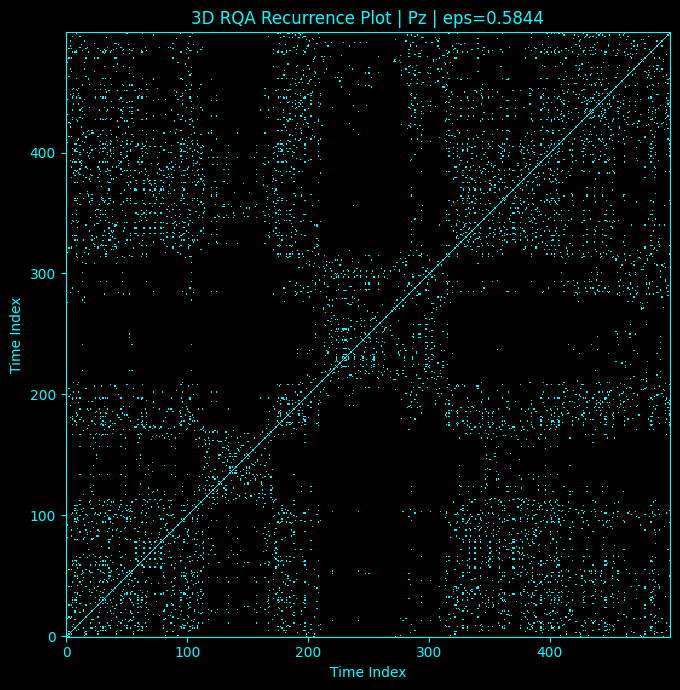

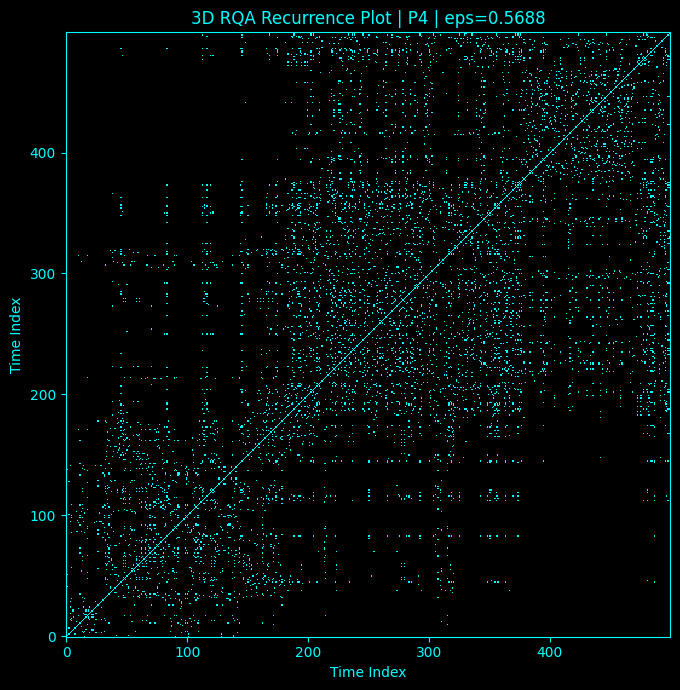

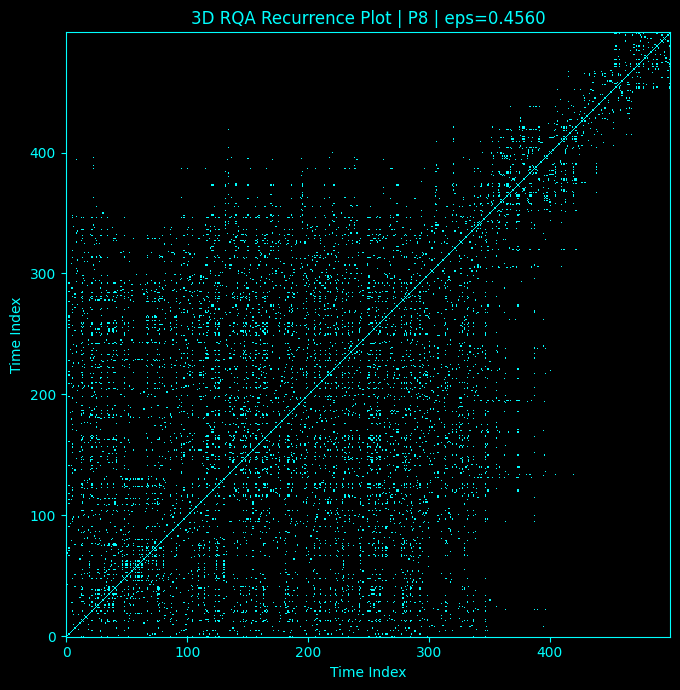

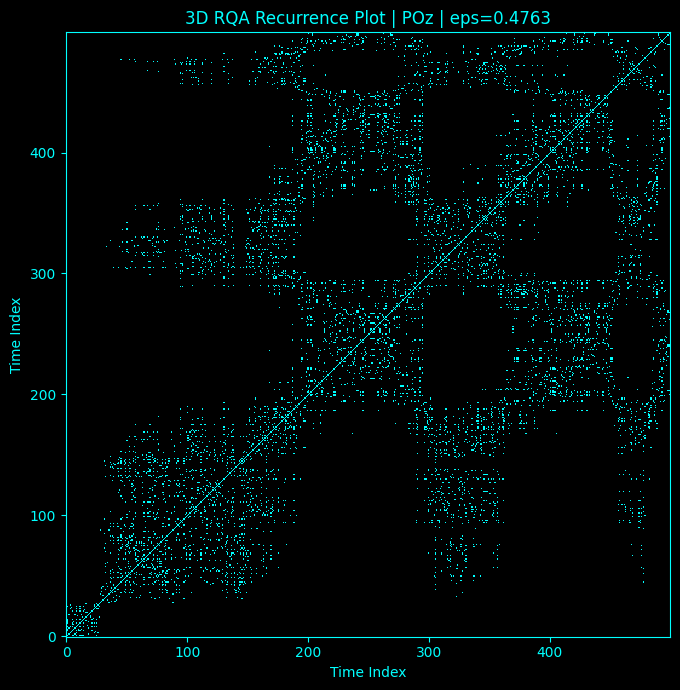

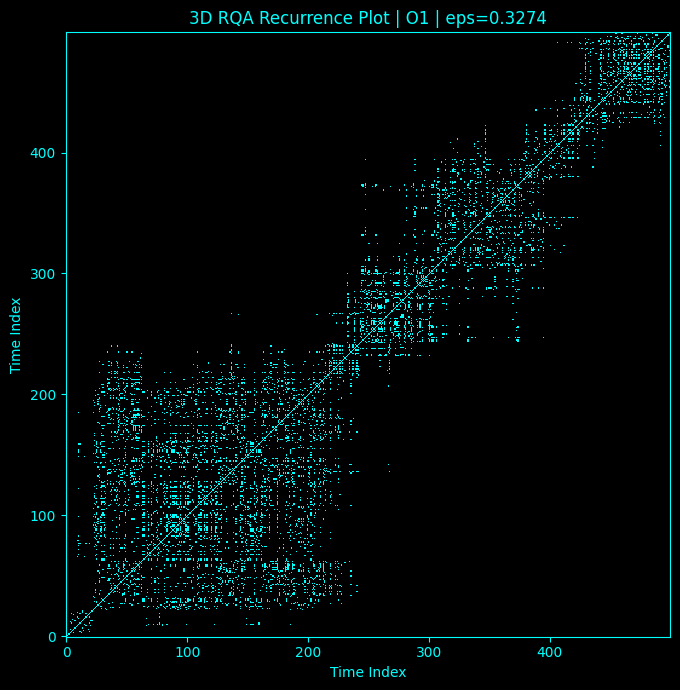

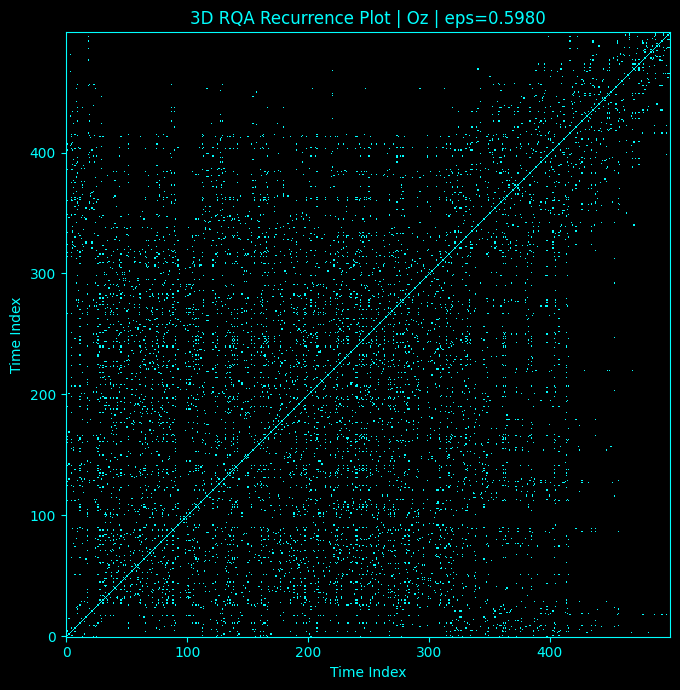

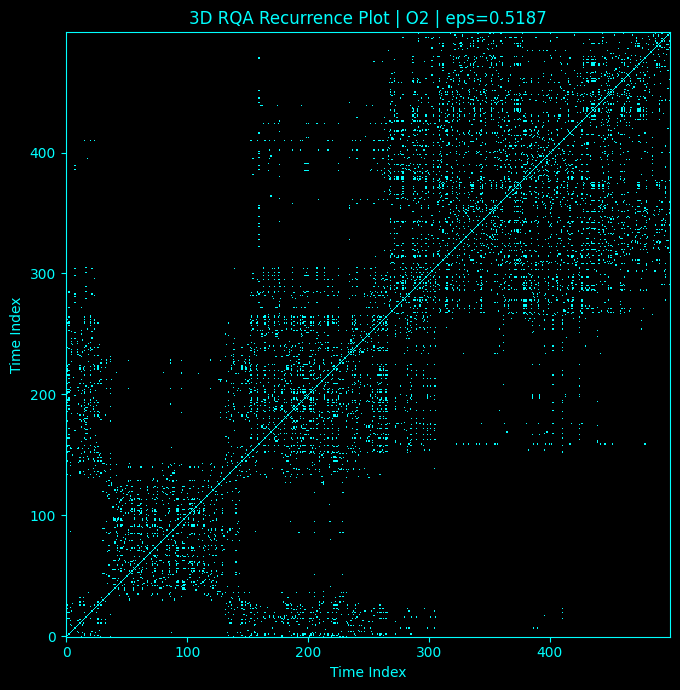

Done.


In [22]:
import os
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

from pyrqa.settings import Settings
from pyrqa.neighbourhood import FixedRadius
from pyrqa.computation import RQAComputation
from pyrqa.time_series import EmbeddedSeries
from pyrqa.metric import EuclideanMetric
from pyrqa.analysis_type import Classic

warnings.filterwarnings(
    "ignore",
    message="Non-empty compiler output encountered.*"
)

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

# -------------------------------------------------------
# CONFIG — ROBUST FILE DISCOVERY
# -------------------------------------------------------
_project_roots = [
    os.environ.get("NEURAL_SIGNAL_PROJECT_DIR"),
    "/home/a/projects/Complete-Neural-Signal-Analysis",
    "/home/a/projects/Explore-Neural-Signals1",
    os.getcwd(),
]
_project_roots = [
    Path(p).expanduser().resolve()
    for p in _project_roots
    if p
]
_project_roots = list(dict.fromkeys(_project_roots))

# Both layouts occur in this project history; accept either.
_embedding_candidates = []
for _root in _project_roots:
    _embedding_candidates.extend([
        _root / "embedding_data" / "3dembedding_data",
        _root / "3dembedding_data",
    ])
embedding_3d_dir = next((p for p in _embedding_candidates if p.is_dir()), None)

if embedding_3d_dir is None:
    _dir_hits = []
    for _root in _project_roots:
        if _root.is_dir():
            _dir_hits.extend(
                p for p in _root.rglob("3dembedding_data")
                if p.is_dir()
            )
    if _dir_hits:
        # Prefer a directory that actually contains .npy embeddings.
        _dir_hits.sort(
            key=lambda p: (
                any(p.glob("*.npy")),
                p.stat().st_mtime,
            ),
            reverse=True,
        )
        embedding_3d_dir = _dir_hits[0]

if embedding_3d_dir is None:
    raise FileNotFoundError(
        "Could not find the 3-D embedding directory. Checked project roots:\n  - "
        + "\n  - ".join(str(p) for p in _project_roots)
        + "\nGenerate the 3-D embeddings first, or set "
          "NEURAL_SIGNAL_PROJECT_DIR to the project folder."
    )

# Keep outputs at the project root that owns the embedding folder.
base_dir = next(
    (
        root for root in _project_roots
        if root == embedding_3d_dir
        or root in embedding_3d_dir.parents
    ),
    embedding_3d_dir.parent,
)
output_directory = base_dir / "rqa_results_3d"
plots_directory = output_directory / "plots"
rp_directory = plots_directory / "recurrence_plots"

output_directory.mkdir(parents=True, exist_ok=True)
plots_directory.mkdir(parents=True, exist_ok=True)
rp_directory.mkdir(parents=True, exist_ok=True)

print("Using 3-D embedding directory:", embedding_3d_dir)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

THEILER = 1
TARGET_RR_FOR_RQA = 0.03
TARGET_RR_FOR_PLOT = 0.03

RADIUS_ESTIMATION_POINTS = _speed_count(2500, 700)
RP_MAX_POINTS = _speed_count(1500, 500)
RQA_STRIDE = {"full": 1, "balanced": 2, "fast": 4, "ultra": 8}[FAST_OPTION]

MAKE_RECURRENCE_PLOTS = True
HIDE_MAIN_DIAGONAL_IN_PLOT = False
SHOW_PLOTS = True

BG = "black"
ACCENT = "cyan"

rng = np.random.default_rng(0)

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

CYAN_BLACK_CMAP = LinearSegmentedColormap.from_list("black_cyan", [BG, ACCENT])
RP_CMAP = ListedColormap([BG, ACCENT])

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(False)

def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)

def safe_float_attr(obj, attr_name, default=np.nan):
    value = getattr(obj, attr_name, default)
    try:
        return float(value)
    except Exception:
        return default

def zscore_columns(X):
    X = np.asarray(X, dtype=np.float64)
    return (X - np.mean(X, axis=0, keepdims=True)) / (
        np.std(X, axis=0, keepdims=True) + 1e-12
    )

def random_subsample_rows(X, max_points, rng):
    X = np.asarray(X)
    n = len(X)
    if n <= max_points:
        return X
    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx]

def estimate_radius_from_sample(X, target_rr=0.03, theiler=1, sample_points=2500, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    Xs = random_subsample_rows(X, sample_points, rng).astype(np.float32, copy=False)
    n = len(Xs)

    if n < 2:
        return 0.1

    diffs = Xs[:, None, :] - Xs[None, :, :]
    D = np.sqrt(np.sum(diffs * diffs, axis=2, dtype=np.float32), dtype=np.float32)

    mask = np.triu(np.ones((n, n), dtype=bool), k=max(1, theiler + 1))
    vals = D[mask]
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return 0.1

    q = float(np.clip(target_rr, 1e-4, 0.5))
    return float(np.quantile(vals, q))

# -------------------------------------------------------
# LOAD 3D EMBEDDINGS
# -------------------------------------------------------
def load_3d_embedded_channel(channel_name):
    candidates = [
        embedding_3d_dir / f"3dembedded_{channel_name}.npy",
        embedding_3d_dir / f"3dembedded_{channel_name}_data.npy",
    ]
    for path in candidates:
        if path.exists():
            arr = np.load(path)
            arr = np.asarray(arr, dtype=np.float64)
            if arr.ndim != 2 or arr.shape[1] != 3:
                raise ValueError(f"{path.name} must have shape (N, 3), got {arr.shape}")
            return arr
    raise FileNotFoundError(f"No 3D embedded file found for {channel_name}")

# -------------------------------------------------------
# RQA
# -------------------------------------------------------
def compute_rqa_for_channel_3d(embedded_points, channel_name):
    X = zscore_columns(embedded_points)

    if RQA_STRIDE > 1:
        X = X[::RQA_STRIDE]

    radius = estimate_radius_from_sample(
        X,
        target_rr=TARGET_RR_FOR_RQA,
        theiler=THEILER,
        sample_points=RADIUS_ESTIMATION_POINTS,
        rng=rng
    )

    embedded_series = EmbeddedSeries(X.tolist())

    settings = Settings(
        embedded_series,
        analysis_type=Classic,
        neighbourhood=FixedRadius(radius),
        similarity_measure=EuclideanMetric(),
        theiler_corrector=THEILER
    )

    result = RQAComputation.create(settings).run()

    rr = safe_float_attr(result, "recurrence_rate")
    det = safe_float_attr(result, "determinism")
    lam = safe_float_attr(result, "laminarity")

    metrics = {
        "N_used": len(X),
        "radius_used": radius,
        "RR": rr,
        "DET": det,
        "LAM": lam,
        "L": safe_float_attr(result, "average_diagonal_line"),
        "Lmax": safe_float_attr(result, "longest_diagonal_line"),
        "L_entr": safe_float_attr(result, "entropy_diagonal_lines"),
        "TT": safe_float_attr(result, "trapping_time"),
        "Vmax": safe_float_attr(result, "longest_vertical_line"),
        "V_entr": safe_float_attr(result, "entropy_vertical_lines"),
        "W": safe_float_attr(result, "average_white_vertical_line"),
        "Wmax": safe_float_attr(result, "longest_white_vertical_line"),
        "W_entr": safe_float_attr(result, "entropy_white_vertical_lines"),
        "DET/RR": det / rr if np.isfinite(rr) and rr != 0 else np.nan,
        "LAM/DET": lam / det if np.isfinite(det) and det != 0 else np.nan,
    }

    return channel_name, metrics

# -------------------------------------------------------
# 3D RECURRENCE PLOT IMAGE
# -------------------------------------------------------
def build_recurrence_matrix_for_plot(X):
    X = zscore_columns(X)
    X = random_subsample_rows(X, RP_MAX_POINTS, rng).astype(np.float32, copy=False)

    radius = estimate_radius_from_sample(
        X,
        target_rr=TARGET_RR_FOR_PLOT,
        theiler=THEILER,
        sample_points=min(RADIUS_ESTIMATION_POINTS, len(X)),
        rng=rng
    )

    diffs = X[:, None, :] - X[None, :, :]
    D = np.sqrt(np.sum(diffs * diffs, axis=2, dtype=np.float32), dtype=np.float32)
    R = (D <= radius).astype(np.uint8)

    n = R.shape[0]
    if THEILER > 0:
        for k in range(-THEILER, THEILER + 1):
            i = np.arange(n)
            j = i + k
            good = (j >= 0) & (j < n)
            R[i[good], j[good]] = 0

    if not HIDE_MAIN_DIAGONAL_IN_PLOT:
        np.fill_diagonal(R, 1)

    return R, radius

def save_recurrence_plot(channel_name, embedded_points, out_dir):
    rp, radius = build_recurrence_matrix_for_plot(embedded_points)

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
    style_ax(ax)
    ax.imshow(rp, cmap=RP_CMAP, origin="lower", interpolation="nearest", aspect="equal")
    ax.set_title(f"3D RQA Recurrence Plot | {channel_name} | eps={radius:.4f}")
    ax.set_xlabel("Time Index")
    ax.set_ylabel("Time Index")

    out_path = out_dir / f"RP3D_{channel_name}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)

def valid_metric_columns(df):
    cols = []
    for c in df.columns:
        if c == "Channel":
            continue
        vals = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
        if np.isfinite(vals).any():
            cols.append(c)
    return cols

def save_metric_heatmap(df, out_path):
    metric_cols = valid_metric_columns(df)
    if not metric_cols:
        return

    values = df[metric_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    mins = np.nanmin(values, axis=0)
    maxs = np.nanmax(values, axis=0)
    norm = (values - mins) / (maxs - mins + 1e-12)

    fig, ax = plt.subplots(figsize=(18, 6), facecolor=BG)
    style_ax(ax)
    im = ax.imshow(norm.T, aspect="auto", cmap=CYAN_BLACK_CMAP, interpolation="nearest")
    ax.set_title("3D RQA Metrics Heatmap")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Metric")
    ax.set_xticks(np.arange(len(df)))
    ax.set_xticklabels(df["Channel"], rotation=90)
    ax.set_yticks(np.arange(len(metric_cols)))
    ax.set_yticklabels(metric_cols)

    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Normalized Value", color=ACCENT)
    style_colorbar(cbar)

    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)

# -------------------------------------------------------
# MAIN
# -------------------------------------------------------
results = []
errors = []

for channel in eeg_channels:
    try:
        X3 = load_3d_embedded_channel(channel)
        results.append(compute_rqa_for_channel_3d(X3, channel))
        print(f"[3D RQA OK] {channel}: shape={X3.shape}")
    except Exception as e:
        errors.append((channel, str(e)))
        print(f"[3D RQA ERROR] {channel}: {e}")

if not results:
    raise RuntimeError("No 3D RQA results were computed.")

flattened_results = [(channel, *metrics.values()) for channel, metrics in results]
df_columns = [
    "Channel",
    "N_used",
    "radius_used",
    "RR", "DET", "LAM", "L", "Lmax", "L_entr", "TT",
    "Vmax", "V_entr", "W", "Wmax", "W_entr",
    "DET/RR", "LAM/DET"
]
df = pd.DataFrame(flattened_results, columns=df_columns)

df["Channel"] = pd.Categorical(df["Channel"], categories=eeg_channels, ordered=True)
df = df.sort_values("Channel").reset_index(drop=True)

csv_path = output_directory / "rqa_results_3d.csv"
df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

save_metric_heatmap(df, plots_directory / "rqa_metrics_heatmap_3d.png")

if MAKE_RECURRENCE_PLOTS:
    for channel in df["Channel"]:
        try:
            X3 = load_3d_embedded_channel(channel)
            save_recurrence_plot(channel, X3, rp_directory)
        except Exception as e:
            print(f"[3D RP ERROR] {channel}: {e}")

print("Done.")

### Shared foundation for the title-only dynamical estimators

The next four cells estimate instability by different constructions and therefore should not be conflated. **Kantz** averages neighbor divergence in a delay embedding; the **Wolf-style** estimator follows and replaces a nearby trajectory; **Sano–Sawada/Eckmann–Ruelle style** estimation fits local tangent maps and applies QR; and **Benettin** applies QR to a variational equation of an explicit fitted ODE surrogate. All returned exponents are divided by physical elapsed time, so changing `full / balanced / fast / ultra` changes computational density but not the units or the mathematical definition.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Delay embedding turns one measured time series into a sequence of state-space vectors by combining the present sample with delayed copies of the same signal. The idea is that the hidden state of a dynamical system can sometimes be reconstructed from a single observable when enough delayed coordinates are used. The delay controls how far apart in time the coordinates are, while the embedding dimension controls how many delayed coordinates are included. Too small a delay makes coordinates nearly redundant; too large a delay can make them weakly related. Too small an embedding dimension can fold distinct states onto one another.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.spatial import cKDTree
from scipy.linalg import expm

FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: full, balanced, fast, ultra")
_DS_SPEED = {
 "full":dict(down=1,max_samples=35000,refs=500,neighbors=20,jac_points=5000,ben_steps=3000),
 "balanced":dict(down=2,max_samples=22000,refs=320,neighbors=16,jac_points=3200,ben_steps=2000),
 "fast":dict(down=4,max_samples=12000,refs=200,neighbors=12,jac_points=2000,ben_steps=1200),
 "ultra":dict(down=8,max_samples=6000,refs=100,neighbors=8,jac_points=1000,ben_steps=600),
}[FAST_OPTION]
_DS_NAMES=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
_ds_fs0=float(globals().get('DYNAMICAL_FS_OVERRIDE',1000.0))
if 'DYNAMICAL_DATA_OVERRIDE' in globals():
    _ds_raw=np.asarray(globals()['DYNAMICAL_DATA_OVERRIDE'],float)
else:
    _roots=[
        os.environ.get("NEURAL_SIGNAL_PROJECT_DIR"),
        "/home/a/projects/Complete-Neural-Signal-Analysis",
        "/home/a/projects/Explore-Neural-Signals1",
        os.getcwd(),
    ]
    _roots=[os.path.abspath(os.path.expanduser(p)) for p in _roots if p]
    _roots=list(dict.fromkeys(_roots))
    _eeg_candidates=[os.path.join(r,"eeg_data_with_channels.npy") for r in _roots]
    _eeg_path=next((p for p in _eeg_candidates if os.path.isfile(p)),None)
    if _eeg_path is None:
        raise FileNotFoundError(
            "Could not find eeg_data_with_channels.npy. Checked:\n  - "
            + "\n  - ".join(_eeg_candidates)
            + "\nSet DYNAMICAL_DATA_OVERRIDE or NEURAL_SIGNAL_PROJECT_DIR."
        )
    _aa=np.load(_eeg_path,allow_pickle=True)
    if _aa.shape[0]<=64 and _aa.shape[1]>_aa.shape[0]: _aa=_aa.T
    _i0,_i1=int(814.571*_ds_fs0),int(921.515*_ds_fs0);_ds_raw=np.asarray(_aa[_i0:min(_i1,len(_aa))],float)
    print("Using EEG file:", _eeg_path)
_ds_raw=_ds_raw[:_DS_SPEED['max_samples']]
_d=_DS_SPEED['down'];_ds_X=signal.resample_poly(_ds_raw,1,_d,axis=0) if _d>1 else _ds_raw.copy();_ds_fs=_ds_fs0/_d
_ds_X=signal.detrend(_ds_X,axis=0,type='constant');_ds_X=(_ds_X-_ds_X.mean(0))/( _ds_X.std(0)+1e-12)
_c3=_DS_NAMES.index('C3') if 'C3' in _DS_NAMES[:_ds_X.shape[1]] else 0;_ds_y=_ds_X[:,_c3]

def _ds_embed(y,m,tau):
    y=np.asarray(y,float);n=len(y)-(m-1)*tau
    if n<=1:return np.empty((0,m))
    return np.column_stack([y[j*tau:j*tau+n] for j in range(m)])

def _kantz_curve(y,m=None,tau=None):
    tau=int(tau or max(1,round(.008*_ds_fs)));m=int(m or 10);E=_ds_embed(y,m,tau);kmax=max(8,min(int(.15*_ds_fs),len(E)//8));theiler=max(2*tau,int(.04*_ds_fs));valid=np.arange(0,max(0,len(E)-kmax));tree=cKDTree(E);refs=valid[np.linspace(0,len(valid)-1,min(len(valid),_DS_SPEED['refs'])).astype(int)] if len(valid) else np.array([],int);acc=[[] for _ in range(kmax+1)]
    for i in refs:
        _,cand=tree.query(E[i],k=min(len(E),max(30,4*_DS_SPEED['neighbors'])))
        cand=np.atleast_1d(cand);cand=[int(j) for j in cand if abs(int(j)-int(i))>theiler and int(j)+kmax<len(E)][: _DS_SPEED['neighbors']]
        for j in cand:
            for k in range(kmax+1):
                d=np.linalg.norm(E[i+k]-E[j+k]);
                if d>1e-12:acc[k].append(np.log(d))
    curve=np.array([np.mean(v) if v else np.nan for v in acc]);return curve,tau

def _fit_lle(curve,t0=.02,t1=.08):
    curve=np.asarray(curve,float);t=np.arange(len(curve))/_ds_fs;mask=(t>=t0)&(t<=min(t1,t[-1] if len(t) else 0))&np.isfinite(curve)
    if mask.sum()<3:mask=np.isfinite(curve)
    if mask.sum()<2:return np.nan,t,mask
    coef=np.polyfit(t[mask],curve[mask],1);return float(coef[0]),t,mask

def _wolf_lle(y,m=8,tau=None):
    tau=int(tau or max(1,round(.008*_ds_fs)));E=_ds_embed(y,m,tau);theiler=max(2*tau,int(.04*_ds_fs));tree=cKDTree(E);i=0;total_log=0.;total_time=0.;segments=0;maxe=max(3,int(.04*_ds_fs));growth=8.;
    while i+maxe<len(E) and segments<_DS_SPEED['refs']:
        _,cand=tree.query(E[i],k=min(len(E),80));js=[int(j) for j in np.atleast_1d(cand) if abs(int(j)-i)>theiler and int(j)+maxe<len(E)]
        if not js: i+=maxe;continue
        j=js[0];d0=np.linalg.norm(E[i]-E[j])+1e-12;evolve=1
        while evolve<maxe and np.linalg.norm(E[i+evolve]-E[j+evolve])<growth*d0:evolve+=1
        d1=np.linalg.norm(E[i+evolve]-E[j+evolve])+1e-12;total_log+=np.log(d1/d0);total_time+=evolve/_ds_fs;segments+=1;i+=evolve
    return float(total_log/(total_time+1e-12)),segments

def _local_qr_spectrum(y,m=6,tau=None):
    tau=int(tau or max(1,round(.008*_ds_fs)));E=_ds_embed(y,m,tau);n=min(len(E)-1,_DS_SPEED['jac_points']);E=E[:n+1];tree=cKDTree(E[:-1]);Q=np.eye(m);sums=np.zeros(m);steps=0;k=max(m+3,_DS_SPEED['neighbors'])
    for i in range(n):
        _,nn=tree.query(E[i],k=min(k+1,n));nn=np.atleast_1d(nn);nn=nn[nn!=i];nn=nn[nn<n]
        if len(nn)<m+1:continue
        A=E[nn]-E[i];B=E[nn+1]-E[i+1];J=np.linalg.lstsq(A,B,rcond=1e-5)[0].T;Z=J@Q;Q,R=np.linalg.qr(Z);sums+=np.log(np.abs(np.diag(R))+1e-12);steps+=1
    return sums/(max(1,steps)/_ds_fs)

def _benettin_linear_ode(X=None):
    X=np.asarray(_ds_X[:,:min(6,_ds_X.shape[1])] if X is None else X,float);dt=1/_ds_fs;dX=(X[2:]-X[:-2])/(2*dt);Xm=X[1:-1];A=np.linalg.lstsq(Xm,dX,rcond=1e-5)[0].T;Phi=expm(A*dt);Q=np.eye(A.shape[0]);sums=np.zeros(A.shape[0]);n=min(_DS_SPEED['ben_steps'],len(Xm))
    for _ in range(n):Q,R=np.linalg.qr(Phi@Q);sums+=np.log(np.abs(np.diag(R))+1e-15)
    return sums/(n*dt),A
print(f'Dynamical estimator foundation ready: mode={FAST_OPTION}, samples={len(_ds_y)}, fs={_ds_fs:.3f} Hz')

Using EEG file: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Dynamical estimator foundation ready: mode=ultra, samples=750, fs=125.000 Hz


### Kantz largest Lyapunov exponent

Kantz estimates the largest Lyapunov exponent from the average logarithmic separation of neighborhoods in a delay reconstruction. For reference state $X_i$ and admissible neighbors $X_j$ outside a Theiler window,
\[
S(k)=\left\langle \log \|X_{i+k}-X_{j+k}\|\right\rangle_{i,j}\approx c+\lambda_{max}k\Delta t.
\]
A linear fit to the early approximately exponential region of $S(k)$ yields $\lambda_{max}$. The implementation keeps the delay and fit interval in physical time as speed modes change the effective sample rate.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Kantz LLE = 5.417786700473428 1/s tau_samples= 1


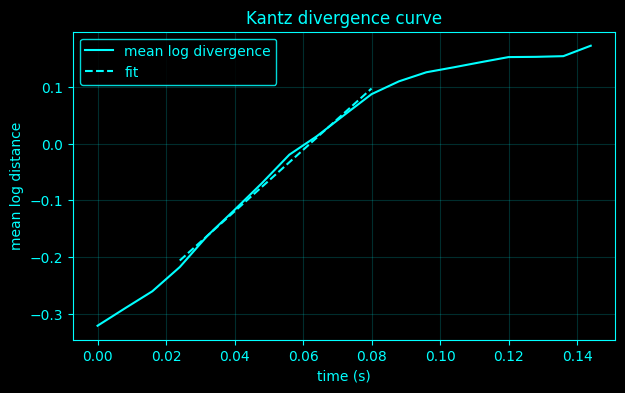

In [24]:
_kantz,_tau=_kantz_curve(_ds_y);_lle,_tt,_mask=_fit_lle(_kantz)
print('Kantz LLE =',_lle,'1/s','tau_samples=',_tau)
plt.figure(figsize=(7,4));plt.plot(_tt,_kantz,label='mean log divergence');plt.plot(_tt[_mask],np.polyval(np.polyfit(_tt[_mask],_kantz[_mask],1),_tt[_mask]),'--',label='fit');plt.xlabel('time (s)');plt.ylabel('mean log distance');plt.title('Kantz divergence curve');plt.grid(alpha=.2);plt.legend();plt.show()

### Wolf-style largest Lyapunov exponent

The Wolf procedure follows a nearby trajectory until its separation from the reference has grown substantially, accumulates $\log(d_1/d_0)$ over the elapsed time, then replaces the neighbor and repeats. A finite-data estimate is
\[
\lambda_{max}\approx \frac{\sum_r\log(d_{1,r}/d_{0,r})}{\sum_r\Delta t_r}.
\]
The cell implements this nearest-neighbor replacement idea in the same delay embedding. It is labelled **Wolf-style** because practical Wolf implementations differ in replacement-angle and neighborhood rules.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


Wolf-style LLE = 12.136302292033834 1/s replacement segments= 100


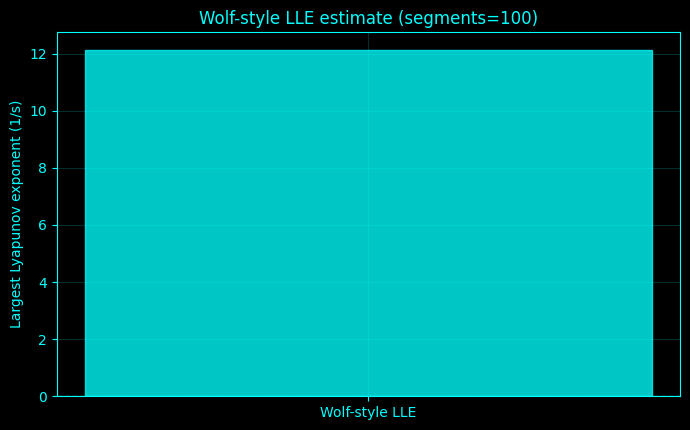

In [25]:
_wolf,_segments=_wolf_lle(_ds_y)
print('Wolf-style LLE =',_wolf,'1/s','replacement segments=',_segments)

fig, ax = plt.subplots(figsize=(7.0, 4.4), facecolor=BG)
style_ax(ax)

ax.bar(
    ['Wolf-style LLE'],
    [_wolf],
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.78,
)
ax.axhline(0.0, color=ACCENT, linestyle='--', linewidth=1.0, alpha=0.65)
ax.set_ylabel('Largest Lyapunov exponent (1/s)')
ax.set_title(f'Wolf-style LLE estimate (segments={_segments})')

fig.tight_layout()
plt.show()
plt.close(fig)


### Eckmann–Ruelle / Sano–Sawada style local-Jacobian + QR Lyapunov spectrum

A local tangent map $J_t$ is estimated from neighboring delay vectors by least squares,
\[
X_{j+1}-X_{i+1}\approx J_t(X_j-X_i).
\]
Successive tangent maps are propagated with QR orthonormalization, $J_tQ_t=Q_{t+1}R_t$. The exponents are estimated from
\[
\lambda_k\approx \frac{1}{T}\sum_t\log |(R_t)_{kk}|.
\]
This is a data-driven local-linear tangent estimate in reconstructed state space; it is not an exact Jacobian of an unknown physiological differential equation.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


Local-Jacobian/QR Lyapunov spectrum (1/s): [ 26.44177029  11.11611885  -1.20584141 -12.98721036 -32.46260383
 -82.19387937]
Largest exponent: 26.44177028677512


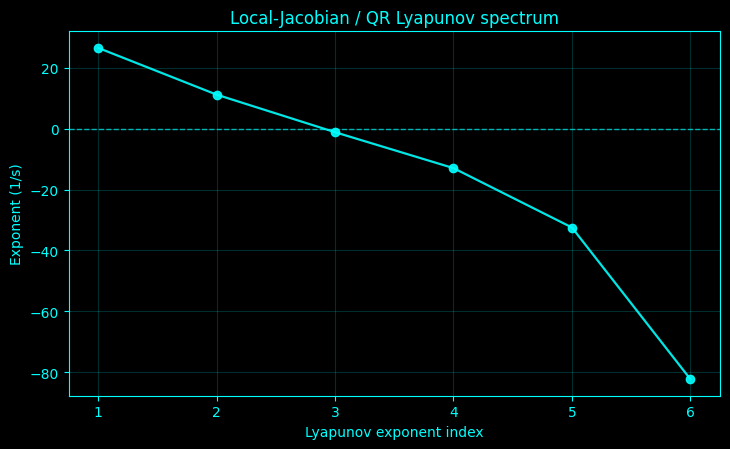

In [26]:
_spec=_local_qr_spectrum(_ds_y,m=6)
print('Local-Jacobian/QR Lyapunov spectrum (1/s):',_spec)
print('Largest exponent:',float(np.max(_spec)))

_idx=np.arange(1,len(_spec)+1)
fig, ax = plt.subplots(figsize=(7.4, 4.6), facecolor=BG)
style_ax(ax)

ax.plot(
    _idx,
    _spec,
    color=ACCENT,
    marker='o',
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT,
    linewidth=1.6,
    alpha=0.90,
)
ax.axhline(0.0, color=ACCENT, linestyle='--', linewidth=1.0, alpha=0.65)
ax.set_xlabel('Lyapunov exponent index')
ax.set_ylabel('Exponent (1/s)')
ax.set_title('Local-Jacobian / QR Lyapunov spectrum')
ax.set_xticks(_idx)

fig.tight_layout()
plt.show()
plt.close(fig)


### Model-based Benettin / variational-equation Lyapunov exponents

Benettin's method assumes a dynamical model $\dot x=f(x)$ with variational equation $\dot\delta=Df(x)\delta$. Because the EEG recording does not supply $f$ or $Df$, this cell first fits an explicit **linear ODE surrogate** $\dot x=Ax$ to a small multichannel state. Its variational flow over one sample is $\Phi=e^{A\Delta t}$. Repeated QR steps on $\Phi Q$ give model Lyapunov exponents from accumulated $\log|R_{kk}|/T$. These are exponents of the fitted surrogate, not direct model-free EEG Lyapunov invariants.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


Benettin exponents of fitted linear ODE surrogate (1/s): [ 1.50812811e+02  7.52794493e-01  1.99068567e-01  5.41625197e-02
 -3.13612591e-01 -1.69407991e-01]
Largest model-based exponent: 150.81281117344014


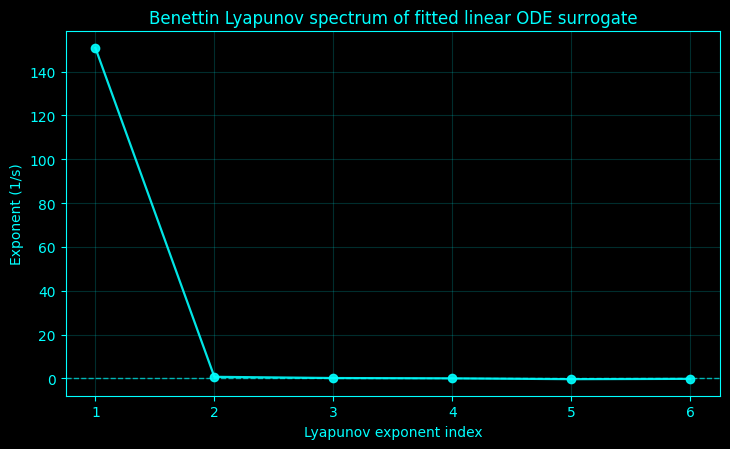

In [30]:
_ben,_Aode=_benettin_linear_ode()
print('Benettin exponents of fitted linear ODE surrogate (1/s):',_ben)
print('Largest model-based exponent:',float(np.max(_ben)))

_idx=np.arange(1,len(_ben)+1)
fig, ax = plt.subplots(figsize=(7.4, 4.6), facecolor=BG)
style_ax(ax)

ax.plot(
    _idx,
    _ben,
    color=ACCENT,
    marker='o',
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT,
    linewidth=1.6,
    alpha=0.90,
)
ax.axhline(0.0, color=ACCENT, linestyle='--', linewidth=1.0, alpha=0.65)
ax.set_xlabel('Lyapunov exponent index')
ax.set_ylabel('Exponent (1/s)')
ax.set_title('Benettin Lyapunov spectrum of fitted linear ODE surrogate')
ax.set_xticks(_idx)

fig.tight_layout()
plt.show()
plt.close(fig)


### Entropy rate

For a stationary discrete process, Shannon entropy rate is
\[
h=\lim_{L\to\infty}[H(S_1,\ldots,S_L)-H(S_1,\ldots,S_{L-1})].
\]
A finite EEG record cannot take this limit directly. The cell quantile-symbolizes the same C3 segment, computes block entropies $H(L)$ for several $L$, and reports the last block-entropy increments as a finite-order entropy-rate estimate. The result is partition-dependent and is not automatically Kolmogorov–Sinai entropy.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


finite symbolic entropy-rate estimate = 0.518096616683978 nats/sample = 64.76207708549725 nats/s


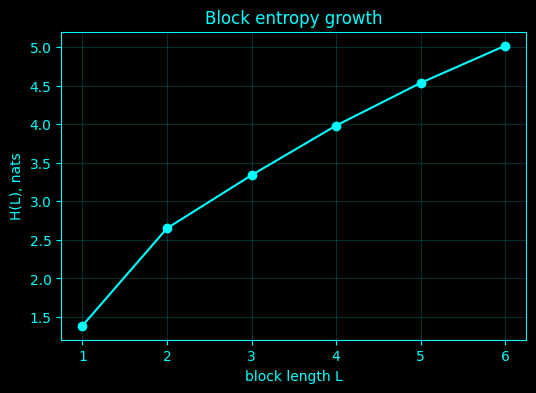

In [31]:
from numpy.lib.stride_tricks import sliding_window_view
_sym=np.digitize(_ds_y,np.quantile(_ds_y,[.25,.5,.75]))
def _block_H_ds(s,L):
    B=sliding_window_view(np.asarray(s,int),L);_,cnt=np.unique(B,axis=0,return_counts=True);p=cnt/cnt.sum();return float(-np.sum(p*np.log(p)))
_L=np.arange(1,7);_HH=np.array([_block_H_ds(_sym,int(L)) for L in _L]);_inc=np.diff(np.r_[0,_HH]);_hr=float(np.mean(_inc[-2:]))
print('finite symbolic entropy-rate estimate =',_hr,'nats/sample =',_hr*_ds_fs,'nats/s')
plt.figure(figsize=(6,4));plt.plot(_L,_HH,'o-');plt.xlabel('block length L');plt.ylabel('H(L), nats');plt.title('Block entropy growth');plt.grid(alpha=.2);plt.show()

### 3D Scatter Plot with Stability Label

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This document details a visualization approach for analyzing the distribution and stability of Lyapunov exponents derived from EEG data, leveraging a 3D scatter plot. Lyapunov exponents are critical in understanding the chaotic dynamics of systems, and their visualization facilitates a deeper comprehension of system stability.</p>
        <h2>Visualization Methodology</h2>
        <p>The 3D scatter plot is generated using matplotlib, a Python library for data visualization. The plot correlates three dimensions of Lyapunov exponents, with color coding representing a stability measure derived from these exponents. A custom color map ranging from yellow (stable) to red (chaotic) is utilized to visually indicate the system's stability.</p>
        <h2>Custom Colormap</h2>
        <p>A linear segmented colormap is defined to interpolate colors between specified points. In this case, the colormap transitions from yellow, through orange, to red, symbolizing a gradient from stability to chaos. This colormap is integral to conveying the stability measure effectively.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Plot Configuration</h2>
        <p>The configuration of the 3D scatter plot includes setting the background color of the plot area to black and adjusting grid, spine, tick, and label colors to enhance visual contrast and clarity. The stability measure, computed from the first Lyapunov exponent, is used to color-code the scatter points, providing an intuitive representation of system stability across the plotted exponents.</p>
        <h2>Technical Details</h2>
        <p>The stability measure is normalized to a range between -1 and 1, with positive values indicating lower stability (higher chaos). This normalization facilitates a direct visual correlation between color intensity and system stability. The addition of a color bar further aids in interpreting the stability measure quantitatively.</p>
        <h2>Conclusion</h2>
        <p>This visualization strategy not only showcases the distribution of Lyapunov exponents in a 3D space but also highlights the relationship between these exponents and the system's stability. Such visualizations are invaluable in the exploratory analysis phase, providing immediate insights into the chaotic dynamics underlying EEG data.</p>
    </div>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — visualization of channel Lyapunov stability scores</h3><p>This cell transforms previously estimated leading Lyapunov exponents into display coordinates and plots them in three dimensions. A positive leading exponent corresponds to exponential separation in the fitted dynamics; a negative value corresponds to contraction.</p><p>Any bounded rescaling used for color or position is a visualization mapping, not a new dynamical invariant.</p><p><b>Cell role.</b> The scientific quantity is the underlying Lyapunov estimate shown by the plot.</p></div>

$$\delta(t)\sim\delta(0)e^{\lambda_1 t}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Computing channel-wise Local-Jacobian / QR Lyapunov spectra...
[OK] Fp1: λ1=27.543690, λ2=11.729327, λ3=-1.775508 1/s
[OK] Fpz: λ1=30.502160, λ2=14.559360, λ3=2.076855 1/s
[OK] Fp2: λ1=25.126999, λ2=13.663205, λ3=-0.718131 1/s
[OK] F7: λ1=32.527539, λ2=16.728459, λ3=-0.682147 1/s
[OK] F3: λ1=32.664221, λ2=12.930774, λ3=4.023210 1/s
[OK] Fz: λ1=29.598629, λ2=12.259617, λ3=2.567492 1/s
[OK] F4: λ1=27.756272, λ2=13.626057, λ3=1.763576 1/s
[OK] F8: λ1=35.244784, λ2=14.355992, λ3=-1.383197 1/s
[OK] FC5: λ1=34.432853, λ2=16.559015, λ3=2.822899 1/s
[OK] FC1: λ1=28.632822, λ2=12.601935, λ3=2.907802 1/s
[OK] FC2: λ1=28.025759, λ2=12.115440, λ3=-2.578289 1/s
[OK] FC6: λ1=29.912240, λ2=14.002453, λ3=0.728124 1/s
[OK] M1: λ1=35.783743, λ2=17.343151, λ3=2.141741 1/s
[OK] T7: λ1=40.257583, λ2=20.086652, λ3=6.698884 1/s
[OK] C3: λ1=26.441770, λ2=11.116119, λ3=-1.205841 1/s
[OK] Cz: λ1=24.100122, λ2=10.281221, λ3=0.372453 1/s
[OK] C4: λ1=30.987126, λ2=12.591431, λ3=2.286131 1/s
[OK] T8: λ1=37.334550, 

/tmp/ipykernel_102769/400759027.py:266: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


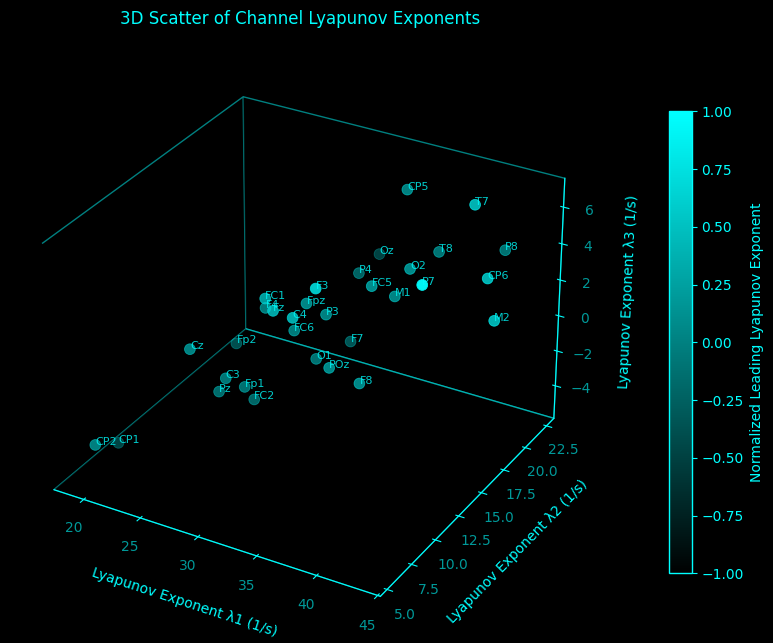


Lyapunov stability summary
--------------------------
Channels plotted : 32
Chaotic          : 32
Stable           : 0


In [32]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# -------------------------------------------------------
# BUILD CHANNEL-WISE LYAPUNOV EXPONENTS
# -------------------------------------------------------
# The preceding dynamical-systems foundation cell already defines:
#   _ds_X
#   _DS_NAMES
#   _local_qr_spectrum(...)
#
# The original version of this cell expected a dictionary named
# "lyapunov_exponents", but that dictionary was never created.

if "_ds_X" not in globals():
    raise RuntimeError(
        "_ds_X is not defined. Run the preceding "
        "'Shared foundation for the title-only dynamical estimators' cell first."
    )

if "_DS_NAMES" not in globals():
    raise RuntimeError(
        "_DS_NAMES is not defined. Run the preceding dynamical-estimator "
        "foundation cell first."
    )

if "_local_qr_spectrum" not in globals():
    raise RuntimeError(
        "_local_qr_spectrum() is not defined. Run the preceding "
        "Local-Jacobian / QR Lyapunov foundation cell first."
    )

# Use only channel names corresponding to columns actually present in _ds_X.
channels = list(_DS_NAMES[:_ds_X.shape[1]])

lyapunov_exponents = {}
failed_channels = []

print("Computing channel-wise Local-Jacobian / QR Lyapunov spectra...")

for channel_index, channel in enumerate(channels):
    try:
        channel_signal = np.asarray(_ds_X[:, channel_index], dtype=float)

        # Compute the Lyapunov spectrum using the same estimator already
        # defined earlier in this notebook.
        spectrum = np.asarray(
            _local_qr_spectrum(channel_signal, m=6),
            dtype=float
        )

        # A 3-D scatter requires at least three exponents.
        if spectrum.size < 3:
            raise ValueError(
                f"Only {spectrum.size} Lyapunov exponents were returned."
            )

        first_three = spectrum[:3]

        if not np.all(np.isfinite(first_three)):
            raise ValueError(
                "The first three Lyapunov exponents contain non-finite values."
            )

        lyapunov_exponents[channel] = first_three

        print(
            f"[OK] {channel}: "
            f"λ1={first_three[0]:.6f}, "
            f"λ2={first_three[1]:.6f}, "
            f"λ3={first_three[2]:.6f} 1/s"
        )

    except Exception as exc:
        failed_channels.append((channel, str(exc)))
        print(f"[SKIPPED] {channel}: {exc}")

if not lyapunov_exponents:
    raise RuntimeError(
        "No valid channel-wise Lyapunov spectra were produced."
    )

# Keep only successfully processed channels.
channels = list(lyapunov_exponents.keys())

# Shape: (number_of_channels, 3)
exponents = np.vstack(
    [lyapunov_exponents[channel] for channel in channels]
)

# -------------------------------------------------------
# STABILITY / CHAOS CLASSIFICATION
# -------------------------------------------------------
# Positive largest Lyapunov exponent -> locally divergent / chaotic label.
# Zero or negative largest exponent -> stable label.
stability_map = {
    channel: (
        "chaotic"
        if lyapunov_exponents[channel][0] > 0
        else "stable"
    )
    for channel in channels
}

# Normalize the leading Lyapunov exponent to [-1, 1].
leading_exponents = exponents[:, 0]

normalization = np.nanmax(np.abs(leading_exponents))

if not np.isfinite(normalization) or normalization == 0:
    stability_measure = np.zeros_like(leading_exponents)
else:
    stability_measure = leading_exponents / normalization

stability_measure = np.clip(stability_measure, -1.0, 1.0)

# -------------------------------------------------------
# CUSTOM COLORMAP
# -------------------------------------------------------
colors = [
    (1, 1, 0),      # yellow
    (1, 0.5, 0),    # orange
    (1, 0, 0)       # red
]

cmap_name = "yellow_orange_red"
cm = LinearSegmentedColormap.from_list(
    cmap_name,
    colors
)

# -------------------------------------------------------
# 3-D SCATTER PLOT
# -------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
fig.patch.set_facecolor("black")

ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("black")

scatter = ax.scatter(
    exponents[:, 0],
    exponents[:, 1],
    exponents[:, 2],
    c=stability_measure,
    cmap=cm,
    vmin=-1,
    vmax=1,
    s=60,
    edgecolor="black",
    linewidth=0.6
)

# -------------------------------------------------------
# CHANNEL LABELS
# -------------------------------------------------------
for i, channel in enumerate(channels):
    ax.text(
        exponents[i, 0],
        exponents[i, 1],
        exponents[i, 2],
        channel,
        color="red",
        fontsize=8,
        alpha=0.8
    )

# -------------------------------------------------------
# COLOR BAR
# -------------------------------------------------------
cbar = fig.colorbar(
    scatter,
    ax=ax,
    pad=0.10,
    shrink=0.75
)

cbar.set_label(
    "Normalized Leading Lyapunov Exponent",
    color="red"
)

cbar.ax.tick_params(colors="red")
cbar.outline.set_edgecolor("red")
cbar.outline.set_linewidth(1)

# -------------------------------------------------------
# 3-D AXIS STYLE
# -------------------------------------------------------
ax.xaxis._axinfo["grid"].update(
    color=(1, 0, 0, 0.35),
    linewidth=0.8
)

ax.yaxis._axinfo["grid"].update(
    color=(1, 0, 0, 0.35),
    linewidth=0.8
)

ax.zaxis._axinfo["grid"].update(
    color=(1, 0, 0, 0.35),
    linewidth=0.8
)

# Black panes
ax.xaxis.pane.set_facecolor((0, 0, 0, 1))
ax.yaxis.pane.set_facecolor((0, 0, 0, 1))
ax.zaxis.pane.set_facecolor((0, 0, 0, 1))

ax.xaxis.pane.set_edgecolor("red")
ax.yaxis.pane.set_edgecolor("red")
ax.zaxis.pane.set_edgecolor("red")

# Tick colors
ax.tick_params(axis="x", colors="red")
ax.tick_params(axis="y", colors="red")
ax.tick_params(axis="z", colors="red")

plt.setp(
    ax.get_xticklabels(),
    color="red",
    alpha=0.6
)

plt.setp(
    ax.get_yticklabels(),
    color="red",
    alpha=0.6
)

plt.setp(
    ax.get_zticklabels(),
    color="red",
    alpha=0.6
)

# -------------------------------------------------------
# LABELS AND TITLE
# -------------------------------------------------------
ax.set_xlabel(
    "Lyapunov Exponent λ1 (1/s)",
    color="red",
    labelpad=10
)

ax.set_ylabel(
    "Lyapunov Exponent λ2 (1/s)",
    color="red",
    labelpad=10
)

ax.set_zlabel(
    "Lyapunov Exponent λ3 (1/s)",
    color="red",
    labelpad=10
)

ax.set_title(
    "3D Scatter of Channel Lyapunov Exponents",
    color="red",
    pad=20
)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# SUMMARY
# -------------------------------------------------------
n_chaotic = sum(
    value == "chaotic"
    for value in stability_map.values()
)

n_stable = sum(
    value == "stable"
    for value in stability_map.values()
)

print()
print("Lyapunov stability summary")
print("--------------------------")
print(f"Channels plotted : {len(channels)}")
print(f"Chaotic          : {n_chaotic}")
print(f"Stable           : {n_stable}")

if failed_channels:
    print()
    print("Channels skipped:")
    for channel, reason in failed_channels:
        print(f"  {channel}: {reason}")

##### Lyapunov Exponents v.2


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Eckmann-style Lyapunov spectrum via `nolds.lyap_e`</h3><p>`nolds.lyap_e` implements an Eckmann-type reconstruction method: local linear maps are estimated in an embedding and their products are stabilized to obtain multiple Lyapunov exponents. The cell applies that estimator to the first coordinate of each stored embedding file.</p><p>The method assumes sufficient data, an appropriate embedding, and a locally smooth deterministic reconstruction. Distribution plots across files describe estimator variability; they are not independent realizations of one invariant unless the files represent comparable conditions.</p><p><b>Cell role.</b> The cell collects and visualizes the returned spectra.</p></div>

$$\lambda_i\approx\frac{1}{T\Delta t}\sum_t\log|R_{t,ii}|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


Lyapunov Spectrum Analysis
Speed mode       : ULTRA
Maximum samples : 2,500 per file

Using 3-D embedding directory:
/home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/3dembedding_data
Embedding files found: 32

[1/32] 3dembedded_C3.npy | 106,938 -> 2,487 samples | stride=43
    λ1=0.000729, λ2=-0.001258, λ3=-0.005571
[2/32] 3dembedded_C4.npy | 106,938 -> 2,487 samples | stride=43
    λ1=0.000344, λ2=-0.001284, λ3=-0.005399
[3/32] 3dembedded_CP1.npy | 106,938 -> 2,487 samples | stride=43
    λ1=0.000323, λ2=-0.001466, λ3=-0.005276
[4/32] 3dembedded_CP2.npy | 106,938 -> 2,487 samples | stride=43
    λ1=0.000613, λ2=-0.001389, λ3=-0.005596
[5/32] 3dembedded_CP5.npy | 106,938 -> 2,487 samples | stride=43
    λ1=0.001670, λ2=-0.000867, λ3=-0.004892
[6/32] 3dembedded_CP6.npy | 106,938 -> 2,487 samples | stride=43
    λ1=0.000899, λ2=-0.001340, λ3=-0.005139
[7/32] 3dembedded_Cz.npy | 106,938 -> 2,487 samples | stride=43
    λ1=0.000784, λ2=-0.001611, λ3=-0.005292
[8/32] 3dembedd

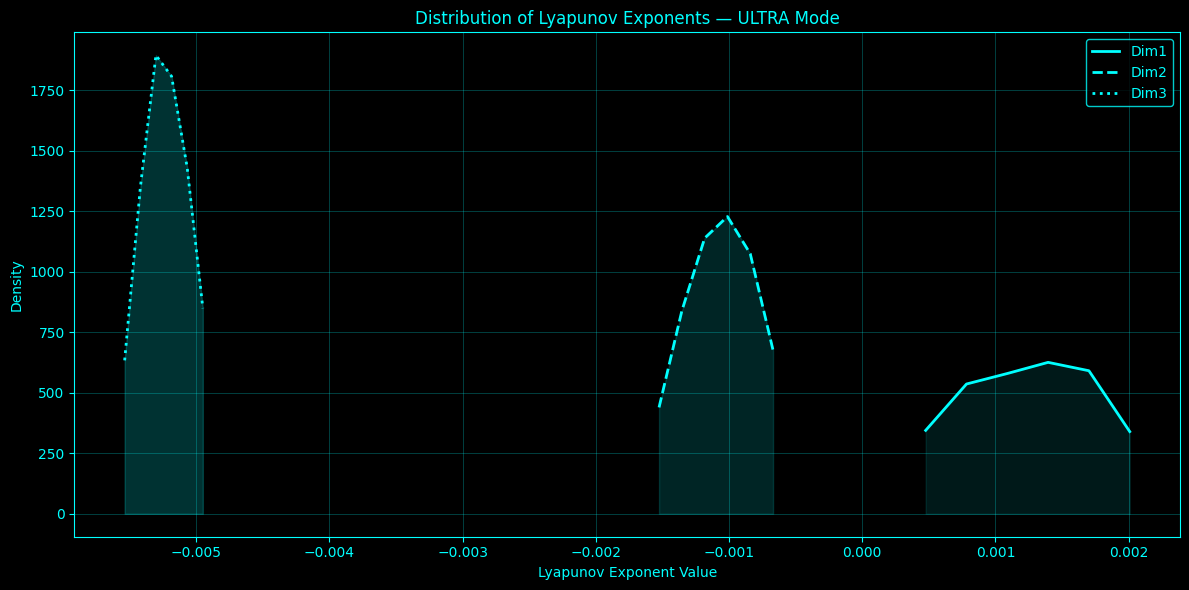

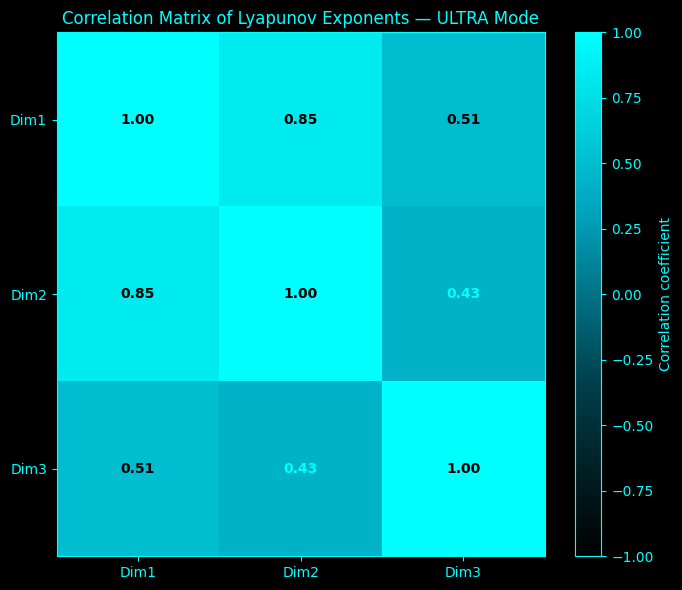

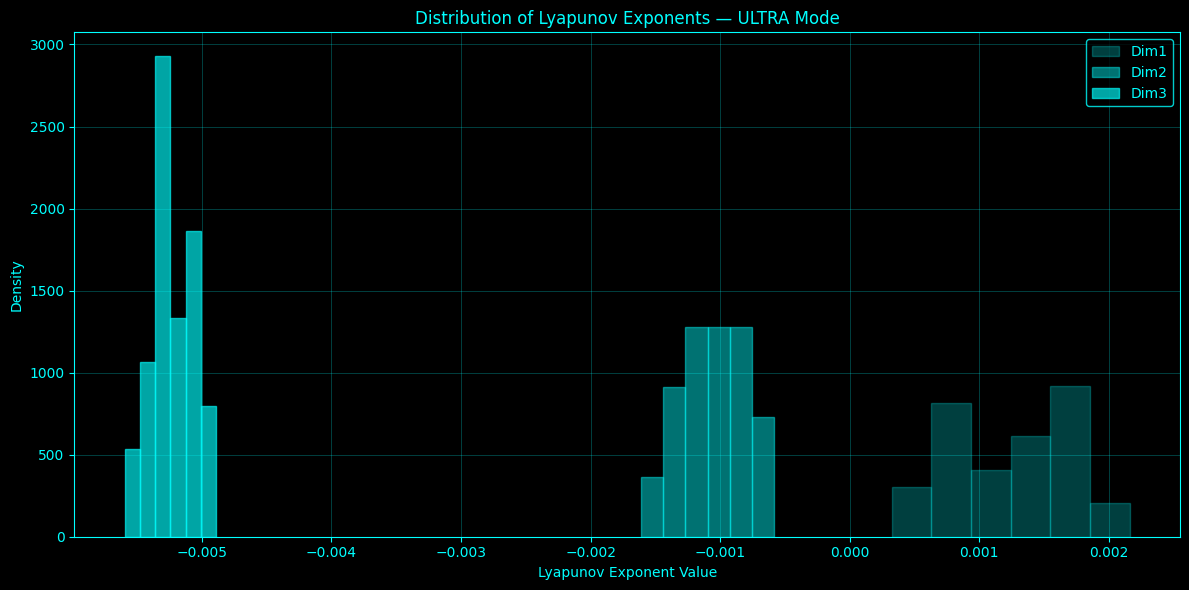


Lyapunov exponent results:
--------------------------
              File     Dim1      Dim2      Dim3  OriginalSamples  UsedSamples  SampleStride SpeedMode
 3dembedded_C3.npy 0.000729 -0.001258 -0.005571           106938         2487            43     ULTRA
 3dembedded_C4.npy 0.000344 -0.001284 -0.005399           106938         2487            43     ULTRA
3dembedded_CP1.npy 0.000323 -0.001466 -0.005276           106938         2487            43     ULTRA
3dembedded_CP2.npy 0.000613 -0.001389 -0.005596           106938         2487            43     ULTRA
3dembedded_CP5.npy 0.001670 -0.000867 -0.004892           106938         2487            43     ULTRA
3dembedded_CP6.npy 0.000899 -0.001340 -0.005139           106938         2487            43     ULTRA
 3dembedded_Cz.npy 0.000784 -0.001611 -0.005292           106938         2487            43     ULTRA
 3dembedded_F3.npy 0.001625 -0.000981 -0.005119           106938         2487            43     ULTRA
 3dembedded_F4.npy 0.001301

In [2]:
import os
import sys
import subprocess
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# =======================================================
# SPEED MODE
# =======================================================
# Options:
# FULL     = all available samples
# BALANCED = up to 12,000 samples per file
# FAST     = up to 6,000 samples per file
# ULTRA    = up to 2,500 samples per file
SPEED_MODE = "ULTRA"

SPEED_PROFILES = {
    "FULL": {
        "max_samples": None,
        "density_bins": 30,
        "hist_bins": 15,
        "smooth_kernel": 9,
    },
    "BALANCED": {
        "max_samples": 12000,
        "density_bins": 25,
        "hist_bins": 12,
        "smooth_kernel": 9,
    },
    "FAST": {
        "max_samples": 6000,
        "density_bins": 20,
        "hist_bins": 10,
        "smooth_kernel": 7,
    },
    "ULTRA": {
        "max_samples": 2500,
        "density_bins": 15,
        "hist_bins": 8,
        "smooth_kernel": 5,
    },
}

SPEED_MODE = SPEED_MODE.upper()

if SPEED_MODE not in SPEED_PROFILES:
    raise ValueError(
        f"Invalid SPEED_MODE '{SPEED_MODE}'. "
        "Choose FULL, BALANCED, FAST, or ULTRA."
    )

_speed = SPEED_PROFILES[SPEED_MODE]
MAX_SAMPLES = _speed["max_samples"]
DENSITY_BINS = _speed["density_bins"]
HIST_BINS = _speed["hist_bins"]
SMOOTH_KERNEL = _speed["smooth_kernel"]

print("=" * 60)
print("Lyapunov Spectrum Analysis")
print(f"Speed mode       : {SPEED_MODE}")
print(
    "Maximum samples : "
    + ("ALL" if MAX_SAMPLES is None else f"{MAX_SAMPLES:,} per file")
)
print("=" * 60)

# =======================================================
# ENSURE NOLDS CAN IMPORT
# =======================================================
try:
    import pkg_resources  # noqa: F401
except ModuleNotFoundError:
    print("pkg_resources missing; installing compatible setuptools...")
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--upgrade",
            "setuptools<81",
        ]
    )
    importlib.invalidate_caches()
    try:
        import pkg_resources  # noqa: F401
    except ModuleNotFoundError as exc:
        raise RuntimeError(
            "setuptools was installed, but pkg_resources still cannot "
            "be imported. Restart the notebook kernel once and rerun this cell."
        ) from exc

import nolds

# =======================================================
# BLACK / CYAN PLOT STYLE
# =======================================================
BG = "black"
CYAN = "cyan"
CYAN_DIM = "#00AFC1"
WHITE = "white"
GRID_ALPHA = 0.25

def style_black_cyan_axes(ax):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=CYAN)
    ax.xaxis.label.set_color(CYAN)
    ax.yaxis.label.set_color(CYAN)
    ax.title.set_color(CYAN)
    for spine in ax.spines.values():
        spine.set_color(CYAN)
    ax.grid(True, color=CYAN, alpha=GRID_ALPHA, linewidth=0.7)

def style_black_cyan_figure(fig):
    fig.patch.set_facecolor(BG)

cyan_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [
        (0.0, 0.0, 0.0),
        (0.0, 0.25, 0.30),
        (0.0, 0.65, 0.75),
        (0.0, 1.0, 1.0),
    ]
)

# =======================================================
# INITIALIZE RESULTS
# =======================================================
lyap_results = []

# =======================================================
# PROJECT / EMBEDDING DIRECTORY DISCOVERY
# =======================================================
_project_roots = [
    os.environ.get("NEURAL_SIGNAL_PROJECT_DIR"),
    "/home/a/projects/Complete-Neural-Signal-Analysis",
    "/home/a/projects/Explore-Neural-Signals1",
    os.getcwd(),
]

_project_roots = [
    os.path.abspath(os.path.expanduser(p))
    for p in _project_roots
    if p
]

_project_roots = list(dict.fromkeys(_project_roots))

_embedding_candidates = []

for _root in _project_roots:
    _embedding_candidates.extend(
        [
            os.path.join(_root, "embedding_data", "3dembedding_data"),
            os.path.join(_root, "3dembedding_data"),
        ]
    )

embedding_3d_dir = next(
    (
        path
        for path in _embedding_candidates
        if os.path.isdir(path)
    ),
    None,
)

# =======================================================
# FALLBACK RECURSIVE DIRECTORY SEARCH
# =======================================================
if embedding_3d_dir is None:
    _dir_hits = []

    for _root in _project_roots:
        if not os.path.isdir(_root):
            continue

        for _dirpath, _dirnames, _filenames in os.walk(_root):
            if os.path.basename(_dirpath) == "3dembedding_data":
                _dir_hits.append(_dirpath)

    if _dir_hits:
        _dir_hits.sort(
            key=lambda p: (
                any(name.endswith(".npy") for name in os.listdir(p)),
                os.path.getmtime(p),
            ),
            reverse=True,
        )
        embedding_3d_dir = _dir_hits[0]

if embedding_3d_dir is None:
    raise FileNotFoundError(
        "Could not find the 3-D embedding directory.\n\n"
        "Searched project roots:\n  - "
        + "\n  - ".join(_project_roots)
        + "\n\nGenerate the 3-D embeddings first, or set "
        "NEURAL_SIGNAL_PROJECT_DIR."
    )

# =======================================================
# DETERMINE PROJECT BASE DIRECTORY
# =======================================================
def _path_is_within(child, parent):
    try:
        return (
            os.path.commonpath(
                [
                    os.path.abspath(child),
                    os.path.abspath(parent),
                ]
            )
            == os.path.abspath(parent)
        )
    except ValueError:
        return False

base_dir = next(
    (
        root
        for root in _project_roots
        if _path_is_within(embedding_3d_dir, root)
    ),
    os.path.dirname(embedding_3d_dir),
)

# =======================================================
# FIND EMBEDDING FILES
# =======================================================
file_paths = sorted(
    os.path.join(embedding_3d_dir, filename)
    for filename in os.listdir(embedding_3d_dir)
    if filename.lower().endswith(".npy")
)

if not file_paths:
    raise FileNotFoundError(
        "No .npy embedding files were found in:\n"
        f"{embedding_3d_dir}"
    )

print()
print("Using 3-D embedding directory:")
print(embedding_3d_dir)
print(f"Embedding files found: {len(file_paths)}")
print()

# =======================================================
# SPEED-MODE SAMPLING
# =======================================================
def _speed_sample(data, max_samples):
    n = len(data)

    if max_samples is None or n <= max_samples:
        return data, 1

    stride = int(np.ceil(n / max_samples))
    sampled = data[::stride]

    return sampled, stride

# =======================================================
# CALCULATE LYAPUNOV SPECTRA
# =======================================================
for file_number, file_path in enumerate(file_paths, start=1):
    filename = os.path.basename(file_path)

    try:
        data = np.load(file_path, allow_pickle=False)
        data = np.asarray(data, dtype=np.float64)

        if data.ndim > 1:
            if data.shape[0] == 0 or data.shape[1] == 0:
                raise ValueError(
                    f"Empty embedding array: {data.shape}"
                )
            data = data[:, 0]
        else:
            data = data.ravel()

        data = data[np.isfinite(data)]

        if len(data) < 50:
            raise ValueError(
                f"Only {len(data)} valid samples are available."
            )

        if np.std(data) <= 1e-12:
            raise ValueError(
                "Signal is constant or nearly constant."
            )

        original_samples = len(data)

        lyap_data, sample_stride = _speed_sample(
            data,
            MAX_SAMPLES,
        )

        if len(lyap_data) < 50:
            raise ValueError(
                "Too few samples remain after speed-mode sampling."
            )

        print(
            f"[{file_number}/{len(file_paths)}] {filename} | "
            f"{original_samples:,} -> {len(lyap_data):,} samples | "
            f"stride={sample_stride}"
        )

        lyap_exp = np.asarray(
            nolds.lyap_e(
                lyap_data,
                emb_dim=7,
                matrix_dim=3,
            ),
            dtype=np.float64,
        )

        if lyap_exp.size < 3:
            raise ValueError(
                "nolds.lyap_e returned fewer than three "
                "Lyapunov exponents."
            )

        if not np.all(np.isfinite(lyap_exp[:3])):
            raise ValueError(
                "Non-finite Lyapunov exponent returned."
            )

        if sample_stride > 1:
            lyap_exp = lyap_exp / sample_stride

        lyap_results.append(
            {
                "File": filename,
                "Dim1": float(lyap_exp[0]),
                "Dim2": float(lyap_exp[1]),
                "Dim3": float(lyap_exp[2]),
                "OriginalSamples": original_samples,
                "UsedSamples": len(lyap_data),
                "SampleStride": sample_stride,
                "SpeedMode": SPEED_MODE,
            }
        )

        print(
            f"    λ1={lyap_exp[0]:.6f}, "
            f"λ2={lyap_exp[1]:.6f}, "
            f"λ3={lyap_exp[2]:.6f}"
        )

    except Exception as exc:
        print(
            f"[SKIPPED] {filename}: "
            f"{type(exc).__name__}: {exc}"
        )

# =======================================================
# BUILD RESULTS DATAFRAME
# =======================================================
lyap_exponents_df = pd.DataFrame(lyap_results)

columns = [
    "Dim1",
    "Dim2",
    "Dim3",
]

if lyap_exponents_df.empty:
    raise RuntimeError(
        "No valid Lyapunov spectra were produced. "
        "Check the messages printed above for each embedding file."
    )

# =======================================================
# DESCRIPTIVE STATISTICS
# =======================================================
descriptive_stats = lyap_exponents_df[columns].describe()

# =======================================================
# DISTRIBUTION PLOT — BLACK / CYAN
# =======================================================
fig, ax = plt.subplots(figsize=(12, 6))
style_black_cyan_figure(fig)
style_black_cyan_axes(ax)

line_styles = ["-", "--", ":"]

for index, column in enumerate(columns):
    values = (
        lyap_exponents_df[column]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .to_numpy()
    )

    if len(values) == 0:
        continue

    if np.ptp(values) <= 1e-15:
        ax.axvline(
            values[0],
            color=CYAN,
            linewidth=2,
            linestyle=line_styles[index],
            label=f"{column} (constant)",
        )
        continue

    bin_count = min(
        DENSITY_BINS,
        max(
            5,
            int(np.ceil(np.sqrt(len(values)))),
        ),
    )

    hist, bin_edges = np.histogram(
        values,
        bins=bin_count,
        density=True,
    )

    centers = (
        bin_edges[:-1]
        + bin_edges[1:]
    ) / 2

    if len(hist) >= 3:
        kernel_size = min(
            SMOOTH_KERNEL,
            len(hist),
        )

        if kernel_size % 2 == 0:
            kernel_size -= 1

        kernel_size = max(
            3,
            kernel_size,
        )

        x_kernel = np.linspace(
            -2,
            2,
            kernel_size,
        )

        kernel = np.exp(
            -0.5 * x_kernel ** 2
        )

        kernel /= kernel.sum()

        smooth_hist = np.convolve(
            hist,
            kernel,
            mode="same",
        )
    else:
        smooth_hist = hist

    ax.plot(
        centers,
        smooth_hist,
        color=CYAN,
        linewidth=2,
        linestyle=line_styles[index],
        label=column,
    )

    ax.fill_between(
        centers,
        0,
        smooth_hist,
        color=CYAN,
        alpha=0.10 + index * 0.05,
    )

ax.set_title(
    f"Distribution of Lyapunov Exponents — {SPEED_MODE} Mode",
    color=CYAN,
)
ax.set_xlabel(
    "Lyapunov Exponent Value",
    color=CYAN,
)
ax.set_ylabel(
    "Density",
    color=CYAN,
)

legend = ax.legend(
    facecolor=BG,
    edgecolor=CYAN,
)

for text in legend.get_texts():
    text.set_color(CYAN)

plt.tight_layout()
plt.show()

# =======================================================
# CORRELATION MATRIX — BLACK / CYAN
# =======================================================
correlation_matrix = lyap_exponents_df[columns].corr()

fig, ax = plt.subplots(figsize=(7, 6))
style_black_cyan_figure(fig)

image = ax.imshow(
    correlation_matrix.to_numpy(),
    cmap=cyan_cmap,
    vmin=-1,
    vmax=1,
    aspect="auto",
)

ax.set_facecolor(BG)
ax.set_xticks(np.arange(len(columns)))
ax.set_yticks(np.arange(len(columns)))
ax.set_xticklabels(columns, color=CYAN)
ax.set_yticklabels(columns, color=CYAN)
ax.tick_params(axis="both", colors=CYAN)

for spine in ax.spines.values():
    spine.set_color(CYAN)

for i in range(len(columns)):
    for j in range(len(columns)):
        value = correlation_matrix.iloc[i, j]

        if np.isfinite(value):
            text = f"{value:.2f}"
        else:
            text = "NaN"

        text_color = (
            BG
            if np.isfinite(value) and value > 0.45
            else CYAN
        )

        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            color=text_color,
            fontweight="bold",
        )

cbar = fig.colorbar(
    image,
    ax=ax,
)

cbar.set_label(
    "Correlation coefficient",
    color=CYAN,
)

cbar.ax.tick_params(
    colors=CYAN,
)

cbar.outline.set_edgecolor(
    CYAN,
)

ax.set_title(
    f"Correlation Matrix of Lyapunov Exponents — {SPEED_MODE} Mode",
    color=CYAN,
)

plt.tight_layout()
plt.show()

# =======================================================
# HISTOGRAM DISTRIBUTION — BLACK / CYAN
# =======================================================
fig, ax = plt.subplots(figsize=(12, 6))
style_black_cyan_figure(fig)
style_black_cyan_axes(ax)

alphas = [
    0.25,
    0.45,
    0.65,
]

for index, column in enumerate(columns):
    values = (
        lyap_exponents_df[column]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .to_numpy()
    )

    if len(values) == 0:
        continue

    bins = min(
        HIST_BINS,
        max(
            3,
            int(np.ceil(np.sqrt(len(values)))),
        ),
    )

    ax.hist(
        values,
        alpha=alphas[index],
        label=column,
        bins=bins,
        density=True,
        color=CYAN,
        edgecolor=CYAN,
        linewidth=1.0,
    )

ax.set_title(
    f"Distribution of Lyapunov Exponents — {SPEED_MODE} Mode",
    color=CYAN,
)
ax.set_xlabel(
    "Lyapunov Exponent Value",
    color=CYAN,
)
ax.set_ylabel(
    "Density",
    color=CYAN,
)

legend = ax.legend(
    facecolor=BG,
    edgecolor=CYAN,
)

for text in legend.get_texts():
    text.set_color(CYAN)

plt.tight_layout()
plt.show()

# =======================================================
# RESULTS TABLE
# =======================================================
print()
print("Lyapunov exponent results:")
print("--------------------------")
print(
    lyap_exponents_df.to_string(
        index=False
    )
)

# =======================================================
# DESCRIPTIVE STATISTICS
# =======================================================
print()
print("Descriptive statistics:")
print("-----------------------")
print(descriptive_stats)

print()
print("=" * 60)
print(f"Analysis completed in {SPEED_MODE} mode.")
print("=" * 60)

### Amari Neural Field Fit to EEG Segment

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This code integrates neural data analysis with dynamical systems modeling, specifically targeting EEG data to understand brain dynamics. It preprocesses EEG signals, applies Fourier Transform for frequency analysis, and employs the Amari neural field model to simulate the brain's electrical activity. Key processes include estimating wave numbers and growth rates, identifying dominant frequencies, and optimizing model parameters to fit actual EEG data.</p>
        <h2>Methodology Overview</h2>
        <p>Our methodology encompasses several steps, beginning with the preprocessing of EEG data, followed by the computation of the Fourier Transform to identify dominant frequencies. We estimate wave numbers and growth rates associated with these frequencies, providing a basis for understanding neural wave propagation and growth dynamics. The Amari model is then applied to simulate neural activity, integrating these elements into a cohesive framework.</p>
        <h2>Data Preprocessing</h2>
        <p>EEG data, once embedded, undergoes preprocessing to ensure it is optimally conditioned for further analysis. This might involve filtering or normalization processes to enhance signal quality and facilitate the extraction of meaningful features.</p>
        <h2>Fourier Transform</h2>
        <p>The Fourier Transform decomposes the EEG signal into its constituent frequencies, allowing identification of dominant frequency components. This is crucial for understanding the spectral content of the EEG signals and identifying rhythms and patterns specific to different brain states or activities.</p>
        <h2>Wave Numbers and Growth Rates</h2>
        <p>Dominant Frequencies: Key frequencies extracted from the Fourier Transform are used to estimate wave numbers (k) and growth rates (sigma). Wave numbers relate to the spatial frequency of brain wave patterns, while growth rates indicate how these patterns evolve over time.<p>
        <p>Calculation Method: Wave numbers are computed using the formula \(k = 2\pi \frac{f}{v}\), where \(f\) is the dominant frequency and \(v\) is a chosen velocity parameter. Growth rates might be empirically estimated to reflect how quickly patterns amplify or decay.</p>    
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Amari Model for Neural Dynamics</h2>
        <p>Model Basis: The Amari model is a mathematical framework for simulating neural field dynamics. It represents continuous interactions within a spatially distributed population of neurons. The model incorporates spatial decay of synaptic efficacy and a nonlinear firing rate function to simulate the aggregate activity of neurons in a specified region.</p>
        <p>Simulation Details: The simulation involves numerically solving the Amari model's partial differential equations, with parameters adjusted to capture the complex dynamics observed in EEG data. This includes spatial interactions modeled by a Gaussian kernel and the nonlinear response of neural populations to input, represented by a sigmoidal firing rate function.<p>
        <h2>Optimization and Parameter Fitting</h2>
        <p>Objective: The goal is to adjust the Amari model's parameters so the simulated neural activity aligns closely with actual EEG observations. This involves minimizing the difference between the model's output and the real EEG data, typically using a mean squared error metric.</p>
        <h2>Optimization and Parameter Fitting</h2>
        <p>Parameters such as the spatial decay rate, the steepness and threshold of the firing rate function, and propagation velocities are optimized. Techniques like gradient descent or more sophisticated algorithms may be employed to find the parameter set that best fits the data.</p>           
            <h2>Conclusion</h2>
        <p>Through this integrated approach, combining preprocessing, Fourier analysis, and dynamic modeling with the Amari model, we achieve a deeper understanding of neural activity patterns. The methodology outlined not only enhances our knowledge of brain dynamics but also provides a framework for further exploration and analysis of EEG data.</p>
    </div>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The Fourier transform represents a time-domain signal as a weighted sum of sinusoidal components. Each Fourier coefficient is complex: its magnitude describes the strength of a frequency component, while its angle describes phase relative to the chosen time origin. The discrete Fourier transform evaluates this representation only at a finite set of frequencies determined by the sampling rate and record length. It describes global frequency content over the analyzed window and does not by itself show when a frequency occurs.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Amari neural-field model fit to EEG</h3><p>The Amari neural-field equation describes a spatial activity field with local decay, spatial convolution through a coupling kernel, and a nonlinear firing-rate function. This cell uses a one-dimensional periodic discretization and adds a data-derived temporal drive before fitting model parameters to an EEG target.</p><p>With kernel $w$ and sigmoid $F$, the implemented dynamical core is $\dot u=-u+w*F(u)+\varepsilon d(t)$. FFT convolution accelerates the periodic spatial convolution. The fit is a phenomenological model fit; PLV/coherence-derived quantities used for initialization or diagnostics do not turn the model into a biophysical forward model.</p><p><b>Cell role.</b> `full` keeps the original optimizer/integration budget; faster modes shorten bounded computational components.</p></div>

$$\frac{\partial u(x,t)}{\partial t}=-u(x,t)+\int w(x-y)F(u(y,t))\,dy+\varepsilon d(t).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A neural-field model treats activity as a continuous field rather than as individual neurons. Linearizing the model around a reference state leads to characteristic equations whose roots describe whether small perturbations grow, decay, or oscillate. A dispersion relation shows how these growth rates depend on spatial wave number. When delays appear exponentially in the characteristic equation, the Lambert W function can provide analytic or semi-analytic branches of solutions. Different branches correspond to different possible modes, so branch tracking and numerical continuity matter.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


AMARI EEG MODEL FIT
Speed mode: ULTRA
Nx: 32
Model dt: 0.004
Maximum optimizer iterations: 20
Optimization duration: 15.0 s
Using EEG file: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
PLV matrix not found; PLV-dependent diagnostics will be skipped.

Target: mean_across_channels
Full target duration: 106.94 s
Optimization duration: 15.00 s
Model sampling frequency: 250.00 Hz
Dominant frequencies (Hz): [60.00336625 69.98055057 50.03553262]
k values: [377.01226919 439.70076712 314.38252336]
sigma values: [4.14023734e-05 7.84329166e-08 2.17270388e-02]
Spatial decay estimate: 5.845194858802997
Mean coherence estimate: 0.1710806951959826
Synaptic strength estimate: 0.1710806951959826
Connectivity diagnostics time (s): 1.0764957409992348

Optimized Parameters: [5.         0.01000088 0.2        3.        ]
Optimization success: True
Optimization message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Final cost: 16.79437271877731
Optimization time (s): 6.1

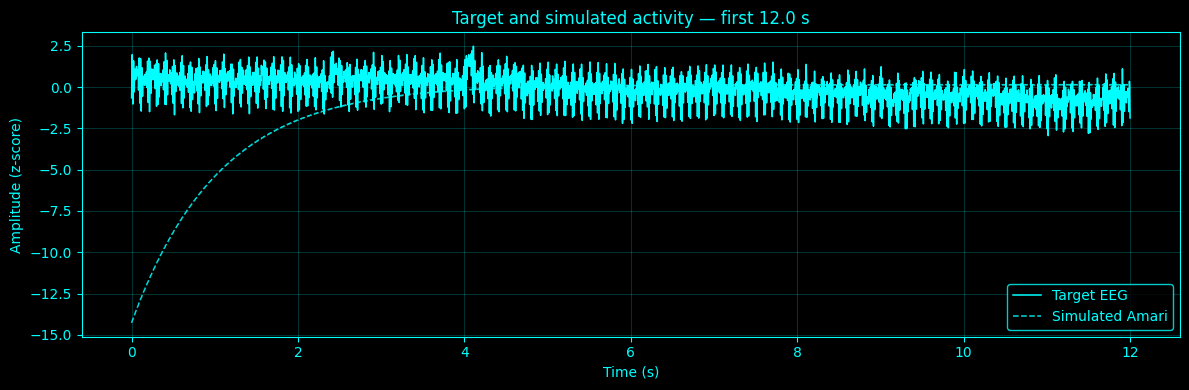

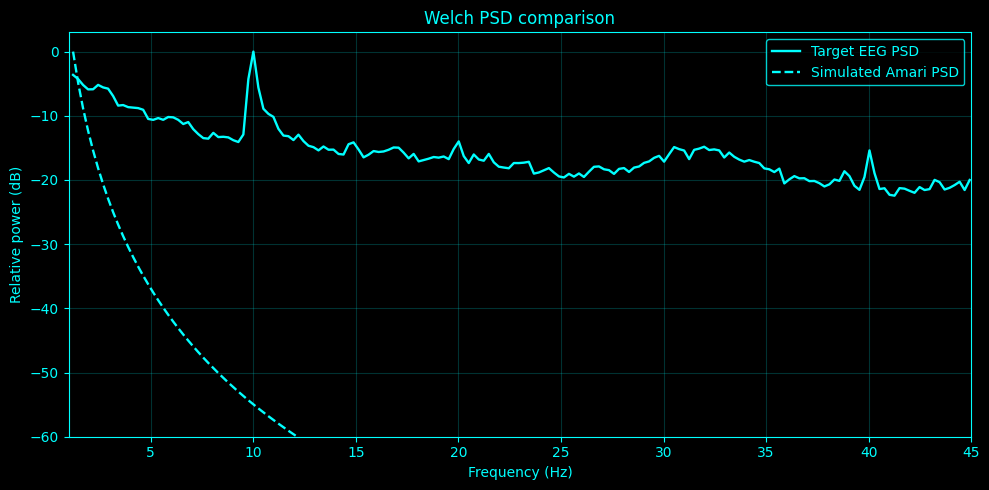

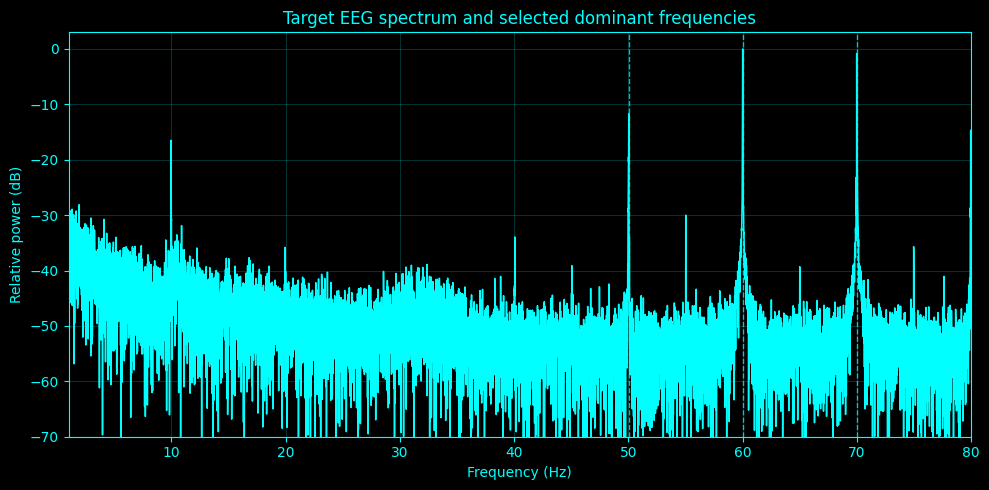

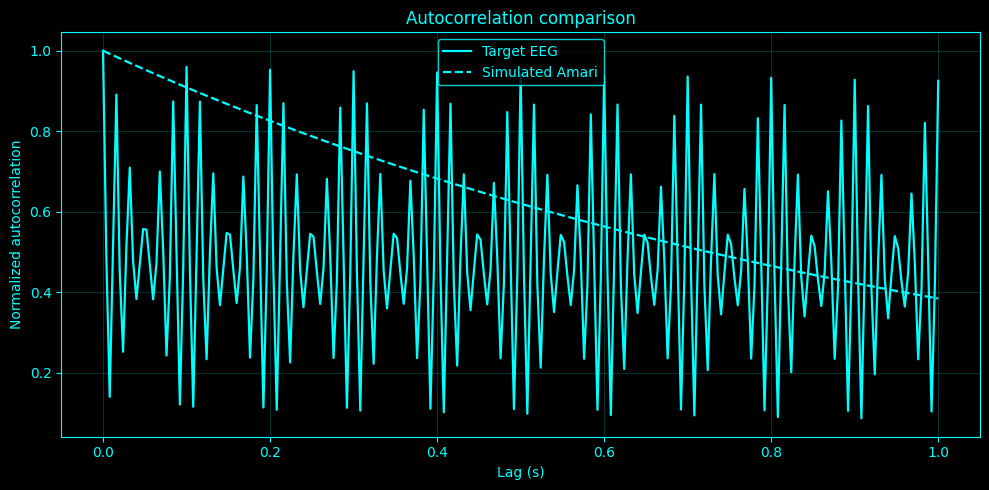

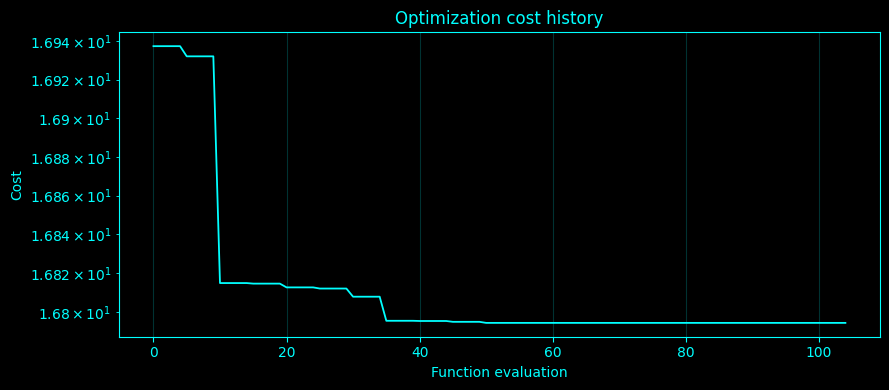

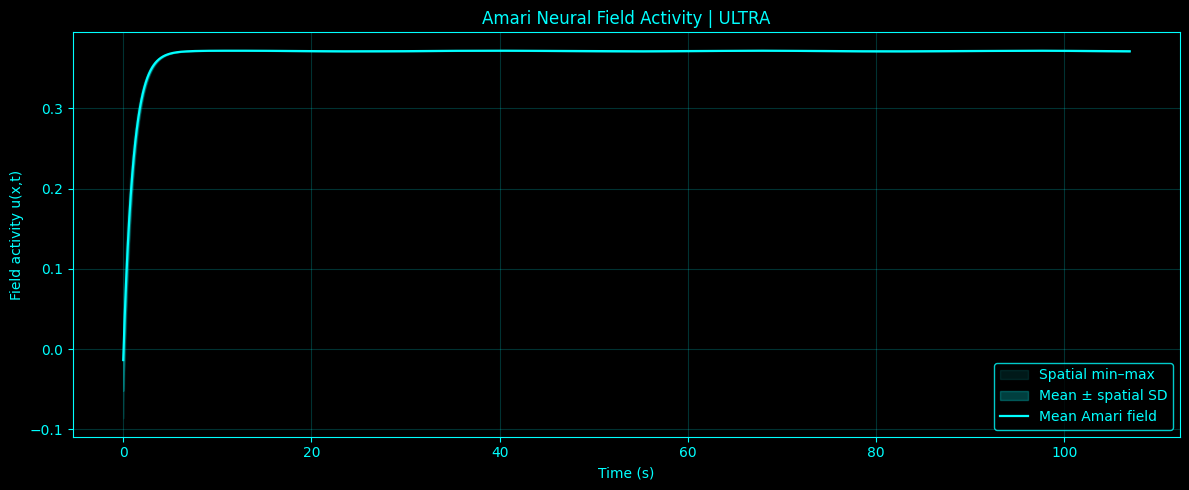


Amari field spatial variation:
Mean spatial SD: 3.57842554e-04
Maximum spatial SD: 3.82689588e-02

AMARI EEG MODEL FIT COMPLETE
Speed mode: ULTRA
Model dt: 0.004
Model sampling frequency: 250.000 Hz
Nx: 32
Maximum optimizer iterations: 20
Optimization duration: 15.0 s
Optimization time: 6.162 s
Final cost: 16.79437272
Optimization success: True

Saved results to: /home/a/projects/Complete-Neural-Signal-Analysis/amari_model_fit
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/amari_model_fit/amari_fit_results.npz
Saved CSV: /home/a/projects/Complete-Neural-Signal-Analysis/amari_model_fit/amari_fit_summary.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/amari_model_fit/amari_fit_summary.txt
Done.


In [7]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import minimize
from scipy.signal import welch

# =======================================================
# SPEED MODE
# =======================================================
# Options:
#   full     = highest fidelity
#   balanced = routine analysis
#   fast     = accelerated analysis
#   ultra    = fastest exploratory analysis
FAST_OPTION = "ultra"

if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError(
        "FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'."
    )

SPEED = {
    "full": {
        "Nx": 64,
        "dt": 0.002,
        "max_opt_iter": 80,
        "coh_nperseg": 2048,
        "max_pairs": None,
        "top_n_freqs": 5,
        "fit_duration": None,
        "psd_nperseg": 4096,
        "acf_max_lag_sec": 2.0,
    },
    "balanced": {
        "Nx": 56,
        "dt": 0.0025,
        "max_opt_iter": 48,
        "coh_nperseg": 1536,
        "max_pairs": 320,
        "top_n_freqs": 5,
        "fit_duration": 60.0,
        "psd_nperseg": 4096,
        "acf_max_lag_sec": 2.0,
    },
    "fast": {
        "Nx": 48,
        "dt": 0.003,
        "max_opt_iter": 30,
        "coh_nperseg": 1024,
        "max_pairs": 160,
        "top_n_freqs": 4,
        "fit_duration": 30.0,
        "psd_nperseg": 2048,
        "acf_max_lag_sec": 1.5,
    },
    "ultra": {
        "Nx": 32,
        "dt": 0.004,
        "max_opt_iter": 20,
        "coh_nperseg": 768,
        "max_pairs": 80,
        "top_n_freqs": 3,
        "fit_duration": 15.0,
        "psd_nperseg": 1024,
        "acf_max_lag_sec": 1.0,
    },
}[FAST_OPTION]

Nx = SPEED["Nx"]
dt_model = SPEED["dt"]
max_opt_iter = SPEED["max_opt_iter"]
coh_nperseg = SPEED["coh_nperseg"]
max_pairs_for_connectivity = SPEED["max_pairs"]
top_n_freqs = SPEED["top_n_freqs"]
fit_duration_sec = SPEED["fit_duration"]
psd_nperseg = SPEED["psd_nperseg"]
acf_max_lag_sec = SPEED["acf_max_lag_sec"]

print("=" * 68)
print("AMARI EEG MODEL FIT")
print(f"Speed mode: {FAST_OPTION.upper()}")
print(f"Nx: {Nx}")
print(f"Model dt: {dt_model}")
print(f"Maximum optimizer iterations: {max_opt_iter}")
print(
    "Optimization duration: "
    + ("FULL SEGMENT" if fit_duration_sec is None else f"{fit_duration_sec:.1f} s")
)
print("=" * 68)

# =======================================================
# FILE DISCOVERY
# =======================================================
_project_roots = [
    os.environ.get("NEURAL_SIGNAL_PROJECT_DIR"),
    "/home/a/projects/Complete-Neural-Signal-Analysis",
    "/home/a/projects/Explore-Neural-Signals1",
    os.getcwd(),
]

_project_roots = [
    os.path.abspath(os.path.expanduser(p))
    for p in _project_roots
    if p
]

_project_roots = list(dict.fromkeys(_project_roots))

_eeg_candidates = [
    os.path.join(root, "eeg_data_with_channels.npy")
    for root in _project_roots
]

eeg_path = next(
    (p for p in _eeg_candidates if os.path.isfile(p)),
    None
)

if eeg_path is None:
    raise FileNotFoundError(
        "Could not find eeg_data_with_channels.npy. Checked:\n  - "
        + "\n  - ".join(_eeg_candidates)
        + "\nSet NEURAL_SIGNAL_PROJECT_DIR if the data live elsewhere."
    )

base_dir = os.path.dirname(eeg_path)

_plv_candidates = []

for _root in _project_roots:
    _plv_candidates.extend([
        os.path.join(_root, "Analysis", "Phase_Syncronization", "plv_matrix.npy"),
        os.path.join(_root, "Analysis", "Phase_Synchronization", "plv_matrix.npy"),
        os.path.join(_root, "Phase_Syncronization", "plv_matrix.npy"),
        os.path.join(_root, "Phase_Synchronization", "plv_matrix.npy"),
        os.path.join(_root, "plv_matrix.npy"),
    ])

plv_matrix_path = next(
    (p for p in _plv_candidates if os.path.isfile(p)),
    None
)

if plv_matrix_path is None:
    _recursive_plv = []

    for _root in _project_roots:
        if not os.path.isdir(_root):
            continue

        for _dirpath, _dirnames, _filenames in os.walk(_root):
            if "plv_matrix.npy" in _filenames:
                _recursive_plv.append(
                    os.path.join(_dirpath, "plv_matrix.npy")
                )

    if _recursive_plv:
        _recursive_plv.sort(
            key=os.path.getmtime,
            reverse=True
        )
        plv_matrix_path = _recursive_plv[0]

out_dir = os.path.join(
    base_dir,
    "amari_model_fit"
)

plots_dir = os.path.join(
    out_dir,
    "plots"
)

os.makedirs(
    out_dir,
    exist_ok=True
)

os.makedirs(
    plots_dir,
    exist_ok=True
)

print("Using EEG file:", eeg_path)

if plv_matrix_path is not None:
    print("Using PLV matrix:", plv_matrix_path)
else:
    print(
        "PLV matrix not found; PLV-dependent diagnostics will be skipped."
    )

# =======================================================
# EEG CONFIGURATION
# =======================================================
eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8",
    "FC5", "FC1", "FC2", "FC6", "M1", "T7", "C3", "Cz",
    "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

sampling_rate = 1000

start_time = 814.571
end_time = 921.515

start_index = int(
    start_time * sampling_rate
)

end_index = int(
    end_time * sampling_rate
)

target_mode = "mean"
target_channel = "C3"

freq_min = 1.0
freq_max = 80.0
min_peak_spacing_hz = 2.0

compute_connectivity_diagnostics = True

coh_band = (
    1.0,
    45.0
)

dx = 0.1
random_seed = 42

acf_weight = 0.30
psd_weight = 0.70

initial_params = np.array(
    [
        1.0,
        0.20,
        2.0,
        0.0,
    ],
    dtype=float
)

param_bounds = [
    (0.01, 5.0),
    (0.01, 3.0),
    (0.2, 10.0),
    (-3.0, 3.0),
]

# =======================================================
# BLACK / CYAN STYLE
# =======================================================
ACCENT = "cyan"
BG = "black"

CYAN_MAP = LinearSegmentedColormap.from_list(
    "black_cyan",
    [
        "#000000",
        "#00181c",
        "#003841",
        "#00727f",
        "#00b8c7",
        "#00ffff",
    ]
)

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax, grid=True):
    ax.set_facecolor(BG)

    if grid:
        ax.grid(
            True,
            alpha=0.20,
            color=ACCENT
        )

    ax.tick_params(
        colors=ACCENT
    )

    for spine in ax.spines.values():
        spine.set_color(
            ACCENT
        )

def style_legend(legend):
    if legend is None:
        return

    legend.get_frame().set_facecolor(
        BG
    )

    legend.get_frame().set_edgecolor(
        ACCENT
    )

    for text in legend.get_texts():
        text.set_color(
            ACCENT
        )

rng = np.random.default_rng(
    random_seed
)

# =======================================================
# SIGNAL HELPERS
# =======================================================
def standardize_1d(x):
    x = np.asarray(
        x,
        dtype=float
    )

    return (
        x - np.mean(x)
    ) / (
        np.std(x)
        + 1e-12
    )

def preprocess_eeg(x):
    x = np.asarray(
        x,
        dtype=float
    )

    x = np.nan_to_num(
        x,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return standardize_1d(
        x
    )

def resample_1d_linear(
    x,
    old_fs,
    new_dt
):
    x = np.asarray(
        x,
        dtype=float
    )

    t_old = np.arange(
        len(x)
    ) / old_fs

    t_new = np.arange(
        0.0,
        t_old[-1] + 1e-12,
        new_dt
    )

    y = np.interp(
        t_new,
        t_old,
        x
    )

    return (
        t_new,
        y
    )

def downsample_for_plot(
    x,
    y,
    max_points=6000
):
    n = min(
        len(x),
        len(y)
    )

    if n <= max_points:
        return (
            x[:n],
            y[:n]
        )

    stride = int(
        np.ceil(
            n / max_points
        )
    )

    return (
        x[:n:stride],
        y[:n:stride]
    )

# =======================================================
# SPECTRAL HELPERS
# =======================================================
def compute_rfft_spectrum(
    x,
    fs
):
    x = np.asarray(
        x,
        dtype=float
    )

    x = x - np.mean(
        x
    )

    X = np.fft.rfft(
        x
    )

    freqs = np.fft.rfftfreq(
        len(x),
        d=1.0 / fs
    )

    power = np.abs(
        X
    ) ** 2

    return (
        freqs,
        X,
        power
    )

def identify_dominant_frequencies(
    x,
    fs,
    top_n=5,
    fmin=1.0,
    fmax=80.0,
    min_spacing_hz=2.0
):
    freqs, _, power = compute_rfft_spectrum(
        x,
        fs
    )

    mask = (
        (freqs >= fmin)
        & (freqs <= fmax)
    )

    freqs_sel = freqs[
        mask
    ]

    power_sel = power[
        mask
    ]

    if len(freqs_sel) < 3:
        return (
            np.array([]),
            freqs,
            power
        )

    peak_idx = []

    for i in range(
        1,
        len(power_sel) - 1
    ):
        if (
            power_sel[i] > power_sel[i - 1]
            and power_sel[i] >= power_sel[i + 1]
        ):
            peak_idx.append(
                i
            )

    if len(peak_idx) == 0:
        peak_idx = np.argsort(
            power_sel
        )[::-1][
            :top_n
        ].tolist()

    peak_idx = np.asarray(
        peak_idx,
        dtype=int
    )

    order = np.argsort(
        power_sel[
            peak_idx
        ]
    )[::-1]

    chosen_freqs = []

    for oi in order:
        idx = peak_idx[
            oi
        ]

        f = freqs_sel[
            idx
        ]

        if all(
            abs(f - ff) >= min_spacing_hz
            for ff in chosen_freqs
        ):
            chosen_freqs.append(
                f
            )

        if len(chosen_freqs) >= top_n:
            break

    return (
        np.asarray(
            chosen_freqs,
            dtype=float
        ),
        freqs,
        power
    )

def estimate_k_sigma(
    dominant_freqs,
    v=1.0
):
    dominant_freqs = np.asarray(
        dominant_freqs,
        dtype=float
    )

    k_values = (
        2.0
        * np.pi
        * dominant_freqs
        / max(v, 1e-12)
    )

    sigma_values = np.exp(
        -0.1
        * k_values
    )

    return (
        k_values,
        sigma_values
    )

def welch_normalized_psd(
    x,
    fs,
    fmin=1.0,
    fmax=45.0,
    nperseg=1024
):
    x = np.asarray(
        x,
        dtype=float
    )

    if len(x) < 8:
        return (
            np.array([]),
            np.array([])
        )

    nseg = min(
        int(nperseg),
        len(x)
    )

    if nseg < 8:
        nseg = len(x)

    noverlap = nseg // 2

    freqs, power = welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density"
    )

    mask = (
        (freqs >= fmin)
        & (freqs <= fmax)
    )

    freqs = freqs[
        mask
    ]

    power = power[
        mask
    ]

    power = power / (
        np.sum(power)
        + 1e-15
    )

    return (
        freqs,
        power
    )

def psd_to_relative_db(
    power
):
    power = np.asarray(
        power,
        dtype=float
    )

    if power.size == 0:
        return power

    peak = np.max(
        power
    )

    return (
        10.0
        * np.log10(
            (
                power
                + 1e-15
            ) / (
                peak
                + 1e-15
            )
        )
    )

# =======================================================
# AUTOCORRELATION
# =======================================================
def autocorrelation_signature(
    x,
    fs,
    max_lag_sec
):
    x = preprocess_eeg(
        x
    )

    n = len(
        x
    )

    if n < 4:
        return np.ones(
            1,
            dtype=float
        )

    max_lag = min(
        int(
            max_lag_sec
            * fs
        ),
        n - 1
    )

    nfft = 1 << int(
        np.ceil(
            np.log2(
                2 * n - 1
            )
        )
    )

    X = np.fft.rfft(
        x,
        n=nfft
    )

    acf = np.fft.irfft(
        X * np.conj(X),
        n=nfft
    )[
        :max_lag + 1
    ]

    acf = acf / (
        acf[0]
        + 1e-12
    )

    return acf

# =======================================================
# PLV / COHERENCE
# =======================================================
def calculate_propagation_delays(
    plv_matrix,
    frequency
):
    plv_matrix = np.asarray(
        plv_matrix,
        dtype=float
    )

    plv_matrix = np.clip(
        plv_matrix,
        -1.0,
        1.0
    )

    phase_differences = np.arccos(
        plv_matrix
    )

    delays = phase_differences / (
        2.0
        * np.pi
        * max(
            frequency,
            1e-12
        )
    )

    return float(
        np.nanmean(
            delays
        )
    )

def manual_coherence(
    x,
    y,
    fs,
    nperseg=2048
):
    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    n = min(
        len(x),
        len(y)
    )

    x = x[
        :n
    ]

    y = y[
        :n
    ]

    if n < nperseg:
        nperseg = n

    if nperseg < 16:
        freqs = np.fft.rfftfreq(
            max(n, 2),
            d=1.0 / fs
        )

        return (
            freqs,
            np.zeros_like(
                freqs
            )
        )

    step = max(
        1,
        nperseg // 2
    )

    window = np.hanning(
        nperseg
    )

    wnorm = np.sum(
        window ** 2
    )

    Pxx = None
    Pyy = None
    Pxy = None
    count = 0

    for start in range(
        0,
        n - nperseg + 1,
        step
    ):
        xs = x[
            start:start + nperseg
        ]

        ys = y[
            start:start + nperseg
        ]

        xs = (
            xs
            - np.mean(xs)
        ) * window

        ys = (
            ys
            - np.mean(ys)
        ) * window

        X = np.fft.rfft(
            xs
        )

        Y = np.fft.rfft(
            ys
        )

        Sxx = (
            np.abs(X) ** 2
        ) / wnorm

        Syy = (
            np.abs(Y) ** 2
        ) / wnorm

        Sxy = (
            X
            * np.conj(Y)
        ) / wnorm

        if Pxx is None:
            Pxx = Sxx
            Pyy = Syy
            Pxy = Sxy
        else:
            Pxx += Sxx
            Pyy += Syy
            Pxy += Sxy

        count += 1

    if count == 0:
        freqs = np.fft.rfftfreq(
            nperseg,
            d=1.0 / fs
        )

        return (
            freqs,
            np.zeros(
                len(freqs),
                dtype=float
            )
        )

    Pxx /= count
    Pyy /= count
    Pxy /= count

    coherence = (
        np.abs(Pxy) ** 2
    ) / (
        Pxx
        * Pyy
        + 1e-12
    )

    freqs = np.fft.rfftfreq(
        nperseg,
        d=1.0 / fs
    )

    return (
        freqs,
        coherence.real
    )

def calculate_mean_coherence(
    EEG_data,
    sampling_rate,
    nperseg=2048,
    band=(1.0, 45.0),
    max_pairs=None,
    rng=None
):
    EEG_data = np.asarray(
        EEG_data,
        dtype=float
    )

    _, n_channels = EEG_data.shape

    pairs = [
        (i, j)
        for i in range(n_channels)
        for j in range(i + 1, n_channels)
    ]

    if (
        max_pairs is not None
        and len(pairs) > max_pairs
    ):
        if rng is None:
            rng = np.random.default_rng(
                42
            )

        selected = rng.choice(
            len(pairs),
            size=max_pairs,
            replace=False
        )

        pairs = [
            pairs[k]
            for k in selected
        ]

    coherence_values = []

    for i, j in pairs:
        freqs, coherence = manual_coherence(
            EEG_data[:, i],
            EEG_data[:, j],
            fs=sampling_rate,
            nperseg=nperseg
        )

        mask = (
            (freqs >= band[0])
            & (freqs <= band[1])
        )

        if np.any(
            mask
        ):
            coherence_values.append(
                np.mean(
                    coherence[
                        mask
                    ]
                )
            )

    if not coherence_values:
        return 0.0

    return float(
        np.mean(
            coherence_values
        )
    )

# =======================================================
# AMARI MODEL
# =======================================================
def phi_kernel_periodic(
    Nx,
    dx,
    r
):
    L = Nx * dx

    x = np.arange(
        Nx
    ) * dx

    dist = np.minimum(
        x,
        L - x
    )

    kernel = np.exp(
        -r
        * dist ** 2
    )

    kernel = kernel / (
        np.sum(kernel)
        * dx
        + 1e-12
    )

    return kernel

def F(
    u,
    beta=1.0,
    theta=0.0
):
    z = np.clip(
        beta
        * (
            u
            - theta
        ),
        -50.0,
        50.0
    )

    return (
        1.0
        / (
            1.0
            + np.exp(
                -z
            )
        )
    )

def build_external_drive(
    t,
    dominant_freqs,
    sigma_values
):
    t = np.asarray(
        t,
        dtype=float
    )

    drive = np.zeros_like(
        t
    )

    for frequency, amplitude in zip(
        dominant_freqs,
        sigma_values
    ):
        drive += (
            amplitude
            * np.sin(
                2.0
                * np.pi
                * frequency
                * t
            )
        )

    return drive

def amari_simulate(
    params,
    t,
    Nx,
    dx,
    dominant_freqs,
    sigma_values,
    u0
):
    epsilon, r, beta, theta = [
        float(v)
        for v in params
    ]

    u = np.asarray(
        u0,
        dtype=float
    ).copy()

    kernel = phi_kernel_periodic(
        Nx,
        dx,
        r
    )

    K_fft = np.fft.fft(
        kernel
    )

    drive_t = build_external_drive(
        t,
        dominant_freqs,
        sigma_values
    )

    states = np.zeros(
        (
            len(t),
            Nx
        ),
        dtype=float
    )

    states[0] = u

    dt = float(
        t[1]
        - t[0]
    )

    for n in range(
        1,
        len(t)
    ):
        firing = F(
            u,
            beta=beta,
            theta=theta
        )

        convolution = (
            np.fft.ifft(
                np.fft.fft(
                    firing
                )
                * K_fft
            ).real
            * dx
        )

        du = (
            -u
            + convolution
            + epsilon
            * drive_t[n]
        )

        u = (
            u
            + dt
            * du
        )

        states[n] = u

    return states

# =======================================================
# LOAD EEG
# =======================================================
EEG_data = np.load(
    eeg_path,
    allow_pickle=True
)

EEG_data = np.asarray(
    EEG_data,
    dtype=float
)

if EEG_data.ndim != 2:
    raise ValueError(
        f"Expected 2-D EEG array, got shape {EEG_data.shape}"
    )

if EEG_data.shape[1] == len(eeg_channel_names):
    filtered_EEG_data = EEG_data[
        start_index:end_index,
        :
    ]

elif EEG_data.shape[0] == len(eeg_channel_names):
    filtered_EEG_data = EEG_data[
        :,
        start_index:end_index
    ].T

else:
    raise ValueError(
        f"Unexpected EEG shape: {EEG_data.shape}"
    )

# =======================================================
# TARGET SIGNAL
# =======================================================
if target_mode == "mean":
    target_signal_raw = np.mean(
        filtered_EEG_data,
        axis=1
    )

    target_label = (
        "mean_across_channels"
    )

elif target_mode == "channel":
    if target_channel not in eeg_channel_names:
        raise ValueError(
            f"Unknown target channel: {target_channel}"
        )

    channel_index = eeg_channel_names.index(
        target_channel
    )

    target_signal_raw = filtered_EEG_data[
        :,
        channel_index
    ]

    target_label = target_channel

else:
    raise ValueError(
        "target_mode must be 'mean' or 'channel'"
    )

target_signal = preprocess_eeg(
    target_signal_raw
)

t_model, target_model = resample_1d_linear(
    target_signal,
    sampling_rate,
    dt_model
)

target_model = preprocess_eeg(
    target_model
)

model_fs = (
    1.0
    / dt_model
)

# =======================================================
# OPTIMIZATION WINDOW
# =======================================================
if fit_duration_sec is None:
    fit_count = len(
        target_model
    )
else:
    fit_count = min(
        len(target_model),
        int(
            fit_duration_sec
            / dt_model
        )
    )

t_fit = t_model[
    :fit_count
]

target_fit = target_model[
    :fit_count
]

t_fit = (
    t_fit
    - t_fit[0]
)

print()
print("Target:", target_label)
print(f"Full target duration: {t_model[-1]:.2f} s")
print(f"Optimization duration: {t_fit[-1]:.2f} s")
print(f"Model sampling frequency: {model_fs:.2f} Hz")

# =======================================================
# DOMINANT FREQUENCIES
# =======================================================
dominant_freqs, full_freqs, full_power = identify_dominant_frequencies(
    target_model,
    fs=model_fs,
    top_n=top_n_freqs,
    fmin=freq_min,
    fmax=freq_max,
    min_spacing_hz=min_peak_spacing_hz
)

k_values, sigma_values = estimate_k_sigma(
    dominant_freqs,
    v=1.0
)

if len(sigma_values) > 0:
    sigma_values = sigma_values / (
        np.max(
            np.abs(
                sigma_values
            )
        )
        + 1e-12
    )

print("Dominant frequencies (Hz):", dominant_freqs)
print("k values:", k_values)
print("sigma values:", sigma_values)

# =======================================================
# CONNECTIVITY DIAGNOSTICS
# =======================================================
mean_delay_from_plv = np.nan
spatial_decay_est = np.nan
mean_coherence_est = np.nan
synaptic_strength_est = np.nan

if (
    plv_matrix_path is not None
    and os.path.isfile(
        plv_matrix_path
    )
):
    plv_matrix = np.load(
        plv_matrix_path
    )

    if len(dominant_freqs) > 0:
        mean_delay_from_plv = calculate_propagation_delays(
            plv_matrix,
            float(
                np.median(
                    dominant_freqs
                )
            )
        )

    print(
        "Mean propagation delay from PLV:",
        mean_delay_from_plv
    )

if compute_connectivity_diagnostics:
    t0_diag = time.perf_counter()

    mean_coherence_est = calculate_mean_coherence(
        filtered_EEG_data,
        sampling_rate=sampling_rate,
        nperseg=coh_nperseg,
        band=coh_band,
        max_pairs=max_pairs_for_connectivity,
        rng=rng
    )

    if mean_coherence_est > 0:
        spatial_decay_est = (
            1.0
            / mean_coherence_est
        )
    else:
        spatial_decay_est = np.inf

    synaptic_strength_est = mean_coherence_est

    print(
        "Spatial decay estimate:",
        spatial_decay_est
    )

    print(
        "Mean coherence estimate:",
        mean_coherence_est
    )

    print(
        "Synaptic strength estimate:",
        synaptic_strength_est
    )

    print(
        "Connectivity diagnostics time (s):",
        time.perf_counter()
        - t0_diag
    )

# =======================================================
# FIXED INITIAL FIELD
# =======================================================
u0_fixed = (
    0.05
    * rng.standard_normal(
        Nx
    )
)

# =======================================================
# TARGET FEATURES FOR OPTIMIZATION
# =======================================================
target_freqs_fit, target_psd_fit = welch_normalized_psd(
    target_fit,
    fs=model_fs,
    fmin=1.0,
    fmax=45.0,
    nperseg=psd_nperseg
)

target_acf = autocorrelation_signature(
    target_fit,
    fs=model_fs,
    max_lag_sec=acf_max_lag_sec
)

target_log_psd = np.log10(
    target_psd_fit
    + 1e-12
)

cost_history = []

# =======================================================
# COST FUNCTION
# =======================================================
def cost_function(
    params
):
    sim_states = amari_simulate(
        params,
        t_fit,
        Nx,
        dx,
        dominant_freqs,
        sigma_values,
        u0_fixed
    )

    sim_signal = preprocess_eeg(
        np.mean(
            sim_states,
            axis=1
        )
    )

    sim_freqs, sim_psd = welch_normalized_psd(
        sim_signal,
        fs=model_fs,
        fmin=1.0,
        fmax=45.0,
        nperseg=psd_nperseg
    )

    if (
        len(sim_psd) == 0
        or len(target_psd_fit) == 0
    ):
        return 1e12

    sim_psd_interp = np.interp(
        target_freqs_fit,
        sim_freqs,
        sim_psd,
        left=0.0,
        right=0.0
    )

    sim_log_psd = np.log10(
        sim_psd_interp
        + 1e-12
    )

    mse_psd = np.mean(
        (
            sim_log_psd
            - target_log_psd
        ) ** 2
    )

    sim_acf = autocorrelation_signature(
        sim_signal,
        fs=model_fs,
        max_lag_sec=acf_max_lag_sec
    )

    nacf = min(
        len(sim_acf),
        len(target_acf)
    )

    mse_acf = np.mean(
        (
            sim_acf[:nacf]
            - target_acf[:nacf]
        ) ** 2
    )

    total_cost = (
        psd_weight
        * mse_psd
        + acf_weight
        * mse_acf
    )

    if not np.isfinite(
        total_cost
    ):
        total_cost = 1e12

    cost_history.append(
        float(
            total_cost
        )
    )

    return float(
        total_cost
    )

# =======================================================
# OPTIMIZATION
# =======================================================
t0_opt = time.perf_counter()

result = minimize(
    cost_function,
    initial_params,
    method="L-BFGS-B",
    bounds=param_bounds,
    options={
        "maxiter": max_opt_iter,
        "disp": True,
        "ftol": 1e-7,
    }
)

opt_time = (
    time.perf_counter()
    - t0_opt
)

opt_params = result.x

print()
print("Optimized Parameters:", opt_params)
print("Optimization success:", result.success)
print("Optimization message:", result.message)
print("Final cost:", result.fun)
print("Optimization time (s):", opt_time)

# =======================================================
# FINAL FULL-DURATION SIMULATION
# =======================================================
sim_states_opt = amari_simulate(
    opt_params,
    t_model,
    Nx,
    dx,
    dominant_freqs,
    sigma_values,
    u0_fixed
)

sim_signal_opt = preprocess_eeg(
    np.mean(
        sim_states_opt,
        axis=1
    )
)

# =======================================================
# FINAL PSDs
# =======================================================
target_freqs_psd, target_psd = welch_normalized_psd(
    target_model,
    fs=model_fs,
    fmin=1.0,
    fmax=45.0,
    nperseg=psd_nperseg
)

sim_freqs_psd, sim_psd = welch_normalized_psd(
    sim_signal_opt,
    fs=model_fs,
    fmin=1.0,
    fmax=45.0,
    nperseg=psd_nperseg
)

target_psd_db = psd_to_relative_db(
    target_psd
)

sim_psd_db = psd_to_relative_db(
    sim_psd
)

# =======================================================
# FINAL AUTOCORRELATIONS
# =======================================================
target_acf_final = autocorrelation_signature(
    target_model,
    fs=model_fs,
    max_lag_sec=acf_max_lag_sec
)

sim_acf_final = autocorrelation_signature(
    sim_signal_opt,
    fs=model_fs,
    max_lag_sec=acf_max_lag_sec
)

acf_len = min(
    len(target_acf_final),
    len(sim_acf_final)
)

acf_lags = np.arange(
    acf_len
) / model_fs

# =======================================================
# SAVE RESULTS
# =======================================================
npz_path = os.path.join(
    out_dir,
    "amari_fit_results.npz"
)

np.savez(
    npz_path,
    speed_mode=FAST_OPTION,
    target_label=target_label,
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
    model_fs=model_fs,
    dt_model=dt_model,
    Nx=Nx,
    dx=dx,
    fit_duration_sec=fit_duration_sec if fit_duration_sec is not None else -1.0,
    t_model=t_model,
    target_model=target_model,
    sim_signal_opt=sim_signal_opt,
    sim_states_opt=sim_states_opt,
    dominant_freqs=dominant_freqs,
    k_values=k_values,
    sigma_values=sigma_values,
    opt_params=opt_params,
    final_cost=result.fun,
    cost_history=np.asarray(
        cost_history,
        dtype=float
    ),
    mean_delay_from_plv=mean_delay_from_plv,
    spatial_decay_est=spatial_decay_est,
    mean_coherence_est=mean_coherence_est,
    synaptic_strength_est=synaptic_strength_est
)

summary_csv = os.path.join(
    out_dir,
    "amari_fit_summary.csv"
)

summary_df = pd.DataFrame([
    {
        "speed_mode": FAST_OPTION,
        "target_label": target_label,
        "start_time": start_time,
        "end_time": end_time,
        "model_dt": dt_model,
        "model_fs": model_fs,
        "Nx": Nx,
        "fit_duration_sec": (
            fit_duration_sec
            if fit_duration_sec is not None
            else t_model[-1]
        ),
        "max_opt_iter": max_opt_iter,
        "epsilon": opt_params[0],
        "r": opt_params[1],
        "beta": opt_params[2],
        "theta": opt_params[3],
        "final_cost": float(
            result.fun
        ),
        "success": bool(
            result.success
        ),
        "optimization_time_sec": opt_time,
        "mean_delay_from_plv": mean_delay_from_plv,
        "spatial_decay_est": spatial_decay_est,
        "mean_coherence_est": mean_coherence_est,
        "synaptic_strength_est": synaptic_strength_est,
        "dominant_freqs_hz": ",".join(
            f"{f:.4f}"
            for f in dominant_freqs
        ),
    }
])

summary_df.to_csv(
    summary_csv,
    index=False
)

summary_txt = os.path.join(
    out_dir,
    "amari_fit_summary.txt"
)

with open(
    summary_txt,
    "w"
) as f:
    f.write("Amari model fit to EEG-derived spectral target\n")
    f.write("=============================================\n\n")
    f.write(f"Speed mode: {FAST_OPTION.upper()}\n")
    f.write(f"Target: {target_label}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Original EEG sampling rate: {sampling_rate} Hz\n")
    f.write(f"Model sampling rate: {model_fs:.6f} Hz\n")
    f.write(f"Model dt: {dt_model}\n")
    f.write(f"Nx: {Nx}\n")
    f.write(f"dx: {dx}\n")
    f.write(
        "Optimization duration: "
        + (
            f"{fit_duration_sec:.4f} s\n"
            if fit_duration_sec is not None
            else "full segment\n"
        )
    )
    f.write(f"Maximum optimizer iterations: {max_opt_iter}\n\n")
    f.write(f"Dominant frequencies (Hz): {dominant_freqs.tolist()}\n")
    f.write(f"k values: {k_values.tolist()}\n")
    f.write(f"sigma values: {sigma_values.tolist()}\n\n")
    f.write("Optimized parameters:\n")
    f.write(f"  epsilon = {opt_params[0]:.6f}\n")
    f.write(f"  r       = {opt_params[1]:.6f}\n")
    f.write(f"  beta    = {opt_params[2]:.6f}\n")
    f.write(f"  theta   = {opt_params[3]:.6f}\n\n")
    f.write(f"Final cost: {float(result.fun):.8f}\n")
    f.write(f"Success: {bool(result.success)}\n")
    f.write(f"Optimization time (s): {opt_time:.4f}\n\n")
    f.write(f"Mean propagation delay from PLV: {mean_delay_from_plv}\n")
    f.write(f"Spatial decay estimate: {spatial_decay_est}\n")
    f.write(f"Mean coherence estimate: {mean_coherence_est}\n")
    f.write(f"Synaptic strength estimate: {synaptic_strength_est}\n")

# =======================================================
# PLOT 1 — TARGET VS SIMULATED SIGNAL
# =======================================================
display_duration = min(
    12.0,
    t_model[-1]
)

display_mask = (
    t_model <= display_duration
)

t_display = t_model[
    display_mask
]

target_display = target_model[
    display_mask
]

sim_display = sim_signal_opt[
    display_mask
]

t_target_plot, target_plot = downsample_for_plot(
    t_display,
    target_display
)

t_sim_plot, sim_plot = downsample_for_plot(
    t_display,
    sim_display
)

fig, ax = plt.subplots(
    figsize=(12, 4),
    facecolor=BG
)

style_ax(
    ax
)

ax.plot(
    t_target_plot,
    target_plot,
    color=ACCENT,
    linewidth=1.1,
    label="Target EEG"
)

ax.plot(
    t_sim_plot,
    sim_plot,
    color=ACCENT,
    linestyle="--",
    linewidth=1.1,
    alpha=0.85,
    label="Simulated Amari"
)

ax.set_title(
    f"Target and simulated activity — first {display_duration:.1f} s"
)

ax.set_xlabel(
    "Time (s)"
)

ax.set_ylabel(
    "Amplitude (z-score)"
)

style_legend(
    ax.legend()
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        plots_dir,
        "target_vs_simulated_time_series.png"
    ),
    dpi=160,
    bbox_inches="tight"
)

plt.show()
plt.close()

# =======================================================
# PLOT 2 — PSD COMPARISON
# =======================================================
fig, ax = plt.subplots(
    figsize=(10, 5),
    facecolor=BG
)

style_ax(
    ax
)

ax.plot(
    target_freqs_psd,
    target_psd_db,
    color=ACCENT,
    linewidth=1.7,
    label="Target EEG PSD"
)

ax.plot(
    sim_freqs_psd,
    sim_psd_db,
    color=ACCENT,
    linestyle="--",
    linewidth=1.7,
    label="Simulated Amari PSD"
)

for f0 in dominant_freqs:
    ax.axvline(
        f0,
        color=ACCENT,
        linestyle=":",
        linewidth=0.9,
        alpha=0.45
    )

ax.set_title(
    "Welch PSD comparison"
)

ax.set_xlabel(
    "Frequency (Hz)"
)

ax.set_ylabel(
    "Relative power (dB)"
)

ax.set_xlim(
    1,
    45
)

ax.set_ylim(
    -60,
    3
)

style_legend(
    ax.legend()
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        plots_dir,
        "psd_comparison.png"
    ),
    dpi=160,
    bbox_inches="tight"
)

plt.show()
plt.close()

# =======================================================
# PLOT 3 — TARGET SPECTRUM + DOMINANT FREQUENCIES
# =======================================================
spectrum_mask = (
    (full_freqs >= 1.0)
    & (full_freqs <= freq_max)
)

target_spectrum = full_power[
    spectrum_mask
]

target_spectrum_db = psd_to_relative_db(
    target_spectrum
)

fig, ax = plt.subplots(
    figsize=(10, 5),
    facecolor=BG
)

style_ax(
    ax
)

ax.plot(
    full_freqs[
        spectrum_mask
    ],
    target_spectrum_db,
    color=ACCENT,
    linewidth=1.1
)

for f0 in dominant_freqs:
    ax.axvline(
        f0,
        color=ACCENT,
        linestyle="--",
        linewidth=1.0,
        alpha=0.75
    )

ax.set_title(
    "Target EEG spectrum and selected dominant frequencies"
)

ax.set_xlabel(
    "Frequency (Hz)"
)

ax.set_ylabel(
    "Relative power (dB)"
)

ax.set_xlim(
    1,
    freq_max
)

ax.set_ylim(
    -70,
    3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        plots_dir,
        "dominant_frequencies.png"
    ),
    dpi=160,
    bbox_inches="tight"
)

plt.show()
plt.close()

# =======================================================
# PLOT 4 — AUTOCORRELATION COMPARISON
# =======================================================
fig, ax = plt.subplots(
    figsize=(10, 5),
    facecolor=BG
)

style_ax(
    ax
)

ax.plot(
    acf_lags,
    target_acf_final[
        :acf_len
    ],
    color=ACCENT,
    linewidth=1.6,
    label="Target EEG"
)

ax.plot(
    acf_lags,
    sim_acf_final[
        :acf_len
    ],
    color=ACCENT,
    linestyle="--",
    linewidth=1.6,
    label="Simulated Amari"
)

ax.set_title(
    "Autocorrelation comparison"
)

ax.set_xlabel(
    "Lag (s)"
)

ax.set_ylabel(
    "Normalized autocorrelation"
)

style_legend(
    ax.legend()
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        plots_dir,
        "autocorrelation_comparison.png"
    ),
    dpi=160,
    bbox_inches="tight"
)

plt.show()
plt.close()

# =======================================================
# PLOT 5 — OPTIMIZATION COST
# =======================================================
fig, ax = plt.subplots(
    figsize=(9, 4),
    facecolor=BG
)

style_ax(
    ax
)

cost_array = np.asarray(
    cost_history,
    dtype=float
)

cost_array = np.maximum(
    cost_array,
    1e-12
)

ax.semilogy(
    np.arange(
        len(cost_array)
    ),
    cost_array,
    color=ACCENT,
    linewidth=1.3
)

ax.set_title(
    "Optimization cost history"
)

ax.set_xlabel(
    "Function evaluation"
)

ax.set_ylabel(
    "Cost"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        plots_dir,
        "cost_history.png"
    ),
    dpi=160,
    bbox_inches="tight"
)

plt.show()
plt.close()

# =======================================================
# PLOT 6 — AMARI FIELD ACTIVITY WITH SPATIAL ENVELOPE
# =======================================================
# The present Amari model is driven approximately uniformly across
# space, so a space-time heatmap can look misleading or stripe-like.
#
# Instead, plot:
#   - spatial mean field activity
#   - min/max spatial envelope
#   - ±1 spatial standard deviation
#
# This preserves the actual Amari dynamics while showing whether
# meaningful spatial variation exists.

field = np.asarray(sim_states_opt, dtype=float)

if field.ndim != 2:
    raise ValueError(
        f"Expected sim_states_opt to be 2-D, got shape {field.shape}"
    )

field = np.nan_to_num(
    field,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

field_mean = np.mean(field, axis=1)
field_std = np.std(field, axis=1)
field_min = np.min(field, axis=1)
field_max = np.max(field, axis=1)

# Reduce plotting density only.
max_plot_points = 6000

plot_stride = max(
    1,
    int(np.ceil(len(t_model) / max_plot_points))
)

t_plot = t_model[::plot_stride]
mean_plot = field_mean[::plot_stride]
std_plot = field_std[::plot_stride]
min_plot = field_min[::plot_stride]
max_plot = field_max[::plot_stride]

fig, ax = plt.subplots(
    figsize=(12, 5),
    facecolor=BG
)

style_ax(ax)

# Full spatial range.
ax.fill_between(
    t_plot,
    min_plot,
    max_plot,
    color=ACCENT,
    alpha=0.10,
    label="Spatial min–max"
)

# ±1 spatial standard deviation.
ax.fill_between(
    t_plot,
    mean_plot - std_plot,
    mean_plot + std_plot,
    color=ACCENT,
    alpha=0.25,
    label="Mean ± spatial SD"
)

# Mean Amari field.
ax.plot(
    t_plot,
    mean_plot,
    color=ACCENT,
    linewidth=1.6,
    label="Mean Amari field"
)

ax.set_title(
    f"Amari Neural Field Activity | {FAST_OPTION.upper()}"
)

ax.set_xlabel(
    "Time (s)"
)

ax.set_ylabel(
    "Field activity u(x,t)"
)

legend = ax.legend(
    facecolor=BG,
    edgecolor=ACCENT
)

for text in legend.get_texts():
    text.set_color(ACCENT)

plt.tight_layout()

plt.savefig(
    os.path.join(
        plots_dir,
        "amari_field_activity.png"
    ),
    dpi=180,
    bbox_inches="tight"
)

plt.show()
plt.close()

# Useful numerical interpretation.
print()
print("Amari field spatial variation:")
print(f"Mean spatial SD: {np.mean(field_std):.8e}")
print(f"Maximum spatial SD: {np.max(field_std):.8e}")

# =======================================================
# COMPLETION SUMMARY
# =======================================================
print()
print("=" * 68)
print("AMARI EEG MODEL FIT COMPLETE")
print("=" * 68)
print(f"Speed mode: {FAST_OPTION.upper()}")
print(f"Model dt: {dt_model}")
print(f"Model sampling frequency: {model_fs:.3f} Hz")
print(f"Nx: {Nx}")
print(f"Maximum optimizer iterations: {max_opt_iter}")
print(
    "Optimization duration: "
    + (
        f"{fit_duration_sec:.1f} s"
        if fit_duration_sec is not None
        else "full segment"
    )
)
print(f"Optimization time: {opt_time:.3f} s")
print(f"Final cost: {float(result.fun):.8f}")
print(f"Optimization success: {bool(result.success)}")
print()
print(f"Saved results to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved CSV: {summary_csv}")
print(f"Saved TXT: {summary_txt}")
print("Done.")

### Neural-field characteristic spectra and dispersion relations

The following cells study complex characteristic roots of delayed neural-field equations. These are growth-rate spectra, not Fourier power spectra: for a mode proportional to $e^{\sigma t+i2\pi kx}$, $\operatorname{Re}\sigma$ controls exponential growth/decay and $\operatorname{Im}\sigma$ controls oscillation. Several cells use model-specific or explicitly illustrative characteristic relations, and the accompanying theory notes state when a relation is not a general Amari formula.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A neural-field model treats activity as a continuous field rather than as individual neurons. Linearizing the model around a reference state leads to characteristic equations whose roots describe whether small perturbations grow, decay, or oscillate. A dispersion relation shows how these growth rates depend on spatial wave number. When delays appear exponentially in the characteristic equation, the Lambert W function can provide analytic or semi-analytic branches of solutions. Different branches correspond to different possible modes, so branch tracking and numerical continuity matter.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


### Spectrum Analysis and Response Surface Visualization for the Amari Neural Field Equation

ref: https://centaur.reading.ac.uk/15743/2/PHYSD-D-09-00436.pdf for eqs and figs etc

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A neural-field model treats activity as a continuous field rather than as individual neurons. Linearizing the model around a reference state leads to characteristic equations whose roots describe whether small perturbations grow, decay, or oscillate. A dispersion relation shows how these growth rates depend on spatial wave number. When delays appear exponentially in the characteristic equation, the Lambert W function can provide analytic or semi-analytic branches of solutions. Different branches correspond to different possible modes, so branch tracking and numerical continuity matter.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Lambert-W branch continuation for a neural-field characteristic spectrum</h3><p>Linearization of delayed neural-field models often yields transcendental characteristic equations because the growth rate $\sigma$ appears both algebraically and in delay factors such as $e^{-\varepsilon\sigma}$. Lambert's $W$ function solves equations of the form $We^W=z$ and has infinitely many complex branches.</p><p>This cell follows several branches using the code-defined kernel transform $\widetilde H(k,\sigma)$ and the fixed-point update below. The real part of $\sigma$ is the modal growth/decay rate and the imaginary part is the oscillation frequency. Because the exact $\widetilde H$ here is model-specific, these curves should be interpreted for that implemented characteristic relation only.</p><p><b>Cell role.</b> The EEG loading in this cell does not change the characteristic equation unless its derived quantities enter the chosen model parameters.</p></div>

$$\sigma_{n+1}(k)=\frac{1}{\varepsilon}W_b\!\left(\varepsilon e^\varepsilon\,\widetilde H(k,\sigma_n)\right)-1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A neural-field model treats activity as a continuous field rather than as individual neurons. Linearizing the model around a reference state leads to characteristic equations whose roots describe whether small perturbations grow, decay, or oscillate. A dispersion relation shows how these growth rates depend on spatial wave number. When delays appear exponentially in the characteristic equation, the Lambert W function can provide analytic or semi-analytic branches of solutions. Different branches correspond to different possible modes, so branch tracking and numerical continuity matter.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


Using EEG file: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy


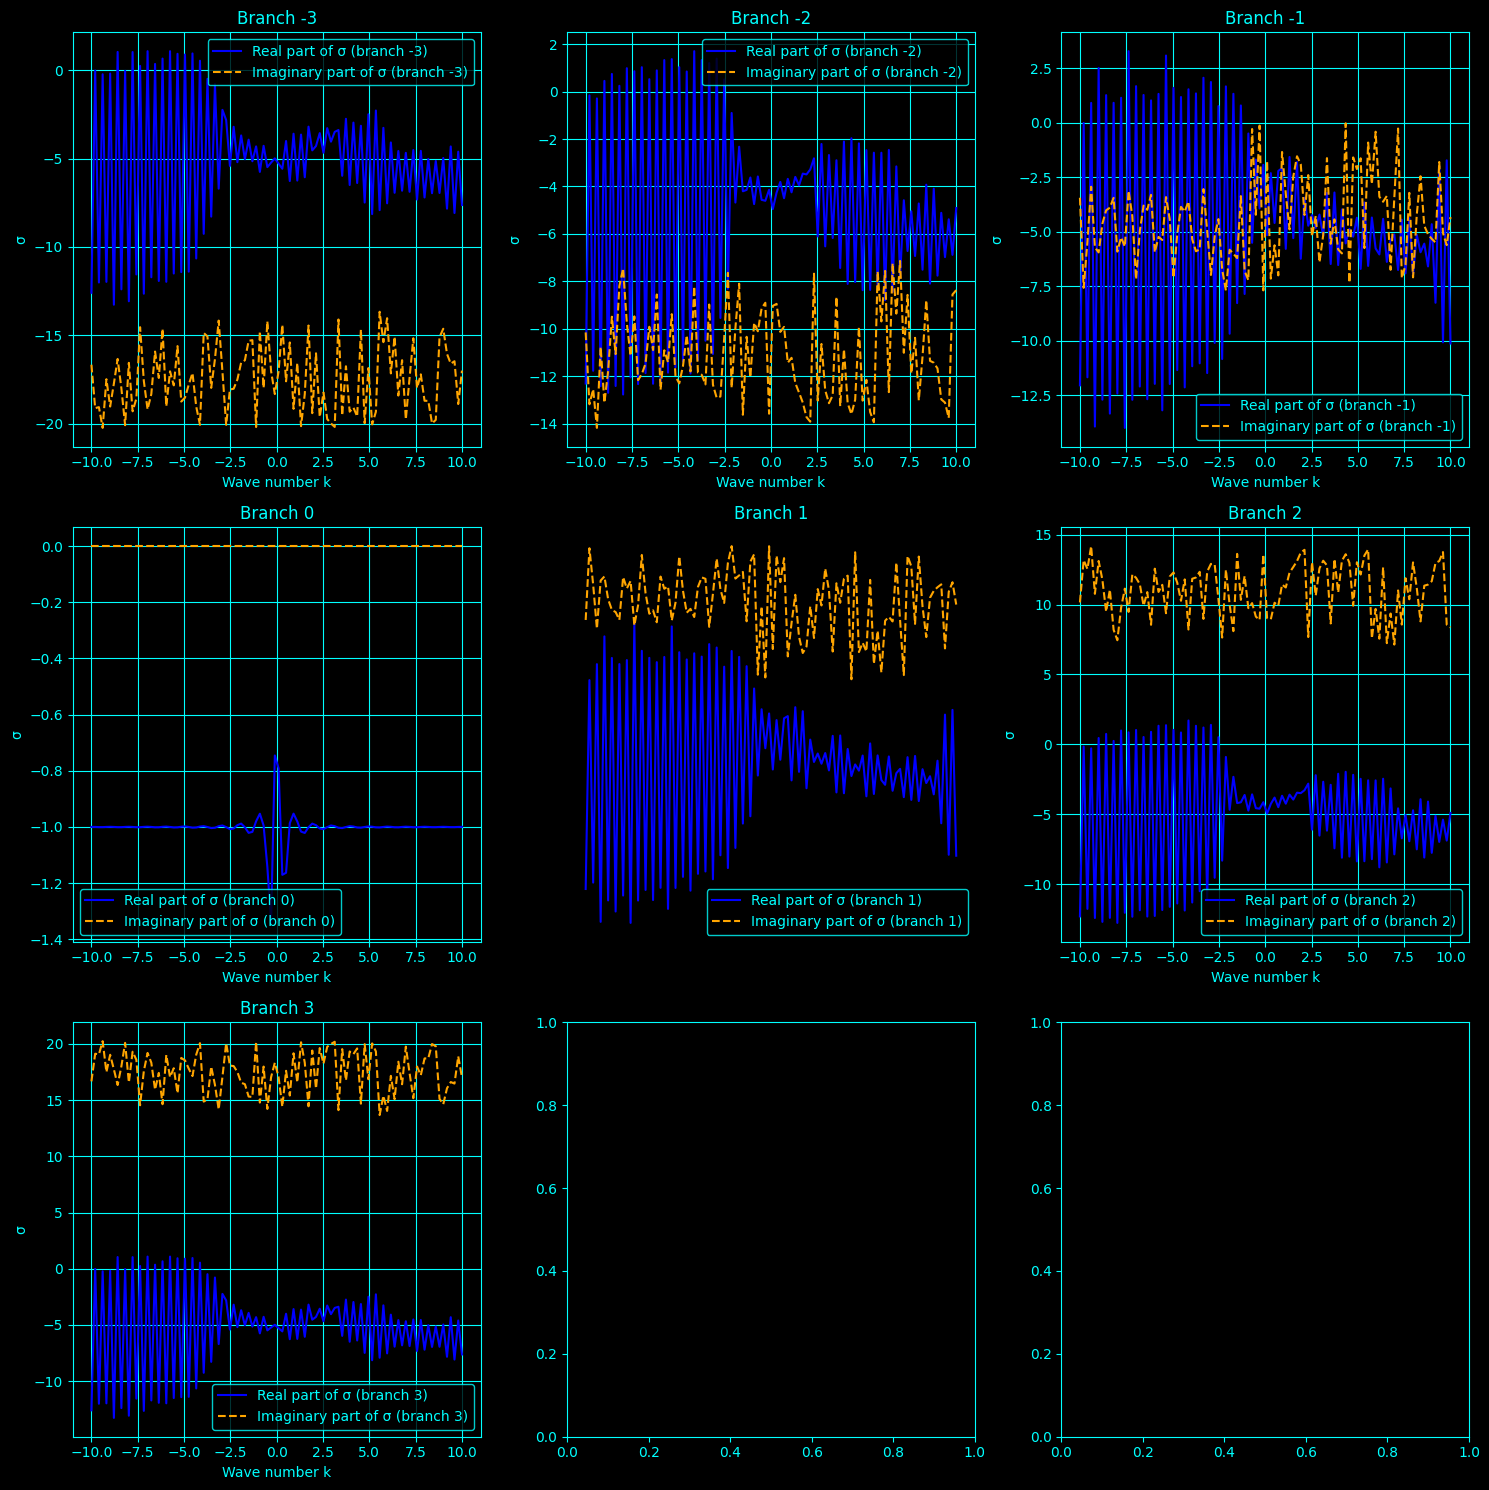

In [8]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

# Define directories
_project_roots = [
    os.environ.get("NEURAL_SIGNAL_PROJECT_DIR"),
    "/home/a/projects/Complete-Neural-Signal-Analysis",
    "/home/a/projects/Explore-Neural-Signals1",
    os.getcwd(),
]
_project_roots = [
    os.path.abspath(os.path.expanduser(p))
    for p in _project_roots
    if p
]
_project_roots = list(dict.fromkeys(_project_roots))

_eeg_candidates = [
    os.path.join(root, "eeg_data_with_channels.npy")
    for root in _project_roots
]
EEG_data_path = next((p for p in _eeg_candidates if os.path.isfile(p)), None)
if EEG_data_path is None:
    raise FileNotFoundError(
        "Could not find eeg_data_with_channels.npy. Checked:\n  - "
        + "\n  - ".join(_eeg_candidates)
        + "\nSet NEURAL_SIGNAL_PROJECT_DIR if the data live elsewhere."
    )

base_dir = os.path.dirname(EEG_data_path)
EEG_data = np.load(EEG_data_path, allow_pickle=True)
print("Using EEG file:", EEG_data_path)

sampling_rate = 1000  # Hz (adjust if necessary)
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

# EEG channel names
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7',
    'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Define parameters (example values, please replace with your actual parameters)
epsilon = 1  # Delay factor (1/v where v is the velocity of propagation)
r = 2        # Parameter from the kernel function φ(x,r)

# Define a range of wave numbers k to analyze
k_values = np.linspace(-10, 10, _speed_count(400, 100))  # Replace with the appropriate range for your analysis

# Function to compute the Fourier transform of the kernel function, H(k, σ)
def H_tilde(k, sigma):
    Q1 = 4 * (np.pi * k) ** 2 - r ** 2 + epsilon ** 2 * sigma ** 2
    Q2 = 4 * (np.pi * k) ** 2 + r ** 2 - epsilon ** 2 * sigma ** 2
    return np.exp(-epsilon * sigma) * np.exp(-r * r) * (
        epsilon * sigma * np.exp(epsilon * sigma) * Q1 + r * np.exp(r) * (
            Q2 * np.cos(2 * np.pi * k) + 4 * epsilon * np.pi * k * sigma * np.sin(2 * np.pi * k)
        )
    ) / ((4 * (np.pi * k) ** 2 + r ** 2) ** 2 + 2 * epsilon ** 2 * (4 * (np.pi * k) ** 2 - r ** 2) * sigma ** 2 + epsilon ** 4 * sigma ** 4)

# Initialize array to hold the computed σ values for each k
sigma_values = np.zeros((len(k_values), 7), dtype=np.complex128)  # Adjust for the number of branches

# Compute the spectrum σ(k) for each k
for i, k in enumerate(k_values):
    for branch in range(-3, 4):  # Adjust branch range to match figure 2
        # Define the right-hand side of Eq. (20)
        R = H_tilde(k, sigma_values[i-1, branch+3] if i > 0 else 0) * epsilon * np.exp(epsilon)
        
        # Solve for σ using the Lambert W function
        sigma_values[i, branch+3] = lambertw(R, branch) / epsilon - 1

# Plotting the spectrum in subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
branch_indices = [-3, -2, -1, 0, 1, 2, 3]
branch_labels = ['Branch -3', 'Branch -2', 'Branch -1', 'Branch 0', 'Branch 1', 'Branch 2', 'Branch 3']

for idx, branch in enumerate(branch_indices):
    row, col = divmod(idx, 3)
    axs[row, col].plot(k_values, sigma_values[:, branch+3].real, label=f'Real part of σ (branch {branch})', color='blue')
    axs[row, col].plot(k_values, sigma_values[:, branch+3].imag, label=f'Imaginary part of σ (branch {branch})', linestyle='dashed', color='orange')
    axs[row, col].set_title(branch_labels[branch+3])
    axs[row, col].set_xlabel('Wave number k')
    axs[row, col].set_ylabel('σ')
    axs[row, col].grid(True)
    axs[row, col].legend()

# Hide the middle subplot
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Lambert-W initialization and branch continuation</h3><p>For the implemented delayed-kernel characteristic relation, the $k=0$ root can be initialized analytically on each Lambert-$W$ branch. Subsequent $k$ values use the previous branch value as the continuation seed, reducing arbitrary branch jumps.</p><p>Branch continuation is a numerical device for tracing roots continuously; it does not guarantee that every possible characteristic root has been found.</p><p><b>Cell role.</b> The code then updates each branch using its implemented $\widetilde H(k,\sigma)$.</p></div>

$$\sigma_b(0)=\frac1\varepsilon W_b\!\left(\frac{\varepsilon e^\varepsilon(1+e^{-2r})r}{r+\varepsilon}\right)-1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A neural-field model treats activity as a continuous field rather than as individual neurons. Linearizing the model around a reference state leads to characteristic equations whose roots describe whether small perturbations grow, decay, or oscillate. A dispersion relation shows how these growth rates depend on spatial wave number. When delays appear exponentially in the characteristic equation, the Lambert W function can provide analytic or semi-analytic branches of solutions. Different branches correspond to different possible modes, so branch tracking and numerical continuity matter.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


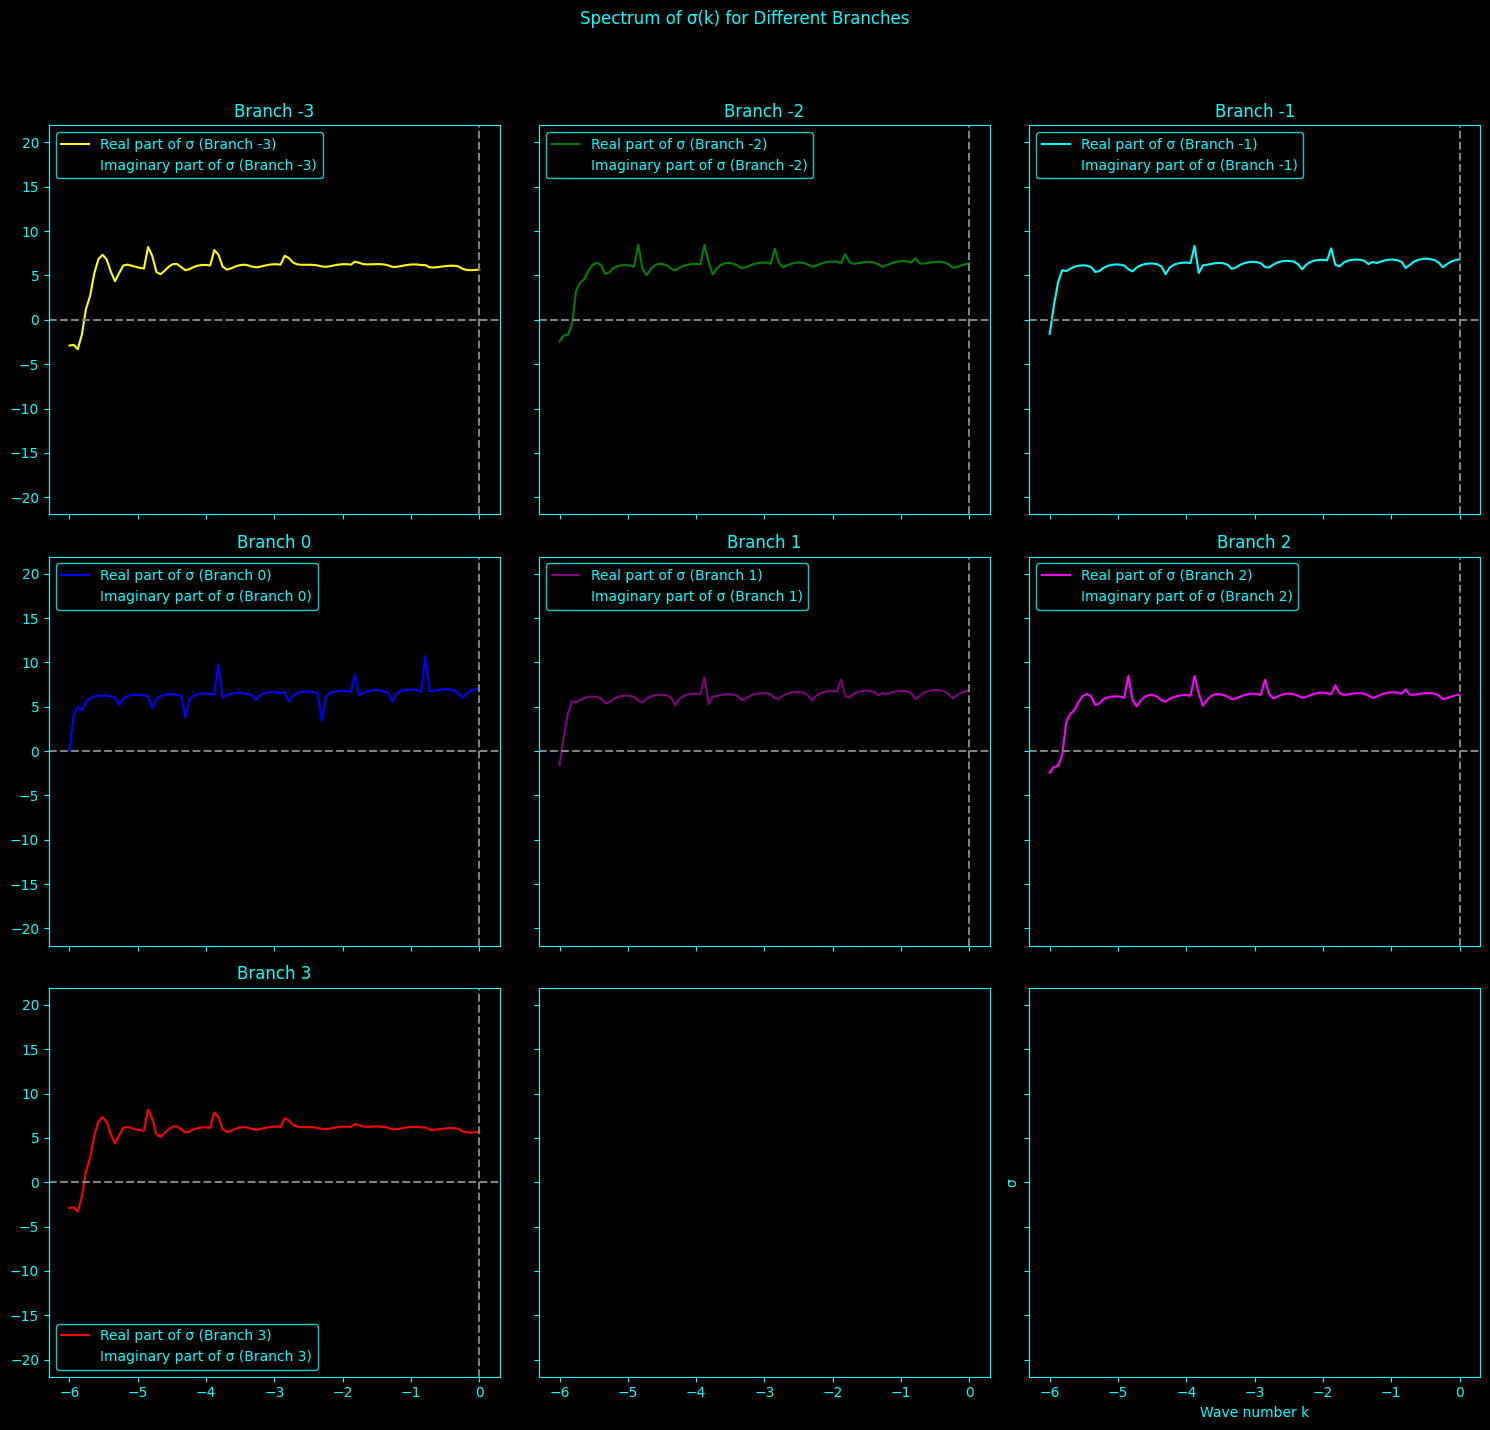

In [9]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Parameters
epsilon = 1
r = 20

# Define range of k values
k_values = np.linspace(-6, 0, _speed_count(400, 100))

# Function to compute the initial sigma when k = 0
def initial_sigma(epsilon, r, branch):
    A = epsilon * np.exp(epsilon) * (1 + np.exp(-2 * r)) * r / (r + epsilon)
    return lambertw(A, branch) / epsilon - 1

# Function to compute H_tilde(k, sigma)
def H_tilde(k, sigma, epsilon, r):
    Q1 = 4 * (np.pi * k) ** 2 - r ** 2 + epsilon ** 2 * sigma ** 2
    Q2 = 4 * (np.pi * k) ** 2 + r ** 2 - epsilon ** 2 * sigma ** 2
    return np.exp(-epsilon * sigma) * (1 + np.exp(-2 * r)) * r * (
        epsilon * sigma * np.exp(epsilon * sigma) * Q1 + np.exp(r) * (
            Q2 * np.cos(2 * np.pi * k) + 4 * epsilon * np.pi * k * sigma * np.sin(2 * np.pi * k)
        )
    ) / ((4 * (np.pi * k) ** 2 + r ** 2) ** 2 + 2 * epsilon ** 2 * (4 * (np.pi * k) ** 2 - r ** 2) * sigma ** 2 + epsilon ** 4 * sigma ** 4)

# Initialize array to hold the computed sigma values
num_branches = 7
sigma_values = np.zeros((len(k_values), num_branches), dtype=np.complex128)

# Compute the spectrum sigma(k) for each branch
for branch in range(-num_branches // 2, num_branches // 2 + 1):
    branch_idx = branch + num_branches // 2
    sigma_values[0, branch_idx] = initial_sigma(epsilon, r, branch)
    for i, k in enumerate(k_values[1:], start=1):
        sigma_prev = sigma_values[i-1, branch_idx]
        for _ in range(10):
            H_val = H_tilde(k, sigma_prev, epsilon, r)
            W_val = lambertw(H_val, branch)
            sigma_new = W_val / epsilon - 1
            if np.abs(sigma_new - sigma_prev) < 1e-6:
                break
            sigma_prev = sigma_new
        sigma_values[i, branch_idx] = sigma_new

# Plotting the results
fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=True, sharey=True)
axes = axes.flatten()

colors = ['yellow', 'green', 'cyan', 'blue', 'purple', 'magenta', 'red']

for branch in range(num_branches):
    ax = axes[branch]
    real_sigma = sigma_values[:, branch].real
    imag_sigma = sigma_values[:, branch].imag
    ax.plot(k_values, real_sigma, label=f'Real part of σ (Branch {branch - num_branches // 2})', color=colors[branch])
    ax.scatter(k_values, imag_sigma, color='black', s=10, label=f'Imaginary part of σ (Branch {branch - num_branches // 2})')
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_title(f'Branch {branch - num_branches // 2}')
    ax.legend()

plt.suptitle('Spectrum of σ(k) for Different Branches')
plt.xlabel('Wave number k')
plt.ylabel('σ')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — multi-branch delayed neural-field spectrum</h3><p>This cell evaluates the same type of Lambert-$W$ characteristic fixed-point relation over a wider wave-number range and across multiple branches. Stability of a linear mode is determined by $\Re\sigma$: negative real part decays and positive real part grows.</p><p>The imaginary part gives angular oscillation rate of the linearized mode; it is not a Fourier power spectrum.</p><p><b>Cell role.</b> The exact root equation is the code-defined characteristic model.</p></div>

$$\Re\sigma(k)<0\Rightarrow\text{linear decay},\qquad \Re\sigma(k)>0\Rightarrow\text{linear growth}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A neural-field model treats activity as a continuous field rather than as individual neurons. Linearizing the model around a reference state leads to characteristic equations whose roots describe whether small perturbations grow, decay, or oscillate. A dispersion relation shows how these growth rates depend on spatial wave number. When delays appear exponentially in the characteristic equation, the Lambert W function can provide analytic or semi-analytic branches of solutions. Different branches correspond to different possible modes, so branch tracking and numerical continuity matter.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


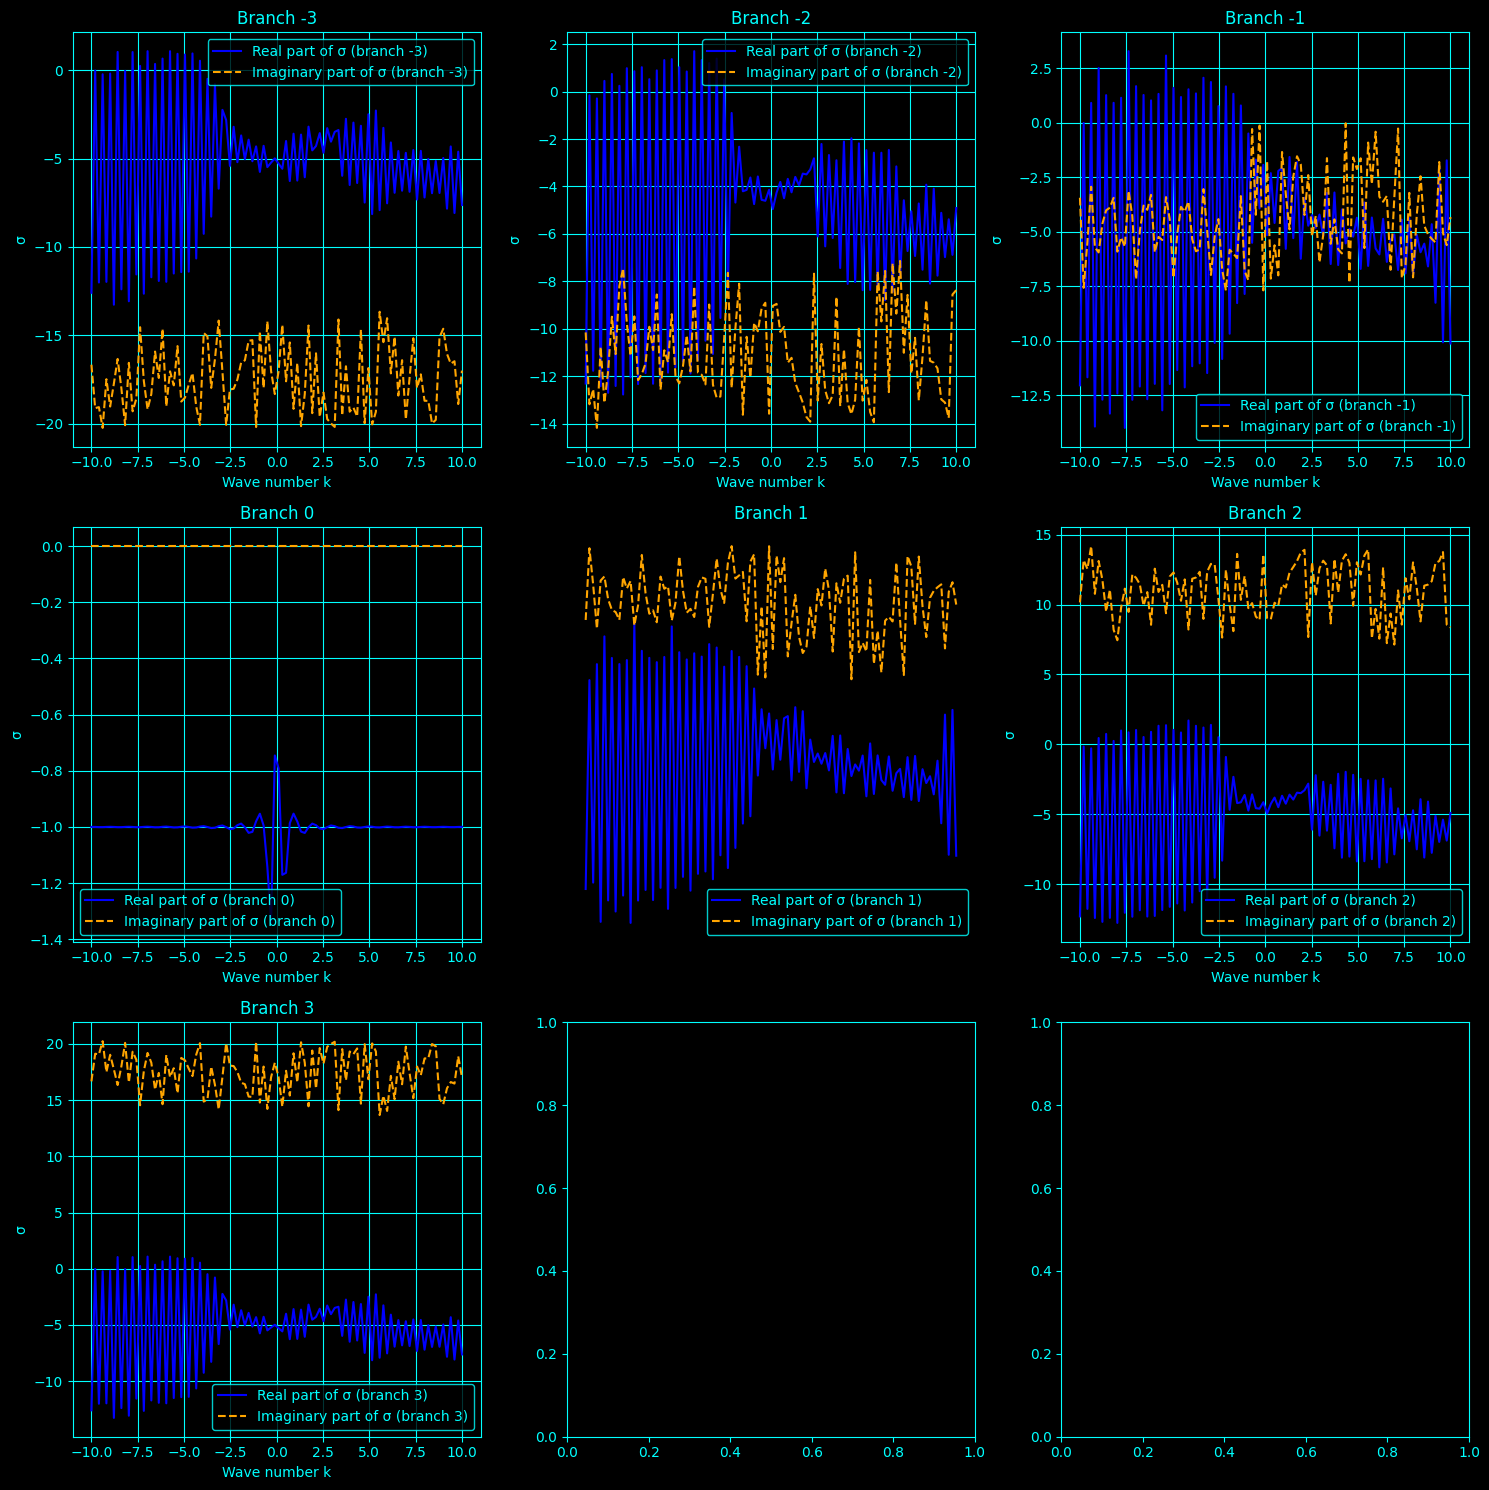

In [10]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Define parameters
epsilon = 1  # Delay factor (1/v where v is the velocity of propagation)
r = 2        # Parameter from the kernel function φ(x,r)
k_values = np.linspace(-10, 10, _speed_count(400, 100))  # Wave number range

# Function to compute the Fourier transform of the kernel function, H(k, σ)
def H_tilde(k, sigma):
    Q1 = 4 * (np.pi * k) ** 2 - r ** 2 + epsilon ** 2 * sigma ** 2
    Q2 = 4 * (np.pi * k) ** 2 + r ** 2 - epsilon ** 2 * sigma ** 2
    return np.exp(-epsilon * sigma) * np.exp(-r * r) * (
        epsilon * sigma * np.exp(epsilon * sigma) * Q1 + r * np.exp(r) * (
            Q2 * np.cos(2 * np.pi * k) + 4 * epsilon * np.pi * k * sigma * np.sin(2 * np.pi * k)
        )
    ) / ((4 * (np.pi * k) ** 2 + r ** 2) ** 2 + 2 * epsilon ** 2 * (4 * (np.pi * k) ** 2 - r ** 2) * sigma ** 2 + epsilon ** 4 * sigma ** 4)

# Initialize array to hold the computed σ values for each k
branches = [-3, -2, -1, 0, 1, 2, 3]  # Consider branches from -3 to 3
sigma_values = {branch: np.zeros(len(k_values), dtype=np.complex128) for branch in branches}

# Compute the spectrum σ(k) for each k
for i, k in enumerate(k_values):
    for branch in branches:
        # Define the right-hand side of Eq. (20)
        R = H_tilde(k, sigma_values[branch][i-1] if i > 0 else 0) * epsilon * np.exp(epsilon)
        
        # Solve for σ using the Lambert W function
        sigma_values[branch][i] = lambertw(R, branch) / epsilon - 1

# Plotting the spectrum in subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
branch_labels = {branch: f'Branch {branch}' for branch in branches}

for idx, branch in enumerate(branches):
    row, col = divmod(idx, 3)
    axs[row, col].plot(k_values, sigma_values[branch].real, label=f'Real part of σ (branch {branch})', color='blue')
    axs[row, col].plot(k_values, sigma_values[branch].imag, label=f'Imaginary part of σ (branch {branch})', linestyle='dashed', color='orange')
    axs[row, col].set_title(branch_labels[branch])
    axs[row, col].set_xlabel('Wave number k')
    axs[row, col].set_ylabel('σ')
    axs[row, col].grid(True)
    axs[row, col].legend()

# Hide the middle subplot
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — simplified delayed-kernel Lambert-W spectrum</h3><p>This cell uses a simplified model-specific kernel factor $\widetilde H=(r-\sigma)/(r+\sigma)e^{-\varepsilon\sigma}$ and iterates a Lambert-$W$ branch update. It is an illustrative characteristic-root model rather than a universal Amari dispersion relation.</p><p>Different Lambert-$W$ branches represent different complex solutions of the transcendental characteristic equation.</p><p><b>Cell role.</b> The plot should be read as the spectrum of this explicit simplified relation only.</p></div>

$$\widetilde H(\sigma)=\frac{r-\sigma}{r+\sigma}e^{-\varepsilon\sigma},\qquad \sigma_{n+1}=\varepsilon^{-1}W_b(\widetilde H(\sigma_n))-1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A neural-field model treats activity as a continuous field rather than as individual neurons. Linearizing the model around a reference state leads to characteristic equations whose roots describe whether small perturbations grow, decay, or oscillate. A dispersion relation shows how these growth rates depend on spatial wave number. When delays appear exponentially in the characteristic equation, the Lambert W function can provide analytic or semi-analytic branches of solutions. Different branches correspond to different possible modes, so branch tracking and numerical continuity matter.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


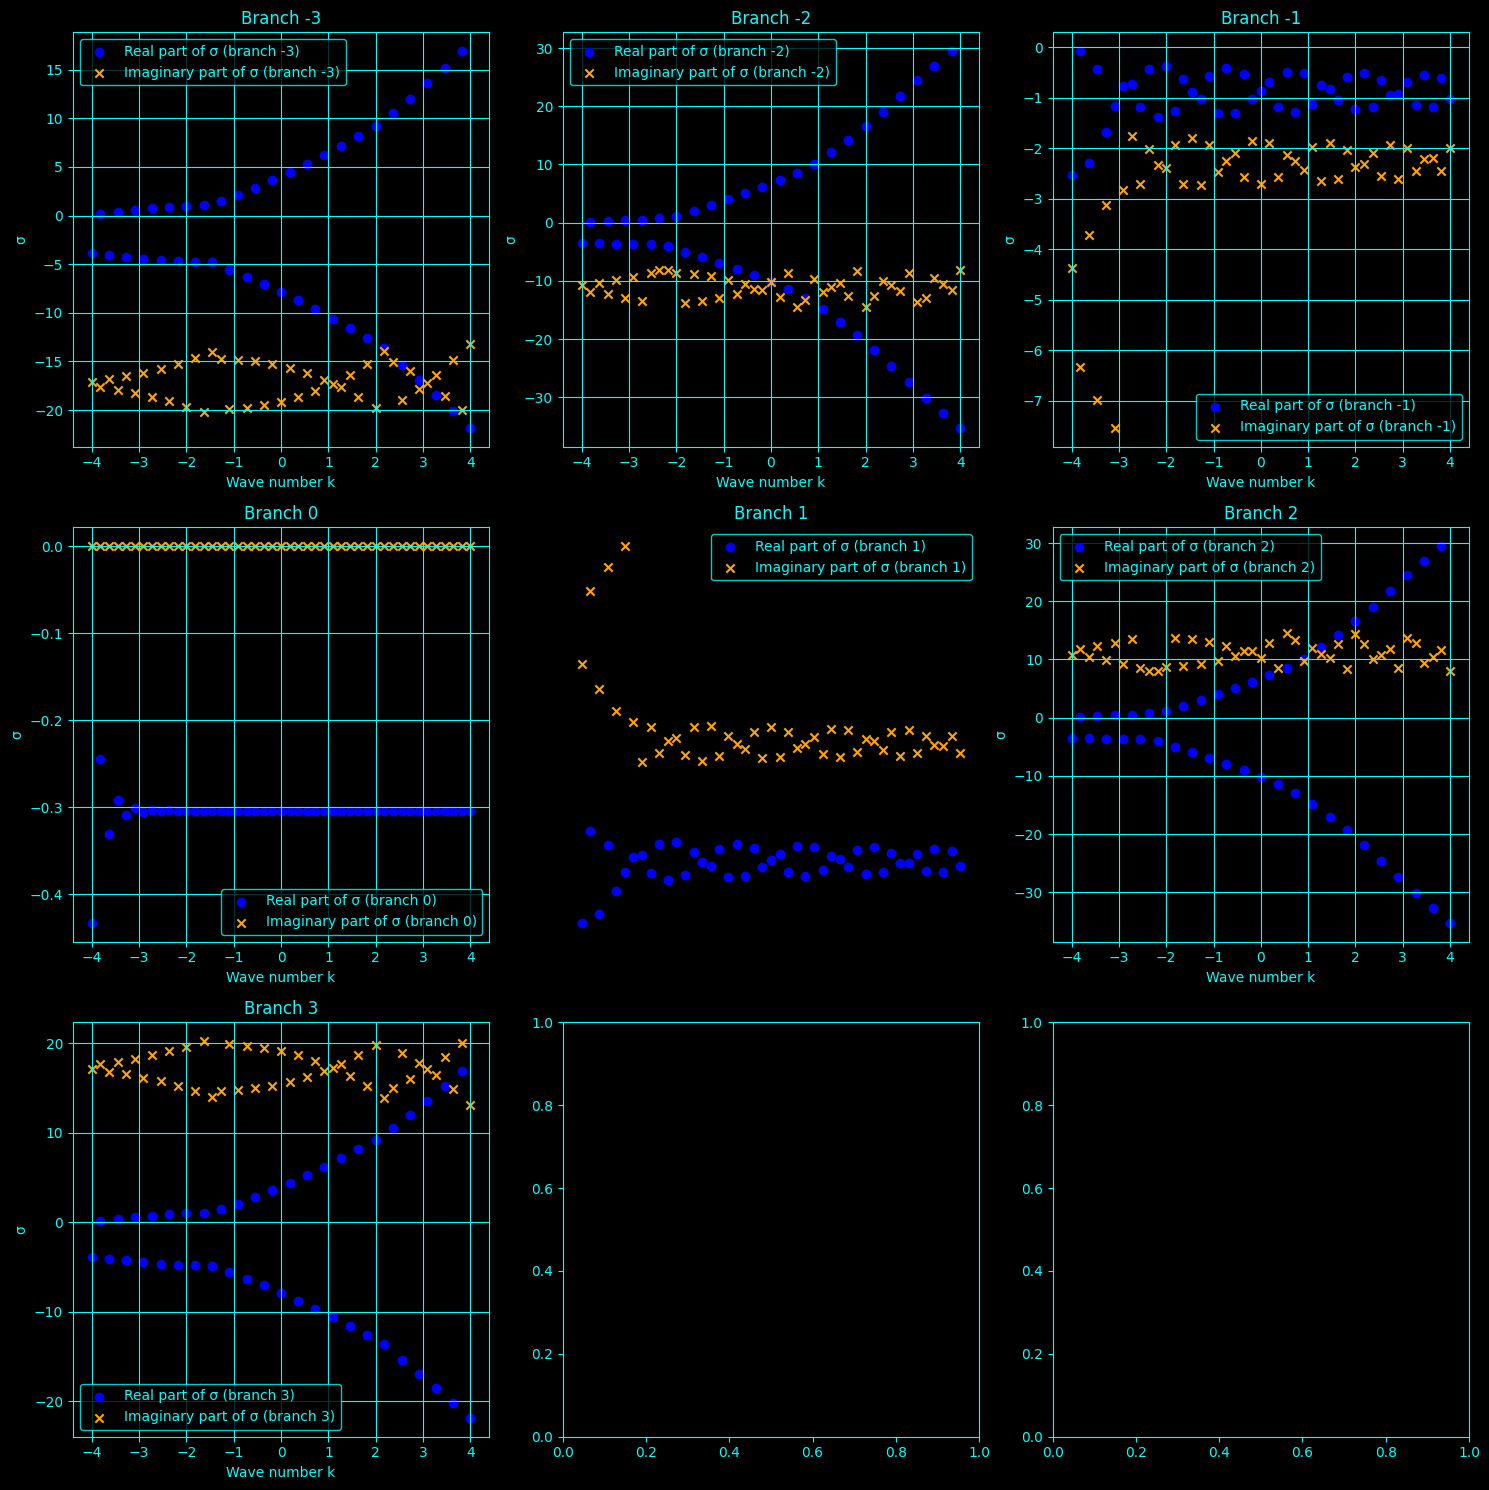

In [11]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Define parameters
epsilon = 1  # Delay factor
r = 20  # Parameter from the kernel function
k_values = np.linspace(-4, 4, _speed_count(100, 45))  # Reduced number of points for clarity

# Function to compute the Fourier transform of the kernel function, H(k, σ)
def H_tilde(k, sigma):
    return (r - sigma) / (r + sigma) * np.exp(-epsilon * sigma)

# Initialize array to hold the computed σ values for each k
branches = [-3, -2, -1, 0, 1, 2, 3]  # Consider branches from -3 to 3
sigma_values = {branch: np.zeros(len(k_values), dtype=np.complex128) for branch in branches}

# Compute the spectrum σ(k) for each k
for i, k in enumerate(k_values):
    for branch in branches:
        R = H_tilde(k, sigma_values[branch][i-1] if i > 0 else 0)
        sigma_values[branch][i] = lambertw(R, branch) / epsilon - 1

# Plotting the spectrum in subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
branch_labels = {branch: f'Branch {branch}' for branch in branches}

for idx, branch in enumerate(branches):
    row, col = divmod(idx, 3)
    axs[row, col].scatter(k_values, sigma_values[branch].real, label=f'Real part of σ (branch {branch})', color='blue')
    axs[row, col].scatter(k_values, sigma_values[branch].imag, label=f'Imaginary part of σ (branch {branch})', color='orange', marker='x')
    axs[row, col].set_title(branch_labels[branch])
    axs[row, col].set_xlabel('Wave number k')
    axs[row, col].set_ylabel('σ')
    axs[row, col].grid(True)
    axs[row, col].legend()

# Hide the middle subplot
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — illustrative wave-number-dependent Lambert-W characteristic branches</h3><p>Here the characteristic factor is explicitly chosen as $r[\cos(2\pi k)-\sin(2\pi k)]e^{-\varepsilon\sigma}$. Applying Lambert-$W$ branch iteration generates a family of complex growth rates.</p><p>This is a model exploration: the chosen factor is not a general theorem for neural fields, and the real/imaginary parts retain their usual growth-rate/oscillation interpretation.</p><p><b>Cell role.</b> The theory text intentionally matches the exact function coded in this cell.</p></div>

$$\widetilde H(k,\sigma)=r[\cos(2\pi k)-\sin(2\pi k)]e^{-\varepsilon\sigma}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A neural-field model treats activity as a continuous field rather than as individual neurons. Linearizing the model around a reference state leads to characteristic equations whose roots describe whether small perturbations grow, decay, or oscillate. A dispersion relation shows how these growth rates depend on spatial wave number. When delays appear exponentially in the characteristic equation, the Lambert W function can provide analytic or semi-analytic branches of solutions. Different branches correspond to different possible modes, so branch tracking and numerical continuity matter.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


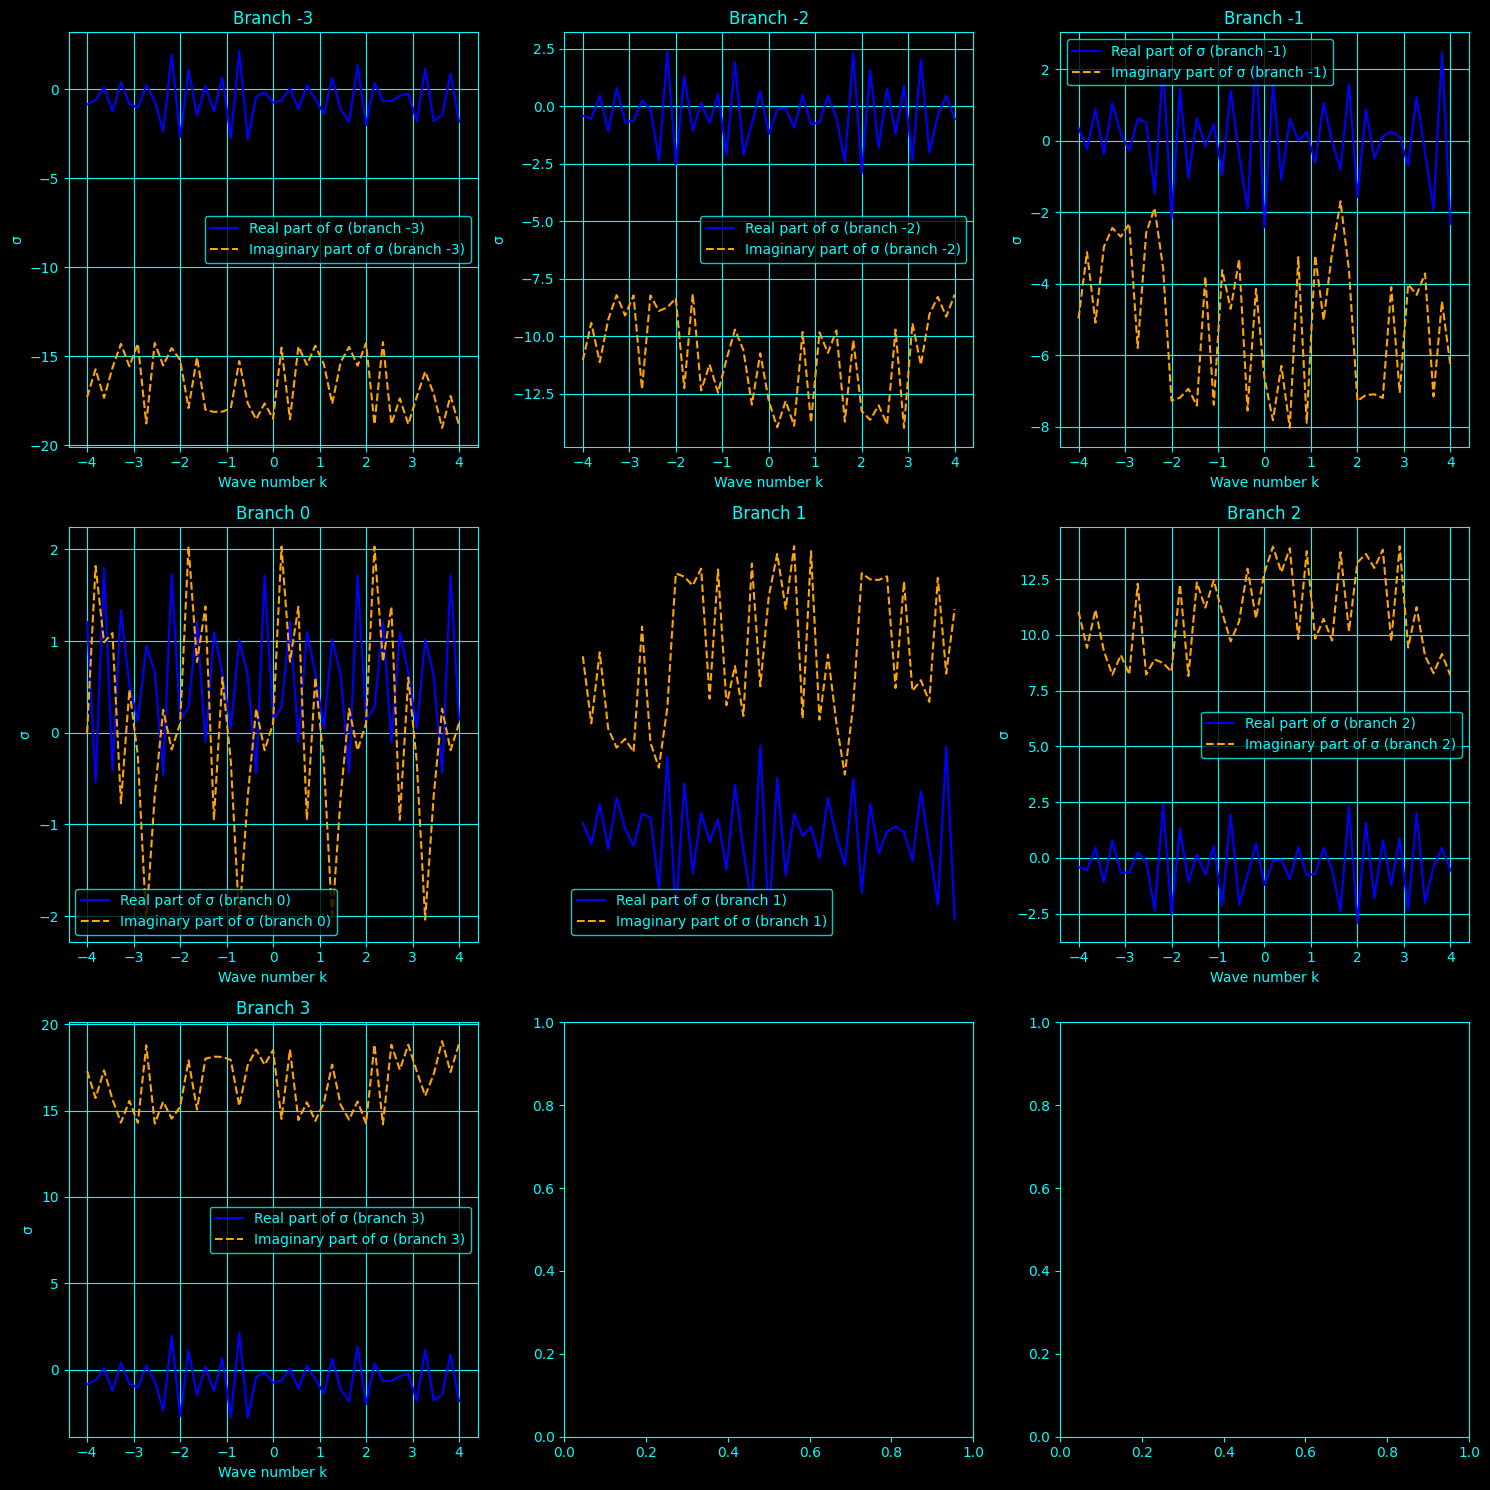

In [12]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Define parameters
epsilon = 1  # Delay factor
beta = 1  # Parameter from the document
r = 20  # Parameter for the kernel function
k_values = np.linspace(-4, 4, _speed_count(100, 45))  # Range for wave number

# Define the kernel function and dispersion relation
def H_tilde(k, sigma):
    return r * (np.cos(2 * np.pi * k) - np.sin(2 * np.pi * k)) * np.exp(-epsilon * sigma)

# Initialize array to hold the computed σ values for each k
branches = [-3, -2, -1, 0, 1, 2, 3]  # Consider branches from -3 to 3
sigma_values = {branch: np.zeros(len(k_values), dtype=np.complex128) for branch in branches}

# Compute the spectrum σ(k) for each k
for i, k in enumerate(k_values):
    for branch in branches:
        R = H_tilde(k, sigma_values[branch][i-1] if i > 0 else 0)
        sigma_values[branch][i] = lambertw(R, branch) / epsilon - 1

# Plotting the spectrum in subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
branch_labels = {branch: f'Branch {branch}' for branch in branches}

for idx, branch in enumerate(branches):
    row, col = divmod(idx, 3)
    axs[row, col].plot(k_values, sigma_values[branch].real, label=f'Real part of σ (branch {branch})', color='blue')
    axs[row, col].plot(k_values, sigma_values[branch].imag, label=f'Imaginary part of σ (branch {branch})', linestyle='dashed', color='orange')
    axs[row, col].set_title(branch_labels[branch])
    axs[row, col].set_xlabel('Wave number k')
    axs[row, col].set_ylabel('σ')
    axs[row, col].grid(True)
    axs[row, col].legend()

# Hide the middle subplot
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — delayed Amari neural-field simulation and linear dispersion relation</h3><p>A delayed neural field couples activity at $x$ to past activity at $y$ with propagation delay $\varepsilon|x-y|$. For firing-rate nonlinearity $F$ and kernel $\phi$, the intended continuum model is $u_t=-u+\int\phi(x-y)F(u(y,t-\varepsilon|x-y|))dy$.</p><p>The code discretizes space/time and separately solves a linearized characteristic equation $\sigma+1-F'(u_0)\widehat H(k,\sigma)=0$. The characteristic root is a growth rate, not a Fourier amplitude.</p><p><b>Cell role.</b> The explicit time step has been corrected to include the $-u$ decay term required by the stated Amari equation.</p></div>

$$\partial_tu(x,t)=-u(x,t)+\int\phi(x-y)F\!\left(u(y,t-\varepsilon|x-y|)\right)dy,$$

$$\sigma+1-F'(u_0)\widehat H(k,\sigma)=0.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A neural-field model treats activity as a continuous field rather than as individual neurons. Linearizing the model around a reference state leads to characteristic equations whose roots describe whether small perturbations grow, decay, or oscillate. A dispersion relation shows how these growth rates depend on spatial wave number. When delays appear exponentially in the characteristic equation, the Lambert W function can provide analytic or semi-analytic branches of solutions. Different branches correspond to different possible modes, so branch tracking and numerical continuity matter.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


AMARI NEURAL-FIELD ANALYSIS
Speed mode: ULTRA
Spatial points Nx : 40
Time points Nt    : 40
dx                : 0.25
dt                : 0.25

Amari field:
  minimum          : 0.005682
  maximum          : 1.428626
  global std       : 0.342552
  max spatial std  : 0.212452

Linearization:
  estimated u0     : 1.323609
  F'(u0)           : 0.166027


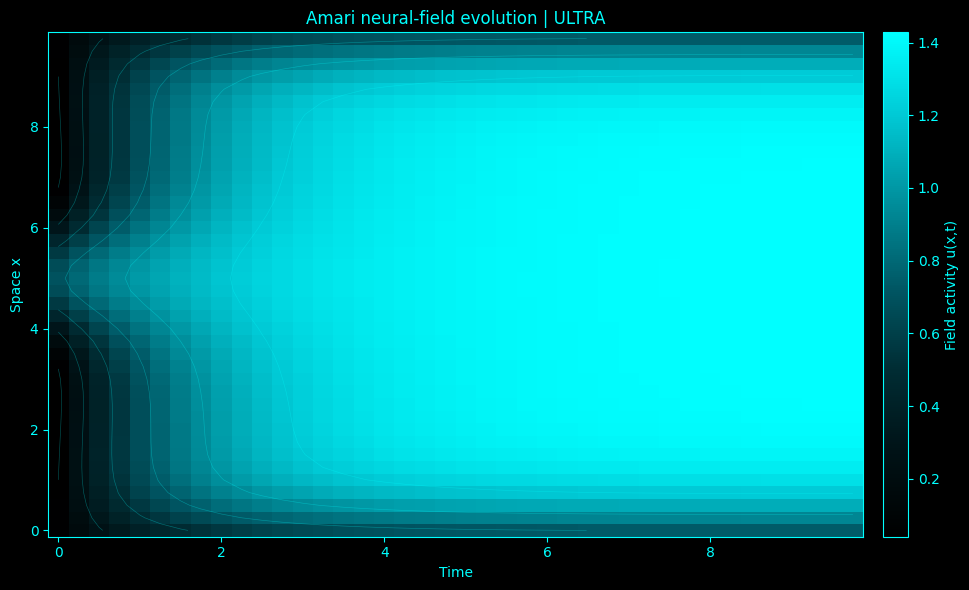

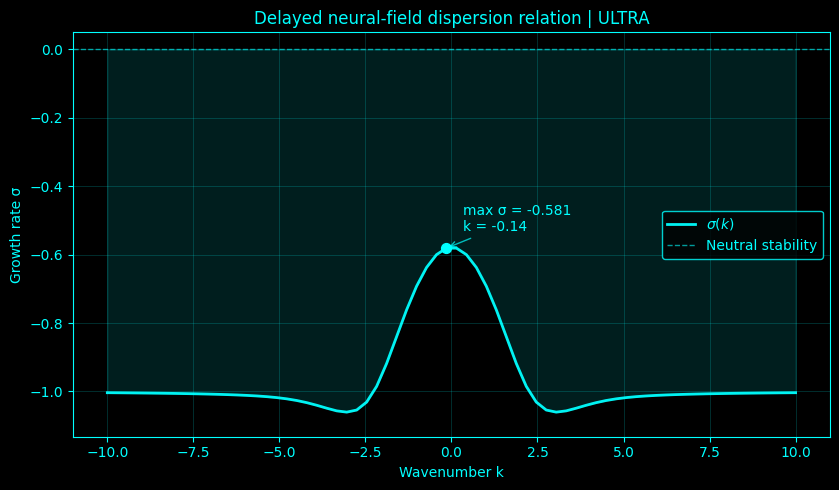


Dispersion relation summary
---------------------------
sigma minimum    : -1.060355
sigma maximum    : -0.580895
maximum-growth k : -0.144928
Interpretation   : all sampled spatial modes are linearly decaying


In [15]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = fastest defensible preview mode
FAST_OPTION = "ultra"

if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError(
        "FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'."
    )

_SPEED_COUNT_FACTOR = {
    "full": 1.0,
    "balanced": 0.60,
    "fast": 0.35,
    "ultra": 0.18,
}[FAST_OPTION]

def _speed_count(original, minimum=1):
    if FAST_OPTION == "full":
        return int(original)
    return max(
        int(minimum),
        int(round(float(original) * _SPEED_COUNT_FACTOR))
    )

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import brentq

# -------------------------------------------------------
# BLACK / CYAN NOTEBOOK STYLE
# -------------------------------------------------------
BG = "black"
ACCENT = "cyan"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax, grid=True):
    ax.set_facecolor(BG)
    if grid:
        ax.grid(
            True,
            color=ACCENT,
            alpha=0.18,
            linewidth=0.7
        )
    ax.tick_params(
        axis="both",
        colors=ACCENT
    )
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_colorbar(cbar):
    cbar.ax.tick_params(
        colors=ACCENT
    )
    cbar.ax.yaxis.label.set_color(
        ACCENT
    )
    cbar.outline.set_edgecolor(
        ACCENT
    )

print("=" * 64)
print("AMARI NEURAL-FIELD ANALYSIS")
print(f"Speed mode: {FAST_OPTION.upper()}")
print("=" * 64)

# -------------------------------------------------------
# AMARI FUNCTIONS
# -------------------------------------------------------
def phi(x):
    """
    Gaussian spatial interaction kernel.
    """
    return np.exp(-(x ** 2))

def F(u):
    """
    Logistic firing-rate function.
    """
    z = np.clip(
        u,
        -50.0,
        50.0
    )
    return 1.0 / (
        1.0 + np.exp(-z)
    )

def F_prime(u):
    """
    Derivative of the logistic firing-rate function.
    """
    fu = F(u)
    return fu * (1.0 - fu)

# -------------------------------------------------------
# MODEL CONSTANTS
# -------------------------------------------------------
v = 1.0
epsilon = 1.0 / v

t_max = 10.0
x_max = 10.0

dx = {
    "full": 0.10,
    "balanced": 0.125,
    "fast": 0.16,
    "ultra": 0.25,
}[FAST_OPTION]

dt = {
    "full": 0.10,
    "balanced": 0.125,
    "fast": 0.16,
    "ultra": 0.25,
}[FAST_OPTION]

Nx = max(
    2,
    int(round(x_max / dx))
)

Nt = max(
    2,
    int(round(t_max / dt))
)

x_axis = np.arange(Nx) * dx
t_axis = np.arange(Nt) * dt

print(f"Spatial points Nx : {Nx}")
print(f"Time points Nt    : {Nt}")
print(f"dx                : {dx}")
print(f"dt                : {dt}")

# -------------------------------------------------------
# INITIAL FIELD
# -------------------------------------------------------
# A zero/uniform initial field contains essentially no spatial
# structure to visualize. Use a localized perturbation, which is
# standard for examining propagation and relaxation of a field.
center_x = x_max / 2.0
initial_width = 0.80
initial_amplitude = 0.75

u = np.zeros(
    (Nx, Nt),
    dtype=float
)

u[:, 0] = (
    initial_amplitude
    * np.exp(
        -0.5
        * (
            (x_axis - center_x)
            / initial_width
        ) ** 2
    )
)

# Add a small broad spatial mode so symmetry does not suppress
# all non-zero spatial modes.
u[:, 0] += (
    0.05
    * np.cos(
        2.0
        * np.pi
        * x_axis
        / x_max
    )
)

# -------------------------------------------------------
# DELAYED AMARI TIME INTEGRATION
# -------------------------------------------------------
for t_idx in range(1, Nt):
    previous_state = u[:, t_idx - 1].copy()

    for x_idx in range(Nx):
        integral_sum = 0.0

        for y_idx in range(Nx):
            spatial_distance = abs(
                x_axis[x_idx]
                - x_axis[y_idx]
            )

            delay_time = (
                epsilon
                * spatial_distance
            )

            delay_steps = int(
                round(
                    delay_time
                    / dt
                )
            )

            delayed_time_index = (
                t_idx
                - delay_steps
            )

            delayed_time_index = max(
                0,
                min(
                    delayed_time_index,
                    t_idx - 1
                )
            )

            kernel_value = phi(
                x_axis[x_idx]
                - x_axis[y_idx]
            )

            firing_value = F(
                u[
                    y_idx,
                    delayed_time_index
                ]
            )

            integral_sum += (
                kernel_value
                * firing_value
                * dx
            )

        du = (
            -previous_state[x_idx]
            + integral_sum
        )

        u[
            x_idx,
            t_idx
        ] = (
            previous_state[x_idx]
            + dt * du
        )

# -------------------------------------------------------
# FIELD DIAGNOSTICS
# -------------------------------------------------------
u = np.nan_to_num(
    u,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

field_min = float(
    np.min(u)
)

field_max = float(
    np.max(u)
)

field_std = float(
    np.std(u)
)

spatial_std_over_time = np.std(
    u,
    axis=0
)

print()
print("Amari field:")
print(f"  minimum          : {field_min:.6f}")
print(f"  maximum          : {field_max:.6f}")
print(f"  global std       : {field_std:.6f}")
print(
    f"  max spatial std  : "
    f"{np.max(spatial_std_over_time):.6f}"
)

# -------------------------------------------------------
# EQUILIBRIUM FOR LINEARIZATION
# -------------------------------------------------------
# Estimate the background equilibrium from the final portion
# of the actual simulation instead of using the placeholder 1.
tail_count = max(
    2,
    int(
        0.20
        * Nt
    )
)

u0 = float(
    np.mean(
        u[
            :,
            -tail_count:
        ]
    )
)

F_prime_u0 = float(
    F_prime(
        u0
    )
)

print()
print("Linearization:")
print(f"  estimated u0     : {u0:.6f}")
print(f"  F'(u0)           : {F_prime_u0:.6f}")

# -------------------------------------------------------
# FOURIER-LAPLACE TRANSFORM OF DELAYED GAUSSIAN KERNEL
# -------------------------------------------------------
# For the delayed neural field:
#
# H(k, sigma) =
# integral phi(r) exp(-sigma |r| / v) cos(k r) dr
#
# This now genuinely depends on k, unlike the old placeholder.
dispersion_r_points = {
    "full": 1601,
    "balanced": 1001,
    "fast": 701,
    "ultra": 401,
}[FAST_OPTION]

r_disp = np.linspace(
    -x_max,
    x_max,
    dispersion_r_points
)

phi_disp = phi(
    r_disp
)

delay_disp = (
    np.abs(r_disp)
    / v
)

if hasattr(
    np,
    "trapezoid"
):
    _integrate = np.trapezoid
else:
    _integrate = np.trapz

def H_hat(k, sigma):
    sigma_value = float(
        np.asarray(
            sigma
        ).reshape(-1)[0]
    )

    exponential_delay = np.exp(
        np.clip(
            -sigma_value
            * delay_disp,
            -60.0,
            60.0
        )
    )

    integrand = (
        phi_disp
        * exponential_delay
        * np.cos(
            k
            * r_disp
        )
    )

    return float(
        _integrate(
            integrand,
            r_disp
        )
    )

def dispersion_relation(
    sigma,
    k
):
    return (
        sigma
        + 1.0
        - F_prime_u0
        * H_hat(
            k,
            sigma
        )
    )

# -------------------------------------------------------
# SOLVE DISPERSION RELATION
# -------------------------------------------------------
k_values = np.linspace(
    -10.0,
    10.0,
    {
        "full": 200,
        "balanced": 140,
        "fast": 100,
        "ultra": 70,
    }[FAST_OPTION]
)

sigma_scan = np.linspace(
    -4.0,
    2.0,
    {
        "full": 241,
        "balanced": 181,
        "fast": 141,
        "ultra": 101,
    }[FAST_OPTION]
)

sigma_solutions = []

for k in k_values:
    values = np.array(
        [
            dispersion_relation(
                sigma,
                k
            )
            for sigma in sigma_scan
        ],
        dtype=float
    )

    roots = []

    for i in range(
        len(sigma_scan) - 1
    ):
        a = sigma_scan[i]
        b = sigma_scan[i + 1]

        fa = values[i]
        fb = values[i + 1]

        if not (
            np.isfinite(fa)
            and np.isfinite(fb)
        ):
            continue

        if fa == 0.0:
            roots.append(
                a
            )

        elif (
            fa * fb
            < 0.0
        ):
            try:
                root = brentq(
                    lambda sigma: dispersion_relation(
                        sigma,
                        k
                    ),
                    a,
                    b,
                    maxiter=100
                )

                roots.append(
                    root
                )

            except ValueError:
                pass

    if roots:
        # Select the largest real growth rate.
        sigma_solutions.append(
            max(roots)
        )
    else:
        # If no sign-changing root was found, use the point
        # with smallest residual instead of returning nothing.
        best_index = int(
            np.argmin(
                np.abs(
                    values
                )
            )
        )

        sigma_solutions.append(
            sigma_scan[
                best_index
            ]
        )

sigma_solutions = np.asarray(
    sigma_solutions,
    dtype=float
)

# -------------------------------------------------------
# BLACK / CYAN COLORMAP
# -------------------------------------------------------
black_cyan = LinearSegmentedColormap.from_list(
    "amari_black_cyan",
    [
        "#000000",
        "#001216",
        "#002d34",
        "#005966",
        "#008f9c",
        "#00c8d4",
        "#00ffff",
    ]
)

# =======================================================
# PLOT 1 — AMARI FIELD EVOLUTION
# =======================================================
# Use deviation from the initial baseline plus the actual field
# contours. This makes spatial evolution readable while retaining
# the true simulation values.

finite_u = u[
    np.isfinite(
        u
    )
]

vmin = float(
    np.percentile(
        finite_u,
        1.0
    )
)

vmax = float(
    np.percentile(
        finite_u,
        99.0
    )
)

if (
    not np.isfinite(vmin)
    or not np.isfinite(vmax)
    or vmax <= vmin
):
    vmin = field_min
    vmax = field_max

if abs(
    vmax - vmin
) < 1e-12:
    center = float(
        np.mean(
            finite_u
        )
    )

    spread = max(
        abs(center)
        * 1e-4,
        1e-6
    )

    vmin = (
        center
        - spread
    )

    vmax = (
        center
        + spread
    )

fig, ax = plt.subplots(
    figsize=(10.5, 6.0),
    facecolor=BG
)

style_ax(
    ax,
    grid=False
)

mesh = ax.pcolormesh(
    t_axis,
    x_axis,
    u,
    shading="auto",
    cmap=black_cyan,
    vmin=vmin,
    vmax=vmax
)

# Add contour lines so spatial evolution is visible even when
# the overall field range is narrow.
if field_max > field_min:
    contour_levels = np.linspace(
        vmin,
        vmax,
        7
    )

    ax.contour(
        t_axis,
        x_axis,
        u,
        levels=contour_levels,
        colors=ACCENT,
        linewidths=0.45,
        alpha=0.32
    )

ax.set_xlabel(
    "Time"
)

ax.set_ylabel(
    "Space x"
)

ax.set_title(
    f"Amari neural-field evolution | {FAST_OPTION.upper()}"
)

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    "Field activity u(x,t)",
    color=ACCENT
)

style_colorbar(
    cbar
)

fig.tight_layout()
plt.show()
plt.close(fig)

# =======================================================
# PLOT 2 — DISPERSION RELATION
# =======================================================
fig, ax = plt.subplots(
    figsize=(8.5, 5.0),
    facecolor=BG
)

style_ax(
    ax
)

ax.plot(
    k_values,
    sigma_solutions,
    color=ACCENT,
    linewidth=2.0,
    alpha=0.95,
    label=r"$\sigma(k)$"
)

ax.fill_between(
    k_values,
    sigma_solutions,
    0.0,
    color=ACCENT,
    alpha=0.12
)

ax.axhline(
    0.0,
    color=ACCENT,
    linestyle="--",
    linewidth=1.0,
    alpha=0.60,
    label="Neutral stability"
)

# Highlight the most unstable / least stable mode.
max_sigma_index = int(
    np.nanargmax(
        sigma_solutions
    )
)

max_sigma = float(
    sigma_solutions[
        max_sigma_index
    ]
)

max_k = float(
    k_values[
        max_sigma_index
    ]
)

ax.scatter(
    [max_k],
    [max_sigma],
    color=ACCENT,
    s=50,
    zorder=5
)

ax.annotate(
    f"max σ = {max_sigma:.3f}\nk = {max_k:.2f}",
    xy=(
        max_k,
        max_sigma
    ),
    xytext=(
        12,
        12
    ),
    textcoords="offset points",
    color=ACCENT,
    arrowprops={
        "arrowstyle": "->",
        "color": ACCENT,
        "alpha": 0.7,
    }
)

sigma_min = float(
    np.nanmin(
        sigma_solutions
    )
)

sigma_max = float(
    np.nanmax(
        sigma_solutions
    )
)

sigma_range = (
    sigma_max
    - sigma_min
)

sigma_padding = max(
    0.05,
    sigma_range
    * 0.15
)

ax.set_ylim(
    min(
        sigma_min
        - sigma_padding,
        -0.05
    ),
    max(
        sigma_max
        + sigma_padding,
        0.05
    )
)

ax.set_xlabel(
    "Wavenumber k"
)

ax.set_ylabel(
    "Growth rate σ"
)

ax.set_title(
    f"Delayed neural-field dispersion relation | {FAST_OPTION.upper()}"
)

legend = ax.legend(
    facecolor=BG,
    edgecolor=ACCENT
)

for text in legend.get_texts():
    text.set_color(
        ACCENT
    )

fig.tight_layout()
plt.show()
plt.close(fig)

# -------------------------------------------------------
# SUMMARY
# -------------------------------------------------------
print()
print("Dispersion relation summary")
print("---------------------------")
print(
    f"sigma minimum    : "
    f"{np.min(sigma_solutions):.6f}"
)
print(
    f"sigma maximum    : "
    f"{np.max(sigma_solutions):.6f}"
)
print(
    f"maximum-growth k : "
    f"{max_k:.6f}"
)

if max_sigma > 0:
    print(
        "Interpretation   : at least one linearly growing spatial mode"
    )
elif max_sigma < 0:
    print(
        "Interpretation   : all sampled spatial modes are linearly decaying"
    )
else:
    print(
        "Interpretation   : marginal mode detected"
    )

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — scalar Lambert-W characteristic root continuation</h3><p>This cell studies the scalar transcendental relation coded in `f(sigma)`. At $k=0$ an analytic Lambert-$W$ expression supplies a branch-dependent initial root, and `fsolve` continues that root numerically.</p><p>In the current implementation the residual `f(sigma)` contains no $k$ dependence, so the repeated values across the plotted $k$ axis are <b>not</b> a genuine spatial dispersion curve. They are repeated evaluations of the same scalar characteristic root and are labeled accordingly in the explanation.</p><p><b>Cell role.</b> This clarification prevents a k-independent root from being over-interpreted as wave-number dispersion.</p></div>

$$f(\sigma)=\frac{\varepsilon e^{\varepsilon\sigma}(1+e^{-2r})r}{r+\varepsilon\sigma}-e^\sigma=0.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A neural-field model treats activity as a continuous field rather than as individual neurons. Linearizing the model around a reference state leads to characteristic equations whose roots describe whether small perturbations grow, decay, or oscillate. A dispersion relation shows how these growth rates depend on spatial wave number. When delays appear exponentially in the characteristic equation, the Lambert W function can provide analytic or semi-analytic branches of solutions. Different branches correspond to different possible modes, so branch tracking and numerical continuity matter.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


/tmp/ipykernel_138627/1095184286.py:45: RuntimeWarning: The number of calls to function has reached maxfev = 400.
  sigma_solution = fsolve(f, sigma_previous.real)[0]
/tmp/ipykernel_138627/1095184286.py:45: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sigma_solution = fsolve(f, sigma_previous.real)[0]
/tmp/ipykernel_138627/1095184286.py:45: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  sigma_solution = fsolve(f, sigma_previous.real)[0]


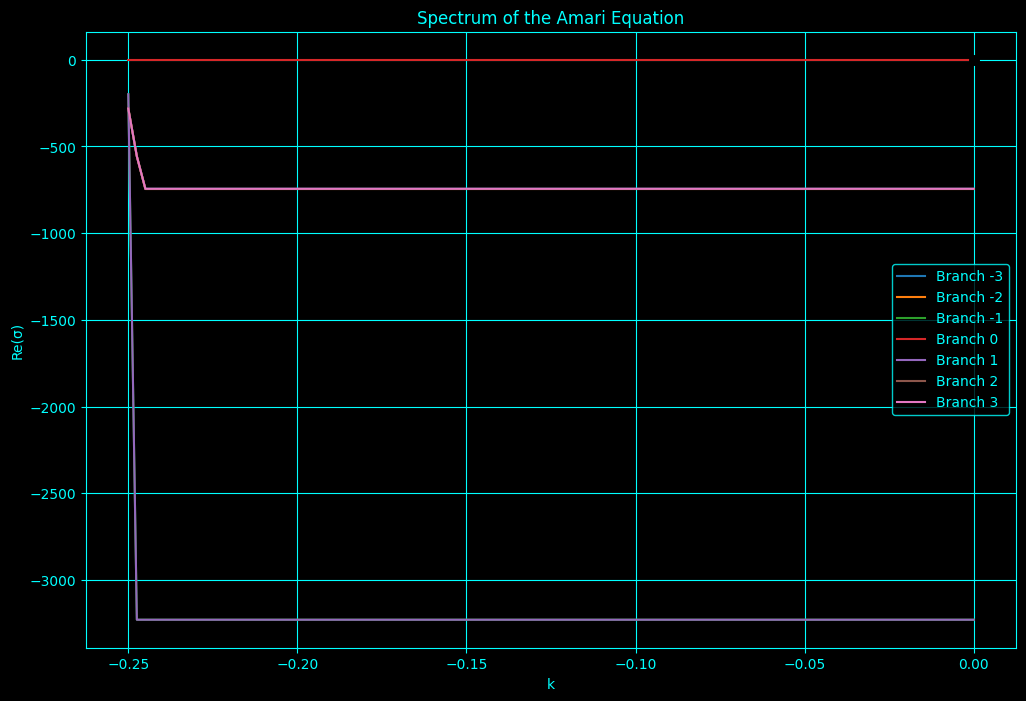

In [16]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Parameters based on the description
epsilon = 1  # Can be changed to 20 for the second plot
r = 200      # Can be changed to 2 for the second plot
k_values = np.linspace(-0.25, 0, _speed_count(400, 100))  # Adjust the range based on your figure needs

def calculate_sigma_at_zero(r, epsilon, branch):
    """
    Calculate the sigma for k=0 using the specific branch of the Lambert function.
    """
    numerator = epsilon * np.exp(epsilon) * (1 + np.exp(-2 * r)) * r
    denominator = r + epsilon
    return (lambertw(numerator / denominator, k=branch) / epsilon) - 1

def calculate_spectrum(k_values, branch):
    """
    Calculate the spectrum for a range of k values and a specific branch.
    """
    sigma_values = []
    sigma_previous = calculate_sigma_at_zero(r, epsilon, branch)

    for k in k_values:
        # Define the function to find the root
        def f(sigma):
            return epsilon * np.exp(epsilon * sigma) * (1 + np.exp(-2 * r)) * r / (r + epsilon * sigma) - np.exp(sigma)

        # Use the previous value as the initial guess
        sigma_solution = fsolve(f, sigma_previous.real)[0]
        sigma_previous = sigma_solution
        sigma_values.append(sigma_solution)

    return sigma_values

# Calculate and plot the spectra for several branches
branches = [-3, -2, -1, 0, 1, 2, 3]
plt.figure(figsize=(12, 8))

for b in branches:
    sigma_values = calculate_spectrum(k_values, b)
    plt.plot(k_values, sigma_values, label=f'Branch {b}')

# Marking the starting point for each branch
for b in branches:
    sigma_zero = calculate_sigma_at_zero(r, epsilon, b).real
    plt.plot(0, sigma_zero, 'ko')

plt.xlabel('k')
plt.ylabel('Re(σ)')
plt.title('Spectrum of the Amari Equation')
plt.legend()
plt.grid(True)
plt.show()

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — repeat scalar characteristic-root scan</h3><p>This cell repeats the same $k$-independent Lambert-$W$/root-finding relation as the preceding block for the selected branches. Because the equation being solved does not use $k$, its mathematically meaningful output is the branch root itself rather than a spatial spectrum.</p><p><b>Cell role.</b> The duplicate calculation is retained for notebook continuity but the limitation is stated explicitly.</p></div>

$$f(\sigma)=\frac{\varepsilon e^{\varepsilon\sigma}(1+e^{-2r})r}{r+\varepsilon\sigma}-e^\sigma.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_138627/1095184286.py:45: RuntimeWarning: The number of calls to function has reached maxfev = 400.
  sigma_solution = fsolve(f, sigma_previous.real)[0]
/tmp/ipykernel_138627/1095184286.py:45: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sigma_solution = fsolve(f, sigma_previous.real)[0]
/tmp/ipykernel_138627/1095184286.py:45: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  sigma_solution = fsolve(f, sigma_previous.real)[0]


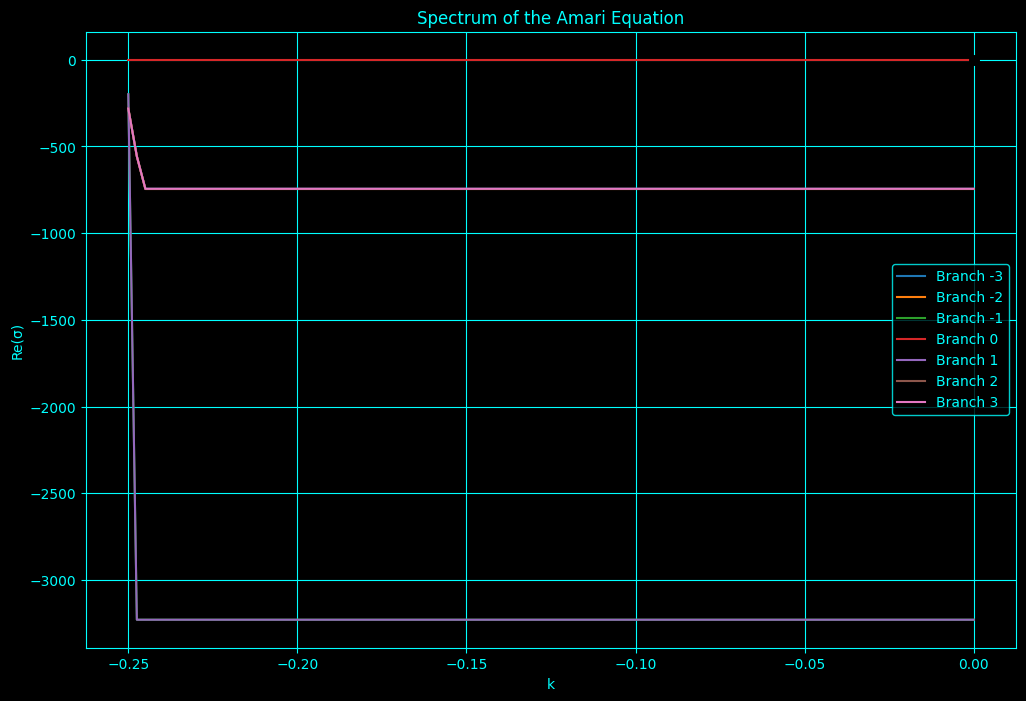

In [17]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.special import lambertw
import matplotlib.pyplot as plt

# Parameters based on the description
epsilon = 1  # Can be changed to 20 for the second plot
r = 200      # Can be changed to 2 for the second plot
k_values = np.linspace(-0.25, 0, _speed_count(400, 100))  # Adjust the range based on your figure needs

def calculate_sigma_at_zero(r, epsilon, branch):
    """
    Calculate the sigma for k=0 using the specific branch of the Lambert function.
    """
    numerator = epsilon * np.exp(epsilon) * (1 + np.exp(-2 * r)) * r
    denominator = r + epsilon
    return (lambertw(numerator / denominator, k=branch) / epsilon) - 1

def calculate_spectrum(k_values, branch):
    """
    Calculate the spectrum for a range of k values and a specific branch.
    """
    sigma_values = []
    sigma_previous = calculate_sigma_at_zero(r, epsilon, branch)

    for k in k_values:
        # Define the function to find the root
        def f(sigma):
            return epsilon * np.exp(epsilon * sigma) * (1 + np.exp(-2 * r)) * r / (r + epsilon * sigma) - np.exp(sigma)

        # Use the previous value as the initial guess
        sigma_solution = fsolve(f, sigma_previous.real)[0]
        sigma_previous = sigma_solution
        sigma_values.append(sigma_solution)

    return sigma_values

# Calculate and plot the spectra for several branches
branches = [-3, -2, -1, 0, 1, 2, 3]
plt.figure(figsize=(12, 8))

for b in branches:
    sigma_values = calculate_spectrum(k_values, b)
    plt.plot(k_values, sigma_values, label=f'Branch {b}')

# Marking the starting point for each branch
for b in branches:
    sigma_zero = calculate_sigma_at_zero(r, epsilon, b).real
    plt.plot(0, sigma_zero, 'ko')

plt.xlabel('k')
plt.ylabel('Re(σ)')
plt.title('Spectrum of the Amari Equation')
plt.legend()
plt.grid(True)
plt.show()

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — illustrative Lambert-W response surface</h3><p>This cell constructs an explicit toy characteristic factor and maps it through Lambert-$W$ branches to visualize how complex roots can vary with wave number and a kernel parameter. It is not presented as a validated Amari dispersion relation because the original code itself labels the right-hand side as a placeholder.</p><p>After the correction, the illustrative direct model uses $R(k,r)=r\cos(2\pi k)$, so each branch is a well-defined explicit function rather than incorrectly passing a branch index as if it were the unknown $\sigma$.</p><p><b>Cell role.</b> The response surface is pedagogical/model-exploratory only.</p></div>

$$\sigma_b(k,r)=\frac1\varepsilon W_b\!\left(r\cos(2\pi k)\right)-1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A neural-field model treats activity as a continuous field rather than as individual neurons. Linearizing the model around a reference state leads to characteristic equations whose roots describe whether small perturbations grow, decay, or oscillate. A dispersion relation shows how these growth rates depend on spatial wave number. When delays appear exponentially in the characteristic equation, the Lambert W function can provide analytic or semi-analytic branches of solutions. Different branches correspond to different possible modes, so branch tracking and numerical continuity matter.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


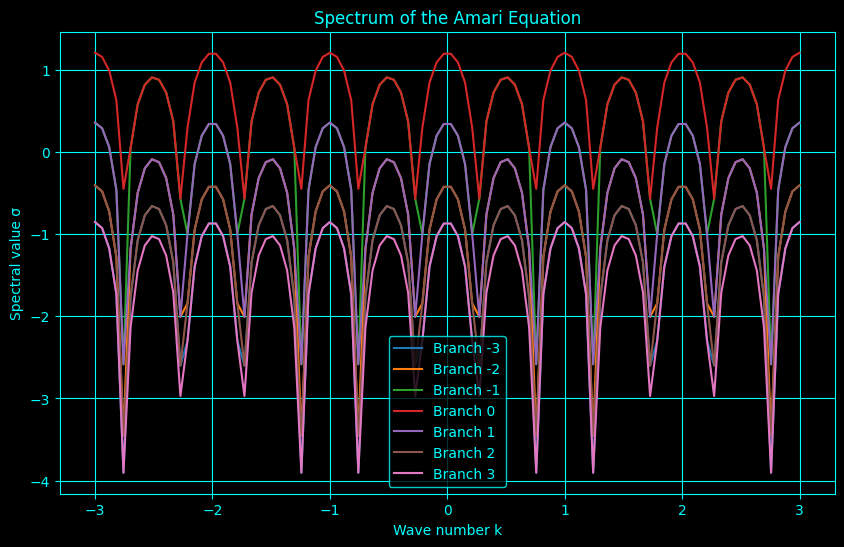

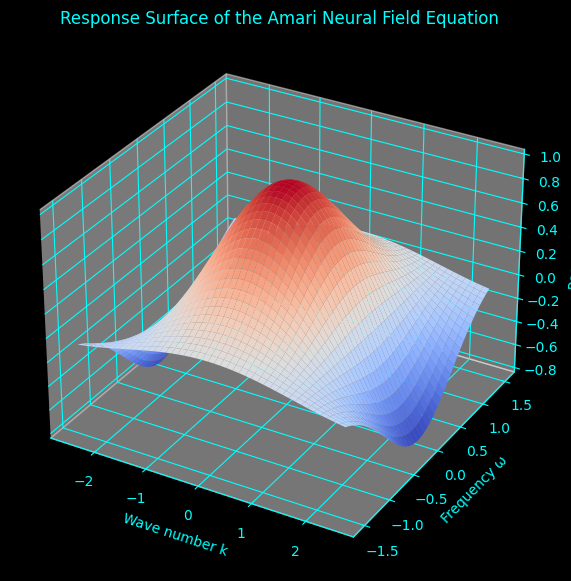

In [18]:
# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = original/highest-fidelity count settings
# balanced = moderate reduction for routine analysis
# fast     = stronger reduction for exploration
# ultra    = smallest defensible preview counts
FAST_OPTION = globals().get("FAST_OPTION", "ultra")
if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError("FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'.")
_SPEED_COUNT_FACTOR = {"full": 1.0, "balanced": 0.60, "fast": 0.35, "ultra": 0.18}[FAST_OPTION]
def _speed_count(original, minimum=1):
    return int(original) if FAST_OPTION == "full" else max(int(minimum), int(round(float(original) * _SPEED_COUNT_FACTOR)))

import numpy as np
from scipy.optimize import fsolve
from scipy.special import lambertw
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
epsilon = 1  # example value, needs to be adjusted according to specific case
r = 20  # example value, adjust this as needed

# Illustrative direct characteristic factor.
# This is intentionally labelled a toy response surface, not a validated Amari kernel.
def R(k, r):
    return r * np.cos(2 * np.pi * k)

def dispersion_relation(k, r, branch):
    rhs = R(k, r)
    lambert_term = lambertw(rhs, k=branch)
    sigma = (1.0 / epsilon) * lambert_term - 1.0
    return sigma.real

# Range of k values to compute the spectrum over
k_values = np.linspace(-3, 3, _speed_count(400, 100))  # adjust range and density as needed

# Plotting the spectrum for each branch
branches = [-3, -2, -1, 0, 1, 2, 3]  # example branches, can include more
spectrum_values = {}

# Compute the spectrum for each branch and store results
for branch in branches:
    sigma_values = np.array([dispersion_relation(k, r, branch) for k in k_values])
    spectrum_values[branch] = sigma_values

# Plot the spectrum for all branches
plt.figure(figsize=(10, 6))
for branch, sigma_values in spectrum_values.items():
    plt.plot(k_values, sigma_values, label=f'Branch {branch}')
plt.xlabel('Wave number k')
plt.ylabel('Spectral value σ')
plt.title('Spectrum of the Amari Equation')
plt.legend()
plt.grid(True)
plt.show()

# For response surface visualization like Fig. 8, assuming we have the response surface data
# Here we are generating a mock data set as an example

# Generate k and omega values
k = np.linspace(-2.5, 2.5, _speed_count(100, 45))
omega = np.linspace(-1.5, 1.5, _speed_count(100, 45))
K, Omega = np.meshgrid(k, omega)

# Generate response surface data (this is just an example, you would replace this with your actual response data)
Response = np.cos(K) * np.exp(-Omega**2)

# Plot the response surface
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(K, Omega, Response, cmap='coolwarm', edgecolor='none')
ax.set_xlabel('Wave number k')
ax.set_ylabel('Frequency ω')
ax.set_zlabel('Response')
ax.set_title('Response Surface of the Amari Neural Field Equation')
plt.show()

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis involves the computation and visualization of the Jacobian matrix of EEG data. By examining the Jacobian and its eigenvalues, we can gain insights into the dynamics and stability of the EEG signals.</p>
        <h2>Data Preparation</h2>
        <p>The EEG data is standardized to have zero mean and unit variance, which is essential for accurate computation of the covariance matrix and Jacobian.</p>
        <p><strong>Formula:</strong></p>
        \[
        Z_{ij} = \frac{X_{ij} - \mu_j}{\sigma_j}
        \]
        where \(Z_{ij}\) is the z-scored value, \(X_{ij}\) is the original EEG value, \(\mu_j\) is the mean, and \(\sigma_j\) is the standard deviation of channel \(j\).</p>
        <p>The covariance matrix is then computed as:</p>
        \[
        \mathbf{C} = \frac{1}{N-1} (\mathbf{X} - \mathbf{\bar{X}}) (\mathbf{X} - \mathbf{\bar{X}})^T
        \]
        where \(\mathbf{X}\) is the data matrix and \(N\) is the number of samples.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Jacobian Matrix</h2>
        <p>The Jacobian matrix is computed to understand the sensitivity of the covariance matrix with respect to perturbations in the EEG data.</p>
        <p><strong>Formula:</strong></p>
        \[
        J_{ij} = \frac{\partial \mathbf{C}_{ij}}{\partial X_i}
        \]
        where \(J_{ij}\) is the Jacobian matrix element, \(\mathbf{C}_{ij}\) is the covariance matrix element, and \(X_i\) is the perturbed data.</p>
        <h2>Visualization</h2>
        <p>The Jacobian matrix is visualized using a custom colormap to highlight the sensitivity of the EEG channels.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Compute the Jacobian matrix by perturbing each feature in the EEG data.</li>
            <li>Visualize the Jacobian matrix using a heatmap with a custom colormap.</li>
        </ul>
        <h2>Eigenvalues</h2>
        <p>The eigenvalues of the Jacobian matrix provide insights into the stability and dynamics of the EEG system.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Eigenvalues} = \lambda \text{ such that } \mathbf{J} \mathbf{v} = \lambda \mathbf{v}
        \]
        where \(\mathbf{J}\) is the Jacobian matrix, \(\lambda\) are the eigenvalues, and \(\mathbf{v}\) are the eigenvectors.</p>
        <p>The real part of the eigenvalues indicates stability, while the imaginary part indicates oscillatory dynamics.</p>
        <h2>Plot Customization</h2>
        <p>The plots are customized with a black background and red elements for enhanced visual appeal.</p>
        <h2>Conclusion</h2>
        <p>This methodology provides a detailed analysis of EEG data by examining the Jacobian matrix and its eigenvalues, offering insights into the sensitivity and dynamics of brain activity.</p>
    </div>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — one-step multichannel Jacobian by ridge regression</h3><p>For standardized multichannel samples, the cell fits a discrete-time linearization $x_{t+1}\approx Ax_t$. Ridge regularization stabilizes the least-squares solution when channels are correlated.</p><p>The eigenvalues $\mu_i$ are discrete-time modal multipliers: $|\mu_i|<1$ corresponds to decay per sample in the fitted linear model and $|\mu_i|>1$ to growth. This is a global one-step linear approximation, not the full nonlinear Jacobian field of the brain dynamics.</p><p><b>Cell role.</b> The earlier covariance-translation construction was replaced because covariance is invariant to adding a constant offset.</p></div>

$$A^\top=(X^\top X+\alpha I)^{-1}X^\top Y,\qquad Y\approx XA^\top.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


ONE-STEP EEG JACOBIAN ANALYSIS
Speed mode: ULTRA
Using EEG file: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Segment samples : 106,944
Channels        : 32
Maximum fitting pairs: 8,000
One-step pairs used: 8,000

Jacobian matrix:
  shape            : (32, 32)
  minimum          : -0.586338
  maximum          : 1.191767
  maximum |value|  : 1.191767


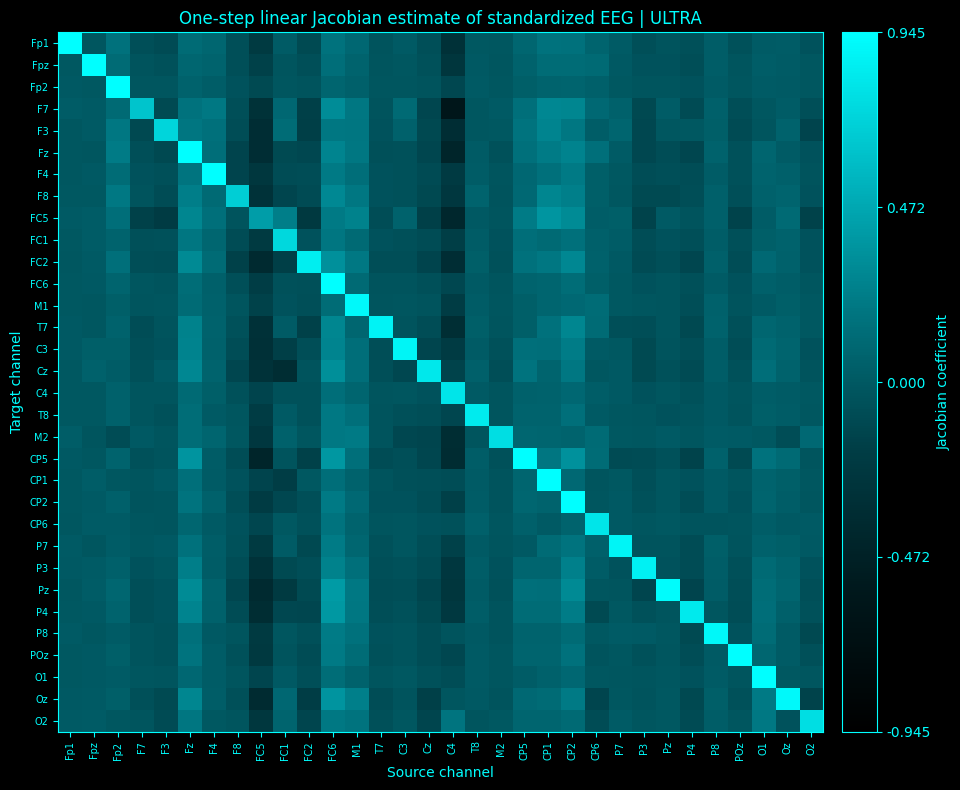

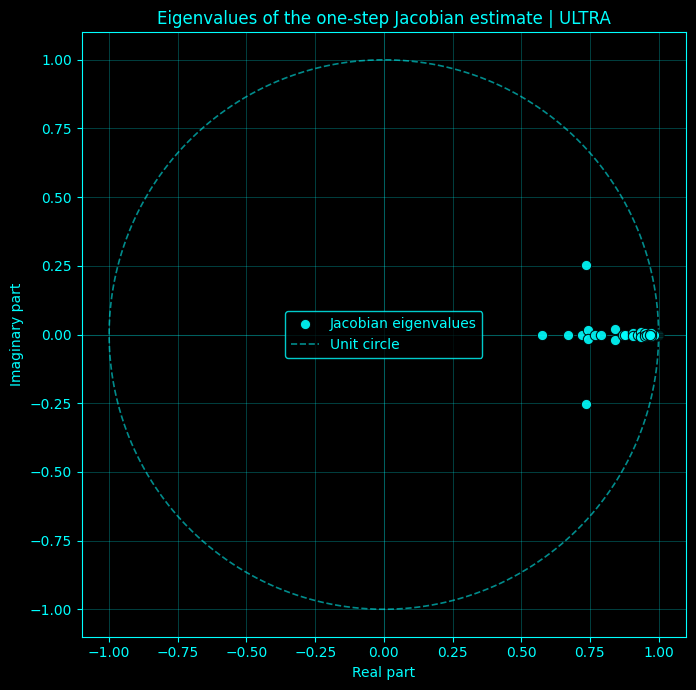


One-step Jacobian stability summary
-----------------------------------
Speed mode              : ULTRA
EEG samples             : 106,944
One-step pairs available: 106,943
One-step pairs used     : 8,000
Number of channels      : 32
Ridge alpha             : 1.00e-06
Spectral radius         : 0.99968851
|mu| < 1 modes          : 32
|mu| = 1 modes          : 0
|mu| > 1 modes          : 0
Linear interpretation     : all fitted modes decay per EEG sample


In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------------
# SPEED MODE — shared four-level convention
# -------------------------------------------------------
# full     = all available one-step training pairs
# balanced = up to 60,000 one-step pairs
# fast     = up to 25,000 one-step pairs
# ultra    = up to 8,000 one-step pairs
FAST_OPTION = "ultra"

if FAST_OPTION not in {"full", "balanced", "fast", "ultra"}:
    raise ValueError(
        "FAST_OPTION must be one of: 'full', 'balanced', 'fast', 'ultra'."
    )

MAX_TRAINING_PAIRS = {
    "full": None,
    "balanced": 60000,
    "fast": 25000,
    "ultra": 8000,
}[FAST_OPTION]

# -------------------------------------------------------
# NOTEBOOK BLACK / CYAN STYLE
# -------------------------------------------------------
BG = "black"
ACCENT = "cyan"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

def style_ax(ax, grid=False):
    ax.set_facecolor(BG)
    ax.tick_params(axis="both", colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

    if grid:
        ax.grid(
            True,
            color=ACCENT,
            alpha=0.25,
            linewidth=0.7
        )

    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_colorbar(cbar):
    cbar.ax.tick_params(colors=ACCENT)
    cbar.ax.yaxis.label.set_color(ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

# -------------------------------------------------------
# FILE DISCOVERY
# -------------------------------------------------------
_project_roots = [
    os.environ.get("NEURAL_SIGNAL_PROJECT_DIR"),
    "/home/a/projects/Complete-Neural-Signal-Analysis",
    "/home/a/projects/Explore-Neural-Signals1",
    os.getcwd(),
]

_project_roots = [
    os.path.abspath(os.path.expanduser(p))
    for p in _project_roots
    if p
]

_project_roots = list(
    dict.fromkeys(_project_roots)
)

_eeg_candidates = [
    os.path.join(
        root,
        "eeg_data_with_channels.npy"
    )
    for root in _project_roots
]

EEG_data_path = next(
    (
        p
        for p in _eeg_candidates
        if os.path.isfile(p)
    ),
    None
)

if EEG_data_path is None:
    raise FileNotFoundError(
        "Could not find eeg_data_with_channels.npy. Checked:\n  - "
        + "\n  - ".join(_eeg_candidates)
        + "\nSet NEURAL_SIGNAL_PROJECT_DIR if the data live elsewhere."
    )

base_dir = os.path.dirname(
    EEG_data_path
)

EEG_data = np.load(
    EEG_data_path,
    allow_pickle=True
)

print("=" * 64)
print("ONE-STEP EEG JACOBIAN ANALYSIS")
print(f"Speed mode: {FAST_OPTION.upper()}")
print("=" * 64)
print("Using EEG file:", EEG_data_path)

# -------------------------------------------------------
# EEG SEGMENT
# -------------------------------------------------------
sampling_rate = 1000

start_time = 814.571
end_time = 921.515

start_index = int(
    start_time * sampling_rate
)

end_index = int(
    end_time * sampling_rate
)

EEG_data = np.asarray(
    EEG_data,
    dtype=float
)

# -------------------------------------------------------
# ORIENTATION CHECK
# -------------------------------------------------------
# Expected notebook arrangement is:
# samples x channels
#
# If the array is clearly channels x samples, transpose it.
if EEG_data.ndim != 2:
    raise ValueError(
        f"Expected a 2-D EEG array, got shape {EEG_data.shape}"
    )

if EEG_data.shape[0] < EEG_data.shape[1] and EEG_data.shape[0] <= 64:
    EEG_data = EEG_data.T

if end_index > EEG_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index:,} exceeds EEG length "
        f"{EEG_data.shape[0]:,} samples."
    )

EEG_data = EEG_data[
    start_index:end_index,
    :
]

EEG_data = np.nan_to_num(
    EEG_data,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

n_samples, n_channels = EEG_data.shape

if n_samples < 3:
    raise ValueError(
        "EEG segment is too short to estimate a one-step Jacobian."
    )

print(f"Segment samples : {n_samples:,}")
print(f"Channels        : {n_channels}")
print(
    "Maximum fitting pairs: "
    + (
        "ALL"
        if MAX_TRAINING_PAIRS is None
        else f"{MAX_TRAINING_PAIRS:,}"
    )
)

# -------------------------------------------------------
# STANDARDIZE CHANNELS
# -------------------------------------------------------
# Fit scaling on the complete selected EEG segment so that
# speed mode changes only the number of regression pairs.
scaler = StandardScaler()

EEG_standardized = scaler.fit_transform(
    EEG_data
)

# -------------------------------------------------------
# BUILD ONE-STEP TRAINING PAIRS
# -------------------------------------------------------
# IMPORTANT:
# Faster modes do NOT downsample the time series and then fit
# adjacent decimated points. Instead, they select fewer t indices
# while preserving Y = x[t+1].
#
# Therefore every mode estimates the SAME one-sample map:
#
#     x[t+1] ≈ A x[t]
#
available_pairs = (
    n_samples - 1
)

if (
    MAX_TRAINING_PAIRS is None
    or available_pairs <= MAX_TRAINING_PAIRS
):
    pair_indices = np.arange(
        available_pairs,
        dtype=int
    )
else:
    # Uniform coverage across the entire EEG segment.
    pair_indices = np.linspace(
        0,
        available_pairs - 1,
        MAX_TRAINING_PAIRS,
        dtype=int
    )

    pair_indices = np.unique(
        pair_indices
    )

X = EEG_standardized[
    pair_indices,
    :
]

Y = EEG_standardized[
    pair_indices + 1,
    :
]

print(f"One-step pairs used: {len(pair_indices):,}")

# -------------------------------------------------------
# RIDGE LEAST-SQUARES JACOBIAN ESTIMATE
# -------------------------------------------------------
# With rows as observations:
#
#     Y ≈ X A^T
#
# Therefore:
#
#     A^T = (X^T X + alpha I)^(-1) X^T Y
#
ridge_alpha = 1e-6

XtX = (
    X.T
    @ X
)

XtY = (
    X.T
    @ Y
)

regularized_XtX = (
    XtX
    + ridge_alpha
    * np.eye(
        n_channels
    )
)

A_T = np.linalg.solve(
    regularized_XtX,
    XtY
)

jacobian_matrix = (
    A_T.T
)

# -------------------------------------------------------
# JACOBIAN SUMMARY
# -------------------------------------------------------
jacobian_min = float(
    np.min(
        jacobian_matrix
    )
)

jacobian_max = float(
    np.max(
        jacobian_matrix
    )
)

jacobian_abs_max = float(
    np.max(
        np.abs(
            jacobian_matrix
        )
    )
)

print()
print("Jacobian matrix:")
print(f"  shape            : {jacobian_matrix.shape}")
print(f"  minimum          : {jacobian_min:.6f}")
print(f"  maximum          : {jacobian_max:.6f}")
print(f"  maximum |value|  : {jacobian_abs_max:.6f}")

# -------------------------------------------------------
# BLACK / CYAN COLORMAP
# -------------------------------------------------------
cm = LinearSegmentedColormap.from_list(
    "black_cyan",
    [
        "#000000",
        "#00181c",
        "#003d45",
        "#007580",
        "#00b8c2",
        "#00ffff",
    ]
)

# -------------------------------------------------------
# PLOT 1 — JACOBIAN HEATMAP
# -------------------------------------------------------
# Use symmetric limits around zero so positive and negative
# coupling magnitudes are displayed consistently.
heat_limit = float(
    np.percentile(
        np.abs(
            jacobian_matrix
        ),
        99.0
    )
)

if (
    not np.isfinite(heat_limit)
    or heat_limit <= 0
):
    heat_limit = max(
        jacobian_abs_max,
        1e-12
    )

fig, ax = plt.subplots(
    figsize=(10, 8),
    facecolor=BG
)

style_ax(
    ax,
    grid=False
)

# Because a black->cyan colormap cannot naturally show sign,
# shift the matrix into a normalized 0..1 representation while
# preserving zero as the center of the displayed range.
normalized_matrix = np.clip(
    (
        jacobian_matrix
        + heat_limit
    ) / (
        2.0
        * heat_limit
    ),
    0.0,
    1.0
)

im = ax.imshow(
    normalized_matrix,
    cmap=cm,
    origin="upper",
    aspect="auto",
    interpolation="nearest",
    vmin=0.0,
    vmax=1.0
)

ax.set_title(
    f"One-step linear Jacobian estimate of standardized EEG | "
    f"{FAST_OPTION.upper()}"
)

ax.set_xlabel(
    "Source channel"
)

ax.set_ylabel(
    "Target channel"
)

# -------------------------------------------------------
# CHANNEL AXIS LABELS
# -------------------------------------------------------
default_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8",
    "FC5", "FC1", "FC2", "FC6", "M1", "T7", "C3", "Cz",
    "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

if n_channels == len(default_channel_names):
    channel_labels = default_channel_names
else:
    channel_labels = [
        f"Ch{i + 1}"
        for i in range(n_channels)
    ]

ax.set_xticks(
    np.arange(
        n_channels
    )
)

ax.set_yticks(
    np.arange(
        n_channels
    )
)

ax.set_xticklabels(
    channel_labels,
    rotation=90,
    fontsize=7
)

ax.set_yticklabels(
    channel_labels,
    fontsize=7
)

# -------------------------------------------------------
# CUSTOM COLORBAR WITH TRUE JACOBIAN VALUES
# -------------------------------------------------------
cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.02
)

colorbar_ticks = np.linspace(
    0.0,
    1.0,
    5
)

colorbar_values = np.linspace(
    -heat_limit,
    heat_limit,
    5
)

cbar.set_ticks(
    colorbar_ticks
)

cbar.set_ticklabels(
    [
        f"{value:.3f}"
        for value in colorbar_values
    ]
)

cbar.set_label(
    "Jacobian coefficient",
    color=ACCENT
)

style_colorbar(
    cbar
)

fig.tight_layout()
plt.show()
plt.close(fig)

# -------------------------------------------------------
# EIGENVALUE ANALYSIS
# -------------------------------------------------------
# For a discrete-time one-step map:
#
# |mu| < 1 -> decaying linear mode
# |mu| = 1 -> neutral linear mode
# |mu| > 1 -> growing linear mode
eigenvalues = np.linalg.eigvals(
    jacobian_matrix
)

eigenvalue_magnitudes = np.abs(
    eigenvalues
)

spectral_radius = float(
    np.max(
        eigenvalue_magnitudes
    )
)

stable_modes = int(
    np.sum(
        eigenvalue_magnitudes < 1.0
    )
)

unstable_modes = int(
    np.sum(
        eigenvalue_magnitudes > 1.0
    )
)

neutral_modes = int(
    n_channels
    - stable_modes
    - unstable_modes
)

# -------------------------------------------------------
# PLOT 2 — EIGENVALUES + UNIT CIRCLE
# -------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(8, 7),
    facecolor=BG
)

style_ax(
    ax,
    grid=True
)

ax.scatter(
    np.real(
        eigenvalues
    ),
    np.imag(
        eigenvalues
    ),
    color=ACCENT,
    edgecolor=BG,
    linewidth=0.8,
    s=55,
    alpha=0.90,
    label="Jacobian eigenvalues",
    zorder=3
)

theta = np.linspace(
    0.0,
    2.0 * np.pi,
    {
        "full": 500,
        "balanced": 400,
        "fast": 300,
        "ultra": 240,
    }[FAST_OPTION]
)

ax.plot(
    np.cos(theta),
    np.sin(theta),
    "--",
    color=ACCENT,
    alpha=0.55,
    linewidth=1.2,
    label="Unit circle"
)

ax.axhline(
    0.0,
    color=ACCENT,
    alpha=0.18,
    linewidth=0.8
)

ax.axvline(
    0.0,
    color=ACCENT,
    alpha=0.18,
    linewidth=0.8
)

# Keep the entire unit circle visible even when eigenvalues
# lie well inside it.
max_extent = max(
    1.10,
    float(
        np.max(
            np.abs(
                np.concatenate([
                    np.real(eigenvalues),
                    np.imag(eigenvalues),
                ])
            )
        )
    ) * 1.10
)

ax.set_xlim(
    -max_extent,
    max_extent
)

ax.set_ylim(
    -max_extent,
    max_extent
)

ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.set_xlabel(
    "Real part"
)

ax.set_ylabel(
    "Imaginary part"
)

ax.set_title(
    f"Eigenvalues of the one-step Jacobian estimate | "
    f"{FAST_OPTION.upper()}"
)

legend = ax.legend(
    facecolor=BG,
    edgecolor=ACCENT
)

for text in legend.get_texts():
    text.set_color(
        ACCENT
    )

fig.tight_layout()
plt.show()
plt.close(fig)

# -------------------------------------------------------
# SUMMARY
# -------------------------------------------------------
print()
print("One-step Jacobian stability summary")
print("-----------------------------------")
print(f"Speed mode              : {FAST_OPTION.upper()}")
print(f"EEG samples             : {n_samples:,}")
print(f"One-step pairs available: {available_pairs:,}")
print(f"One-step pairs used     : {len(pair_indices):,}")
print(f"Number of channels      : {n_channels}")
print(f"Ridge alpha             : {ridge_alpha:.2e}")
print(f"Spectral radius         : {spectral_radius:.8f}")
print(f"|mu| < 1 modes          : {stable_modes}")
print(f"|mu| = 1 modes          : {neutral_modes}")
print(f"|mu| > 1 modes          : {unstable_modes}")

if spectral_radius < 1.0:
    print(
        "Linear interpretation     : all fitted modes decay per EEG sample"
    )
elif spectral_radius > 1.0:
    print(
        "Linear interpretation     : at least one fitted mode grows per EEG sample"
    )
else:
    print(
        "Linear interpretation     : marginal spectral radius"
    )